# Breast Cancer Survival Analysis
## METABRIC Dataset - Comprehensive Survival Analysis Pipeline

## 1. Introduction and Clinical Objective

### Clinical Context
Breast cancer is the most common cancer among women worldwide. Survival analysis is critical for understanding patient prognosis, treatment effectiveness, and identifying risk factors associated with survival outcomes.

### Dataset
The METABRIC (Molecular Taxonomy of Breast Cancer International Consortium) dataset contains clinical and molecular data from breast cancer patients, including:
- Clinical variables (age, tumor characteristics, treatment history)
- Molecular subtypes (PAM50 classification)
- Survival outcomes (overall survival and relapse-free survival)

### Clinical Objectives
1. **Prognostic Modeling**: Develop models to predict overall survival in breast cancer patients
2. **Risk Stratification**: Identify patient subgroups with distinct survival patterns
3. **Feature Importance**: Understand which clinical and molecular factors most strongly influence survival
4. **Treatment Insights**: Evaluate associations between treatment modalities and survival outcomes

### Outcome Definition
- Overall Survival (OS)
  - Duration: Time from diagnosis to death (in months)
  - Event: Death from any cause (Deceased) or censoring (Living)
  

### Clinical Relevance
- Help clinicians make informed treatment decisions
- Enable personalized risk assessment
- Support resource allocation and patient counseling
- Provide insights for clinical trial design

### Methods Overview
- Survival analysis using Kaplan-Meier estimation for descriptive statistics
- Cox proportional hazards models for multivariable analysis
- Machine learning approaches (Decision Trees, Random Forests) for prediction
- Group-aware splitting to ensure fair evaluation across patient subgroups
- Leakage controls to prevent data leakage and ensure clinically meaningful predictions


# 2. Setup and Reproducibility


Create conda environment with all necessary packages installed by running these lines on your terminal: 

```conda env create --name bc-survival --file environment.yml```

```conda activate bc-survival```

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import math
import platform, sys
import joblib
import subprocess
import random
import numpy as np
import pandas as pd
print(f"Python {platform.python_version()}")
print("pandas", pd.__version__, "numpy", np.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from utils import km_by_group, align_evaluable, select_threshold_by_net_benefit, decision_curve_df, fit_isotonic_calibrator, fixed_horizon_metrics


# Survival modeling
import lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter, NelsonAalenFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import restricted_mean_survival_time,  median_survival_times
from lifelines.plotting import add_at_risk_counts


# Scikit-learn core utilities
import sklearn
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GroupShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay, 
    precision_recall_fscore_support,
    confusion_matrix,
    precision_score,
    recall_score
)



# Scikit-survival for advanced metrics
try:
    from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score, brier_score
    from sksurv.nonparametric import cumulative_incidence_competing_risks
    from sklearn.isotonic import IsotonicRegression
    from sksurv.util import Surv
    SKSURV_AVAILABLE = True
except ImportError as e:
    print("scikit-survival not available. Some time-dependent metrics will be skipped.")
    print(f"Import error: {e}")
    SKSURV_AVAILABLE = False



# Global configuration for reproducibility
RANDOM_STATE = 42
SEED = 42
np.random.seed(RANDOM_STATE)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

# Display versions for reproducibility
def _get_ver(mod):
    return getattr(mod, "__version__", "n/a")

# print("=" * 60)
# print("ENVIRONMENT AND VERSION INFORMATION")
# print("=" * 60)
# print(f"Python              : {sys.version.split()[0]}")
# print(f"numpy               : {_get_ver(np)}")
# print(f"pandas              : {_get_ver(pd)}")
# print(f"lifelines           : {_get_ver(lifelines)}")
# print(f"scikit-learn        : {_get_ver(sklearn)}")
# print(f"scikit-survival     : {'available' if SKSURV_AVAILABLE else 'not available'}")
# print(f"Random State        : {RANDOM_STATE}")
# print("=" * 60)

# Pandas display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 50)

# Set sklearn to return DataFrames where possible
set_config(transform_output="pandas")


Python 3.11.14
pandas 2.3.3 numpy 2.3.4


# 3.0 Load data, Cohort Definition, Variable Validation

## Dataset Description

The dataset includes detailed clinical, molecular, and treatment-related information for breast cancer patients.  


### Common Columns

- **Patient ID:** Unique patient identifier. *(Categorical variable)*
- **Age at Diagnosis:** Age of the patient when first diagnosed with breast cancer. *(Numerical variable)*
- **Type of Breast Surgery:** Type of breast surgery the patient underwent. *(Categorical variable)*
- **Cancer Type:** General type of cancer. *(Categorical variable)*
- **Cancer Type Detailed:** Histological subtype of the cancer. *(Categorical variable)*
- **Cellularity:** Proportion of cancer within the residual tumor bed. *(Categorical variable)*
- **Chemotherapy:** Indicates whether the patient received chemotherapy. *(Categorical variable)*
- **Pam50 + Claudin-low subtype:** Molecular classification based on the PAM50 gene signature and Claudin-low subtype. *(Categorical variable)*
- **Cohort:** Specific group or population of patients included in the study, often categorized by shared characteristics or treatment protocols. *(Numerical variable)*
- **ER Status measured by IHC:** Estrogen receptor (ER) expression status measured by immunohistochemistry. *(Categorical variable)*
- **ER Status:** Whether the tumor is positive or negative for estrogen receptors. *(Categorical variable)*
- **Neoplasm Histologic Grade:** Grade of the tumor based on how abnormal cancer cells appear under a microscope (indicator of aggressiveness). *(Numerical variable)*
- **HER2 status measured by SNP6:** HER2 receptor status measured using SNP6 technology. *(Categorical variable)*
- **HER2 Status:** Whether HER2 receptors are overexpressed in the tumor (positive/negative). *(Categorical variable)*
- **Tumor Other Histologic Subtype:** Additional histological classification of the tumor. *(Categorical variable)*
- **Hormone Therapy:** Indicates whether the patient received hormone therapy. *(Categorical variable)*
- **Inferred Menopausal State:** Patient’s menopausal status inferred from clinical data. *(Categorical variable)*
- **Integrative Cluster:** Tumor classification based on integrative molecular analysis. *(Categorical variable)*
- **Primary Tumor Laterality:** Side of the body (left/right breast) where the primary tumor is located. *(Categorical variable)*
- **Lymph nodes examined positive:** Number of lymph nodes that tested positive for cancer. *(Numerical variable)*
- **Mutation Count:** Total number of genetic mutations identified in the tumor. *(Numerical variable)*
- **Nottingham Prognostic Index:** Prognostic score assessing breast cancer outcome based on tumor histology and clinical features. *(Numerical variable)*
- **Oncotree Code:** Standardized code classifying tumor types according to the Oncotree system. *(Categorical variable)*
- **PR Status:** Progesterone receptor status of the tumor (positive/negative). *(Categorical variable)*
- **Radio Therapy:** Indicates whether the patient received radiation therapy. *(Categorical variable)*
- **Sex:** Gender of the patient. *(Categorical variable)*
- **3-Gene Classifier Subtype:** Tumor subtype based on the expression of three specific genes. *(Categorical variable)*
- **Tumor Size:** Size of the tumor (in centimeters). *(Numerical variable)*
- **Tumor Stage:** Stage of the tumor, representing the extent of cancer spread. *(Numerical variable)*



### Durations and Events (Survival Information)

- **Patient's Vital Status:** Indicates whether the patient is alive or deceased. *(Categorical variable)*
- **Relapse Free Status (Months):** Duration (in months) that a patient remained free from cancer recurrence after initial treatment. *(Numerical variable)*
- **Relapse Free Status:** Whether the patient experienced a relapse or remained cancer-free. *(Categorical variable)*
- **Overall Survival (Months):** Total number of months a patient survived after breast cancer diagnosis. *(Numerical variable)*
- **Overall Survival Status:** Indicates whether the patient is alive or deceased at the time of follow-up. *(Categorical variable)*



## 3.1 Load METABRIC Dataset

In [2]:
DATA_PATH = "data/Breast Cancer METABRIC.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Error: The data file was not found at '{DATA_PATH}'. "
    )

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


## 3.2 Define Survival Variables and Validate Outcomes

In [3]:
# Standardize survival variable names
# Primary outcome: Overall Survival (OS)
OS_DURATION_COL = "Overall Survival (Months)"
OS_STATUS_COL = "Overall Survival Status"
OS_PATIENT_ID = "Patient ID"

required_cols = [OS_DURATION_COL, OS_STATUS_COL, OS_PATIENT_ID]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


# Create standardized survival variables
df = df_raw.copy()

# Convert survival status to binary event indicator
# "Deceased" = 1 (event occurred), "Living" = 0 (censored)
print("Overall Survival Status value counts:")
print(df[OS_STATUS_COL].value_counts())

# Create event indicator
df["event_os"] = (df[OS_STATUS_COL] == "Deceased").astype(int)
df["duration_os"] = df[OS_DURATION_COL].astype(float)

# Secondary outcome: Relapse-Free Survival (if available)
if "Relapse Free Status" in df.columns and "Relapse Free Status (Months)" in df.columns:
    RFS_STATUS_COL = "Relapse Free Status"
    RFS_DURATION_COL = "Relapse Free Status (Months)"
    df["event_rfs"] = (df[RFS_STATUS_COL] == "Recurred").astype(int)
    df["duration_rfs"] = df[RFS_DURATION_COL].astype(float)
    print("\nRelapse Free Status value counts:")
    print(df[RFS_STATUS_COL].value_counts())

print(f"\nSurvival variables created:")
print(f"- event_os: {df['event_os'].sum()} events out of {len(df)} patients ({df['event_os'].mean()*100:.1f}%)")
if "event_rfs" in df.columns:
    print(f"- event_rfs: {df['event_rfs'].sum()} events out of {df['duration_rfs'].notna().sum()} patients")


Overall Survival Status value counts:
Overall Survival Status
Deceased    1144
Living       837
Name: count, dtype: int64

Relapse Free Status value counts:
Relapse Free Status
Not Recurred    1486
Recurred        1002
Name: count, dtype: int64

Survival variables created:
- event_os: 1144 events out of 2509 patients (45.6%)
- event_rfs: 1002 events out of 2388 patients


## 3.3 Data Cleaning and Cohort Definition

This section removes rows with missing or invalid survival outcomes, along with removes redundant and non-predictive columns. 


In [4]:
df_raw['Sex'].unique()

array(['Female'], dtype=object)

In [5]:
df_metabric = df.copy()

# Columns to remove (redundant features and identifiers)
# NOTE: Outcome columns will be removed later in Section 4 for leakage control
columns_to_remove = [
    'Patient ID',                    # Identifier - not predictive (but keep for now, will remove in Section 4)
    'ER status measured by IHC',     # Redundant with 'ER Status'
    'HER2 status measured by SNP6',  # Redundant with 'HER2 Status'
    'Sex',                           # Not informative in breast cancer cohort
    'Cancer Type',
    'Cancer Type Detailed',          # Redundant with 'Cancer Type'
    'Tumor Other Histologic Subtype', # High cardinality, redundant information, 
    'Primary Tumor Laterality'
]

# Create df_metabric2 by dropping the specified columns
columns_to_remove_no_id = [col for col in columns_to_remove if col != 'Patient ID']
df_metabric2 = df_metabric.drop(columns=columns_to_remove_no_id)

columns_removed = [col for col in columns_to_remove_no_id if col in df_metabric.columns]
columns_not_found = [col for col in columns_to_remove_no_id if col not in df_metabric.columns]

print(f"\nColumns to remove: {len(columns_to_remove_no_id)}")
print(f"Columns found and removed: {len(columns_removed)}")
if columns_not_found:
    print(f"Columns not found in dataset: {len(columns_not_found)}")
    for col in columns_not_found:
        print(f"  - {col} (may have been removed earlier)")

if columns_removed:
    print(f"\nRemoved {len(columns_removed)} columns:")
    for col in columns_removed:
        n_unique = df_metabric[col].nunique()
        n_missing = df_metabric[col].isnull().sum()
        print(f"  - {col:40s} ({n_unique} unique values, {n_missing} missing)")
    
    # Store shapes
    n_cols_before = len(df_metabric.columns)
    n_cols_after = len(df_metabric2.columns)
    n_rows = len(df_metabric2)
    
    print(f"\n✓ Removed {n_cols_before - n_cols_after} columns")
    print(f"  df_metabric:  {n_cols_before} columns, {len(df_metabric)} rows")
    print(f"  df_metabric2: {n_cols_after} columns, {n_rows} rows")
    
    # Verify survival variables still present
    if 'event_os' in df_metabric2.columns and 'duration_os' in df_metabric2.columns:
        print(f"\n✓ Survival variables (event_os, duration_os) preserved in df_metabric2")
    else:
        print(f"\n WARNING: Survival variables may have been removed!")
    
    if 'Patient ID' in df_metabric2.columns:
        print(f"\n✓ Patient ID preserved (will be removed in Section 4 for leakage control)")
else:
    print("\n✓ No columns to remove (all specified columns were already removed or not present)")
    df_metabric2 = df_metabric.copy()

# Update df to use df_metabric2 for consistency in rest of notebook
df = df_metabric2.copy()



Columns to remove: 7
Columns found and removed: 7

Removed 7 columns:
  - ER status measured by IHC                (2 unique values, 83 missing)
  - HER2 status measured by SNP6             (4 unique values, 529 missing)
  - Sex                                      (1 unique values, 0 missing)
  - Cancer Type                              (2 unique values, 0 missing)
  - Cancer Type Detailed                     (8 unique values, 0 missing)
  - Tumor Other Histologic Subtype           (8 unique values, 135 missing)
  - Primary Tumor Laterality                 (2 unique values, 639 missing)

✓ Removed 7 columns
  df_metabric:  38 columns, 2509 rows
  df_metabric2: 31 columns, 2509 rows

✓ Survival variables (event_os, duration_os) preserved in df_metabric2

✓ Patient ID preserved (will be removed in Section 4 for leakage control)


In [6]:
# Keep track of original size
n_original = len(df)

# Remove rows with missing survival outcomes (cannot analyze without outcome)
print("Removing rows with missing survival outcomes...")
df = df.dropna(subset=["duration_os", "event_os"]).copy()
print(f"  Removed {n_original - len(df)} rows with missing outcomes")

# Remove rows with non-positive survival times (must be > 0)
n_before = len(df)
df = df[df["duration_os"] > 0].copy()
if len(df) < n_before:
    print(f"  Removed {n_before - len(df)} rows with non-positive survival times")

# Validate event indicator is binary
assert df["event_os"].isin([0, 1]).all(), "Event indicator must be 0 or 1"

print("\n" + "="*60)
print("SURVIVAL OUTCOME SUMMARY")
print("="*60)
print(f"Duration (months) - Median: {df['duration_os'].median():.1f}, Mean: {df['duration_os'].mean():.1f}")
print(f"Duration (months) - Min: {df['duration_os'].min():.1f}, Max: {df['duration_os'].max():.1f}")
print(f"IQR: [{df['duration_os'].quantile(0.25):.1f}, {df['duration_os'].quantile(0.75):.1f}]")
print(f"Events: {df['event_os'].sum()} ({df['event_os'].mean()*100:.1f}%)")
print(f"Censored: {(df['event_os']==0).sum()} ({(df['event_os']==0).mean()*100:.1f}%)")


Removing rows with missing survival outcomes...
  Removed 528 rows with missing outcomes
  Removed 1 rows with non-positive survival times

SURVIVAL OUTCOME SUMMARY
Duration (months) - Median: 116.5, Mean: 125.3
Duration (months) - Min: 0.1, Max: 355.2
IQR: [60.9, 185.1]
Events: 1144 (57.8%)
Censored: 836 (42.2%)


# 4.0 Preprocessing, Group-Aware Data Splitting for Modeling, Pipeline Creation


- **Leakage control**: Remove outcome columns and identifiers from features
- **Train/validation/test splits**: Create stratified splits (60/20/20) for model evaluation
- **Preprocessing pipeline**: Build and fit preprocessing (imputation, encoding, scaling) on training data only
- **Data transformation**: Apply preprocessing to all splits without leakage



## 4.1 Leakage Control Strategy

**Leakage controls implemented:**


**Variables to EXCLUDE:**
- `Patient ID` (identifier, may use for grouping)
- `Overall Survival (Months)` (direct outcome)
- `Overall Survival Status` (direct outcome)
- `Relapse Free Status (Months)` (if using OS as outcome)
- `Relapse Free Status` (if using OS as outcome)
- `Patient's Vital Status` (likely redundant with OS status)
- Any variables derived from outcomes or measured post-treatment


In [7]:
# Columns that directly contain outcome information (LEAKAGE)
OUTCOME_COLS = [
    "Overall Survival (Months)",
    "Overall Survival Status", 
    "Relapse Free Status (Months)",
    "Relapse Free Status",
    "Patient's Vital Status"
]

# Standardized outcome columns we created (also need to be excluded!)
STANDARDIZED_OUTCOME_COLS = [
    "duration_os",      # Duration for Overall Survival - OUTCOME!
    "duration_rfs",     # Duration for Relapse-Free Survival - OUTCOME!
    "event_os",         # Event indicator for OS - OUTCOME! (but we keep it in y)
    "event_rfs"         # Event indicator for RFS - OUTCOME!
]

# Identifier column (keep for grouping but exclude from features)
ID_COL = "Patient ID"

# Combine all columns to drop (original + standardized outcome columns)
cols_to_drop = []
cols_to_drop.extend([col for col in OUTCOME_COLS + [ID_COL] if col in df.columns])
cols_to_drop.extend([col for col in STANDARDIZED_OUTCOME_COLS if col in df.columns])

print("Columns to exclude from features (leakage control):")
print("\nOriginal outcome columns:")
for col in OUTCOME_COLS:
    if col in df.columns:
        print(f"  - {col}")

print("\nStandardized outcome columns (created in cell 7):")
for col in STANDARDIZED_OUTCOME_COLS:
    if col in df.columns:
        print(f"  - {col}")

if ID_COL in df.columns:
    print(f"\nIdentifier column:")
    print(f"  - {ID_COL}")

# Create X (features) and y (outcome) dataframes
# Note: event_os and duration_os are kept in y but removed from X
X = df.drop(columns=cols_to_drop, errors='ignore').copy()
y_cols_to_keep = []
if "duration_os" in df.columns: y_cols_to_keep.extend(["duration_os", "event_os"])
if "duration_rfs" in df.columns: y_cols_to_keep.extend(["duration_rfs", "event_rfs"])
# y = df[["duration_os", "event_os"]].copy()
y = df[y_cols_to_keep].copy()


print(f"\n✓ Removed {len(cols_to_drop)} outcome/identifier columns from features")

# Also store patient IDs for group-aware splitting if needed
patient_ids = df[ID_COL].values if ID_COL in df.columns else None

print(f"\nFeature matrix shape: {X.shape}")
print(f"Outcome matrix shape: {y.shape}")



Columns to exclude from features (leakage control):

Original outcome columns:
  - Overall Survival (Months)
  - Overall Survival Status
  - Relapse Free Status (Months)
  - Relapse Free Status
  - Patient's Vital Status

Standardized outcome columns (created in cell 7):
  - duration_os
  - duration_rfs
  - event_os
  - event_rfs

Identifier column:
  - Patient ID

✓ Removed 10 outcome/identifier columns from features

Feature matrix shape: (1980, 21)
Outcome matrix shape: (1980, 4)


## 4.2 Create stratified train, validation, and test splits 

In [8]:
def make_splits(X: pd.DataFrame, y: pd.Series, seed: int = 42):
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    train_val_idx, test_idx = next(sss1.split(X, y))
    X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
    y_train_val, y_test = y.iloc[train_val_idx], y.iloc[test_idx]

    # Split train vs validation 75:25 within the remaining 80 percent to yield 60:20:20 overall
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, val_idx = next(sss2.split(X_train_val, y_train_val))

    idx_train = X_train_val.index[train_idx]
    idx_val = X_train_val.index[val_idx]
    idx_test = X_test.index

    return idx_train, idx_val, idx_test

# Create splits using event_os for stratification
idx_train, idx_val, idx_test = make_splits(X, y["event_os"], seed=SEED)

print("Split sizes",
      "train", len(idx_train),
      "val", len(idx_val),
      "test", len(idx_test))

# Materialize split datasets
X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

# Display split information
print(f"Train set:      {len(X_train):4d} samples ({len(X_train)/len(X)*100:5.1f}%)")
print(f"Validation set: {len(X_val):4d} samples ({len(X_val)/len(X)*100:5.1f}%)")
print(f"Test set:       {len(X_test):4d} samples ({len(X_test)/len(X)*100:5.1f}%)")
print(f"Total:          {len(X):4d} samples")

print("\n" + "="*60)
print("EVENT RATES ACROSS SPLITS")
print("="*60)
event_rate_train = y_train["event_os"].mean()
event_rate_val = y_val["event_os"].mean()
event_rate_test = y_test["event_os"].mean()
print(f"Train:      {event_rate_train*100:5.1f}% ({y_train['event_os'].sum():3d} events)")
print(f"Validation: {event_rate_val*100:5.1f}% ({y_val['event_os'].sum():3d} events)")
print(f"Test:       {event_rate_test*100:5.1f}% ({y_test['event_os'].sum():3d} events)")


Split sizes train 1188 val 396 test 396
Train set:      1188 samples ( 60.0%)
Validation set:  396 samples ( 20.0%)
Test set:        396 samples ( 20.0%)
Total:          1980 samples

EVENT RATES ACROSS SPLITS
Train:       57.7% (686 events)
Validation:  57.8% (229 events)
Test:        57.8% (229 events)


## 4.3 Feature Type Detection and Preprocessing Pipeline

1. **Feature Type Detection**
   - Automatically identifies which features are categorical (discrete categories) vs numeric (continuous numbers)
   - Categorical features: text/object types or integers with few unique values
   - Numeric features: continuous variables like age, tumor size, mutation count

2. **Preprocessing Pipeline Construction**
   - Creates separate transformation pipelines for categorical and numeric features
   - **Numeric pipeline**: Imputes missing values with median → Standardizes (z-score normalization)
   - **Categorical pipeline**: Imputes missing values with most frequent category → One-hot encodes

3. **Leakage Prevention**
   - Pipeline is fitted on training data
   - Validation and test sets are transformed using parameters learned from training


In [9]:
# Feature Type Detection and Preprocessing Pipeline

def detect_feature_types(X):
    # Identify categorical columns (object type or with few unique values)
    cat_cols = []
    num_cols = []
    
    for col in X.columns:
        if X[col].dtype == 'object':
            cat_cols.append(col)
        elif X[col].dtype in ['int64', 'float64']:
            # Consider low-cardinality integer columns as categorical if they have few unique values
            n_unique = X[col].nunique()
            if n_unique <= 10 and n_unique < len(X) * 0.05:  # Less than 5% unique values
                cat_cols.append(col)
            else:
                num_cols.append(col)
        else:
            # Default to numeric for other types
            num_cols.append(col)
    
    return cat_cols, num_cols


# Detect feature types from training data
cat_cols, num_cols = detect_feature_types(X_train)

print("="*60)
print("FEATURE TYPE DETECTION")
print("="*60)
print(f"Categorical features: {len(cat_cols)}")
print(f"Numeric features:     {len(num_cols)}")

if len(cat_cols) > 0:
    print(f"\nCategorical features (first 10):")
    for col in cat_cols[:10]:
        n_unique = X_train[col].nunique()
        n_missing = X_train[col].isnull().sum()
        print(f"  {col:40s} - {n_unique:3d} unique values, {n_missing:4d} missing")

if len(num_cols) > 0:
    print(f"\nNumeric features (first 10):")
    for col in num_cols[:10]:
        n_missing = X_train[col].isnull().sum()
        mean_val = X_train[col].mean()
        print(f"  {col:40s} - {n_missing:4d} missing, mean={mean_val:.2f}")



# Build Consolidated Preprocessing Pipeline

# Numeric feature pipeline
# - Impute missing values with median (fit on train only)
# - Standardize to zero mean and unit variance (fit on train only)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical feature pipeline
# - Impute missing values with most frequent category (fit on train only)
# - One-hot encode (fit on train only, ignore unknown categories at transform time)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessor
# This ensures all transformations are fit on training data only
# and applied consistently to validation and test sets
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop',  # Drop any columns not explicitly handled
    verbose_feature_names_out=False  # Keep original feature names where possible
)


# Fit preprocessor on training data only
preprocessor.fit(X_train)

# Transform all splits
X_train_transformed = preprocessor.transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nTransformed feature dimensions:")
print(f"  Train:      {X_train_transformed.shape}")
print(f"  Validation: {X_val_transformed.shape}")
print(f"  Test:       {X_test_transformed.shape}")

# Create transformed DataFrames for convenience
# Convert to DataFrame if not already (when set_config is used)
if hasattr(X_train_transformed, 'columns'):
    Xt_train = X_train_transformed
    Xt_val = X_val_transformed
    Xt_test = X_test_transformed
else:
    # Convert numpy arrays to DataFrames with feature names
    try:
        feature_names = preprocessor.get_feature_names_out()
        Xt_train = pd.DataFrame(X_train_transformed, 
                                index=X_train.index, 
                                columns=feature_names)
        Xt_val = pd.DataFrame(X_val_transformed, 
                             index=X_val.index, 
                             columns=feature_names)
        Xt_test = pd.DataFrame(X_test_transformed, 
                               index=X_test.index, 
                               columns=feature_names)
    except:
        # Fallback if feature names not available
        Xt_train = pd.DataFrame(X_train_transformed, index=X_train.index)
        Xt_val = pd.DataFrame(X_val_transformed, index=X_val.index)
        Xt_test = pd.DataFrame(X_test_transformed, index=X_test.index)

print(f"Transformed DataFrames created:")
print(f"  Xt_train: {Xt_train.shape}")
print(f"  Xt_val:   {Xt_val.shape}")
print(f"  Xt_test:  {Xt_test.shape}")



FEATURE TYPE DETECTION
Categorical features: 16
Numeric features:     5

Categorical features (first 10):
  Type of Breast Surgery                   -   2 unique values,   16 missing
  Cellularity                              -   3 unique values,   36 missing
  Chemotherapy                             -   2 unique values,    1 missing
  Pam50 + Claudin-low subtype              -   7 unique values,    1 missing
  Cohort                                   -   5 unique values,    0 missing
  ER Status                                -   2 unique values,    0 missing
  Neoplasm Histologic Grade                -   3 unique values,   50 missing
  HER2 Status                              -   2 unique values,    1 missing
  Hormone Therapy                          -   2 unique values,    1 missing
  Inferred Menopausal State                -   2 unique values,    1 missing

Numeric features (first 10):
  Age at Diagnosis                         -    0 missing, mean=60.99
  Lymph nodes examined p

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1980 entries, 0 to 1984
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Patient ID                     1980 non-null   object 
 1   Age at Diagnosis               1980 non-null   float64
 2   Type of Breast Surgery         1955 non-null   object 
 3   Cellularity                    1916 non-null   object 
 4   Chemotherapy                   1979 non-null   object 
 5   Pam50 + Claudin-low subtype    1979 non-null   object 
 6   Cohort                         1980 non-null   float64
 7   ER Status                      1980 non-null   object 
 8   Neoplasm Histologic Grade      1893 non-null   float64
 9   HER2 Status                    1979 non-null   object 
 10  Hormone Therapy                1979 non-null   object 
 11  Inferred Menopausal State      1979 non-null   object 
 12  Integrative Cluster            1979 non-null   object

# 5.0 Exploratory Data Analysis 

### 5.1 Data Distribution Analysis


Feature types:
  Numeric features: 8
  Categorical features: 15

NUMERIC FEATURE DISTRIBUTIONS


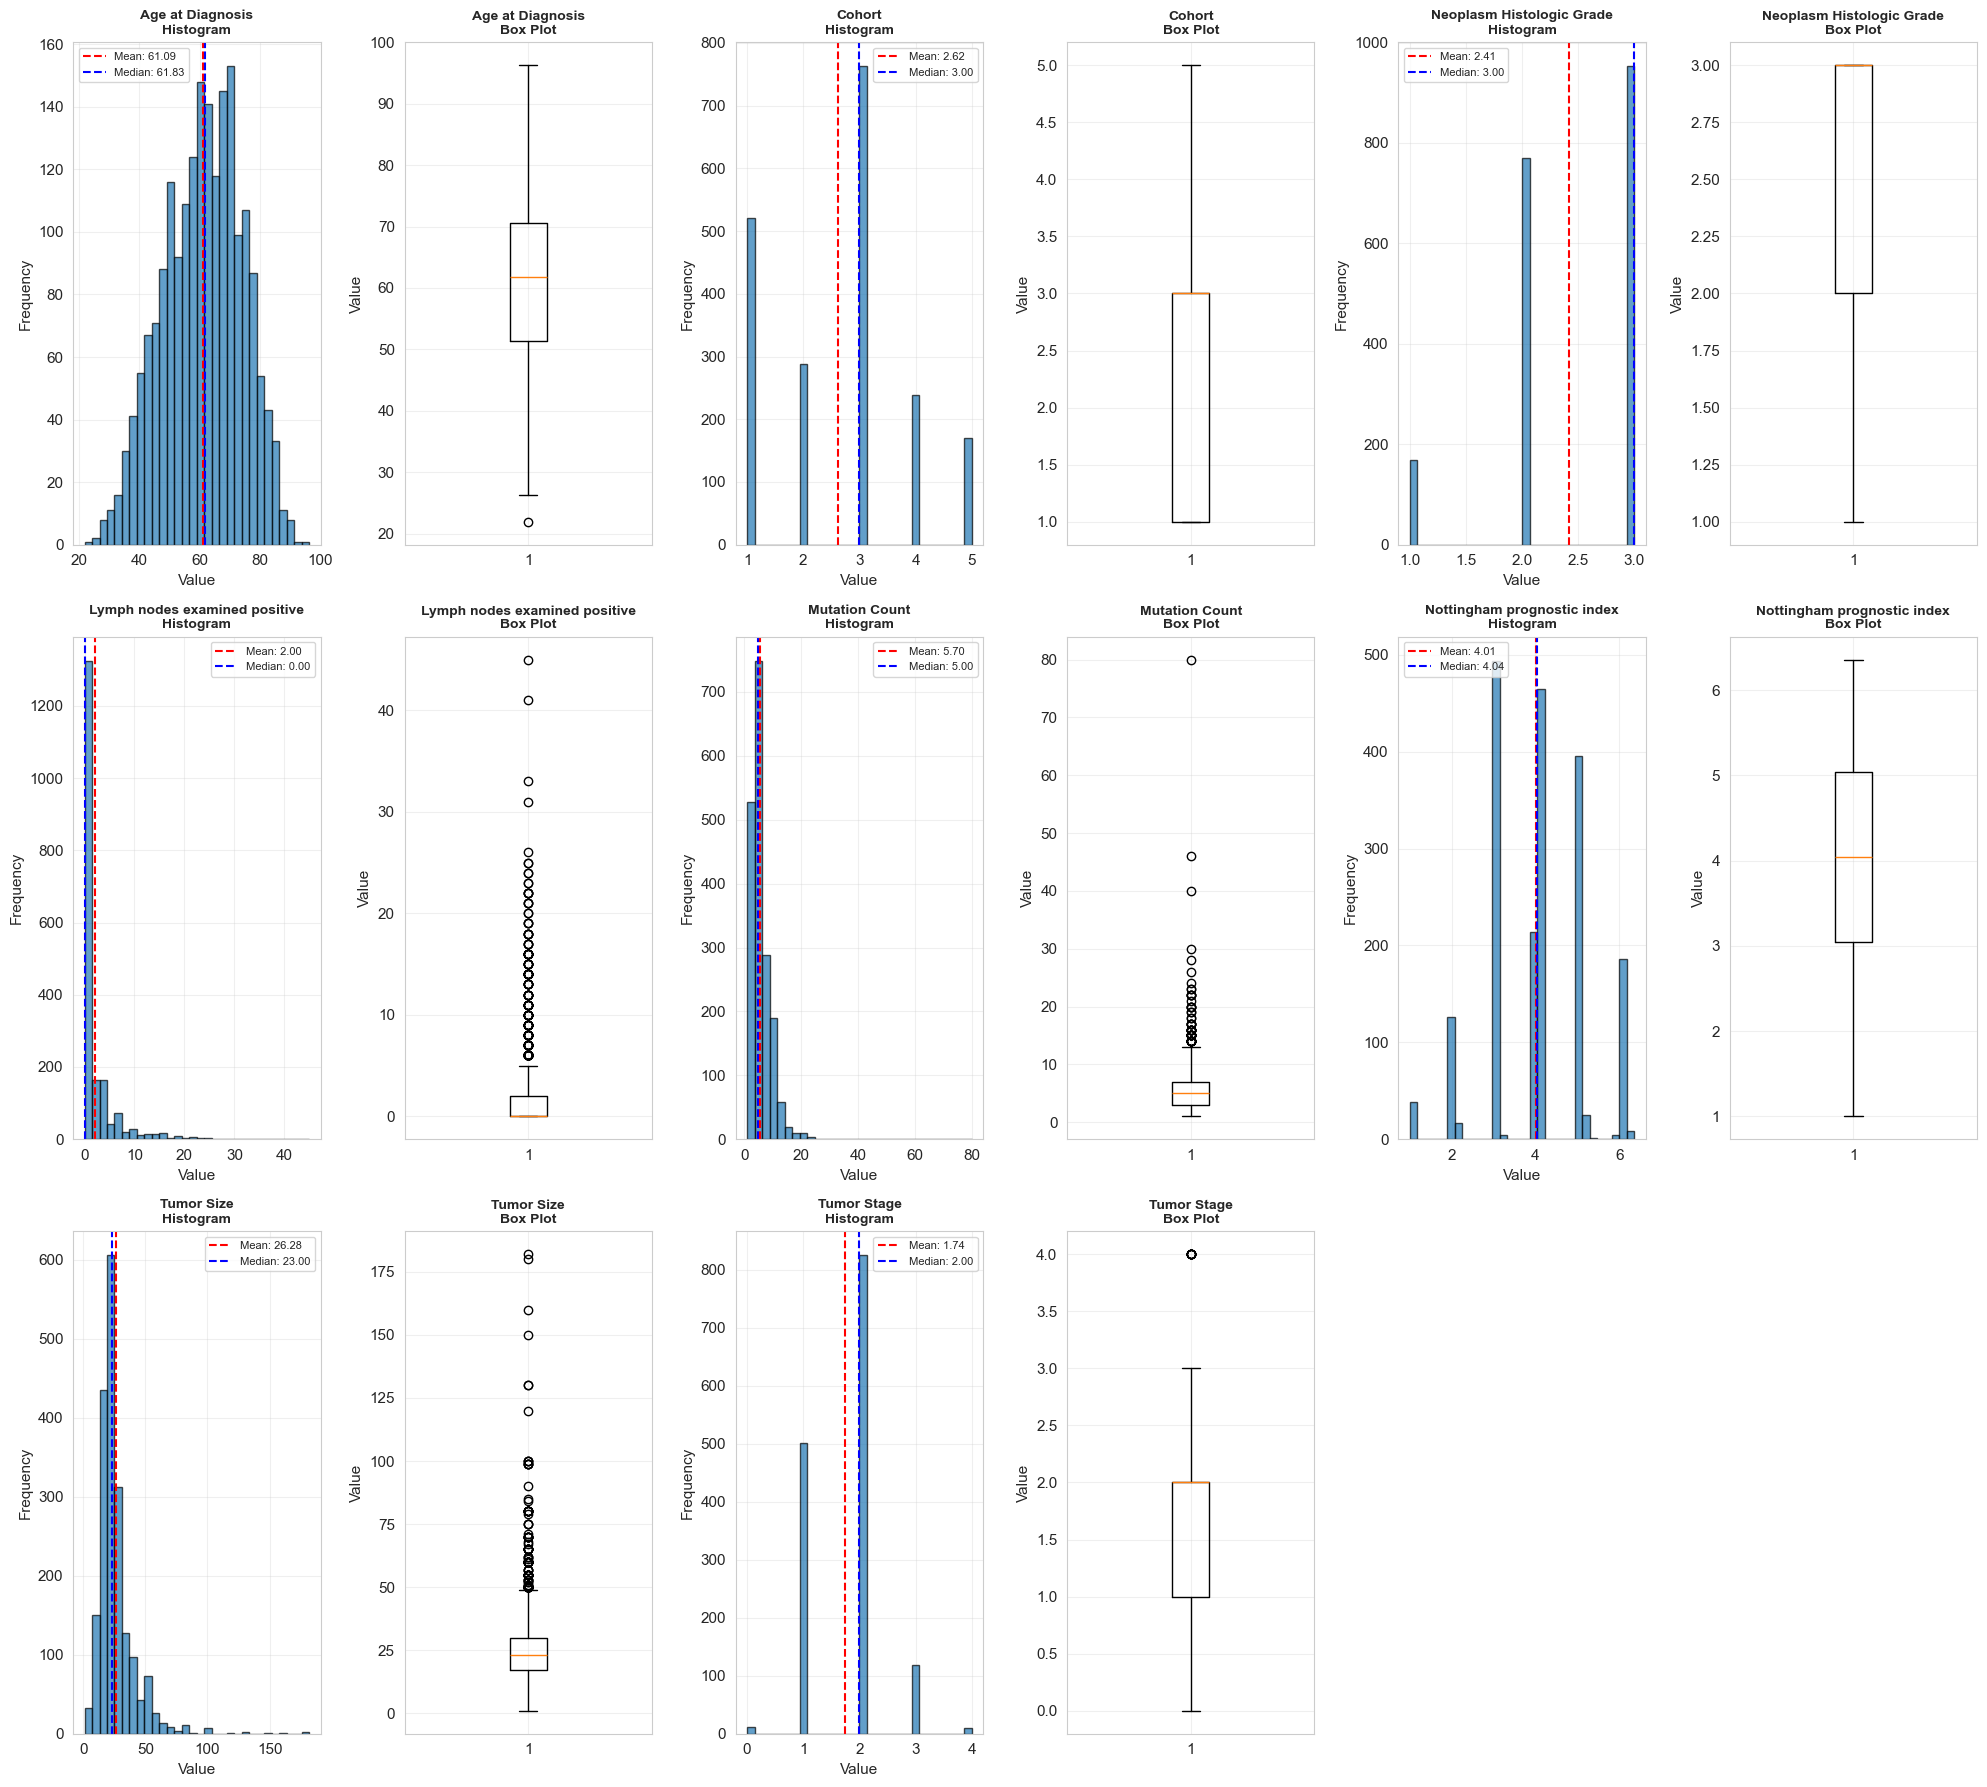


Summary Statistics for Numeric Features:
                                count       mean        std    min      25%     50%      75%     max
Age at Diagnosis               1980.0  61.091869  12.951157  21.93  51.4425  61.825  70.6025   96.29
Cohort                         1980.0   2.620202   1.232127   1.00   1.0000   3.000   3.0000    5.00
Neoplasm Histologic Grade      1893.0   2.414157   0.649158   1.00   2.0000   3.000   3.0000    3.00
Lymph nodes examined positive  1904.0   2.002101   4.079993   0.00   0.0000   0.000   2.0000   45.00
Mutation Count                 1859.0   5.699839   4.057877   1.00   3.0000   5.000   7.0000   80.00
Nottingham prognostic index    1979.0   4.012482   1.160818   1.00   3.0440   4.042   5.0400    6.36
Tumor Size                     1955.0  26.275581  15.379858   1.00  17.0000  23.000  30.0000  182.00
Tumor Stage                    1466.0   1.736016   0.642541   0.00   1.0000   2.000   2.0000    4.00

SKEWNESS ANALYSIS
                      Feature 

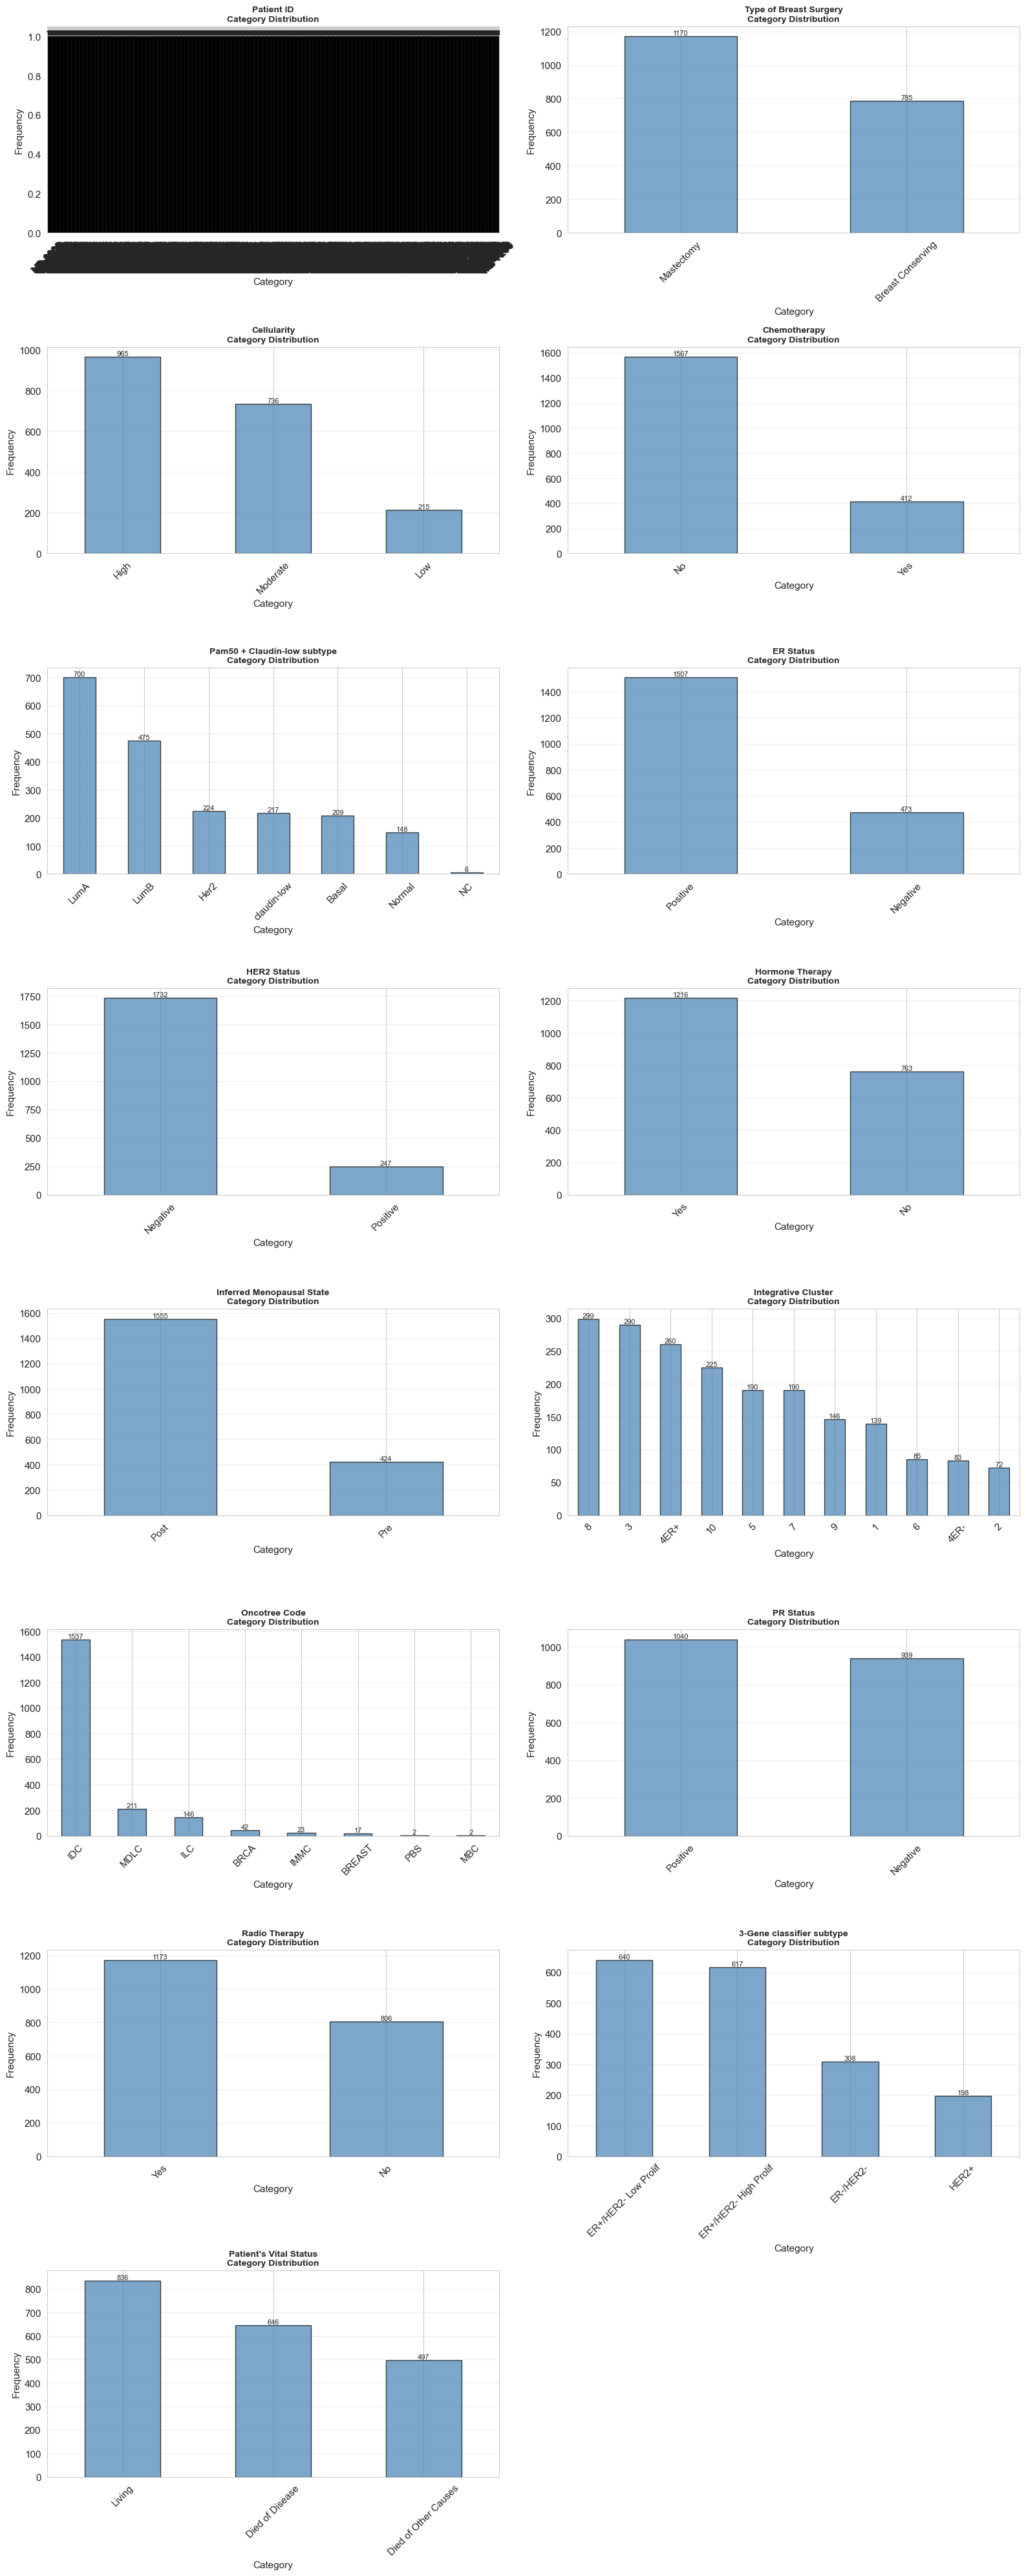


Categorical Feature Summary:

Patient ID:
  Unique values: 1980
  Missing values: 0 (0.00%)
  Most common: MB-0000 (1 occurrences, 0.05%)

Type of Breast Surgery:
  Unique values: 2
  Missing values: 25 (1.26%)
  Most common: Mastectomy (1170 occurrences, 59.09%)
  Value counts:
    Mastectomy: 1170 (59.09%)
    Breast Conserving: 785 (39.65%)

Cellularity:
  Unique values: 3
  Missing values: 64 (3.23%)
  Most common: High (965 occurrences, 48.74%)
  Value counts:
    High: 965 (48.74%)
    Moderate: 736 (37.17%)
    Low: 215 (10.86%)

Chemotherapy:
  Unique values: 2
  Missing values: 1 (0.05%)
  Most common: No (1567 occurrences, 79.14%)
  Value counts:
    No: 1567 (79.14%)
    Yes: 412 (20.81%)

Pam50 + Claudin-low subtype:
  Unique values: 7
  Missing values: 1 (0.05%)
  Most common: LumA (700 occurrences, 35.35%)
  Value counts:
    LumA: 700 (35.35%)
    LumB: 475 (23.99%)
    Her2: 224 (11.31%)
    claudin-low: 217 (10.96%)
    Basal: 209 (10.56%)
    Normal: 148 (7.47%)
    

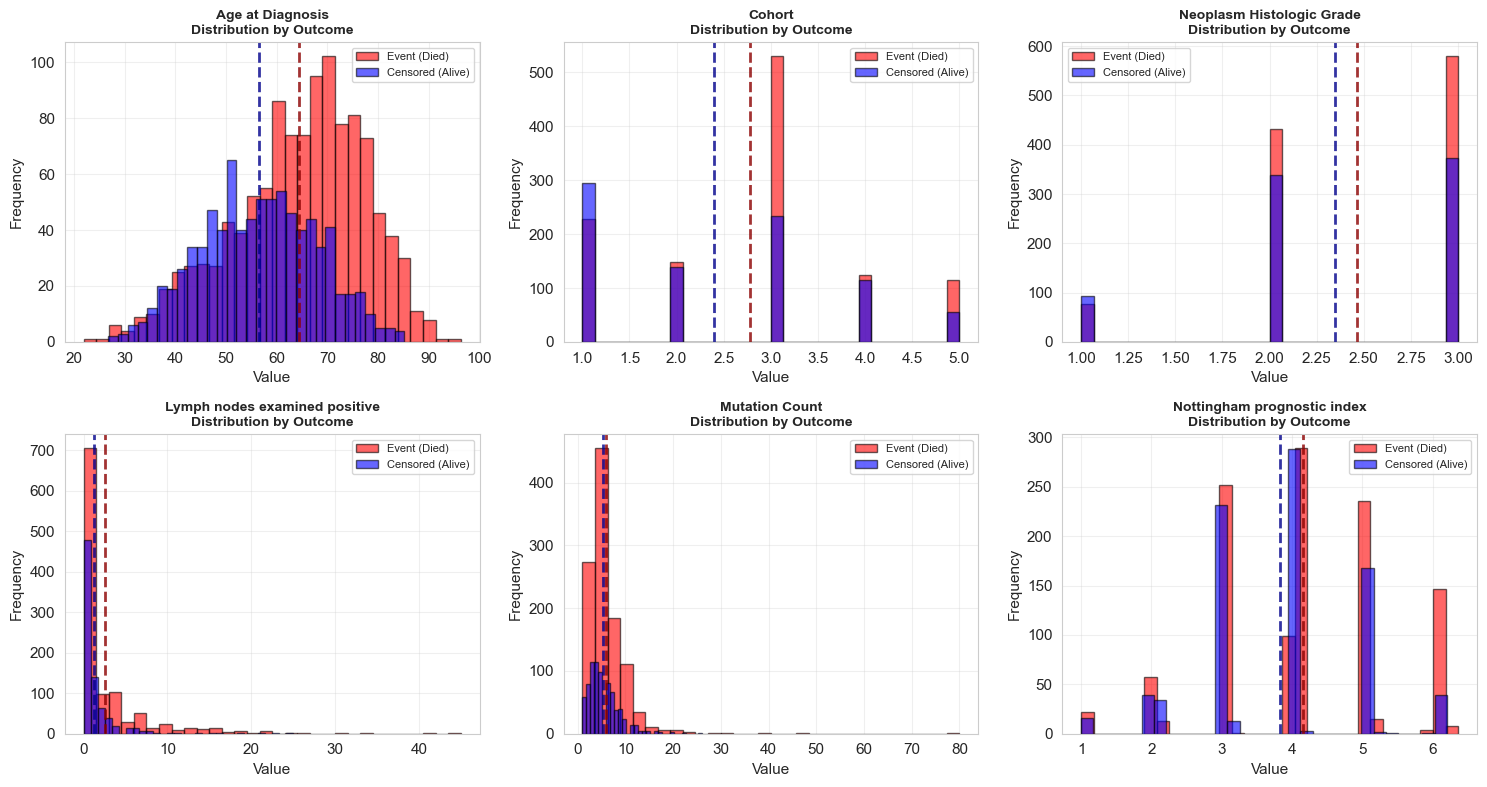


Statistical Comparison (Event vs Censored):
                      Feature  Event_Mean  Censored_Mean  Difference  Difference_%      P_Value Significant
             Age at Diagnosis   64.443645      56.505227    7.938418     14.048997 3.464594e-45         Yes
                   Tumor Size   28.419140      23.351838    5.067302     21.699800 4.309704e-19         Yes
  Nottingham prognostic index    4.152299       3.821321    0.330978      8.661360 8.104370e-15         Yes
                  Tumor Stage    1.845687       1.595645    0.250041     15.670217 5.577285e-13         Yes
Lymph nodes examined positive    2.571558       1.216250    1.355308    111.433338 1.180244e-12         Yes
                       Cohort    2.782343       2.398325    0.384017     16.011893 5.441317e-12         Yes
               Mutation Count    5.963269       5.327273    0.635996     11.938498 2.046976e-04         Yes
    Neoplasm Histologic Grade    2.462741       2.348635    0.114106      4.858407 4.082106

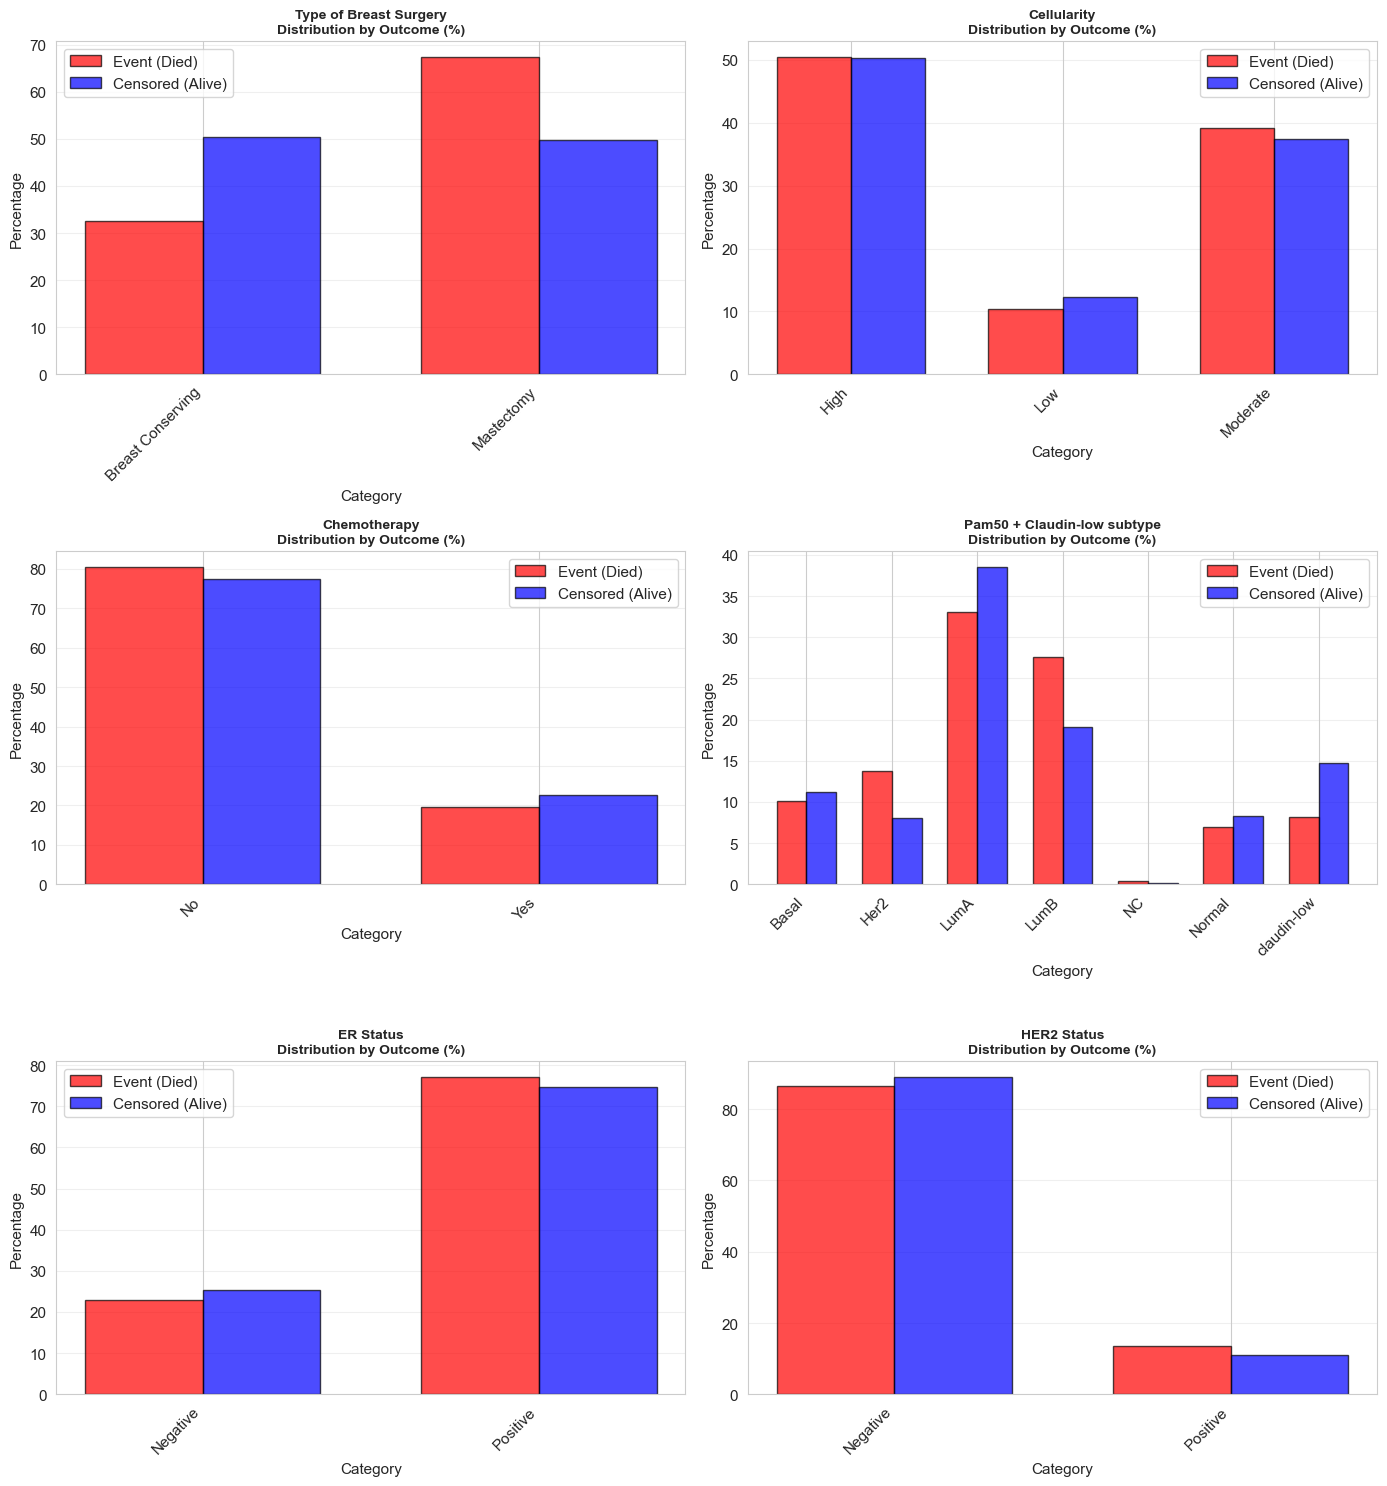


Statistical Comparison (Event vs Censored):
                    Feature  Chi2_Statistic      P_Value Significant
     Type of Breast Surgery       61.559227 4.296235e-15         Yes
Pam50 + Claudin-low subtype       54.228066 6.635756e-10         Yes
                HER2 Status        2.658642 1.029886e-01          No
               Chemotherapy        2.625715 1.051451e-01          No
                  ER Status        1.325386 2.496277e-01          No
                Cellularity        1.917550 3.833623e-01          No

✓ 2 out of 6 categorical features show statistically significant differences (p < 0.05)


In [11]:
# Exclude outcome columns for feature analysis (both original and transformed)
# This prevents data leakage in EDA
outcome_cols = [
    # Transformed outcome columns
    'event_os', 'duration_os', 'event_rfs', 'duration_rfs',
    # Original outcome columns (to prevent leakage)
    'Overall Survival (Months)', 'Overall Survival Status',
    'Relapse Free Status (Months)', 'Relapse Free Status'
]
feature_df = df.drop(columns=[col for col in outcome_cols if col in df.columns], errors='ignore')

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFeature types:")
print(f"  Numeric features: {len(numeric_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

# Numeric Feature Distributions
print("\n" + "="*60)
print("NUMERIC FEATURE DISTRIBUTIONS")
print("="*60)

if len(numeric_cols) > 0:
    # Calculate number of rows and columns for subplots
    n_numeric = len(numeric_cols)
    n_cols = 3
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    # Create histograms and box plots for numeric features
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(20, 6 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        ax_hist = axes[idx * 2]
        feature_df[col].hist(bins=30, ax=ax_hist, edgecolor='black', alpha=0.7)
        ax_hist.set_title(f'{col}\nHistogram', fontsize=10, fontweight='bold')
        ax_hist.set_xlabel('Value')
        ax_hist.set_ylabel('Frequency')
        ax_hist.grid(True, alpha=0.3)
        
        # Add mean and median lines
        mean_val = feature_df[col].mean()
        median_val = feature_df[col].median()
        ax_hist.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax_hist.axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.2f}')
        ax_hist.legend(fontsize=8)
        
        ax_box = axes[idx * 2 + 1]
        data_for_boxplot = feature_df[col].dropna().values
        ax_box.boxplot(data_for_boxplot, vert=True)
        ax_box.set_title(f'{col}\nBox Plot', fontsize=10, fontweight='bold')
        ax_box.set_ylabel('Value')
        ax_box.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numeric_cols) * 2, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics for numeric features
    print("\nSummary Statistics for Numeric Features:")
    print("="*60)
    numeric_summary = feature_df[numeric_cols].describe()
    print(numeric_summary.T.to_string())
    
    # Check for skewed distributions
    print("\n" + "="*60)
    print("SKEWNESS ANALYSIS")
    print("="*60)
    from scipy.stats import skew
    
    skewness_results = []
    for col in numeric_cols:
        if feature_df[col].notna().sum() > 0:
            skew_val = skew(feature_df[col].dropna())
            skewness_results.append({
                'Feature': col,
                'Skewness': skew_val,
                'Interpretation': 'Highly skewed' if abs(skew_val) > 1 else 'Moderately skewed' if abs(skew_val) > 0.5 else 'Approximately normal'
            })
    
    if skewness_results:
        skew_df = pd.DataFrame(skewness_results)
        skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)
        print(skew_df.to_string(index=False))
        
        # Flag highly skewed features
        highly_skewed = skew_df[skew_df['Skewness'].abs() > 1]
        if len(highly_skewed) > 0:
            print(f"\n⚠ {len(highly_skewed)} features are highly skewed (|skewness| > 1)")
            print("Consider log transformation or other normalization methods.")
else:
    print("No numeric features found.")

# Categorical Feature Distributions
print("\n" + "="*60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("="*60)

if len(categorical_cols) > 0:
    # Calculate number of rows and columns for subplots
    n_categorical = len(categorical_cols)
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1) if n_categorical > 1 else axes.reshape(1, 1)
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]
        value_counts = feature_df[col].value_counts()
        
        value_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}\nCategory Distribution', fontsize=10, fontweight='bold')
        ax.set_xlabel('Category')
        ax.set_ylabel('Frequency')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels on bars
        for i, v in enumerate(value_counts.values):
            ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary for categorical features
    print("\nCategorical Feature Summary:")
    print("="*60)
    for col in categorical_cols:
        n_unique = feature_df[col].nunique()
        n_missing = feature_df[col].isnull().sum()
        most_common = feature_df[col].mode().iloc[0] if len(feature_df[col].mode()) > 0 else 'N/A'
        most_common_count = feature_df[col].value_counts().iloc[0] if len(feature_df[col].value_counts()) > 0 else 0
        most_common_pct = (most_common_count / len(feature_df)) * 100
        
        print(f"\n{col}:")
        print(f"  Unique values: {n_unique}")
        print(f"  Missing values: {n_missing} ({n_missing/len(feature_df)*100:.2f}%)")
        print(f"  Most common: {most_common} ({most_common_count} occurrences, {most_common_pct:.2f}%)")
        
        # Show value counts for features with few categories
        if n_unique <= 10:
            print(f"  Value counts:")
            for val, count in feature_df[col].value_counts().head(10).items():
                pct = (count / len(feature_df)) * 100
                print(f"    {val}: {count} ({pct:.2f}%)")
else:
    print("No categorical features found.")


# Distribution by Outcome (Event vs Censored)
print("\n" + "="*60)
print("DISTRIBUTION BY OUTCOME (Event vs Censored)")
print("="*60)
print("Comparing feature distributions between patients who died (event=1) and those who are still alive (event=0)")

if 'event_os' in df.columns:
    event_group = df[df['event_os'] == 1]
    censored_group = df[df['event_os'] == 0]
    
    print(f"\nGroup sizes:")
    print(f"  Event (died): {len(event_group)} patients")
    print(f"  Censored (alive): {len(censored_group)} patients")
    
    # Compare numeric features by outcome
    if len(numeric_cols) > 0:
        print("\n" + "="*60)
        print("NUMERIC FEATURES: COMPARISON BY OUTCOME")
        print("="*60)
        
        # Select top numeric features for visualization (if too many)
        n_features_to_plot = min(6, len(numeric_cols))
        key_numeric = numeric_cols[:n_features_to_plot]
        
        # Create comparison plots (single row layout)
        n_cols_plot = min(3, n_features_to_plot)
        n_rows_plot = (n_features_to_plot + n_cols_plot - 1) // n_cols_plot
        fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
        if n_rows_plot == 1:
            axes = axes.reshape(1, -1) if n_cols_plot > 1 else axes.reshape(1, 1)
        axes = axes.flatten()
        
        for idx, col in enumerate(key_numeric):
            ax = axes[idx]
            
            # Create overlapping histograms
            event_group[col].dropna().hist(bins=30, ax=ax, alpha=0.6, label='Event (Died)', color='red', edgecolor='black')
            censored_group[col].dropna().hist(bins=30, ax=ax, alpha=0.6, label='Censored (Alive)', color='blue', edgecolor='black')
            ax.set_title(f'{col}\nDistribution by Outcome', fontsize=10, fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add mean lines
            event_mean = event_group[col].mean()
            censored_mean = censored_group[col].mean()
            ax.axvline(event_mean, color='darkred', linestyle='--', linewidth=2, alpha=0.8)
            ax.axvline(censored_mean, color='darkblue', linestyle='--', linewidth=2, alpha=0.8)
        
        # Hide unused subplots
        for idx in range(len(key_numeric), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Statistical comparison for numeric features
        print("\nStatistical Comparison (Event vs Censored):")
        print("="*60)
        comparison_results = []
        
        for col in numeric_cols:
            event_values = event_group[col].dropna()
            censored_values = censored_group[col].dropna()
            
            if len(event_values) > 0 and len(censored_values) > 0:
                from scipy.stats import mannwhitneyu
                
                event_mean = event_values.mean()
                censored_mean = censored_values.mean()
                mean_diff = event_mean - censored_mean
                mean_diff_pct = (mean_diff / censored_mean * 100) if censored_mean != 0 else 0
                
                # Mann-Whitney U test (non-parametric)
                try:
                    statistic, p_value = mannwhitneyu(event_values, censored_values, alternative='two-sided')
                    comparison_results.append({
                        'Feature': col,
                        'Event_Mean': event_mean,
                        'Censored_Mean': censored_mean,
                        'Difference': mean_diff,
                        'Difference_%': mean_diff_pct,
                        'P_Value': p_value,
                        'Significant': 'Yes' if p_value < 0.05 else 'No'
                    })
                except:
                    pass
        
        if comparison_results:
            comparison_df = pd.DataFrame(comparison_results)
            comparison_df = comparison_df.sort_values('P_Value')
            print(comparison_df.to_string(index=False))
            
            # Count significant differences
            n_significant = (comparison_df['P_Value'] < 0.05).sum()
            print(f"\n✓ {n_significant} out of {len(comparison_df)} numeric features show statistically significant differences (p < 0.05)")
    
    # Compare categorical features by outcome
    if len(categorical_cols) > 0:
        print("\n" + "="*60)
        print("CATEGORICAL FEATURES: COMPARISON BY OUTCOME")
        print("="*60)
        
        # Select categorical features with reasonable number of categories
        key_categorical = [col for col in categorical_cols if df[col].nunique() <= 10][:6]
        
        if len(key_categorical) > 0:
            # Create comparison plots
            n_cols = 2
            n_rows = (len(key_categorical) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
            if n_rows == 1:
                axes = axes.reshape(1, -1) if len(key_categorical) > 1 else axes.reshape(1, 1)
            axes = axes.flatten()
            
            for idx, col in enumerate(key_categorical):
                ax = axes[idx]
                
                # Create grouped bar chart
                event_counts = event_group[col].value_counts(normalize=True) * 100
                censored_counts = censored_group[col].value_counts(normalize=True) * 100
                
                # Get all categories
                all_categories = sorted(set(event_counts.index) | set(censored_counts.index))
                
                x = np.arange(len(all_categories))
                width = 0.35
                
                event_values = [event_counts.get(cat, 0) for cat in all_categories]
                censored_values = [censored_counts.get(cat, 0) for cat in all_categories]
                
                ax.bar(x - width/2, event_values, width, label='Event (Died)', color='red', alpha=0.7, edgecolor='black')
                ax.bar(x + width/2, censored_values, width, label='Censored (Alive)', color='blue', alpha=0.7, edgecolor='black')
                
                ax.set_title(f'{col}\nDistribution by Outcome (%)', fontsize=10, fontweight='bold')
                ax.set_xlabel('Category')
                ax.set_ylabel('Percentage')
                ax.set_xticks(x)
                ax.set_xticklabels(all_categories, rotation=45, ha='right')
                ax.legend()
                ax.grid(True, alpha=0.3, axis='y')
            
            # Hide unused subplots
            for idx in range(len(key_categorical), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Statistical comparison for categorical features (Chi-square test)
            print("\nStatistical Comparison (Event vs Censored):")
            print("="*60)
            from scipy.stats import chi2_contingency
            
            cat_comparison_results = []
            for col in key_categorical:
                # Create contingency table
                contingency = pd.crosstab(df[col], df['event_os'])
                
                if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                    try:
                        chi2, p_value, dof, expected = chi2_contingency(contingency)
                        cat_comparison_results.append({
                            'Feature': col,
                            'Chi2_Statistic': chi2,
                            'P_Value': p_value,
                            'Significant': 'Yes' if p_value < 0.05 else 'No'
                        })
                    except:
                        pass
            
            if cat_comparison_results:
                cat_comparison_df = pd.DataFrame(cat_comparison_results)
                cat_comparison_df = cat_comparison_df.sort_values('P_Value')
                print(cat_comparison_df.to_string(index=False))
                
                n_significant_cat = (cat_comparison_df['P_Value'] < 0.05).sum()
                print(f"\n✓ {n_significant_cat} out of {len(cat_comparison_df)} categorical features show statistically significant differences (p < 0.05)")


### 5.2 Survival Outcome Exploration

**Purpose**: Explore survival outcomes (duration and events) to understand the data structure before Kaplan-Meier analysis.

**What we'll examine:**
- **Survival time distributions**: Histograms and summary statistics for `duration_os`
- **Censoring patterns**: Event vs censored counts and percentages
- **Event rates**: Overall event rate and event rates over time
- **Survival time by outcome**: Compare survival times between event and censored groups
- **Baseline validation**: Verify survival variables are correctly formatted for KM analysis





OVERALL SURVIVAL SUMMARY
Total patients: 1980
Events (died): 1144 (57.8%)
Censored (alive): 836 (42.2%)

Survival Time (duration_os) Statistics:
  Mean: 125.3 months
  Median: 116.5 months
  Min: 0.1 months
  Max: 355.2 months
  IQR: [60.9, 185.1] months

SURVIVAL TIME DISTRIBUTION


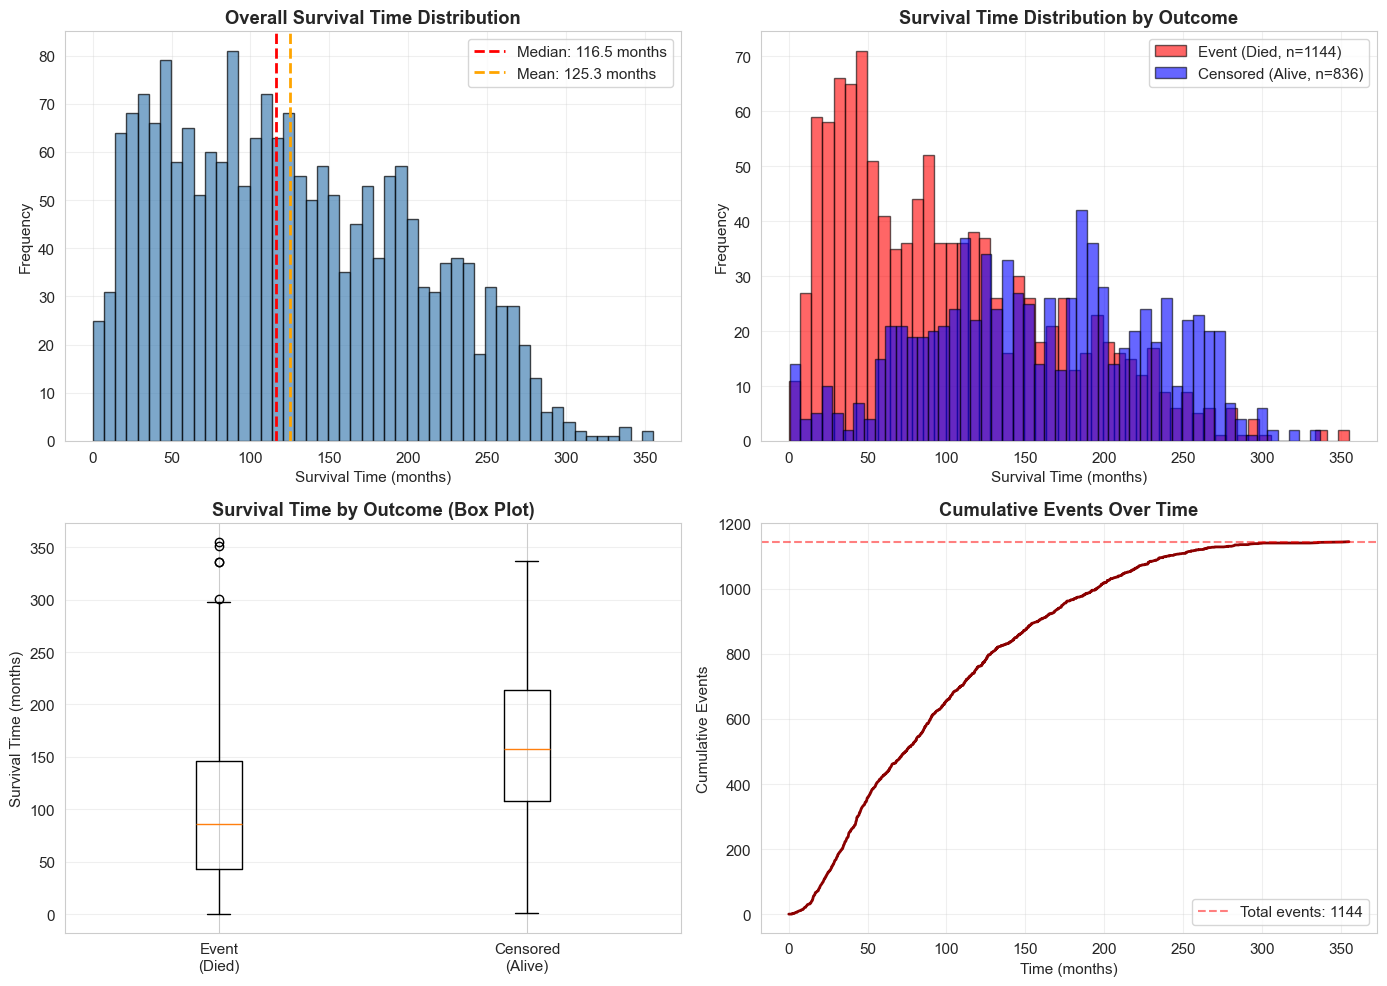


SURVIVAL TIME STATISTICS BY OUTCOME
       Event (Died)  Censored (Alive)  Difference
count   1144.000000        836.000000  308.000000
mean     100.443007        159.332656  -58.889649
std       69.617136         71.256736   -1.639599
min        0.100000          0.766667   -0.666667
25%       42.850000        108.016667  -65.166667
50%       86.066667        157.883333  -71.816667
75%      145.808333        214.100000  -68.291667
max      355.200000        337.033333   18.166667

Mann-Whitney U test (Event vs Censored):
  Statistic: 259502.00
  P-value: 7.63e-68
  Interpretation: Significant difference (p < 0.05)

EVENT RATE BY TIME PERIODS
 Time Period  Patients  Events  Event Rate (%)
 0-12 months        45      30       66.666667
12-24 months       103      90       87.378641
24-36 months       114     103       90.350877
36-60 months       228     204       89.473684
  60+ months      1490     717       48.120805

CENSORING PATTERN ANALYSIS
Censored patients (n=836):
  Mean cens

In [12]:
# 3.5.3 Survival Outcome Exploration

# Verify survival variables exist
if 'event_os' not in df.columns or 'duration_os' not in df.columns:
    raise ValueError("Survival variables (event_os, duration_os) not found in dataframe")

# 1. Overall Survival Summary
print("\n" + "="*60)
print("OVERALL SURVIVAL SUMMARY")
print("="*60)

n_total = len(df)
n_events = df['event_os'].sum()
n_censored = (df['event_os'] == 0).sum()
event_rate = df['event_os'].mean() * 100
censoring_rate = (1 - df['event_os'].mean()) * 100

print(f"Total patients: {n_total}")
print(f"Events (died): {n_events} ({event_rate:.1f}%)")
print(f"Censored (alive): {n_censored} ({censoring_rate:.1f}%)")

# Survival time statistics
print(f"\nSurvival Time (duration_os) Statistics:")
print(f"  Mean: {df['duration_os'].mean():.1f} months")
print(f"  Median: {df['duration_os'].median():.1f} months")
print(f"  Min: {df['duration_os'].min():.1f} months")
print(f"  Max: {df['duration_os'].max():.1f} months")
print(f"  IQR: [{df['duration_os'].quantile(0.25):.1f}, {df['duration_os'].quantile(0.75):.1f}] months")

# 2. Survival Time Distribution Visualization
print("\n" + "="*60)
print("SURVIVAL TIME DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall histogram
ax1 = axes[0, 0]
df['duration_os'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['duration_os'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["duration_os"].median():.1f} months')
ax1.axvline(df['duration_os'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {df["duration_os"].mean():.1f} months')
ax1.set_xlabel('Survival Time (months)')
ax1.set_ylabel('Frequency')
ax1.set_title('Overall Survival Time Distribution', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution by outcome
ax2 = axes[0, 1]
event_times = df[df['event_os'] == 1]['duration_os']
censored_times = df[df['event_os'] == 0]['duration_os']
ax2.hist(event_times, bins=50, alpha=0.6, label=f'Event (Died, n={len(event_times)})', color='red', edgecolor='black')
ax2.hist(censored_times, bins=50, alpha=0.6, label=f'Censored (Alive, n={len(censored_times)})', color='blue', edgecolor='black')
ax2.set_xlabel('Survival Time (months)')
ax2.set_ylabel('Frequency')
ax2.set_title('Survival Time Distribution by Outcome', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Box plot by outcome
ax3 = axes[1, 0]
event_data = [event_times.values, censored_times.values]
ax3.boxplot(event_data, labels=['Event\n(Died)', 'Censored\n(Alive)'], vert=True)
ax3.set_ylabel('Survival Time (months)')
ax3.set_title('Survival Time by Outcome (Box Plot)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Cumulative events over time
ax4 = axes[1, 1]
# Sort by survival time
df_sorted = df.sort_values('duration_os')
cumulative_events = df_sorted['event_os'].cumsum()
ax4.plot(df_sorted['duration_os'], cumulative_events, linewidth=2, color='darkred')
ax4.set_xlabel('Time (months)')
ax4.set_ylabel('Cumulative Events')
ax4.set_title('Cumulative Events Over Time', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axhline(n_events, color='red', linestyle='--', alpha=0.5, label=f'Total events: {n_events}')
ax4.legend()

plt.tight_layout()
plt.show()

# 3. Survival Time Statistics by Outcome
print("\n" + "="*60)
print("SURVIVAL TIME STATISTICS BY OUTCOME")
print("="*60)

event_stats = event_times.describe()
censored_stats = censored_times.describe()

comparison_df = pd.DataFrame({
    'Event (Died)': event_stats,
    'Censored (Alive)': censored_stats
})
comparison_df['Difference'] = comparison_df['Event (Died)'] - comparison_df['Censored (Alive)']

print(comparison_df.to_string())

# Statistical test
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(event_times, censored_times, alternative='two-sided')
print(f"\nMann-Whitney U test (Event vs Censored):")
print(f"  Statistic: {statistic:.2f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Interpretation: {'Significant difference' if p_value < 0.05 else 'No significant difference'} (p < 0.05)")

# 4. Event Rate Over Time
print("\n" + "="*60)
print("EVENT RATE BY TIME PERIODS")
print("="*60)

# Define time periods (in months)
time_periods = [
    (0, 12, "0-12 months"),
    (12, 24, "12-24 months"),
    (24, 36, "24-36 months"),
    (36, 60, "36-60 months"),
    (60, float('inf'), "60+ months")
]

period_stats = []
for start, end, label in time_periods:
    if end == float('inf'):
        period_df = df[(df['duration_os'] >= start)]
    else:
        period_df = df[(df['duration_os'] >= start) & (df['duration_os'] < end)]
    
    if len(period_df) > 0:
        n_in_period = len(period_df)
        n_events_in_period = period_df['event_os'].sum()
        event_rate_period = (n_events_in_period / n_in_period) * 100
        
        period_stats.append({
            'Time Period': label,
            'Patients': n_in_period,
            'Events': n_events_in_period,
            'Event Rate (%)': event_rate_period
        })

if period_stats:
    period_df = pd.DataFrame(period_stats)
    print(period_df.to_string(index=False))

# 5. Censoring Pattern Analysis
print("\n" + "="*60)
print("CENSORING PATTERN ANALYSIS")
print("="*60)

# Analyze when censoring occurs
censored_df = df[df['event_os'] == 0]
event_df = df[df['event_os'] == 1]

print(f"Censored patients (n={len(censored_df)}):")
print(f"  Mean censoring time: {censored_df['duration_os'].mean():.1f} months")
print(f"  Median censoring time: {censored_df['duration_os'].median():.1f} months")
print(f"  Min censoring time: {censored_df['duration_os'].min():.1f} months")
print(f"  Max censoring time: {censored_df['duration_os'].max():.1f} months")

print(f"\nEvent patients (n={len(event_df)}):")
print(f"  Mean event time: {event_df['duration_os'].mean():.1f} months")
print(f"  Median event time: {event_df['duration_os'].median():.1f} months")
print(f"  Min event time: {event_df['duration_os'].min():.1f} months")
print(f"  Max event time: {event_df['duration_os'].max():.1f} months")

# Check for immediate events (duration = 0 or very small)
immediate_events = df[(df['event_os'] == 1) & (df['duration_os'] <= 0.1)]
if len(immediate_events) > 0:
    print(f"\nWarning: {len(immediate_events)} patients have events at time <= 0.1 months")
    print("  These may need special handling in KM analysis")

# 6. Validation Checks
print("\n" + "="*60)
print("VALIDATION CHECKS FOR KM ANALYSIS")
print("="*60)

# Check for negative survival times
negative_times = df[df['duration_os'] < 0]
if len(negative_times) > 0:
    print(f"Warning: {len(negative_times)} patients have negative survival times")
else:
    print("✓ All survival times are non-negative")

# Check for zero survival times with events
zero_events = df[(df['duration_os'] == 0) & (df['event_os'] == 1)]
if len(zero_events) > 0:
    print(f"Warning: {len(zero_events)} patients have events at time 0")
    print("  Consider handling these carefully in KM analysis")
else:
    print("✓ No events at time 0")

# Check event indicator is binary
if df['event_os'].isin([0, 1]).all():
    print("✓ Event indicator is binary (0 or 1)")
else:
    print(f"Warning: Event indicator contains values other than 0 or 1")
    print(f"  Unique values: {df['event_os'].unique()}")

# Check for missing survival data
missing_duration = df['duration_os'].isnull().sum()
missing_event = df['event_os'].isnull().sum()
if missing_duration == 0 and missing_event == 0:
    print("✓ No missing survival data")
else:
    print(f"Warning: Missing duration: {missing_duration}, Missing event: {missing_event}")

# 7. Key Survival Metrics for KM
print("\n" + "="*60)
print("KEY SURVIVAL METRICS (For KM Analysis)")
print("="*60)

# Calculate potential survival probabilities at key time points (rough estimates)
time_points = [6, 12, 24, 36, 60]  # months
print("\nEstimated survival probabilities at key time points:")
print("(These will be calculated more precisely using KM)")
for t in time_points:
    # Rough estimate: proportion of patients who survived beyond time t
    survived_beyond_t = len(df[(df['duration_os'] > t) | ((df['duration_os'] <= t) & (df['event_os'] == 0))])
    survival_prob = survived_beyond_t / n_total
    print(f"  S({t} months) ≈ {survival_prob:.3f} ({survived_beyond_t}/{n_total} patients)")

# Median survival estimate
median_estimate = df['duration_os'].median()
print(f"\nMedian survival time (approximate): {median_estimate:.1f} months")
print("(Exact median will be calculated using KM)")

print(f"  Total patients: {n_total}")
print(f"  Events: {n_events} ({event_rate:.1f}%)")
print(f"  Censored: {n_censored} ({censoring_rate:.1f}%)")
print(f"\nNote: KM analysis will use the FULL dataset (df), not train/test splits")


### 5.3 Missing Data Analysis

MISSING DATA ANALYSIS (Full Dataset)

Total features (excluding outcomes): 23
Features with missing data: 18
Total missing values: 1139
Total cells: 45540
Missing percentage: 2.50%

FEATURES WITH MISSING DATA
                      Feature  Missing_Count  Missing_Percent Data_Type  Unique_Values
                  Tumor Stage            514        25.959596   float64              5
    3-Gene classifier subtype            217        10.959596    object              4
               Mutation Count            121         6.111111   float64             30
    Neoplasm Histologic Grade             87         4.393939   float64              3
Lymph nodes examined positive             76         3.838384   float64             31
                  Cellularity             64         3.232323    object              3
       Type of Breast Surgery             25         1.262626    object              2
                   Tumor Size             25         1.262626   float64            112
        

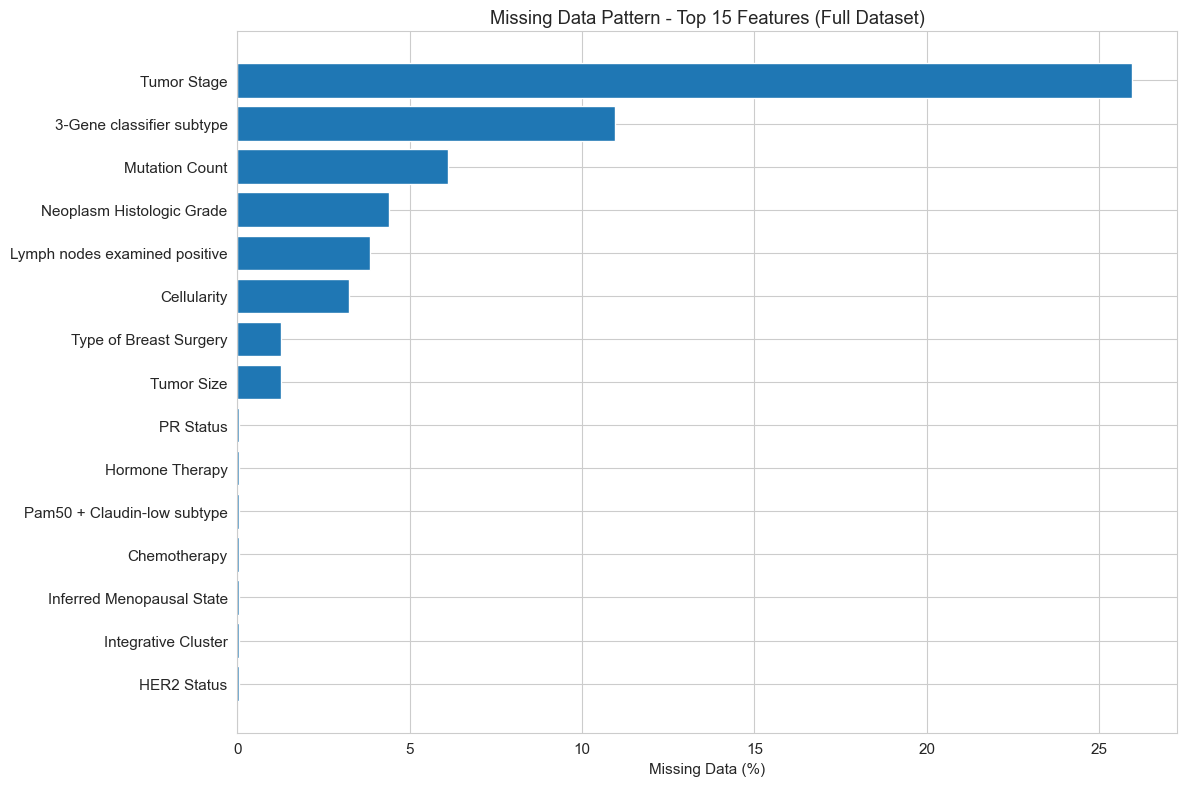


MISSING DATA BY OUTCOME (Informative Missingness Check)
                      Feature  Missing_Event_%  Missing_Censored_%  Difference_%
                  Tumor Stage        28.059441           23.086124      4.973316
    3-Gene classifier subtype        12.325175            9.090909      3.234266
               Mutation Count         4.807692            7.894737      3.087045
                  Cellularity         2.622378            4.066986      1.444608
    Neoplasm Histologic Grade         4.982517            3.588517      1.394001
Lymph nodes examined positive         3.496503            4.306220      0.809717
       Type of Breast Surgery         1.486014            0.956938      0.529076
                   Tumor Size         1.398601            1.076555      0.322046
                    PR Status         0.087413            0.000000      0.087413
              Hormone Therapy         0.087413            0.000000      0.087413

✓ Missing data appears balanced across outcomes


In [13]:
print("="*60)
print("MISSING DATA ANALYSIS (Full Dataset)")
print("="*60)

# Exclude outcome columns from missing data analysis (both original and transformed)
# prevents data leakage in EDA
outcome_cols = [
    # Transformed outcome columns
    'event_os', 'duration_os', 'event_rfs', 'duration_rfs',
    # Original outcome columns (to prevent leakage)
    'Overall Survival (Months)', 'Overall Survival Status',
    'Relapse Free Status (Months)', 'Relapse Free Status'
]
feature_df = df.drop(columns=[col for col in outcome_cols if col in df.columns], errors='ignore')

# Calculate missing data statistics for features only (excluding outcomes)
missing_stats = pd.DataFrame({
    'Feature': feature_df.columns,
    'Missing_Count': feature_df.isnull().sum(),
    'Missing_Percent': (feature_df.isnull().sum() / len(feature_df) * 100),
    'Data_Type': feature_df.dtypes,
    'Unique_Values': [feature_df[col].nunique() for col in feature_df.columns]
})

# Sort by missing percentage
missing_stats = missing_stats.sort_values('Missing_Percent', ascending=False)

print(f"\nTotal features (excluding outcomes): {len(feature_df.columns)}")
print(f"Features with missing data: {(missing_stats['Missing_Percent'] > 0).sum()}")
print(f"Total missing values: {missing_stats['Missing_Count'].sum()}")
print(f"Total cells: {len(feature_df) * len(feature_df.columns)}")
print(f"Missing percentage: {(missing_stats['Missing_Count'].sum() / (len(feature_df) * len(feature_df.columns)) * 100):.2f}%")

# Display features with missing data
print("\n" + "="*60)
print("FEATURES WITH MISSING DATA")
print("="*60)
features_with_missing = missing_stats[missing_stats['Missing_Percent'] > 0]
if len(features_with_missing) > 0:
    print(features_with_missing.to_string(index=False))
else:
    print("No missing data found!")

# Visualize missing data pattern
if len(features_with_missing) > 0:
    plt.figure(figsize=(12, 8))
    top_missing = features_with_missing.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percent'].values)
    plt.yticks(range(len(top_missing)), top_missing['Feature'].values)
    plt.xlabel('Missing Data (%)')
    plt.title('Missing Data Pattern - Top 15 Features (Full Dataset)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Check if missingness is related to outcome (informative missingness)
# Note: We use event_os as a grouping variable (not as a feature) to compare missingness
print("\n" + "="*60)
print("MISSING DATA BY OUTCOME (Informative Missingness Check)")
print("="*60)
if len(features_with_missing) > 0:
    missing_by_outcome = []
    # features_with_missing already excludes outcome columns (from feature_df)
    for col in features_with_missing['Feature'].head(10):
        # Use df to access event_os for grouping, but col is from feature_df (no outcome columns)
        missing_event = df.loc[df['event_os'] == 1, col].isnull().mean() * 100
        missing_censored = df.loc[df['event_os'] == 0, col].isnull().mean() * 100
        missing_by_outcome.append({
            'Feature': col,
            'Missing_Event_%': missing_event,
            'Missing_Censored_%': missing_censored,
            'Difference_%': abs(missing_event - missing_censored)
        })
    
    if missing_by_outcome:
        missing_outcome_df = pd.DataFrame(missing_by_outcome)
        missing_outcome_df = missing_outcome_df.sort_values('Difference_%', ascending=False)
        print(missing_outcome_df.to_string(index=False))
        
        # Flag features with differential missingness
        threshold = 5.0  # 5% difference
        differential_missing = missing_outcome_df[missing_outcome_df['Difference_%'] > threshold]
        if len(differential_missing) > 0:
            print(f"\n⚠ WARNING: {len(differential_missing)} features show differential missingness (>5% difference)")
            print("This may indicate informative missingness or potential bias.")
        else:
            print("\n✓ Missing data appears balanced across outcomes")


# 6.0 Kaplan-Meier (KM) Curves

**Purpose**: Estimate survival probabilities and create survival curves using the Kaplan-Meier method.

**What we'll do:**
- **Overall KM curve**: Estimate survival probabilities for the entire cohort
- **Stratified KM curves**: Compare survival across different subgroups (e.g., by tumor stage, treatment)
- **Survival statistics**: Calculate median survival, survival probabilities at key time points
- **Log-rank tests**: Statistically compare survival curves between groups


## 6.1 Kaplan-Meier Curve

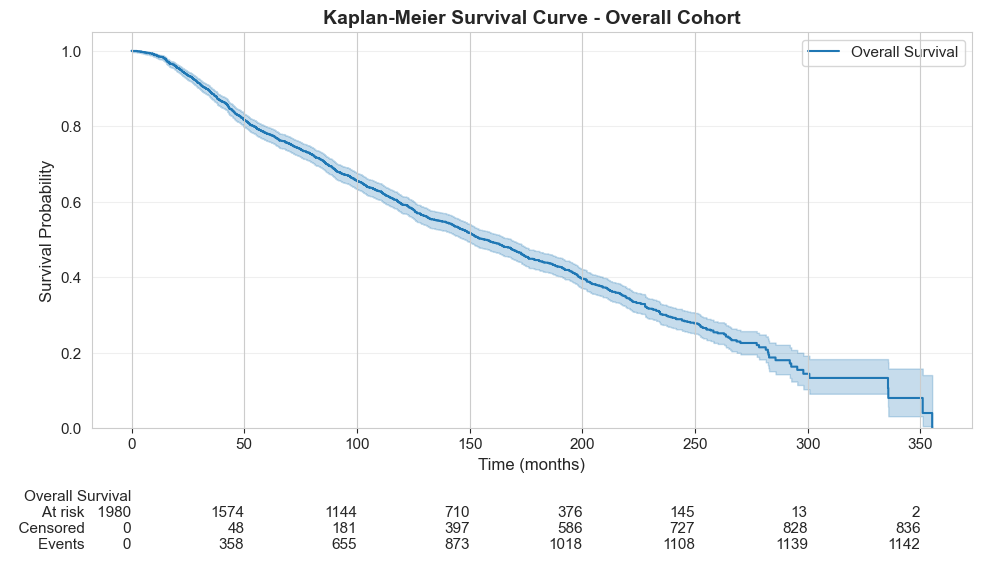


SURVIVAL STATISTICS

Survival probabilities at key time points:


<Figure size 1000x600 with 0 Axes>

  S(6 months) = 0.995
  S(12 months) = 0.985
  S(24 months) = 0.939
  S(36 months) = 0.886
  S(60 months) = 0.780

Total patients: 1980
Events (deaths): 1144 (57.8%)
Censored: 836 (42.2%)


In [14]:
# Fit KM on the full dataset
km = KaplanMeierFitter(label="Overall Survival")

# Ensure survival times are non-negative
df_km = df.copy()
df_km['duration_os'] = df_km['duration_os'].clip(lower=0)
km.fit(durations=df_km['duration_os'], 
       event_observed=df_km['event_os'])

# Plot the survival curve
fig, ax = plt.subplots(figsize=(10, 6))
km.plot_survival_function(ax=ax, ci_show=True)
add_at_risk_counts(km, ax=ax)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curve - Overall Cohort', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SURVIVAL STATISTICS")
print("="*60)

# Survival probabilities at key time points
time_points = [6, 12, 24, 36, 60]  # months
print(f"\nSurvival probabilities at key time points:")
for t in time_points:
    # survival_prob = km.predict(t)
    survival_prob = float(km.survival_function_at_times(t).values)

    if t <= km.survival_function_.index.max():
        ax.annotate(f"{survival_prob:.2f}",
                        xy=(t, survival_prob),
                        xytext=(0, 8),
                        textcoords="offset points",
                        ha='center',
                        fontsize=9)
        
add_at_risk_counts(km, ax=ax)
plt.tight_layout()
plt.show()
        
for t in time_points:
    # survival_prob = km.predict(t)
    survival_prob = float(km.survival_function_at_times(t).values)
    # Get confidence interval if available
    try:
        ci = km.confidence_interval_
        if t <= ci.index.max():
            ci_lower = ci.loc[ci.index <= t, 'lower_bound'].iloc[-1] #if len(ci.loc[ci.index <= t]) > 0 else None
            ci_upper = ci.loc[ci.index <= t, 'upper_bound'].iloc[-1] #if len(ci.loc[ci.index <= t]) > 0 else None
            if ci_lower is not None and ci_upper is not None:
                print(f"  S({t} months) = {survival_prob:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])")
            else:
                print(f"  S({t} months) = {survival_prob:.3f}")
        else:
            print(f"  S({t} months) = {survival_prob:.3f}")
    except:
        print(f"  S({t} months) = {survival_prob:.3f}")

print(f"\nTotal patients: {len(df_km)}")
print(f"Events (deaths): {df_km['event_os'].sum()} ({df_km['event_os'].mean()*100:.1f}%)")
print(f"Censored: {(df_km['event_os'] == 0).sum()} ({(df_km['event_os'] == 0).mean()*100:.1f}%)")
# display(km.survival_function_.head())




In the early phase (0-6 months), the survival probability is very high at 0.995, reflecting few deaths in the early months. Over the course of 12-24 months, the rates are between 0.93-0.98 and between 36-60 months the survival probability drops more to .78-0.886. Early survival is high and mortality is gradually accumulating over years. CI remains narrow between short-medium term phases, losing stability onces less patient data is avaliable. 

The patient event (death)/censoring (patient losing contact, information is incomplete)  follows the same patterns as other long-term, retrospective cancer datasets as many patients survived beyong the observation time. Deaths = 1144 (57.8%), Censored = 836 (42.2%) means the KM prediction is remaining robust despite the slight instability towards the end (where the CI bands widen). The CI bands widen significnatly around 250-300 months, which is expected due to the at-risk population shrinking and estimates become less reliable. 

**Overall, this curve shows how long patients survive after a Breast Cancer Diagnosis, slowing decreasing as patients pass away. Short-term survival is excellent, as after 1 year 98-99% survive (early deaths are rare). Medium-term surival, between 2-3 years, remains high between 89-94% surviving. After 5 years, survival drops to 78%, meaning around 4/5 patients survive. Most deaths will occur over months to years instead of immediately after diagnosis, so clinical focus should include long-term follow-ups.**

### 6.1.1 Median Survival Time, RMST

In [15]:
median_survival_time = km.median_survival_time_
print(f"Median survival time: {median_survival_time:.1f} months")

# Restricted Mean Survival Time (RMST)
horizons = [12.0, 24.0, 36.0, 60.0, 120.0]  # months

# for t in horizons:
#     if t in km.survival_function_.index:    #none appear
#         y = km.survival_function_.loc[t].values[0]
#         ax.annotate(f"{y:.2f}", xy=(t, y),
#                     xytext=(0, 10), textcoords="offset points",
#                     ha='center', fontsize=9)
        

rows = []
for t0 in horizons:
    rmst_val = restricted_mean_survival_time(km, t=t0)
    rows.append({"t0 [months]": int(t0), "RMST [months]": round(float(rmst_val), 1)})

rmst_table = pd.DataFrame(rows)
print("\nRestricted Mean Survival Time (RMST):")
print(rmst_table.to_string(index=False))


Median survival time: 156.3 months

Restricted Mean Survival Time (RMST):
 t0 [months]  RMST [months]
          12           11.9
          24           23.5
          36           34.5
          60           54.4
         120           95.7


The Median Survival time of 156.3 months (~13 years) indicates the point within the overall study where half of the patients survived vs died. 

The RMST tells us the average number of months patients in the cohort lived within different periods of time (over first 10 years). At 1 year, the average survival was 11.9 months, proving excellent short term survival. The "time lost" to mortality is minimal across the cohort. After 5 years, the average survival is 54.4 months (out of 60), with a difference of only 5.6 months that represents the average "survival time lost" due to death. At 10 years, the average survival is 95.7 months (out of 120), with the average time lost to mortality increasing to 24.3 months per patient, revealing the cumulative impact of the disease over long term. 


**RMST provides a more nuanced view over median survival, providing insights during milestone time periods.**

## 6.2 Relapse-Free Survival (RFS) Kaplan-Meier Curve


This section analyzes the long-term risk of cancer reaccurance in the cohort of 1980 BC patients. RFS is the percentage of patients who did not experience cancer reaccurance after treatment, allowing us to measure treatment effectiveness and long term prognosis. 

RELAPSE-FREE SURVIVAL (RFS) KAPLAN-MEIER ANALYSIS

RFS data available: 1980 patients
Events (recurrences): 803 (40.6%)
Censored (no recurrence): 1177 (59.4%)


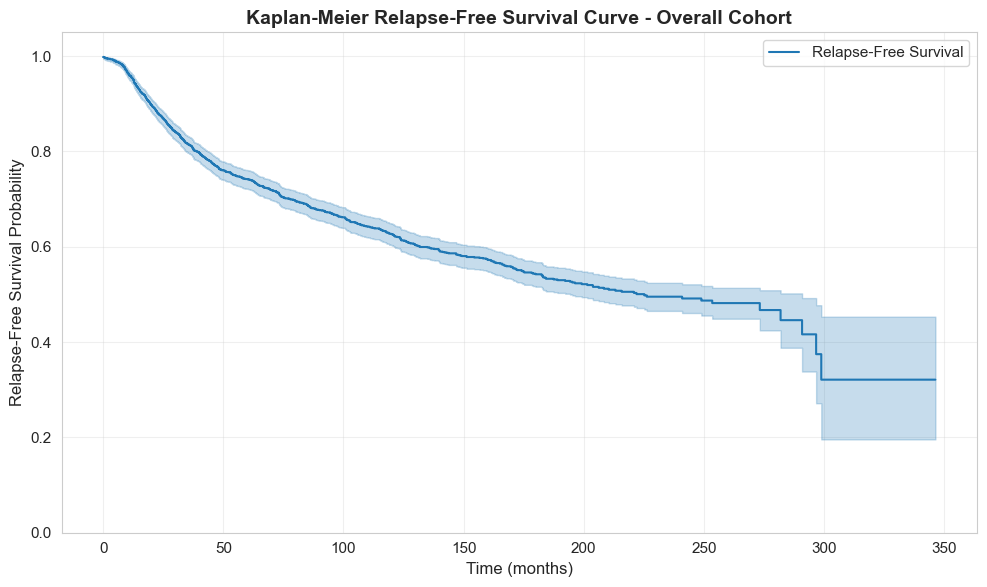

In [16]:
# Check if RFS data is available
if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    print("="*60)
    print("RELAPSE-FREE SURVIVAL (RFS) KAPLAN-MEIER ANALYSIS")
    print("="*60)
    
    # Fit KM on RFS data
    km_rfs = KaplanMeierFitter(label="Relapse-Free Survival")
    
    # Ensure survival times are non-negative
    df_rfs = df[df['duration_rfs'].notna()].copy()
    df_rfs['duration_rfs'] = df_rfs['duration_rfs'].clip(lower=0)
    
    print(f"\nRFS data available: {len(df_rfs)} patients")
    print(f"Events (recurrences): {df_rfs['event_rfs'].sum()} ({df_rfs['event_rfs'].mean()*100:.1f}%)")
    print(f"Censored (no recurrence): {(df_rfs['event_rfs'] == 0).sum()} ({(df_rfs['event_rfs'] == 0).mean()*100:.1f}%)")
    
    # Fit the KM estimator
    km_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    # Plot the survival curve
    fig, ax = plt.subplots(figsize=(10, 6))
    km_rfs.plot_survival_function(ax=ax, ci_show=True)
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Relapse-Free Survival Probability', fontsize=12)
    ax.set_title('Kaplan-Meier Relapse-Free Survival Curve - Overall Cohort', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    
else:
    print("RFS data not available in the dataset.")
    print("Only Overall Survival (OS) analysis will be performed.")

1-year RFS has a probability of 95.5%, with excellent short term disease control with still very few reaccurances. After 3 years, RFS probability has decreased to 81.3%, after 5 years to 74.2% (over 3/4 of patients are still disease free after inital diagnosis and treatment), and after 10 RFS probability is 62.7%, with a **majority of patients still cancer free**. 

The relapse-free survival curve experences a sharper drop within the first 50 months, from ~1.0 to ~0.78, suggesting a higher risk of relaps during the early stages. Beyond this point, the curve flattens, indicating a slower rate of decline in relapse-free probability over long term. The relapse-free survival curve falls to 0.5 between 200 and 250 months. After 270 months, the probability of remaining relapse-free declines further to around 0.3.

Clinical meaning:
Interventions aimed at reducing recurrence should target earlier time windows (first 5–10 years).

### 6.2.1 Median Relapse-Free Survival Time

In [17]:
median_rfs_time = km_rfs.median_survival_time_
print(f"\nMedian relapse-free survival time: {median_rfs_time:.1f} months")
    
horizons = [12.0, 24.0, 36.0, 60.0, 120.0]  # months
rows = []
for t0 in horizons:
    rmst_val = restricted_mean_survival_time(km_rfs, t=t0)
    rows.append({"t0 [months]": int(t0), "RMST [months]": round(float(rmst_val), 1)})
    
rmst_table_rfs = pd.DataFrame(rows)
print("\nRestricted Mean Relapse-Free Survival Time (RMST):")
print(rmst_table_rfs.to_string(index=False))


Median relapse-free survival time: 225.2 months

Restricted Mean Relapse-Free Survival Time (RMST):
 t0 [months]  RMST [months]
          12           11.8
          24           22.7
          36           32.8
          60           51.3
         120           92.1


The Median RFS time is 225.2 months (~18.8 years), which is an extremely favorable outcome, as 50% of patients have remained relapse free for almost 20 years. For a typical patient in thie cohort, the risk of reaccurance is low enough that it takes almost 2 decades for the cumulative reaccurance rate to reach 50%. 

The RMST provides a deeper look at cancer reaccurance average rates in key time periods. AT 1 year, the average relapse free time is 11.8 months, showing excellent short term disease control. At 5 years, the average relapse free time is 51.3 months (out of 60), with 8.7 months of average survival time lost due to reaccurance in that period. At 10 years, the average relapse free time is 92.1 months (out of 120), with 27.9 months of average survival time lost due to reaccurance. This shows that this cohort has an excellent long-term prognosis, with high relapse-free survival times. While reaccurances do happen, they are not a frequent event for the majority of patients, indicating initial treatment is a long-lasting benefit. 

## 6.3 Cumulative Incidence Curves and Nelson-Aalen Cumulative Hazard


Cumulative Incidence of Death is a direct measure of mortality. It represents the percentage of patients who have passed away by a certain time.

Cumulative Hazard measures the total accumulated risk of death over time, but is less intuitive than probability, its rate of change reveals when the risk is highest.

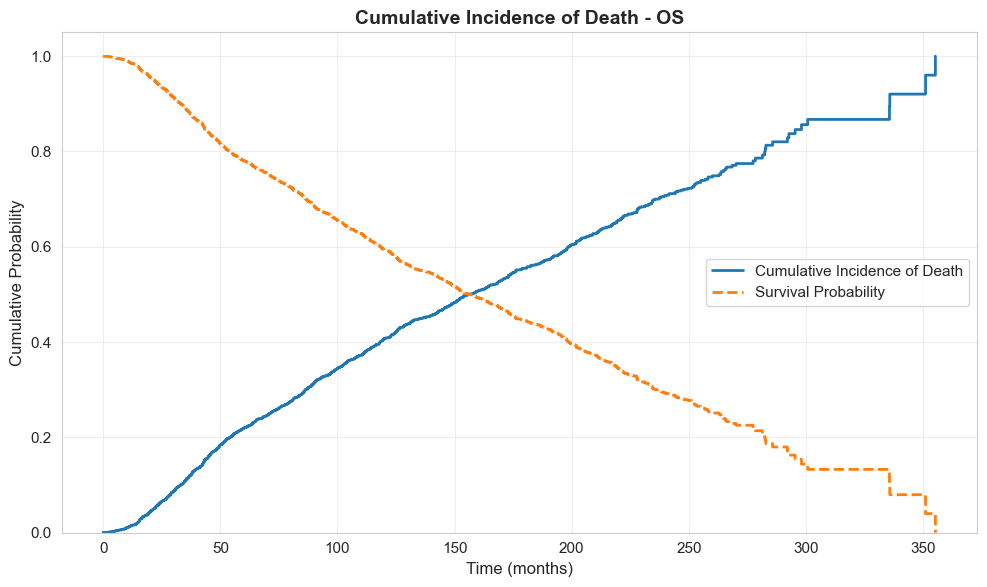

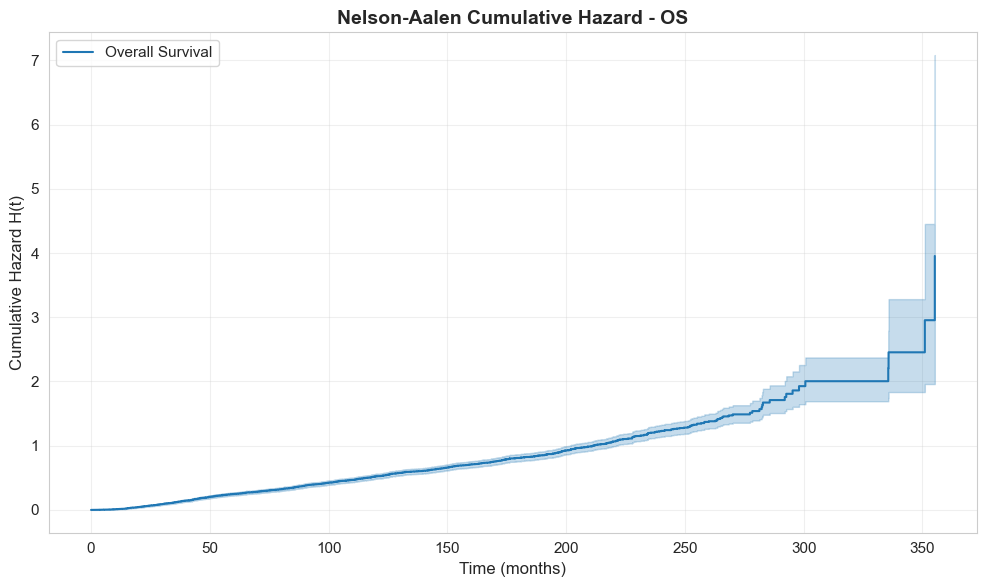

In [18]:
# Cumulative Incidence Curves - OS
# Cumulative incidence = 1 - Survival probability
survival_func = km.survival_function_
survival_probs = survival_func.iloc[:, 0].values
cumulative_incidence = 1 - survival_probs
times = survival_func.index.values

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(times, cumulative_incidence, where='post', label='Cumulative Incidence of Death', linewidth=2)
ax.step(times, survival_probs, where='post', label='Survival Probability', linewidth=2, linestyle='--')
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Cumulative Incidence of Death - OS', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


#  Nelson-Aalen Cumulative Hazard - OS
naf_os = NelsonAalenFitter(label="Overall Survival")
naf_os.fit(durations=df_km['duration_os'], event_observed=df_km['event_os'])

fig, ax = plt.subplots(figsize=(10, 6))
naf_os.plot_cumulative_hazard(ax=ax, ci_show=True)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Cumulative Hazard H(t)', fontsize=12)
ax.set_title('Nelson-Aalen Cumulative Hazard - OS', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




The Culmulative Incidence of Death (Overall Survival - OS) shows after 1 year, the cumulative risk of death is only 1.5%, indicating excellent short term surival of patients. After 5 years, the risk is 22.0%, meaning the survival rate is 78%, suggesting a favorable meduim term prognosis for the majority of patients. After 10 years, the risk rises to 40.7%, still with a majority of patients surviving. The Median of OS is around 161 months, where the lines intersect on the graph. The very long term outlook, by 300 months (25 years), shows the cumulative indicence of death to be 85.6% and at 350 months (~29 years) it is 92%, common in an aging population. 

The Nelson–Aalen cumulative hazard curve showed a gradual accumulation of mortality risk over time, with a sharp increase in hazard after ~300 months; widening confidence intervals reflect fewer patients remaining in follow-up at later time points. This indicates the risk of death is not decreasing over time for the surviving patients, with the risk accumulation accelerating in later years. While risk of cancer can diminish over time, the overall risk of death remains persistant/gorws, indicating late reaccurance (relapsing years after initial diagnosis) or more likely, competing mortality, as age and corresponding risks increase and become a significant factor of death. 

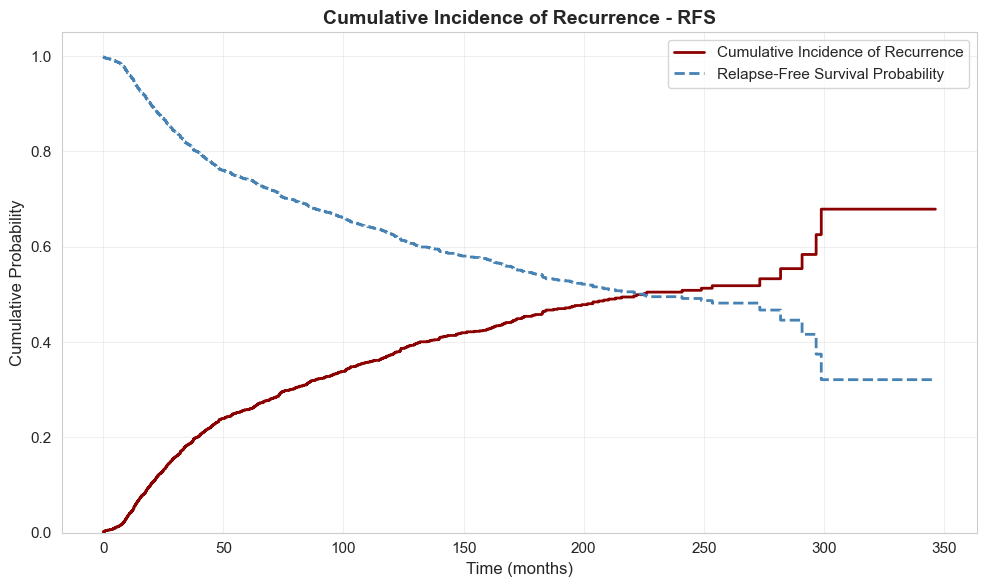

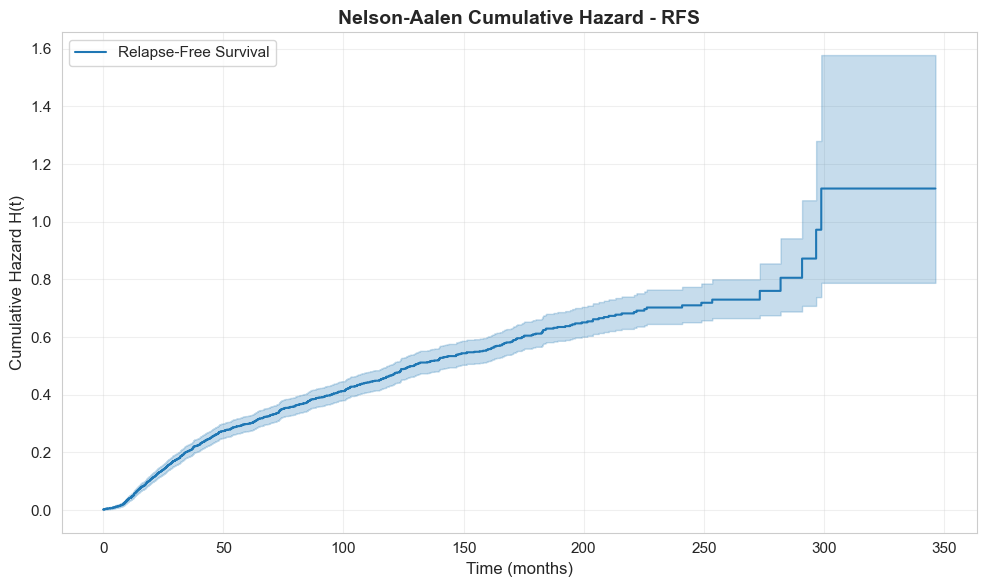

In [19]:
# Cumulative Incidence and Nelson-Aalen - RFS

if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    df_rfs = df[df['duration_rfs'].notna()].copy()
    df_rfs['duration_rfs'] = df_rfs['duration_rfs'].clip(lower=0)
    
    # Fit KM for RFS if not already fitted 
    try:
        km_rfs
    except NameError:
        km_rfs = KaplanMeierFitter(label="Relapse-Free Survival")
        km_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    # Cumulative Incidence for RFS
    survival_func_rfs = km_rfs.survival_function_
    survival_probs_rfs = survival_func_rfs.iloc[:, 0].values
    cumulative_incidence_rfs = 1 - survival_probs_rfs
    times_rfs = survival_func_rfs.index.values
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.step(times_rfs, cumulative_incidence_rfs, where='post', label='Cumulative Incidence of Recurrence', 
            linewidth=2, color='darkred')
    ax.step(times_rfs, survival_probs_rfs, where='post', label='Relapse-Free Survival Probability', 
            linewidth=2, linestyle='--', color='steelblue')
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Cumulative Probability', fontsize=12)
    ax.set_title('Cumulative Incidence of Recurrence - RFS', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    # Nelson-Aalen for RFS
    naf_rfs = NelsonAalenFitter(label="Relapse-Free Survival")
    naf_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    naf_rfs.plot_cumulative_hazard(ax=ax, ci_show=True)
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Cumulative Hazard H(t)', fontsize=12)
    ax.set_title('Nelson-Aalen Cumulative Hazard - RFS', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("RFS data not available.")


Early in follow-up, few relapses occurred, but the rate rose gradually. By about 300 months, the cumulative incidence of recurrence reached ~68%, meaning nearly two-thirds of patients had relapsed. At the same time, relapse-free survival dropped to ~32%. The Nelson–Aalen curve showed a steadily increasing cumulative hazard, indicating that the risk of recurrence continues to build over time and does not level off.

- Clearly shows how recurrence probability builds: ~0 at baseline → ~0.5 around ~220 months → ~0.68 at ~300 months.
- Early-to-mid follow-up is the highest-action window for preventing recurrence; however, risk persists long-term.

## 6.4 Subgroup Comparisons with Log-Rank Tests




In [20]:
#Helper function for subgroup Kaplan-Meier curves with log-rank tests
def km_by_group(df, group_col, time_col='duration_os', event_col='event_os', 
                title=None, min_group_size=5, label_map=None):

    d = df[[group_col, time_col, event_col]].dropna()
    groups = [g for g in sorted(d[group_col].unique()) 
              if len(d[d[group_col] == g]) >= min_group_size]
    
    if len(groups) < 2:
        print(f"Not enough groups (min={min_group_size}) for {group_col}")
        return None, None
    
    # Plot KM curves
    fig, ax = plt.subplots(figsize=(10, 6))
    for g in groups:
        d_g = d[d[group_col] == g]
        label = label_map.get(g, str(g)) if label_map else str(g)
        km = KaplanMeierFitter(label=label)
        km.fit(durations=d_g[time_col], event_observed=d_g[event_col])
        km.plot_survival_function(ax=ax, ci_show=True)
    
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Survival Probability', fontsize=12)
    ax.set_title(title or f'Survival by {group_col}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    # Log-rank test
    if len(groups) == 2:
        d1, d2 = d[d[group_col] == groups[0]], d[d[group_col] == groups[1]]
        result = logrank_test(d1[time_col], d2[time_col],
                             event_observed_A=d1[event_col], event_observed_B=d2[event_col])
        test_type = "Log-rank"
    else:
        result = multivariate_logrank_test(d[time_col], groups=d[group_col], 
                                          event_observed=d[event_col])
        test_type = "Multigroup log-rank"
    
    p = result.p_value
    sig = "Highly significant" if p < 0.001 else "Very significant" if p < 0.01 else \
          "Significant" if p < 0.05 else "Not significant"
    print(f"{test_type} test: p = {p:.6f} ({sig})")
    
    return fig, result





### 6.4.1 Estrogen Receptor (ER) Status


ER Status distribution:
ER Status
Positive    1507
Negative     473
Name: count, dtype: int64


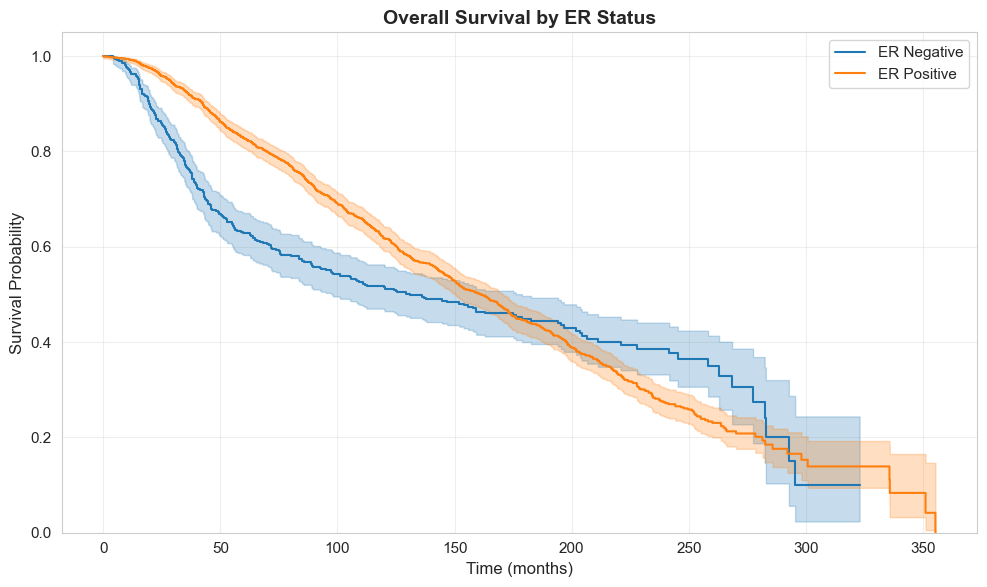

Log-rank test: p = 0.035047 (Significant)


In [21]:
# ER Status Comparison - Overall Survival (OS)
if 'ER Status' in df.columns:
    # Check value counts
    print(f"\nER Status distribution:")
    print(df['ER Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'ER Positive', 'Negative': 'ER Negative'}
    km_by_group(df, 'ER Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by ER Status', label_map=label_map)

else:
    print("ER Status column not found in dataset")


Patients with ER-positive tumors had significantly longer median survival (161.1 months) compared with ER-negative patients (130.9 months). This suggests that ER status is a prognostic factor, with ER-positive tumors associated with more favorable outcomes and a clear survival advantage in the medium term. At 60 months (5 years), the survival difference is the most pronounced with a survival rate of 82.8% for ER positive patients and 62.9% for ER negative patients, highlighting the more aggressive nature of ER negative cancer in the inital years after diagnosis. 

Overall, **ER negative tumors** are more aggressive upfront, with a higher mortality rate in the first 5-10 years after diagnosis. Patients who survuve this inital high risk period may have a lower risk of reaccurance later on. **ER positive tumors** are less aggressive and more responsive to endocrine therapy, with a higher medium term survival. However, they carry a low-level risk of late reaccurance around 5-10 years after diagnosis, indicating an ongoing risk combined with mortality from other causes in an aging population. 


### 6.4.2 Human Epidermal growth factor Receptor 2 (HER2) Status


HER2 Status distribution:
HER2 Status
Negative    1732
Positive     247
Name: count, dtype: int64


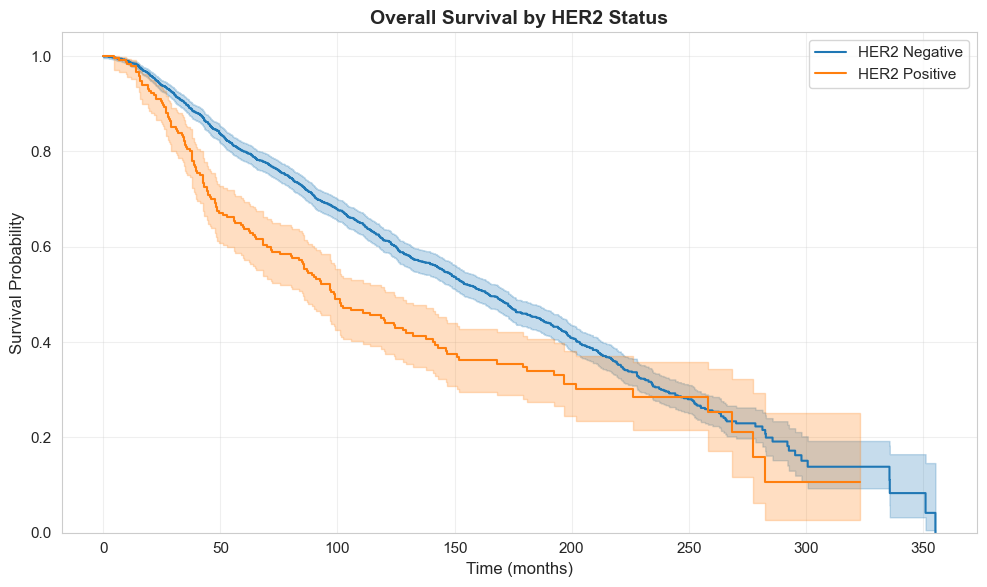

Log-rank test: p = 0.000009 (Highly significant)


In [22]:
# HER2 Status Comparison - Overall Survival (OS)
if 'HER2 Status' in df.columns:
    #Check value counts
    print(f"\nHER2 Status distribution:")
    print(df['HER2 Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'HER2 Positive', 'Negative': 'HER2 Negative'}
    km_by_group(df, 'HER2 Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by HER2 Status', label_map=label_map)
    
else:
    print("HER2 Status column not found in dataset")


Overall survival differed significantly by HER2 status (log-rank p = 0.000009). The median survival differed vastly between HER2 Positive patients (survival of 98.7 months, roughly 8.2 years) and HER2 negative patients (survival of 164.6 months, roughly 13.7 years), differing about 5 years. After 5 years from diagnosis, the survival rate for HER2 negative patients is 80% and HER2 positive patients is 64.2%, with a 16% differece in survival. HER2-negative patients demonstrated substantially better survival, with higher survival probability throughout the entire follow-up period. HER2-positive patients showed poorer long-term survival. However, while the curves appear to converge after 20 years, this is due to the small number if patients remaining and is not clinically meaningful. 

### 6.4.3 Progesterone Receptor (PR) Status


PR Status distribution:
PR Status
Positive    1040
Negative     939
Name: count, dtype: int64


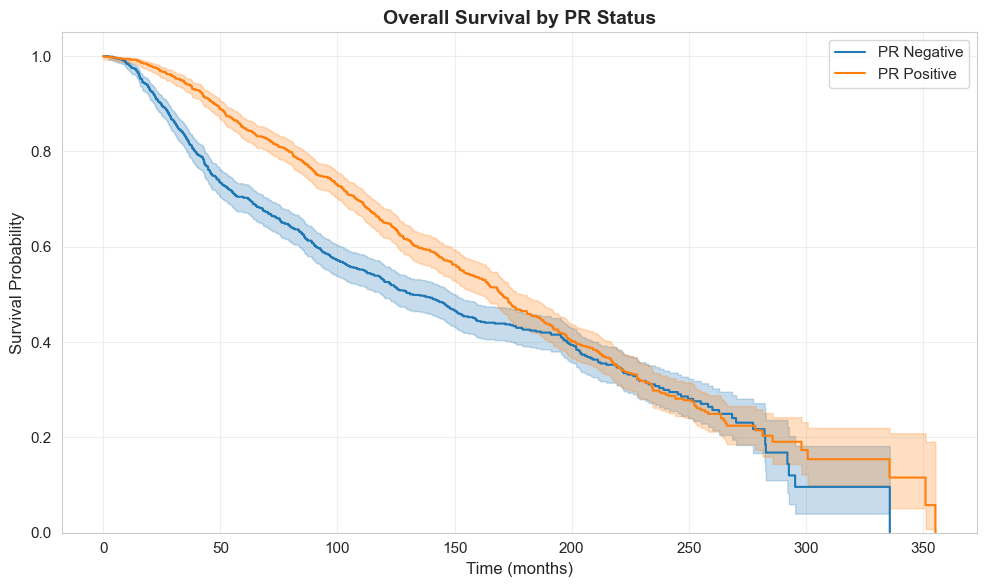

Log-rank test: p = 0.000083 (Highly significant)


In [23]:
# PR Status Comparison - Overall Survival (OS)
if 'PR Status' in df.columns:
    # Check value counts
    print(f"\nPR Status distribution:")
    print(df['PR Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'PR Positive', 'Negative': 'PR Negative'}
    km_by_group(df, 'PR Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by PR Status', label_map=label_map)
else:
    print("PR Status column not found in dataset")


Overall survival differed significantly according to PR status (log-rank p = 0.000083). Patients with PR-positive tumors had a consistently higher probability of survival compared with PR-negative patients over the entire observation period. The median survival time for PR positive patients is 170.3 months (roughly 14.2 years) as compared to PR negative patients of 132.2 months (roughly 11 years), with a survival advantage of 3 years. After 60 months (5 years), the survival gap is pronounced, with the survival rate for PR positive patients being 84.9% while PR negative patients being 70.3%, showing the aggressive nature of PR negative cancer in the medium term. 

PR-positive tumors generally indicate that the cancer is hormone-driven and may respond better to hormonal (endocrine) therapy, such as tamoxifen or aromatase inhibitors. This is also often correlated to ER positivity, another tumor type that is sensitive to hormone signaling. 

The convergence of the survival curves aftr 15-20 years is a phenomenon that reveals PR positive tumors ot carry a low level risk of reaccurance in the long term while PR negative tumor patients who survive in the short term have a lower risk of events in the long term. 

### 6.4.4 PAM50 Molecular Subtypes


PAM50 Subtype distribution:
Pam50 + Claudin-low subtype
LumA           700
LumB           475
Her2           224
claudin-low    217
Basal          209
Normal         148
NC               6
Name: count, dtype: int64


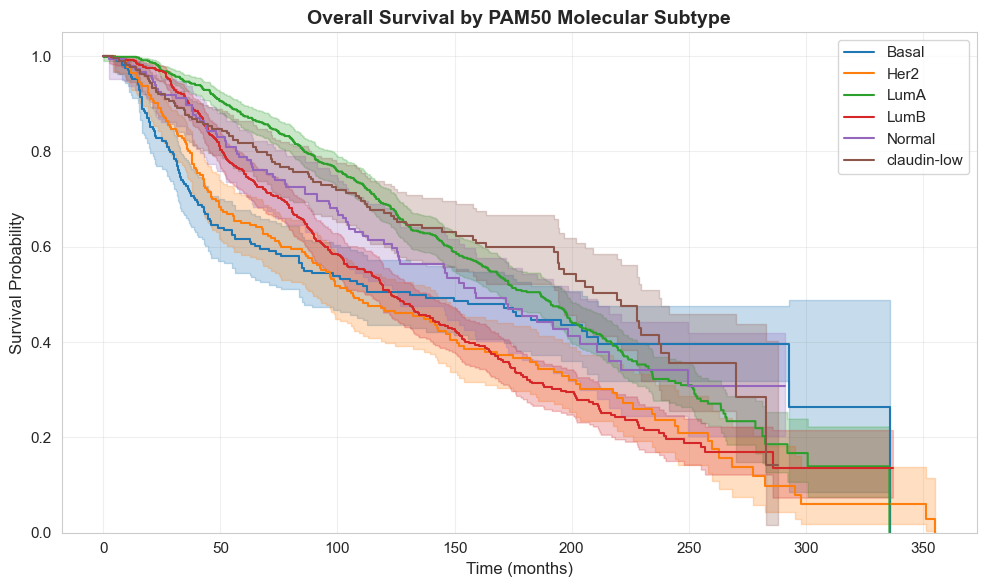

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [24]:
# PAM50 Molecular Subtype Comparison - Overall Survival (OS)
if 'Pam50 + Claudin-low subtype' in df.columns:
    # Check value counts
    print(f"\nPAM50 Subtype distribution:")
    print(df['Pam50 + Claudin-low subtype'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df, 'Pam50 + Claudin-low subtype', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by PAM50 Molecular Subtype', 
                min_group_size=10)  # Require at least 10 patients per subtype
    
else:
    print("PAM50 + Claudin-low subtype column not found in dataset")


Survival varied significantly across PAM50 molecular subtypes (multigroup log-rank p < 0.001). The most favorable prognosis subtypes are **Claudin-low** with a median survival of 219.2 months, followed by **Luminal A** subtype with a median survival of 186.6 months, with the highest 5 year survival rate at 87.5%. Intermediate prognosis subtypes are Normal-like (median survival of 159.2 months) and No Class (NC) (median survival of 170.3 months). However, the poor prognosis subtypes by almost a 40-70 month difference are Basal-like (median survival of 130.9 months), Luminal B (median survival of 123.0 months), and lastly Her2-Enriched (median survival of 106.6 months).

There is a clear hierarchy of survival within these subtypes, with the highest survival rates in Claudin-low and Luminal A and the significantly poorer survival rates in Basal-like, Luminal B, and Her2-enriched subtypes. The poorer prognosis of Luminal B tumors justifies a more aggressive treatment (chemotherapy) compared to Luminal A tumors. Similarly, Her2-enriched and Basal-like subtypes require more intensive chemotherapy regimins and targeted therapies to combat their aggressive nature. However, this data does show that better prognosis, such as in Luminal A, still stands a risk as their survival prognosis declines after 10 years indicating a risk of late reaccurance in a hormone sensitive disease. 




### 6.4.5 Neoplasm Histologic Grade (Tumor Grade)


Neoplasm Histologic Grade distribution:
Neoplasm Histologic Grade
1.0    169
2.0    771
3.0    953
Name: count, dtype: int64


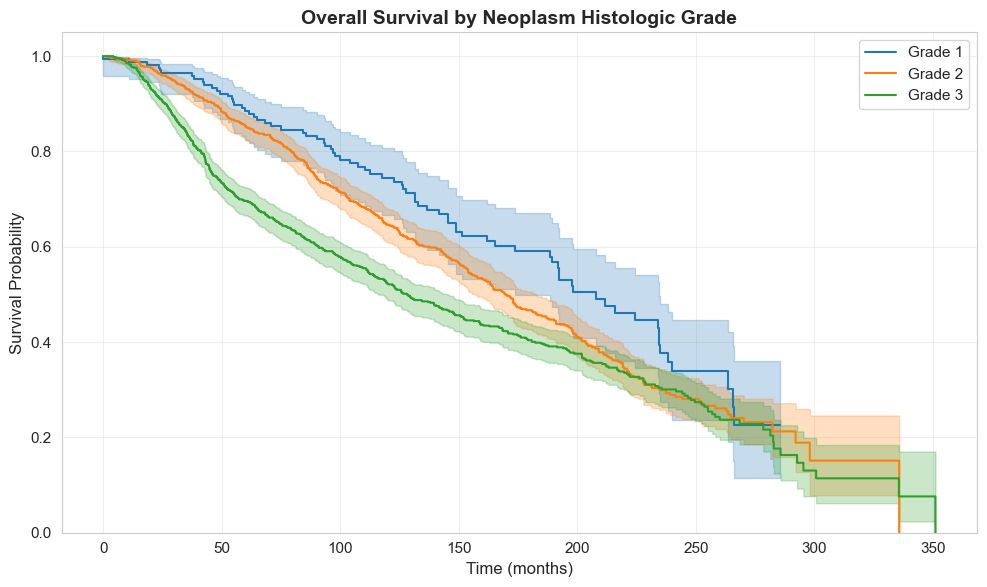

Multigroup log-rank test: p = 0.000002 (Highly significant)


In [25]:
# Neoplasm Histologic Grade Comparison - Overall Survival (OS)
if 'Neoplasm Histologic Grade' in df.columns:
    # Check value counts
    print(f"\nNeoplasm Histologic Grade distribution:")
    print(df['Neoplasm Histologic Grade'].value_counts().sort_index())
    
    label_map = {1.0: 'Grade 1', 2.0: 'Grade 2', 3.0: 'Grade 3'}
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df, 'Neoplasm Histologic Grade', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Neoplasm Histologic Grade',
                label_map=label_map)
    
else:
    print("Neoplasm Histologic Grade column not found in dataset")


The OS by Neoplasm Histologic Grade results prove that the grade of tumors directly correlates with their clinical aggressiveness, with very different median survivals: Grade 1 (low grade) has 208 months, dropping to 169 months for Grade 2 (intermediate grade), then again in Grade 3 (high grade) tumors to 128 months. The 5 year survival benchmark highlights each grades differnces in the medium term prognosis, with Grade 1 and Grade 2 having exellent 5 year survival rates (88.5% and 85.2%), the rate is much lower for Grade 3 (69.6%). This gap widens at the 10 year benchmark, with almost 3/4 of Grade 1 patients surviving compared to just half of Grade 3 patients. 

This provides **strong evidence to justify treatment intensity**, as the poorer survival rate of Grade 3 is reason for consideration of chemotherapy. However, the prognosis for Grade 1 patients provides reason to de-escalate therapy or avoid chemotherapy. 


### 6.4.6 Lymph Node Examined Positive 


Lymph Node Group distribution:
lymph_node_group
0 nodes (N0)        993
1-3 nodes (N1)      604
4+ nodes (N2/N3)    307
Other                76
Name: count, dtype: int64


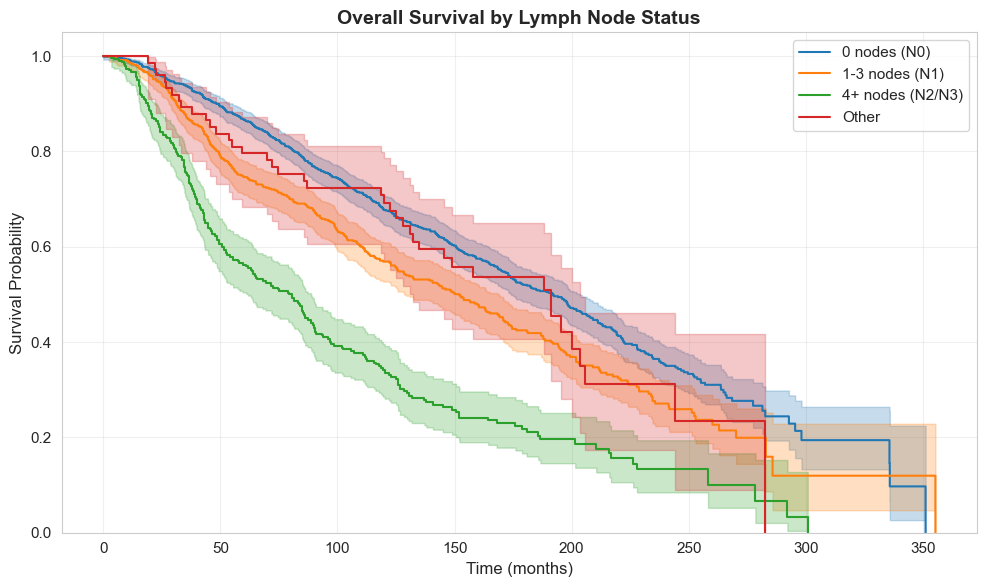

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [26]:
# Lymph Node Status Comparison - Overall Survival (OS)
if 'Lymph nodes examined positive' in df.columns:
    # Create a new column with clinically relevant lymph node status groups
    conditions = [
        (df['Lymph nodes examined positive'] == 0),
        (df['Lymph nodes examined positive'] >= 1) & (df['Lymph nodes examined positive'] <= 3),
        (df['Lymph nodes examined positive'] >= 4)
    ]
    choices = ['0 nodes (N0)', '1-3 nodes (N1)', '4+ nodes (N2/N3)']
    df['lymph_node_group'] = np.select(conditions, choices, default='Other')
    
    # Check value counts of the new groups
    print(f"\nLymph Node Group distribution:")
    print(df['lymph_node_group'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test using the new grouping column
    km_by_group(df, 'lymph_node_group', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Lymph Node Status')
else:
    print("Lymph nodes examined positive column not found in dataset")


The OS by Lymph Node Status proves this variable is a significant predictor, with an extremely low p value (p < 0.0001) and a clear decrease in survival as the number of lymph nodes increases (once cancer has spread to lymph nodes, the worse the long term prognosis). 

The median survival of patients with 0 positive lymph nodes is 191.9 months, dropping to 152.1 months for patients with 1-3 positive lymph nodes, then again to 80.4 months (dropping ~6 years) for patients with 4+ positive lymph nodes. The 5 year survival benchmark illustrates this escalting risk, as 0 positive lymph's rate is excellent at 86.7%, then falling to 74.6% for 2-3 positive lymph nodes, then to a concerning 56.2% for 4+ positive lymph nodes (meaning nearly half of the patients have passed away by the 5 year mark).

This means that A patient's N-status is **one of the most powerful pieces of information a clinician has to determine prognosis and communicate risk to a patient**, justifying intensive treatment for the patients with more affected lymph nodes and increase the ikelihood of surgery and extra radiation therapy. 

### 6.4.7 Tumor Size 


Tumor Size Quartile distribution:
tumor_size_quartile
Q2               523
Q1 (Smallest)    501
Q3               496
Q4 (Largest)     435
Name: count, dtype: int64


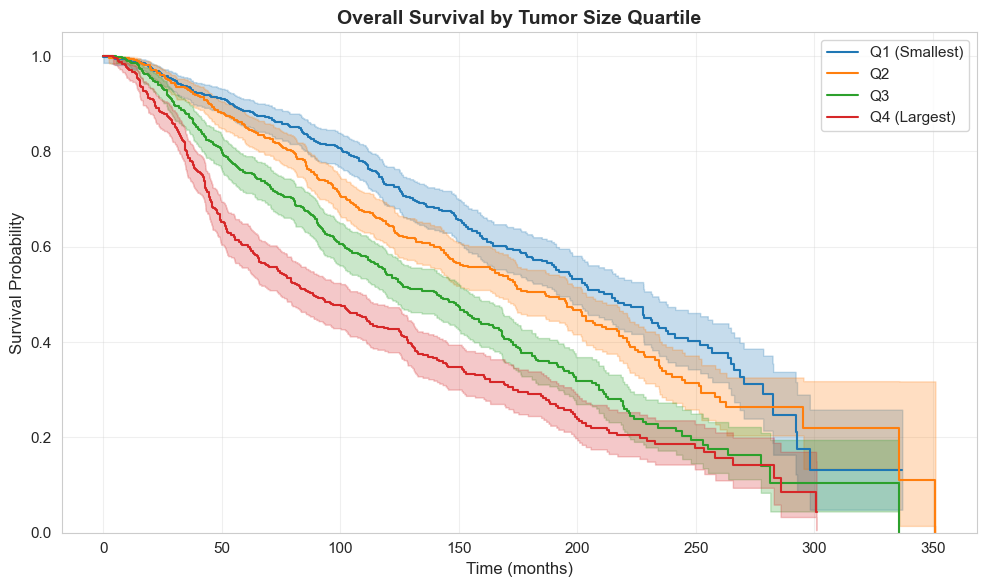

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [27]:
# Tumor Size Comparison - Overall Survival (OS)
if 'Tumor Size' in df.columns:
    try:     #grouping 
        df['tumor_size_quartile'] = pd.qcut(df['Tumor Size'], q=4, 
                                            labels=["Q1 (Smallest)", "Q2", "Q3", "Q4 (Largest)"])
        
        # Check value counts of the new groups
        print(f"\nTumor Size Quartile distribution:")
        print(df['tumor_size_quartile'].value_counts())
        
        # Create Kaplan-Meier curves and log-rank test using the new quartile column
        km_by_group(df, 'tumor_size_quartile', 
                    time_col='duration_os', event_col='event_os',
                    title='Overall Survival by Tumor Size Quartile')
    except Exception as e:
        print(f"Could not create quartiles for Tumor Size. Error: {e}")
else:
    print("Tumor Size column not found in dataset")


The OS by Tumor size proves it is another highly significant predictor, with an extremely low p-value and a clear decrease in survival as tumor size increases, proving is correlation to a patients long term prognosis. The median survival in Q1 (smallest quartile of tumor size) is excellent at 214.4 months, progressively worsening in each quartile until 88.7 months for Q4 (largest tumor sizes). This difference of over 10 years is highly concerning, highlighted especially at the 5 year survival benchmark where Q1 has a survival rate of 88.5% (excellent) and drops to 60.4% for Q4, meaning nearly 40% of patients die within 5 years. The 10 year survival benchmark widens this survival gap, with Q1 having 72.9% survival rate but Q4 hvaing a 42.6% survival rate. 

Tumor size is a critical compoennt of determinign a patients stage and overall risk, providing strong evidence to guide the intensity of treatment as Q1 tumors could be managed with less intensive treatment but larger size groups should be considered a high risk situation and considered for more invasice, intensive treatments. Detecting cancers when they are small (in Q1) translates directly into a massive survival benefit for patients.

### 6.4.8 Tumor Stage


Tumor Stage distribution:
(Note: This variable has 514 missing values which will be excluded)
Tumor Stage
0.0     12
1.0    501
2.0    825
3.0    118
4.0     10
Name: count, dtype: int64


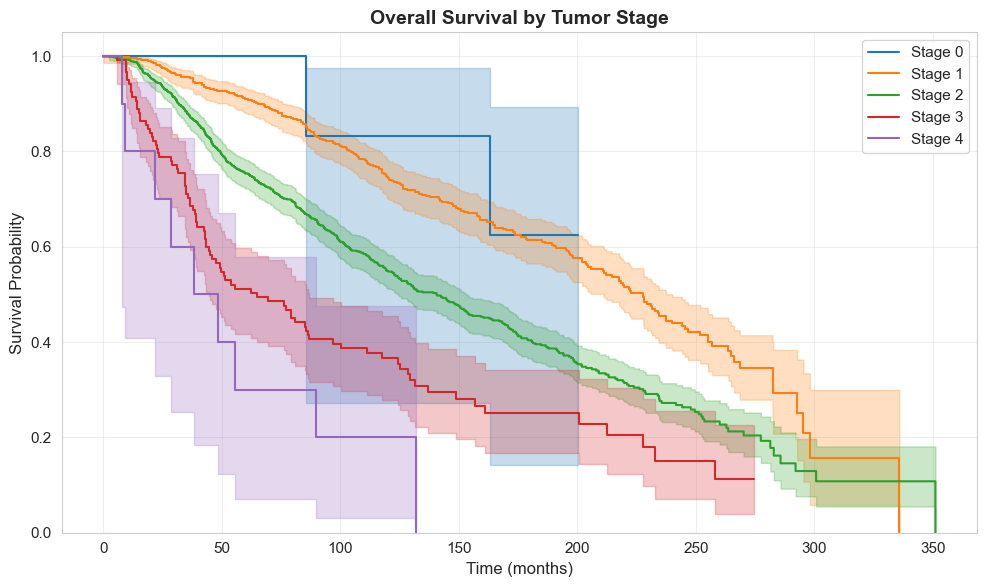

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [28]:
# Tumor Stage Comparison - Overall Survival (OS)
if 'Tumor Stage' in df.columns:
    # Check value counts
    print(f"\nTumor Stage distribution:")
    print(f"(Note: This variable has {df['Tumor Stage'].isnull().sum()} missing values which will be excluded)")
    print(df['Tumor Stage'].value_counts().sort_index())
    
    # Create a label map for a clearer legend
    unique_stages = sorted(df['Tumor Stage'].dropna().unique())
    label_map = {stage: f'Stage {int(stage)}' for stage in unique_stages}
    
    # Create Kaplan-Meier curves and log-rank test
    km_by_group(df, 'Tumor Stage', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Tumor Stage',
                label_map=label_map)
else:
    print("Tumor Stage column not found in dataset")


The OS by Tumor Stage is a final significant and extremely powerful indicator, with a low p-value and a clear stepwise decrease in survival as tumor stage at diagnosis increases. The median survival in Stage 0 is so long that it cannot be calculated by the data and Stage 1 is 227.8 months, both with excellent prognosis. Stage 2 remains with a good prognosis, but a noticable drop occurs to 140.6 months. By Stage 3/4, the median survival plummets to 64.9 months then again to 38.1 months. The 5 year survival benchmark reillustrates the same trendws, with survival rates in Stage 0 (100%), Stage 1 (90.9%), and Stage 2 (75.4%) all remaining high, while Stage 3 drops to 51.2% and Stage 4 plummets to 30% of patients remaining alive. 

This justifies Stage 3 treatment plans being more intensive (often combinations of chemo, surgery, radiation) in later stages to combat the more aggressive tumors while Stage 4 is considered "incurable" with a goal of managing symptoms/prolonging life. 


### Analysis for RFS for different treatments - LEAVE/ REMOVE ?



CHEMOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Chemotherapy distribution:
Chemotherapy
No     1567
Yes     412
Name: count, dtype: int64


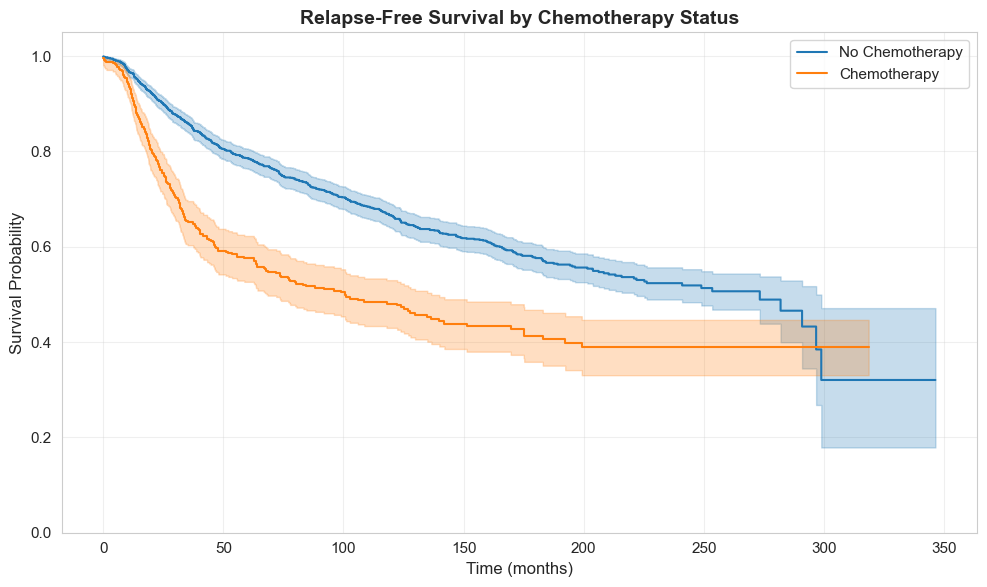

Log-rank test: p = 0.000000 (Highly significant)

HORMONE THERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Hormone Therapy distribution:
Hormone Therapy
Yes    1216
No      763
Name: count, dtype: int64


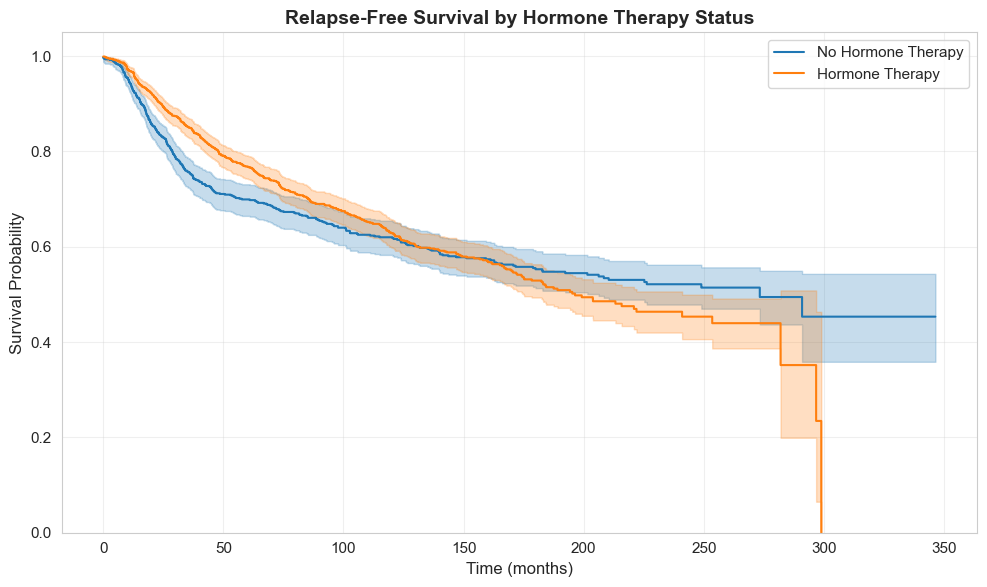

Log-rank test: p = 0.746255 (Not significant)

RADIOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Radio Therapy distribution:
Radio Therapy
Yes    1173
No      806
Name: count, dtype: int64


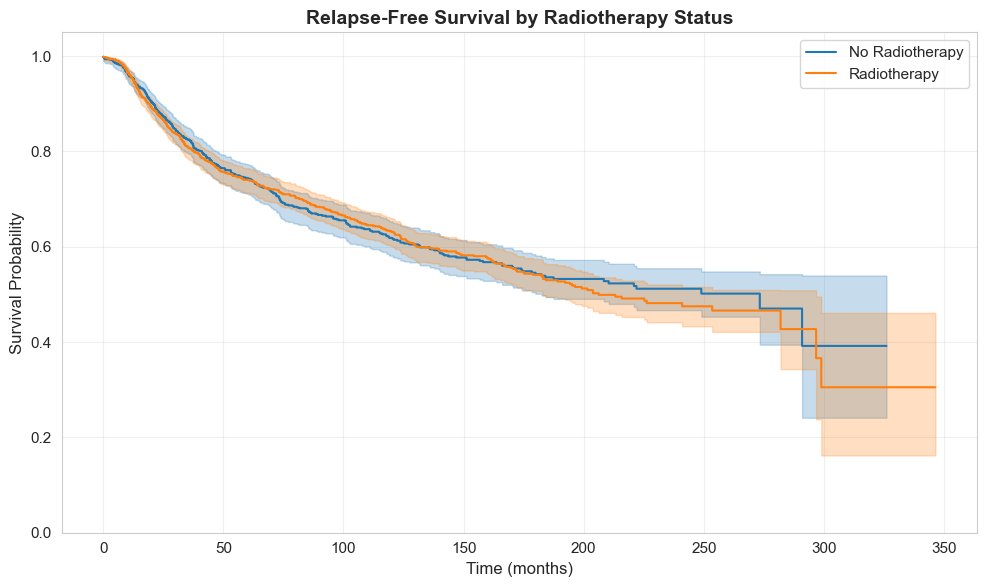

Log-rank test: p = 0.823569 (Not significant)


In [29]:
# 4.4.6 Treatment Comparisons - Relapse-Free Survival (RFS)


# Check if RFS data is available
if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    # Chemotherapy
    if 'Chemotherapy' in df.columns:
        print("\n" + "="*60)
        print("CHEMOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nChemotherapy distribution:")
        print(df['Chemotherapy'].value_counts())
        label_map = {'Yes': 'Chemotherapy', 'No': 'No Chemotherapy'}
        km_by_group(df, 'Chemotherapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Chemotherapy Status', label_map=label_map)
    else:
        print("Chemotherapy column not found in dataset")
    
    print("\n" + "="*60)
    
    # Hormone Therapy
    if 'Hormone Therapy' in df.columns:
        print("="*60)
        print("HORMONE THERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nHormone Therapy distribution:")
        print(df['Hormone Therapy'].value_counts())
        label_map = {'Yes': 'Hormone Therapy', 'No': 'No Hormone Therapy'}
        km_by_group(df, 'Hormone Therapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Hormone Therapy Status', label_map=label_map)
    else:
        print("Hormone Therapy column not found in dataset")
    
    print("\n" + "="*60)
    
    # Radio Therapy
    if 'Radio Therapy' in df.columns:
        print("="*60)
        print("RADIOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nRadio Therapy distribution:")
        print(df['Radio Therapy'].value_counts())
        label_map = {'Yes': 'Radiotherapy', 'No': 'No Radiotherapy'}
        km_by_group(df, 'Radio Therapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Radiotherapy Status', label_map=label_map)
    else:
        print("Radio Therapy column not found in dataset")
else:
    print("RFS data (event_rfs, duration_rfs) not available for treatment comparisons")


AGE AT DIAGNOSIS COMPARISON - OVERALL SURVIVAL (OS)

Age Group distribution:
Age_Group
<50 years       424
50-70 years    1025
>70 years       531
Name: count, dtype: int64


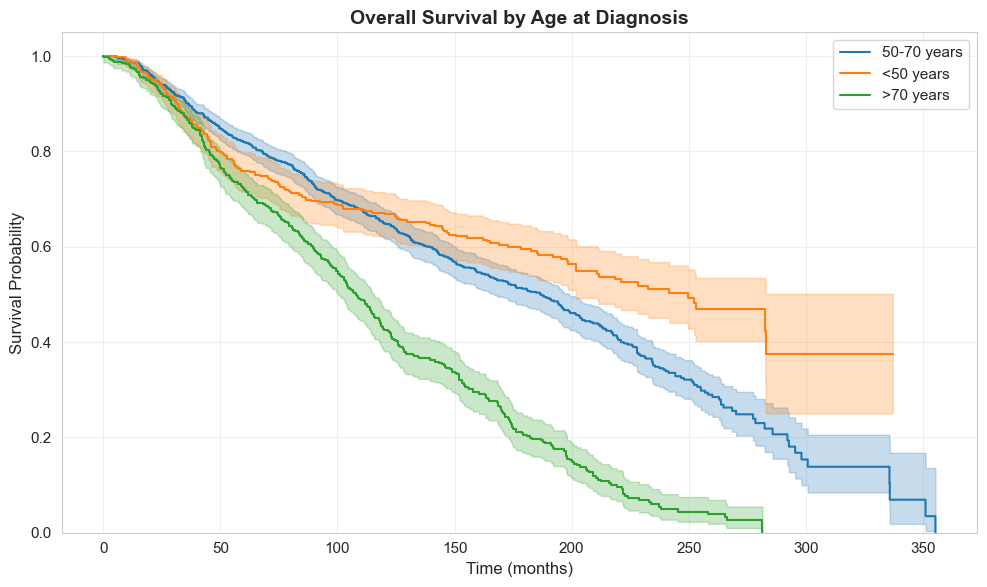

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [30]:
# 4.4.8 Age at Diagnosis Comparison - Overall Survival (OS)

if 'Age at Diagnosis' in df.columns:
    print("="*60)
    print("AGE AT DIAGNOSIS COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Create age groups
    df_age = df.copy()
    df_age['Age_Group'] = pd.cut(df_age['Age at Diagnosis'], 
                                  bins=[0, 50, 70, 100], 
                                  labels=['<50 years', '50-70 years', '>70 years'])
    
    # Check value counts
    print(f"\nAge Group distribution:")
    print(df_age['Age_Group'].value_counts().sort_index())
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df_age, 'Age_Group', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Age at Diagnosis', 
                min_group_size=10)
else:
    print("Age at Diagnosis column not found in dataset")


A significant difference in overall survival was observed across age groups (multigroup log-rank test p < 0.001). Patients diagnosed under 50 years demonstrated the best survival outcomes across the follow-up period. Patients aged 50–70 years showed intermediate survival, while those diagnosed over 70 years had markedly poorer survival. These findings suggest that younger patients experience more favorable long-term survival following breast cancer diagnosis compared with older individuals.

INFERRED MENOPAUSAL STATE COMPARISON - OVERALL SURVIVAL (OS)

Menopausal State distribution:
Inferred Menopausal State
Post    1555
Pre      424
Name: count, dtype: int64


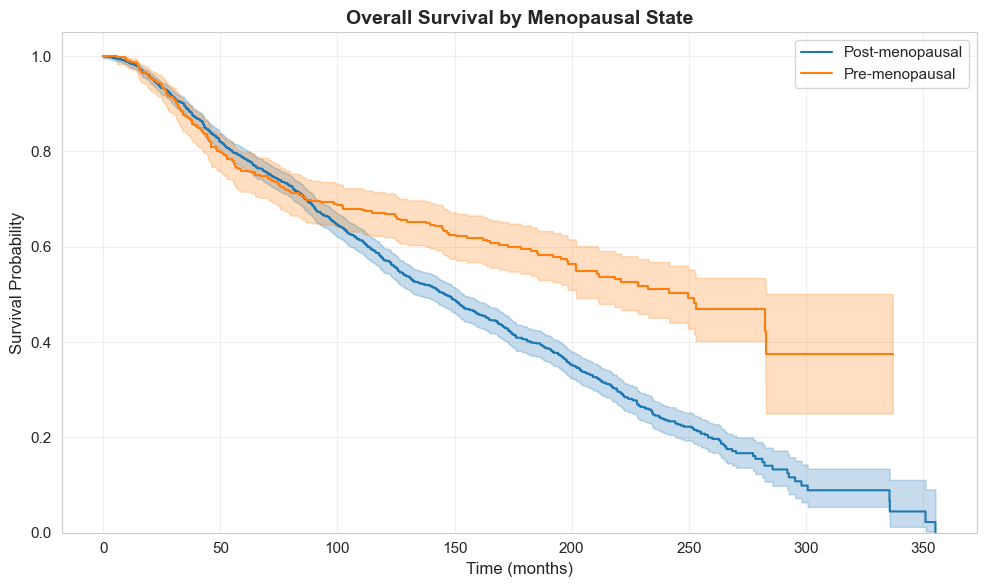

Log-rank test: p = 0.000000 (Highly significant)


In [31]:
# 4.4.10 Inferred Menopausal State Comparison - Overall Survival (OS)

if 'Inferred Menopausal State' in df.columns:
    print("="*60)
    print("INFERRED MENOPAUSAL STATE COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Check value counts
    print(f"\nMenopausal State distribution:")
    print(df['Inferred Menopausal State'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Pre': 'Pre-menopausal', 'Post': 'Post-menopausal'}
    km_by_group(df, 'Inferred Menopausal State', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Menopausal State', label_map=label_map)
else:
    print("Inferred Menopausal State column not found in dataset")


Pre-menopausal women had consistently better survival outcomes across the entire follow-up period compared to post-menopausal women. The log-rank test confirmed a highly significant difference between the two groups (p < 0.001), indicating that menopausal state is a meaningful prognostic factor for overall survival.

In [32]:
# 4.4.11 Primary Tumor Laterality Comparison - Overall Survival (OS)

if 'Primary Tumor Laterality' in df.columns:
    print("="*60)
    print("PRIMARY TUMOR LATERALITY COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Check value counts
    print(f"\nTumor Laterality distribution:")
    print(df['Primary Tumor Laterality'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Left': 'Left breast', 'Right': 'Right breast'}
    km_by_group(df, 'Primary Tumor Laterality', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Primary Tumor Laterality', label_map=label_map)
else:
    print("Primary Tumor Laterality column not found in dataset")

Primary Tumor Laterality column not found in dataset


Primary Tumor Laterality column not found in dataset
The two groups demonstrated nearly overlapping survival trajectories, indicating comparable overall survival regardless of tumor laterality. Since the variable does not contribute useful predictive information and does not affect survival, including it in further modelling would add noise rather than value.

-> Therefore, tumor laterality can be safely excluded from subsequent analyses.

In [33]:
# Drop Primary Tumor Laterality (non-predictive based on KM analysis above)
# The two groups demonstrated nearly overlapping survival trajectories, 
# indicating comparable overall survival regardless of tumor laterality.

if 'Primary Tumor Laterality' in df.columns:
    print("="*60)
    print("REMOVING PRIMARY TUMOR LATERALITY")
    print("="*60)
    print("\nReason: Overlapping survival trajectories observed in KM analysis above")
    print("       (comparable overall survival regardless of tumor laterality)")
    
    n_before = len(df.columns)
    df = df.drop(columns=['Primary Tumor Laterality'])
    n_after = len(df.columns)
    
    print(f"\n✓ Removed 'Primary Tumor Laterality' column")
    print(f"  Columns: {n_before} → {n_after}")
else:
    print("'Primary Tumor Laterality' column not found in dataset (may have been removed earlier)")

'Primary Tumor Laterality' column not found in dataset (may have been removed earlier)


## 6.5 Log-Minus-Log Plot (Bridge between CPH and KM models)

CPH models assume the hazard ratio between groups remains constant over time (known as the **proportional hazards assumption**). CPH gives us hazard ratios but if the relative risk between groups change over time, the hazard ratios can be misleading. We are using Log-minus-log survival plots to determine if the proportional hazards assumption is plausible, a necessary step before Cox modeling to ensure that the idea of a constant hazard ratio is reasonable. 

Parallel curves mean proportional hazards assumption are plausible (differences between groups stay stable) but if they cross/diverge, assumptions may not hold (risk differences change over time). 

In [34]:
# Assesses proportional hazards asusmption for a given prognosis variable using log-minus-log plot and numeric check
def check_proportional_hazards(df, prognostic_variable, duration_col, event_col, variable_type='continuous'):
    group_col = f"{prognostic_variable}_group"
    if prognostic_variable not in df.columns:
        print(f"Error: Column '{prognostic_variable}' not found in the dataframe.")
        return
        
    local_df = df.copy()
    
    if variable_type == 'continuous': 
        try:
            # Always use group_col for consistency
            local_df[group_col] = pd.qcut(local_df[prognostic_variable], q=3, labels=["low", "mid", "high"], duplicates='drop')
        except ValueError as e:   
            print(f"Could not create tertiles for '{prognostic_variable}'. Might have too few unique values. Error: {e}")
            return
    elif variable_type == 'ordinal':
        local_df[group_col] = local_df[prognostic_variable]
    elif variable_type == 'lymph_nodes':     #custom grouping for lymph nodes
        conditions = [
            (local_df[prognostic_variable] == 0),
            (local_df[prognostic_variable] >= 1) & (local_df[prognostic_variable] <= 3),
            (local_df[prognostic_variable] >= 4)
        ]
        choices = ['0 nodes', '1-3 nodes', '4+ nodes']
        local_df[group_col] = np.select(conditions, choices, default='Other')
    else:
        print(f"Error: Unknown variable_type '{variable_type}'.")
        return

    # Convert all group labels to strings before sorting to prevent TypeError
    groups = sorted([str(g) for g in local_df[group_col].unique() if pd.notna(g)])
    
    print(f"\nChecking Proportional Hazards for '{prognostic_variable}'")
    print("Group distribution:\n", local_df[group_col].value_counts())

    # log-minus-log plot
    fig, ax = plt.subplots(figsize=(8, 7))
    all_survival_probs = []
    median_survival_data = []
    key_times = [12, 36, 60, 120, 180, 240, 350]

    # Filter data for current group
    for group_name in groups:
        # Ensure we compare the string version of the group name
        kmf = KaplanMeierFitter()
        group_data = local_df.loc[local_df[group_col].astype(str) == group_name, [duration_col, event_col]].dropna()
        if len(group_data) < 20:
            print(f"Skipping group '{group_name}' due to small sample size (< 20).")
            continue  
        # Fit KM model, plot log-log transformation
        kmf.fit(group_data[duration_col], 
                group_data[event_col], 
                label=f"{prognostic_variable} ({group_name})")
        kmf.plot_loglogs(ax=ax)  

        survival_at_key_times = kmf.survival_function_at_times(key_times).rename(group_name)
        all_survival_probs.append(survival_at_key_times)
        median_survival_data.append({'Group': group_name, 'Median Survival (months)': kmf.median_survival_time_})     


    ax.set_title(f"Log-Minus-Log Survival Plot by {prognostic_variable} Group")
    ax.set_xlabel("log(Time in months)")  
    ax.set_ylabel("log(-log(Survival Probability))")
    ax.grid(True)
    ax.legend()  
    plt.tight_layout()
    plt.show()


    if median_survival_data:
        print("\nSurvival Metrics by Group")
        median_df = pd.DataFrame(median_survival_data).set_index('Group')
        print(median_df.round(1))
        
        print(f"\nSurvival Probability at Key Time Points")
        prob_df = pd.concat(all_survival_probs, axis=1)
        print((prob_df * 100).round(1))

    # Tiny numeric sanity check for proportionality (didactic)
    # Compare the gap between groups at an early and a later time
    # If the gap changes a lot, hazards may not be proportional
    if len(groups) > 1: 
        def lml_at(kmf_instance: KaplanMeierFitter, t: float) -> float:
            s = float(kmf_instance.predict(t))
            # Add a small epsilon to prevent log(0) or log(1) errors
            s = np.clip(s, 1e-9, 1 - 1e-9)
            return np.log(-np.log(s))
        
        # Define early and late time points for the check (in months)  - 25, 75% percentiles
        landmark_early, landmark_late = 36.0, 120.0
        
        # Compare the lowest and highest risk groups
        low_risk_group = groups[0]
        high_risk_group = groups[-1]

        fits = {}
        for group_name in [low_risk_group, high_risk_group]:
            # Ensure we compare the string version of the group name
            group_data = local_df.loc[local_df[group_col].astype(str) == group_name, [duration_col, event_col]].dropna()
            if not group_data.empty:
                kmf_instance = KaplanMeierFitter().fit(group_data[duration_col], group_data[event_col])
                fits[group_name] = {
                    "lml_early": lml_at(kmf_instance, landmark_early),
                    "lml_late":  lml_at(kmf_instance, landmark_late),  
                }

        if low_risk_group in fits and high_risk_group in fits:
            gap_early = fits[high_risk_group]["lml_early"] - fits[low_risk_group]["lml_early"]
            gap_late  = fits[high_risk_group]["lml_late"]  - fits[low_risk_group]["lml_late"]
            delta_gap = gap_late - gap_early
            
            print(f"\nProportionality Numeric Check for {prognostic_variable}")
            print(f"Comparing groups '{high_risk_group}' vs '{low_risk_group}'")
            print(f"Gap high−low at {int(landmark_early)} d: {gap_early:.3f}")
            print(f"Gap high−low at {int(landmark_late)} d:  {gap_late:.3f}")
            print(f"Change in gap (late − early): {delta_gap:.3f}")
            print("Rule of thumb: small change suggests proportional hazards is reasonable")
            print("Large change suggests exploring stratification or time-varying effects in the Cox model")
            print("\n---------------------\n")





Checking Proportional Hazards for 'Tumor Size'
Group distribution:
 Tumor Size_group
low     853
high    649
mid     453
Name: count, dtype: int64


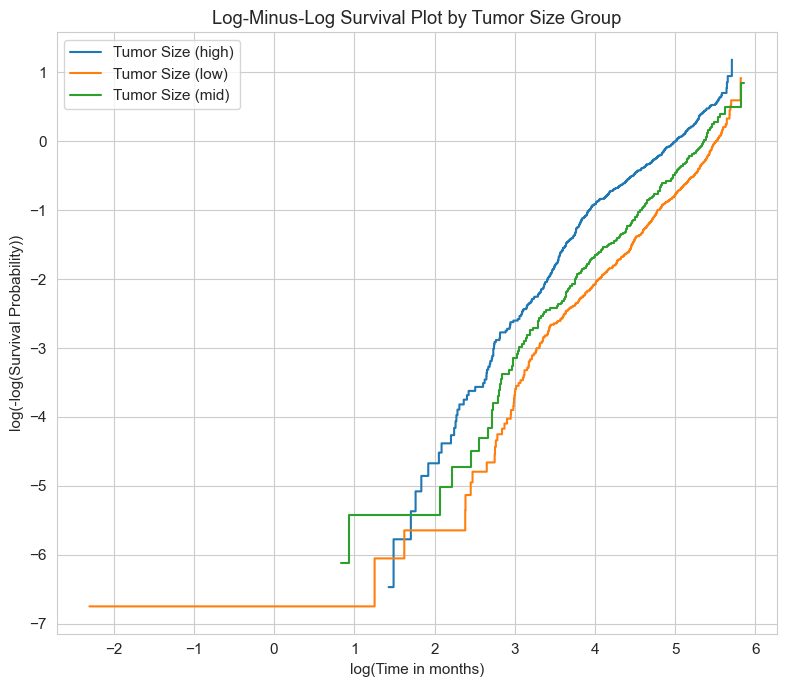


Survival Metrics by Group
       Median Survival (months)
Group                          
high                      102.1
low                       203.0
mid                       159.2

Survival Probability at Key Time Points
     high   low   mid
12   97.4  99.2  98.9
36   81.7  92.7  90.8
60   64.8  86.6  80.8
120  44.5  69.0  61.9
180  29.4  55.6  44.7
240  18.4  38.5  27.6
350   3.8   8.2   9.7

Proportionality Numeric Check for Tumor Size
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.739
Gap high−low at 120 d:  -0.522
Change in gap (late − early): 0.217
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Nottingham prognostic index'
Group distribution:
 Nottingham prognostic index_group
mid     673
low     661
high    645
Name: count, dtype: int64


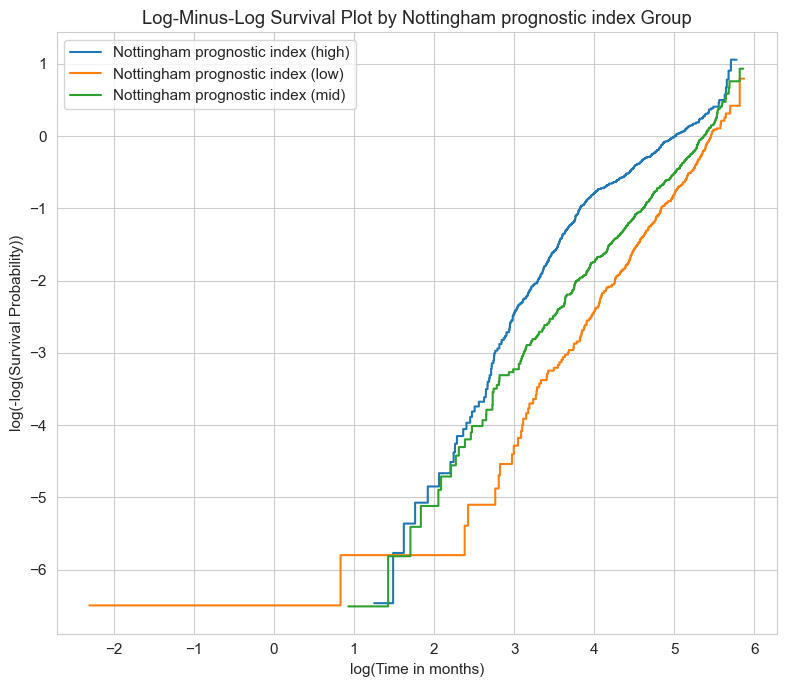


Survival Metrics by Group
       Median Survival (months)
Group                          
high                       97.0
low                       197.7
mid                       167.1

Survival Probability at Key Time Points
     high   low   mid
12   97.8  99.4  98.2
36   78.6  95.7  91.1
60   61.5  89.4  82.6
120  44.0  71.8  61.5
180  31.7  54.8  46.8
240  23.0  34.3  31.3
350   5.6  10.9   7.9

Proportionality Numeric Check for Nottingham prognostic index
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.952
Gap high−low at 120 d:  -0.525
Change in gap (late − early): 0.427
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Lymph nodes examined positive'
Group distribution:
 Lymph nodes examined positive_group
0 nodes      993
1-3 nodes    604
4+ nodes     307
Other         76
Name: count, dtype: int64


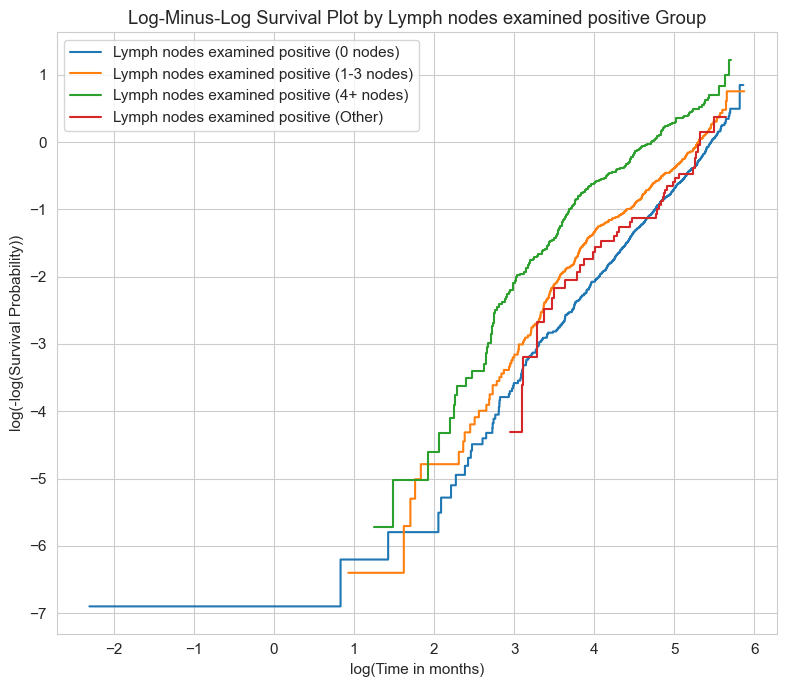


Survival Metrics by Group
           Median Survival (months)
Group                              
0 nodes                       191.9
1-3 nodes                     152.1
4+ nodes                       80.4
Other                         191.0

Survival Probability at Key Time Points
     0 nodes  1-3 nodes  4+ nodes  Other
12      98.9       98.5      96.7  100.0
36      93.7       87.0      75.1   89.2
60      86.7       74.6      56.2   79.6
120     67.7       56.9      34.0   69.2
180     52.0       42.5      21.7   53.6
240     35.3       27.1      13.4   31.1
350      9.7       11.9       0.0    0.0

Proportionality Numeric Check for Lymph nodes examined positive
Comparing groups 'Other' vs '0 nodes'
Gap high−low at 36 d: 0.554
Gap high−low at 120 d:  -0.056
Change in gap (late − early): -0.610
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Chec

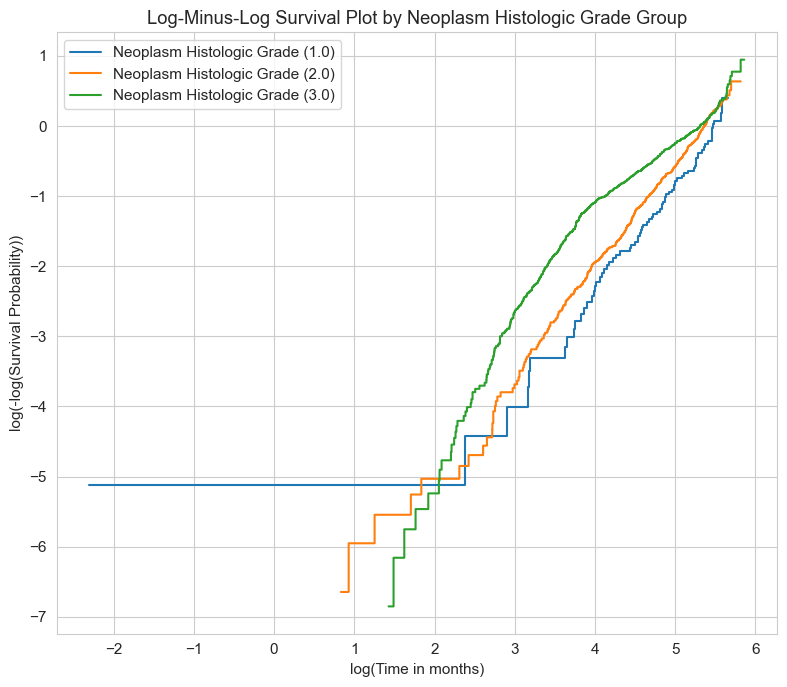


Survival Metrics by Group
       Median Survival (months)
Group                          
1.0                       208.0
2.0                       169.6
3.0                       128.4

Survival Probability at Key Time Points
      1.0   2.0   3.0
12   98.8  99.1  97.8
36   96.4  93.1  83.2
60   88.5  85.2  69.6
120  74.5  64.6  52.2
180  59.1  46.7  40.4
240  35.9  28.9  30.1
350  22.7   0.0   7.6

Proportionality Numeric Check for Neoplasm Histologic Grade
Comparing groups '3.0' vs '1.0'
Gap high−low at 36 d: 1.613
Gap high−low at 120 d:  0.791
Change in gap (late − early): -0.821
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'ER Status'
Group distribution:
 ER Status_group
Positive    1507
Negative     473
Name: count, dtype: int64


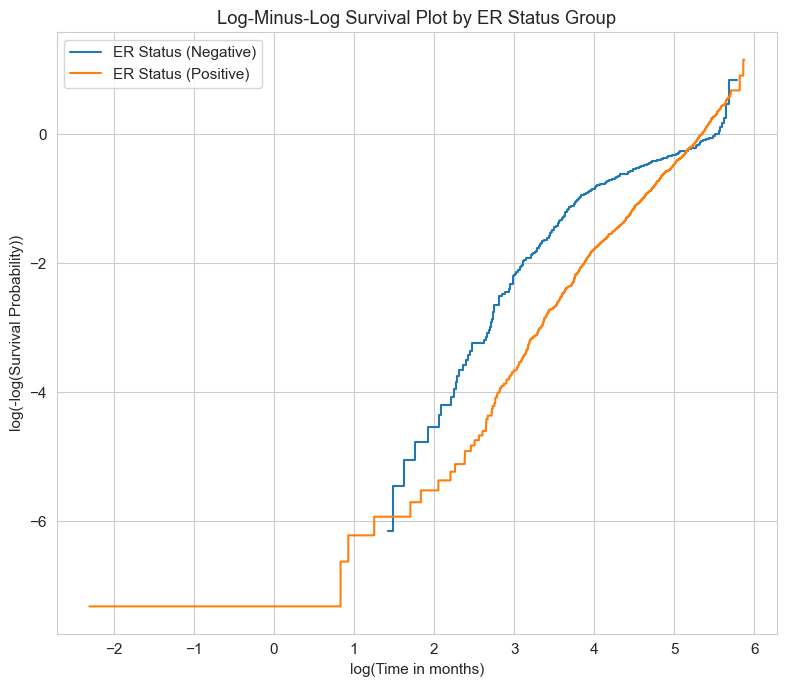


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     130.9
Positive                     161.1

Survival Probability at Key Time Points
     Negative  Positive
12       96.2      99.2
36       76.6      92.3
60       62.9      82.8
120      51.5      61.7
180      44.9      44.5
240      38.6      27.4
350      10.0       8.3

Proportionality Numeric Check for ER Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: -1.207
Gap high−low at 120 d:  -0.319
Change in gap (late − early): 0.887
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'HER2 Status'
Group distribution:
 HER2 Status_group
Negative    1732
Positive     247
Name: count, dtype: int64


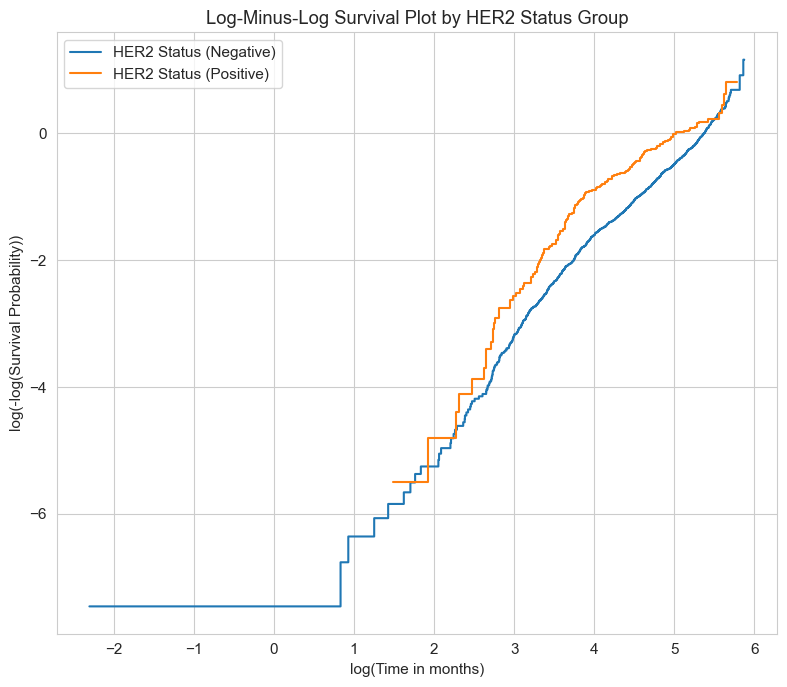


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     164.6
Positive                      98.7

Survival Probability at Key Time Points
     Negative  Positive
12       98.5      98.0
36       89.7      80.6
60       80.0      64.2
120      61.3      44.6
180      46.0      34.7
240      29.8      28.4
350       8.3      10.5

Proportionality Numeric Check for HER2 Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: 0.686
Gap high−low at 120 d:  0.501
Change in gap (late − early): -0.185
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Pam50 + Claudin-low subtype'
Group distribution:
 Pam50 + Claudin-low subtype_group
LumA           700
LumB           475
Her2           224
claudin-low    217
Basal          209
Normal         14

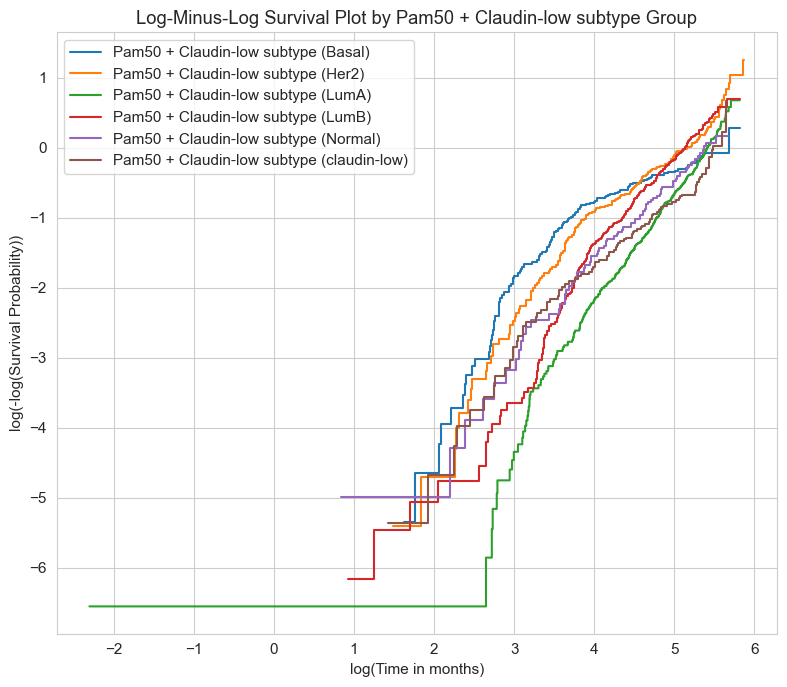


Survival Metrics by Group
             Median Survival (months)
Group                                
Basal                           130.9
Her2                            106.6
LumA                            186.6
LumB                            123.0
Normal                          159.2
claudin-low                     219.2

Survival Probability at Key Time Points
     Basal  Her2  LumA  LumB  Normal  claudin-low
12    95.7  96.4  99.9  99.1    98.0         97.7
36    72.7  80.6  94.7  90.5    89.8         87.7
60    61.6  65.0  87.5  75.4    78.8         81.8
120   50.6  47.1  69.0  51.0    60.6         67.1
180   45.5  36.6  50.7  32.7    45.6         59.9
240   39.7  23.6  32.2  20.2    34.2         37.8
350    0.0   5.9   0.0  13.5    30.8         14.3

Proportionality Numeric Check for Pam50 + Claudin-low subtype
Comparing groups 'claudin-low' vs 'Basal'
Gap high−low at 36 d: -0.887
Gap high−low at 120 d:  -0.536
Change in gap (late − early): 0.351
Rule of thumb: small change

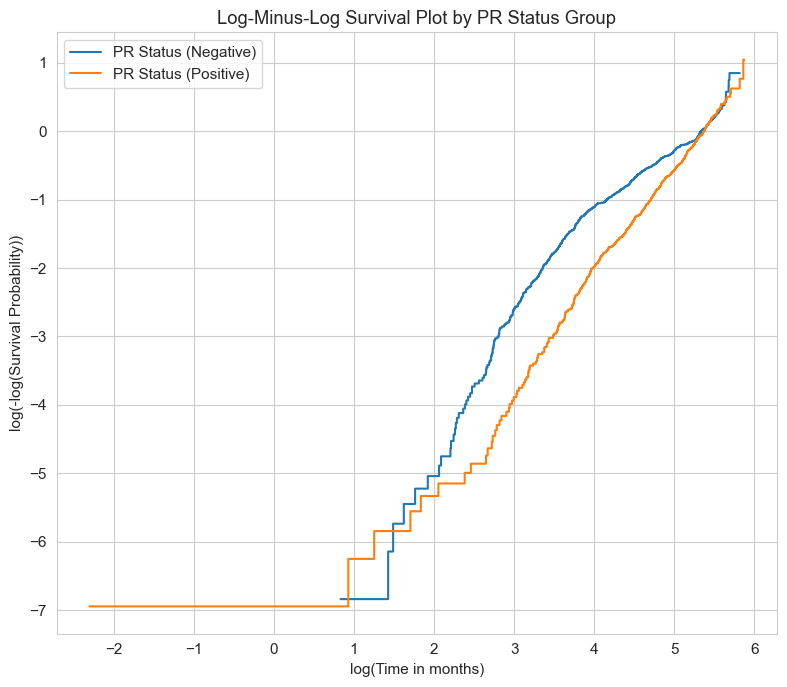


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     132.3
Positive                     170.3

Survival Probability at Key Time Points
     Negative  Positive
12       97.6      99.2
36       82.5      94.1
60       70.3      84.9
120      52.7      65.1
180      42.6      46.5
240      29.9      29.3
350       0.0      11.6

Proportionality Numeric Check for PR Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: -1.149
Gap high−low at 120 d:  -0.398
Change in gap (late − early): 0.750
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Tumor Stage'
Group distribution:
 Tumor Stage_group
2.0    825
1.0    501
3.0    118
0.0     12
4.0     10
Name: count, dtype: int64
Skipping group '0.0' due to small sample size (< 20).
Skipping g

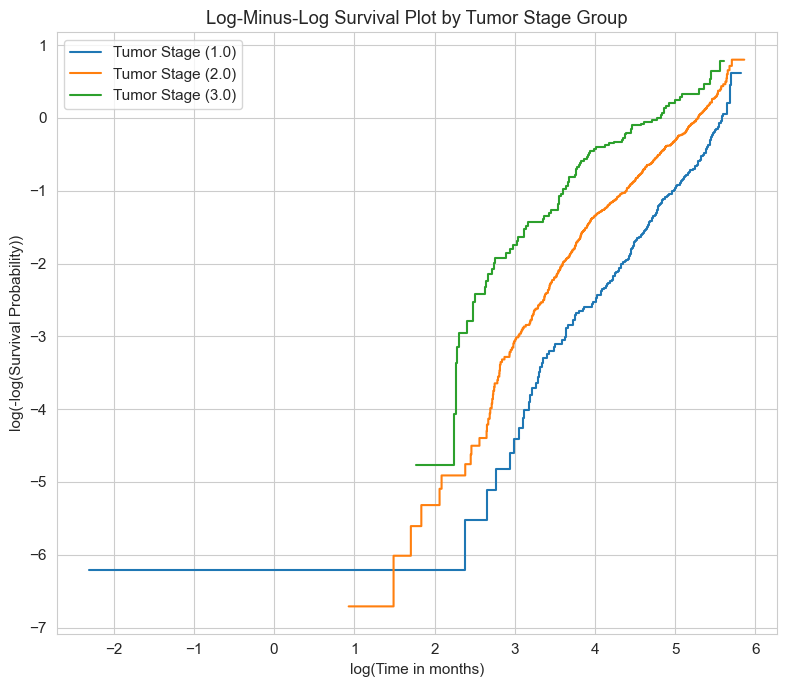


Survival Metrics by Group
       Median Survival (months)
Group                          
1.0                       227.8
2.0                       140.6
3.0                        64.9

Survival Probability at Key Time Points
      1.0   2.0   3.0
12   99.6  98.9  92.4
36   95.6  87.8  70.2
60   90.9  75.4  51.2
120  74.3  54.9  36.6
180  61.3  40.4  25.1
240  44.5  27.2  15.0
350   0.0  10.8  11.2

Proportionality Numeric Check for Tumor Stage
Comparing groups '4.0' vs '0.0'
Gap high−low at 36 d: 20.052
Gap high−low at 120 d:  2.178
Change in gap (late − early): -17.874
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------

PH assumption against RFS

Checking Proportional Hazards for 'Tumor Size'
Group distribution:
 Tumor Size_group
low     853
high    649
mid     453
Name: count, dtype: int64


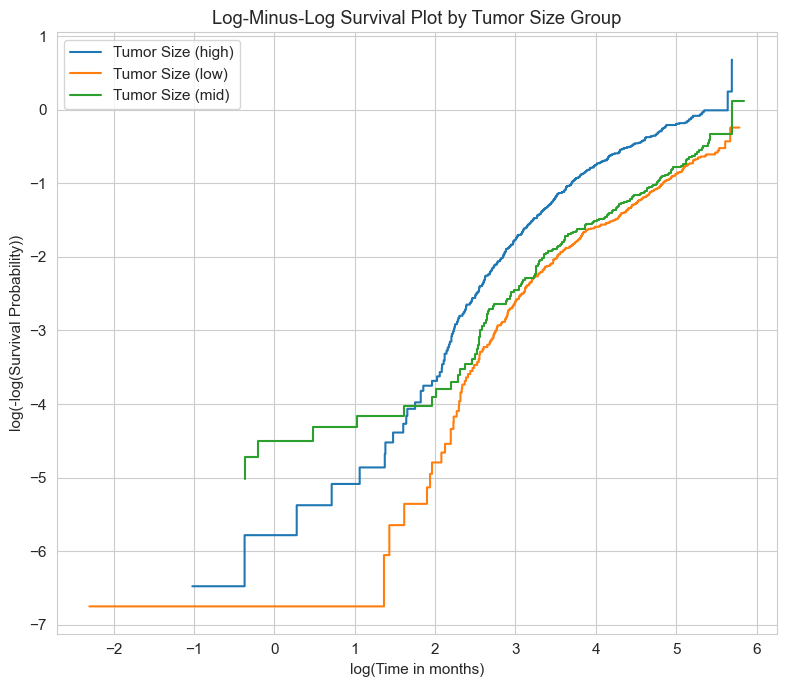


Survival Metrics by Group
       Median Survival (months)
Group                          
high                      108.6
low                       290.9
mid                       226.2

Survival Probability at Key Time Points
     high   low   mid
12   92.5  97.0  96.7
36   72.1  86.5  84.8
60   60.9  81.1  79.8
120  47.7  70.7  68.4
180  40.8  61.8  58.5
240  37.1  58.0  49.0
350  13.9  45.7  32.6

Proportionality Numeric Check for Tumor Size
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.684
Gap high−low at 120 d:  -0.667
Change in gap (late − early): 0.017
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------



In [35]:
variables_to_check = {
    'Tumor Size': 'continuous',
    'Nottingham prognostic index': 'continuous',
    'Lymph nodes examined positive': 'lymph_nodes',
    'Neoplasm Histologic Grade': 'ordinal', 
    'ER Status': 'ordinal',
    'HER2 Status': 'ordinal',
    'Pam50 + Claudin-low subtype': 'ordinal', 
    'PR Status': 'ordinal', 
    'Tumor Stage': 'ordinal'
}

for var_name, var_type in variables_to_check.items():
    # Check the PH assumption for chosen var against Overall Survival
    check_proportional_hazards(df, 
                            prognostic_variable=var_name, 
                            duration_col='Overall Survival (Months)', 
                            event_col='event_os', 
                            variable_type=var_type)


# Check the PH assumption for Tumor Size against RFS
print("PH assumption against RFS")
check_proportional_hazards(df, 
                           prognostic_variable='Tumor Size', 
                           duration_col='Relapse Free Status (Months)', 
                           event_col='event_rfs')      #just changed the col




Tumor size has a clear dose-response relationship, with larger tumors leading to significantly worse survival (median survival for "high" tumor size group is 102.1 months), almost half of the "low" tumor size group (median survival of 203.0 months). **The "change in gap" is 0.217 for OS and 0.017 for RSF, which allows us to to assume the PH assumption is reasonable for Tumor Size** and we can set it as a standard variable in the Cox model. 

Nottingham Prognostic Index (NPI) higher scores are strongly associated with worse outcomes, with the median survival dropping from 197.7 months for the low-NPI group to 97.0 months for the high-NPI group. The **"change in gap" is 0.427, suggesting some convergance of the lines over time but within an acceptable range, meaning the PH assumption is mostly reasonable** and we can include it as a standard variable within the Cox model (while noting prognostic power is stronger in earlier years). 

Lymph Nodes Examined Positive is a very strong predictor, as patients with 0 positive nodes have a median survival of 191.9 months, dropping to 80.4 months for patients with 4+ positive nodes. This is highlighting the extent of nodal involvement as a critical determinant of patients outcomes. The **"change in gap" is -0.610, which is a large change and indicates the hazard ratio between node-negative and node-positive gorups is not constant, meaning the PH assumption is questionable for lymph node status.** To include this in the Cox model, we will consider a special approach (stratification) for the varaible.

Neoplasm Histologic Grade shows a clear, stepwise impact on survival, with Grade 1 tumors having a median survival of 208.0 months, decreasing to 128.4 months by Grade 3, confirming the higher-grade tumors are more aggresive. The **"change in gap" is -0.821, violating the proportional hazards assumption with the plotlines for Grade 1 and Grade 3 not being parallel.** The relative risk of Grade 3 tumors are much higher early on but decrease after time compared to Grade 1 tumors. If, but likely not, this was set as a varaible in the Cox model, it would require stratification to address the issue. 

ER Status and PR Status show similar results, with ER-positive and PR-positive tumors having significantly better prognoses with median survival advantages between 2.5-3 years over their negative counterparts. Both markers have **large "change in gaps" (0.887 and 0.75) violating the PH assumption**. The ER/PR positive survival advantage is stronger in the first 10-15 years but it diminished over time, with the curves on the graph intersecting at 180 months representing the risk of late accurence in hormone sensitive cancers. These will not be included in the Cox model without stratification.

HER2 Status shows a drastically worse prognosis associated with HER2-positive status, with a median survival that is over 5 years shorter than HER2-negative, reflecting HER2-positive's aggressive nature. The **"change in gap" is 0.185, a small change that means the PH assumption is reasonable** and can be included within the Cox model.  

The PAM50 Subtypes reestablishes the heirarchy of BC subtypes, as Luminal A and Claudin-Low have the best prognosis while Luminal B,  Basal-like, and HER2-enriched have significantly worse. The **"change in gap" between Basal-like and Claudin-low is 0.351, a small to moderate change that means the PH assumption is mostly reasonable across the subtypes**. However, there are some non-proportionalities within specific pairs of subtypes (Luminal A and Basal-like) but as a whole, PAM50 can be included in the Cox model (could be considered a strong candidate for stratification).

Tumor Stage is a powerful predictor of survival, with a sharp decrease in survival when stages increase, with the median survival being 5.4 years. However, the **"change in gap" is huge, -17.874, skewed by the small sample sizes wihtin Stage 0 and Stage 4, meaning the PH assumption is severly violated**. This is the number 1 candidate for stratification and cannot be included within the Cox model without it. 


### Overall
#### Variables that Satisfy the PH Assumption 
These can be included directly in the CPH model 
* Tumor Size
* HER2 Status
* Nottingham prognostic index
* PAM50 (should consider stratification)

#### Variables that Violate the PH Assumption 
These require specific handling in the CPH model (need the strata arguement)
* Tumor Size (requires stratification)
* ER Status/ PR Status (require stratification)
* Neoplasm Histologic Grade (require stratification)
* Lymph Nodes examined positive (require stratification)



# 7.0 Cox Proportional Hazards (CPH)

A semi-parametric regression model for survival data that models the hazard of an event (death) based on predictor variables, allowing us to see the effect of multiple variables at once. It produces Hazard Ratios (HR) that **tell us how much the risk of an event is multiplied for each unit increase in a variable while holding the others constant**. CPH has a core assumption known as the Proportional Hazard Assumption, which assumes hat the ratio between any 2 groups remains constant over time. 

Here, we ask: **By how much does a variable increase risk while controlling other factors?**

Competing Risk Event Distribution:
competing_risk_event
1    803
0    744
2    433
Name: count, dtype: int64


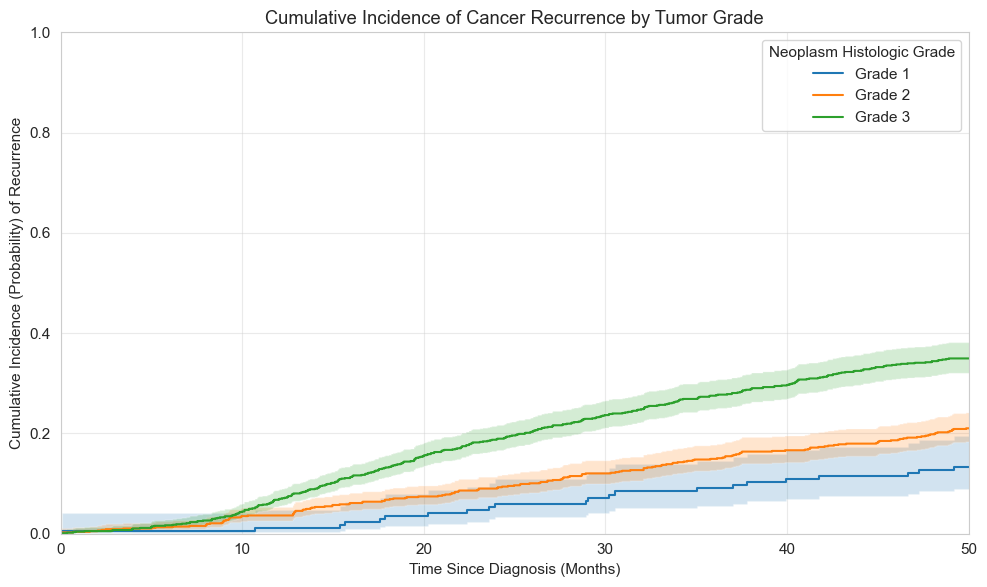

In [36]:
# Create the competing risk event type column
#event 0: censored, event 1: recurrence, event 2: death without recurrence
conditions = [
    (df['event_rfs'] == 1),         #event 1: recurrence 
    (df['event_os'] == 1) & (df['event_rfs'] == 0)      
]
choices = [1, 2]
df['competing_risk_event'] = np.select(conditions, choices, default=0)

# The relevant time is the duration until the first event (relapse or death), we use RFS for this
time_to_event = df['Relapse Free Status (Months)']
grouping_variable = df['Neoplasm Histologic Grade']

print("Competing Risk Event Distribution:")
print(df['competing_risk_event'].value_counts())


# --- 2. Calculate and Plot the Cumulative Incidence ---
fig, ax = plt.subplots(figsize=(10, 6))

for grade in sorted(grouping_variable.unique()):
    if pd.isna(grade):
        continue
    idx = (grouping_variable == grade)

    # Estimate CIF with pointwise confidence intervals
    time_points, cif, conf_int = cumulative_incidence_competing_risks(
        event=df.loc[idx, 'competing_risk_event'],
        time_exit=time_to_event[idx],
        conf_type="log-log"
    )
    
    # With our coding, the first row (index 0) of the output is for event 1 (death)
    ax.step(time_points, cif[0], where="post", label=f"Grade {int(grade)}")
    ax.fill_between(time_points, conf_int[0, 0], conf_int[0, 1], step="post", alpha=0.2)

ax.set_title("Cumulative Incidence of Cancer Recurrence by Tumor Grade")
ax.set_xlabel("Time Since Diagnosis (Months)")
ax.set_ylabel("Cumulative Incidence (Probability) of Recurrence")
ax.set_xlim(0, 50)
ax.set_ylim(0, 1.0)
ax.legend(title="Neoplasm Histologic Grade")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Grade 3 tumors (high grade) are more aggressive, high-risk tumors, reaching a ~38% incidence of recurrence by 50 months and ~60% by 150 months. This group has a constant and high rate of recurrence, especially within the first decade after diagnosis as the majority of occurences happening in early stages. This justifies aggressive treatment upfront to combat the early risk, with small CI bands proving our confidence in this high-risk assesment. 

Grade 2 tumors (intermediate grade) revealed a steady, persistant, and lifelong threat of recurrence, with the risk not being front-loaded. This means patients cannot be considered "cured" after 5-10 years and will require lifelong surveillance to ensure no recurrence. The narrow CI bands indicate that this steady risk is a very reliable finding for this group. 

Grade 1 tumors (low grade) overall have the lowest risk, increasing more noticably after 150 months and more so after 220, indicating an excellent short/meduim term prognosis but a risk of very late recurrence. An inital flatness confirms the tumors are slow growing with a low risk of recurrence, requiring less aggressive upfront treatment (patients can potentially avoid chemotherapy). The CI bands are the widest of all 3 groups, indicating our estimates for very late recurrence are less certain (expected, as less patients remain in the study after 15-20 years). The clinical challenge for this group is to identify which patients would benefit from extended therapy and monitoring beyond 5-10 years. 

## 7.1 Multivariate Cox Proportional Hazards Model

Estimates the effect of each predictor while controlling the effects of the others. 

In [37]:
import utils
from lifelines.utils import survival_table_from_events

In [38]:
age_bins = [0, 50, 65, 100]  # <50, 50-65, >65
age_labels = ['Age_L50', 'Age_M50_65', 'Age_G65']
npi_bins = [0, 2.4, 5.4, 10]
npi_labels = ['NPI_Good', 'NPI_Moderate', 'NPI_Poor']

# Add stratification columns back from original data
strat_cols = [
    'Tumor Stage', 
    # 'Neoplasm Histologic Grade', 
    # 'ER Status', 
    # 'PR Status', 
    # 'Pam50 + Claudin-low subtype',
    'Age_Stratum',          
    'NPI_Stratum'
]

# cols_to_exclude_entirely = [ 
#     'Age at Diagnosis',                    #redundant because stratified version is already used
#     'Nottingham prognostic index',         #redundant because stratified version is already used
#     'Tumor Size',                          #redundant because used in NPI
#     'Cohort',                              #not needed
#     'Lymph nodes examined positive'        #redundant because used in NPI
# ]


# Create new categorical columns in the training and validation sets
X_train_features = X_train.copy()
X_val_features = X_val.copy()
X_test_features = X_test.copy()
X_train_features['Age_Stratum'] = pd.cut(X_train_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_val_features['Age_Stratum'] = pd.cut(X_val_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_train_features['NPI_Stratum'] = pd.cut(X_train_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')
X_val_features['NPI_Stratum'] = pd.cut(X_val_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')
X_test_features['Age_Stratum'] = pd.cut(X_test_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_test_features['NPI_Stratum'] = pd.cut(X_test_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')
X_train_features['Tumor Stage'] = X_train_features['Tumor Stage'].replace(4.0, 3.0)
X_val_features['Tumor Stage'] = X_val_features['Tumor Stage'].replace(4.0, 3.0)
X_test_features['Tumor Stage'] = X_test_features['Tumor Stage'].replace(4.0, 3.0)

# all_cols_to_exclude = strat_cols + ['Age at Diagnosis', 'Nottingham prognostic index', 'Tumor Size','Cohort']
# modeling_feature_cols = [col for col in X_train_features.columns if col not in strat_cols and col not in cols_to_exclude_entirely]
modeling_feature_cols = [
    'Neoplasm Histologic Grade',
    'Mutation Count',
    'Type of Breast Surgery',
    'Chemotherapy',
    'ER Status',
    'PR Status',
    'HER2 Status',
    'Hormone Therapy',
    'Radio Therapy',
    'Pam50 + Claudin-low subtype',
]
numeric_cols, categorical_cols = utils.detect_feature_types(X_train_features[modeling_feature_cols])


# Safety checks
required_cols = ['duration_os', 'event_os'] 
for col in required_cols:
    if col not in y_train.columns or col not in y_val.columns:
        raise NameError(f"Column '{col}' not found in y_train or y_val. Please check your data splits.")

# 1) Detect feature types and build preprocessor with utils
cox_preprocessor = utils.build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    num_strategy="median",
    cat_strategy="most_frequent"
)

# 2) Fit on TRAIN ONLY and transform splits
cox_preprocessor.fit(X_train_features[modeling_feature_cols])
X_train_cox_prep = utils.to_dataframe(cox_preprocessor, X_train_features[modeling_feature_cols])
X_val_cox_prep = utils.to_dataframe(cox_preprocessor, X_val_features[modeling_feature_cols])
X_test_cox_prep = utils.to_dataframe(cox_preprocessor, X_test_features[modeling_feature_cols])


X_train_cox = pd.concat([X_train_cox_prep, X_train_features[strat_cols].reset_index(drop=True)], axis=1)
X_val_cox = pd.concat([X_val_cox_prep, X_val_features[strat_cols].reset_index(drop=True)], axis=1)
X_test_cox  = pd.concat([X_test_cox_prep, X_test_features[strat_cols].reset_index(drop=True)],    axis=1)

# 3) Build modeling frames for lifelines
train_cox_df = pd.concat([X_train_cox, y_train[["duration_os", "event_os"]]], axis=1)
val_cox_df = pd.concat([X_val_cox, y_val[["duration_os", "event_os"]]],   axis=1)
test_cox_df = pd.concat([X_test_cox, y_test[["duration_os", "event_os"]]],   axis=1)

# train_cox_df = pd.concat([X_train_cox, y_train.reset_index(drop=True)], axis=1)
# val_cox_df   = pd.concat([X_val_cox,   y_val.reset_index(drop=True)],   axis=1)

nan_mask = train_cox_df.isnull().any(axis=1)
num_nans = nan_mask.sum()
if num_nans > 0:
    print(f"ATTENTION: {num_nans} rows found with NaN values in the final modeling data. Dropping them to proceed.")
    print(train_cox_df.isnull().sum())
    train_cox_df.dropna(inplace=True)
    val_cox_df.dropna(inplace=True)
    test_cox_df.dropna(inplace=True)
    # train_cox_df.dropna(subset=['duration_os', 'event_os'], inplace=True)
    # val_cox_df.dropna(subset=['duration_os', 'event_os'], inplace=True)
    # test_cox_df.dropna(subset=['duration_os', 'event_os'], inplace=True)



# 4) Fit Cox PH with Efron ties and a small L2 penalizer for stability
cph_model = CoxPHFitter(penalizer=0.5)
cph_model.fit(train_cox_df, 
              duration_col="duration_os", 
              event_col="event_os", 
              strata=strat_cols)

print("--- Multivariable Cox model summary ---")
cph_model.print_summary(
    decimals=3,
    columns=["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
)

# 5) Concordance baseline
cindex_train = float(cph_model.concordance_index_)
cindex_val = float(cph_model.score(val_cox_df, scoring_method="concordance_index"))
print(f"\nConcordance | train {cindex_train:.3f} | validation {cindex_val:.3f}")

# Keep objects for next steps
cox_feature_names = X_train_cox.columns.tolist()

ATTENTION: 1143 rows found with NaN values in the final modeling data. Dropping them to proceed.
num__Neoplasm Histologic Grade                   479
num__Mutation Count                              479
cat__Type of Breast Surgery_Breast Conserving    479
cat__Type of Breast Surgery_Mastectomy           479
cat__Chemotherapy_No                             479
cat__Chemotherapy_Yes                            479
cat__ER Status_Negative                          479
cat__ER Status_Positive                          479
cat__PR Status_Negative                          479
cat__PR Status_Positive                          479
cat__HER2 Status_Negative                        479
cat__HER2 Status_Positive                        479
cat__Hormone Therapy_No                          479
cat__Hormone Therapy_Yes                         479
cat__Radio Therapy_No                            479
cat__Radio Therapy_Yes                           479
cat__Pam50 + Claudin-low subtype_Basal           479
ca

model,lifelines.CoxPHFitter
duration col,'duration_os'
event col,'event_os'
penalizer,0.5
l1 ratio,0.0
strata,"[Tumor Stage, Age_Stratum, NPI_Stratum]"
baseline estimation,breslow
number of observations,524
number of events observed,290
partial log-likelihood,-885.235
time fit was run,2025-12-03 13:34:25 UTC



Concordance | train 0.654 | validation 0.708


Over all, the Training Concordance Index is 0.654 and the validation C-index is 0.708 (a 0.5 is random choice and 1.0 is perfect), suggesting it is reasonably good at ranking patients by their risk of death. A slightly higher score in the validation set is explained by the smaller dataset size, suggesting the model is not severely overfitting. The -log_2(p) of 2.255 suggests our model is highly statistically significant when predicting survival compared to the null model (p-value is approx 0.21).

The strongest predictor (closest to significance) is num__Neoplasm Histologic Grade, with a p-value of 0.122 and EXP(COEF) = 1.114. Although not traditionally significant (p<0.05), this result implies that patients with a one-unit increase in tumor grade have an 11.4% increase in the hazard of death.num__Mutation Count is also a key factor with a p-value of 0.129 and EXP(COEF) = 1.021. This means for every one-unit increase in mutation count, the patient's risk of death increases by 2.1%.

Treatment Indicators: Treatment indicators (Type of Breast Surgery, Chemotherapy, Hormone Therapy, Radio Therapy) continue to show high p-values (>0.10 and up to 0.885) and wide confidence intervals. This strongly supports the existing clinical finding that these are indicators of a treatment decision, not independent prognostic factors (i.e., sicker patients receive more intense treatment).


## 7.2 Proprotional Hazards Assumption Check

Models main assumption is that the effect of each variable (its Hazard Ratio) is constant over time. 

We use a built-in lifelines function that performs a statistical test for each variable and plots the "Schoenfeld residuals" for any that might violate the assumption.


**What we are looking for**

* Statistical Test: A p-value greater than 0.05 for a variable suggests it meets the assumption
* Residual Plot: The plot should look like random noise with no obvious trend. A clear slope or pattern in the plot is a red flag that the variable's effect changes over time

Running PH check on the independent covariates...
Checking PH assumption for:  ['num__Neoplasm Histologic Grade', 'num__Mutation Count', 'cat__Type of Breast Surgery_Breast Conserving', 'cat__Type of Breast Surgery_Mastectomy', 'cat__Chemotherapy_No', 'cat__Chemotherapy_Yes', 'cat__ER Status_Negative', 'cat__ER Status_Positive', 'cat__PR Status_Negative', 'cat__PR Status_Positive', 'cat__HER2 Status_Negative', 'cat__HER2 Status_Positive', 'cat__Hormone Therapy_No', 'cat__Hormone Therapy_Yes', 'cat__Radio Therapy_No', 'cat__Radio Therapy_Yes', 'cat__Pam50 + Claudin-low subtype_Basal', 'cat__Pam50 + Claudin-low subtype_Her2', 'cat__Pam50 + Claudin-low subtype_LumA', 'cat__Pam50 + Claudin-low subtype_LumB', 'cat__Pam50 + Claudin-low subtype_NC', 'cat__Pam50 + Claudin-low subtype_Normal', 'cat__Pam50 + Claudin-low subtype_claudin-low']

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a momen

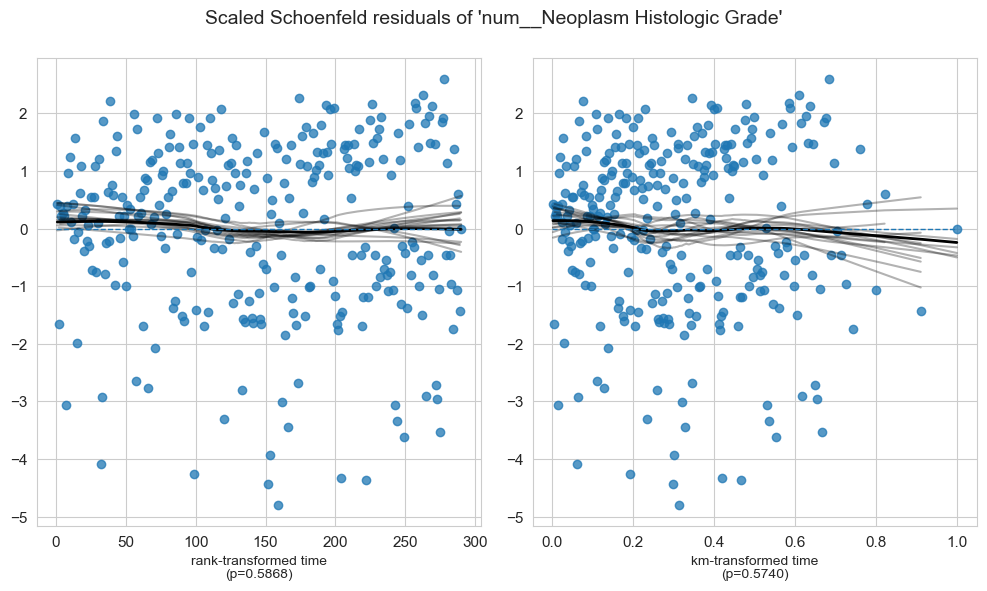

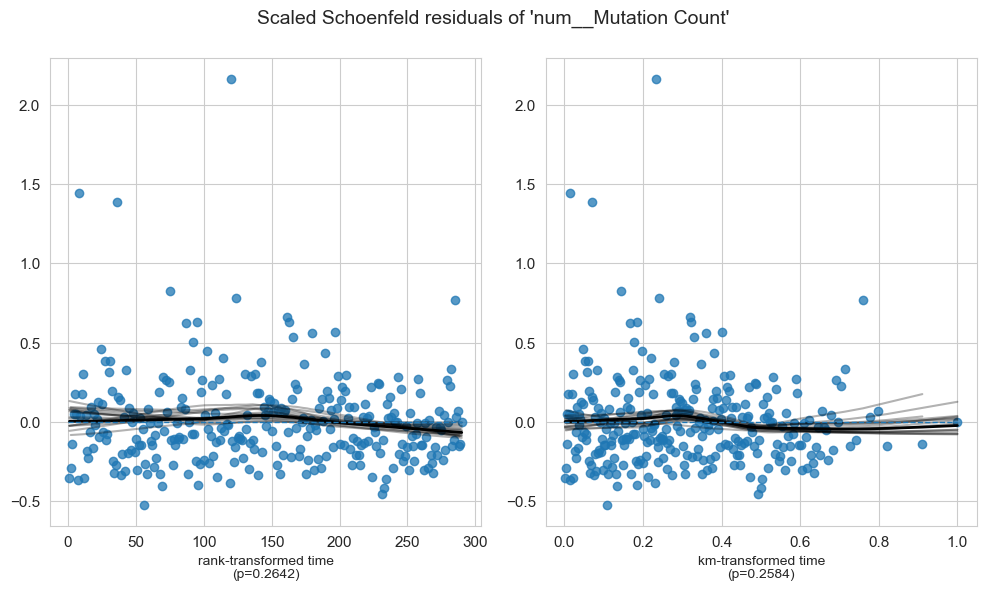

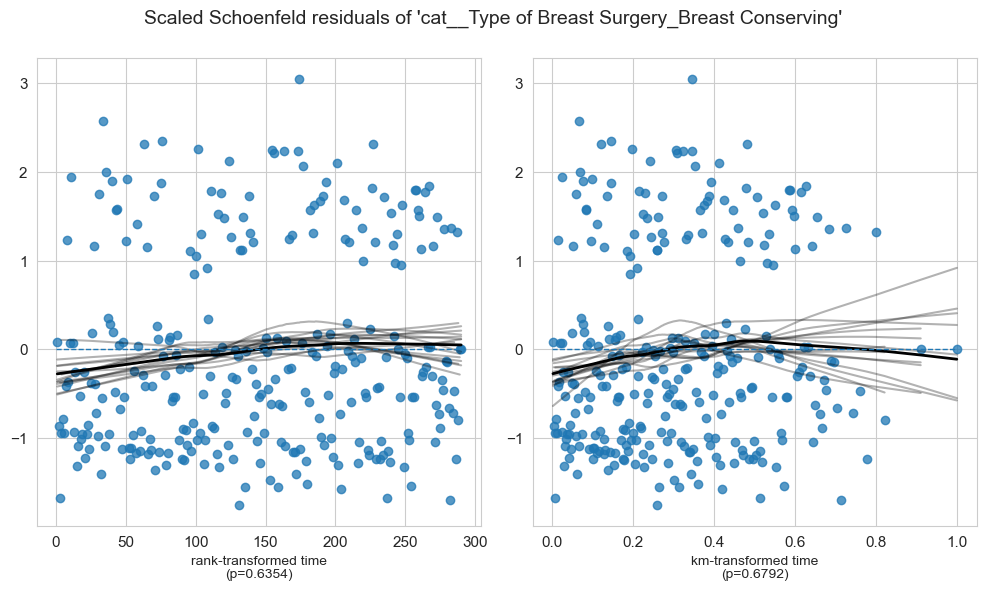

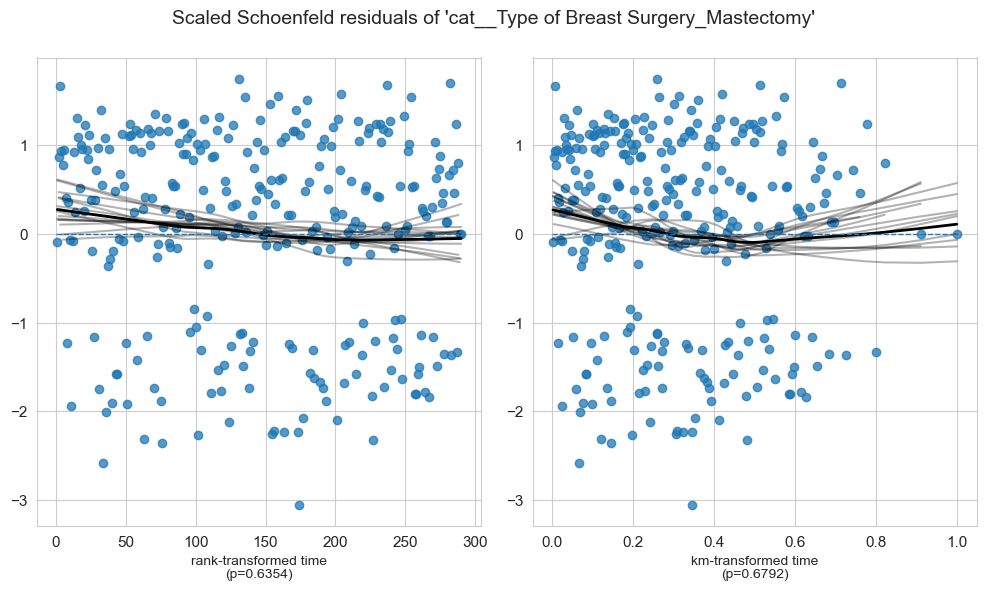

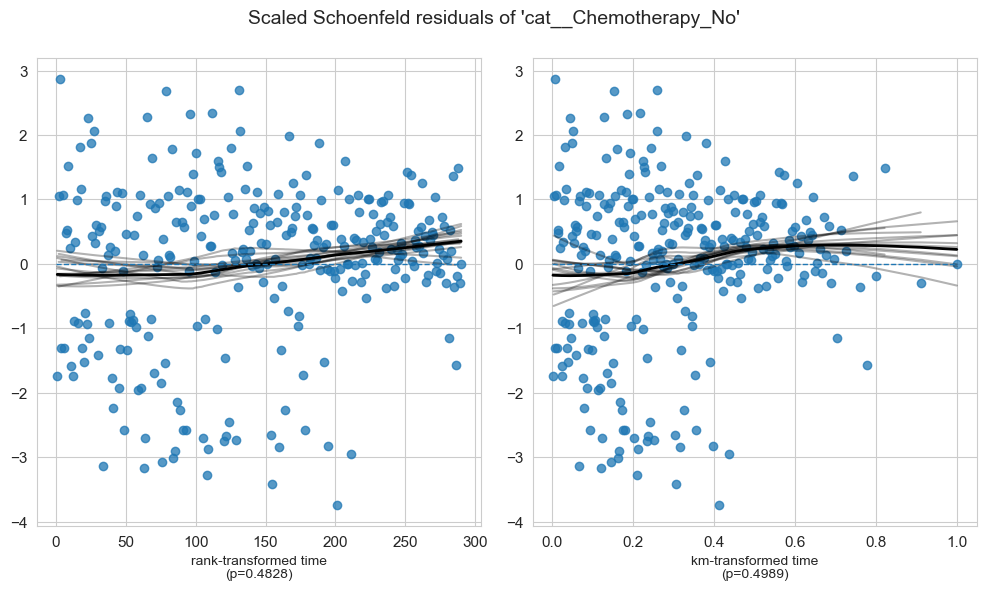

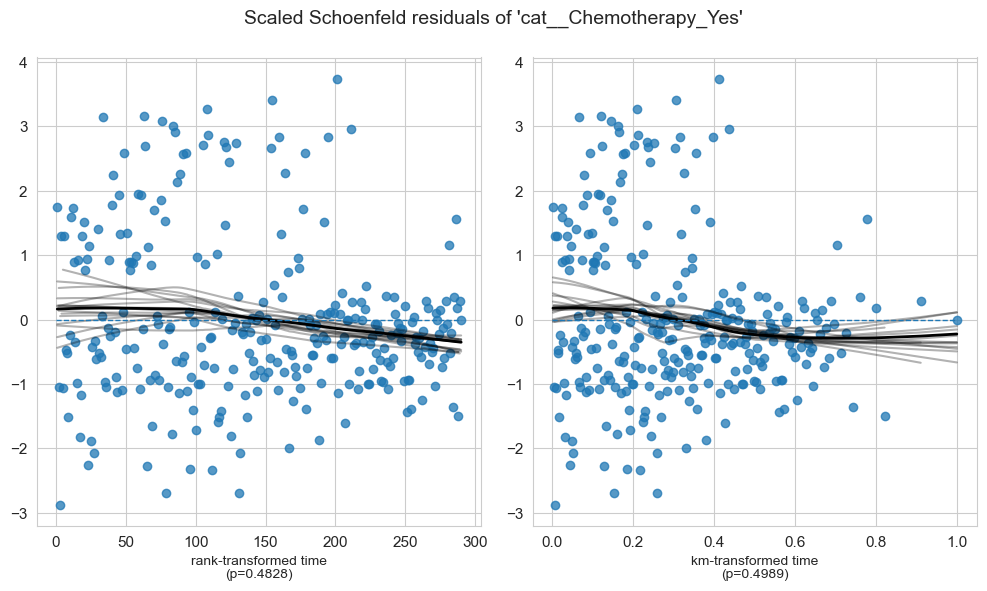

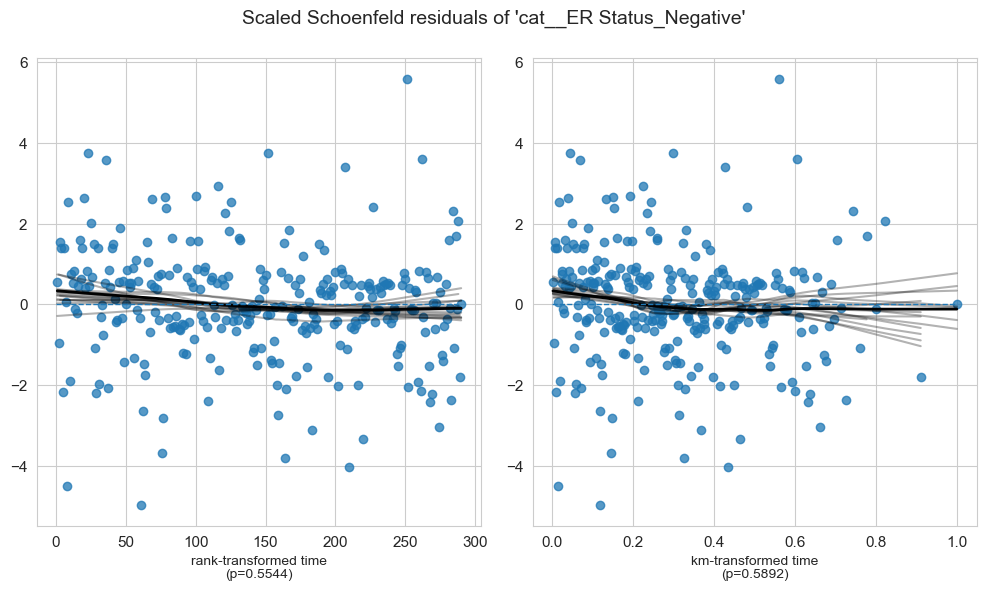

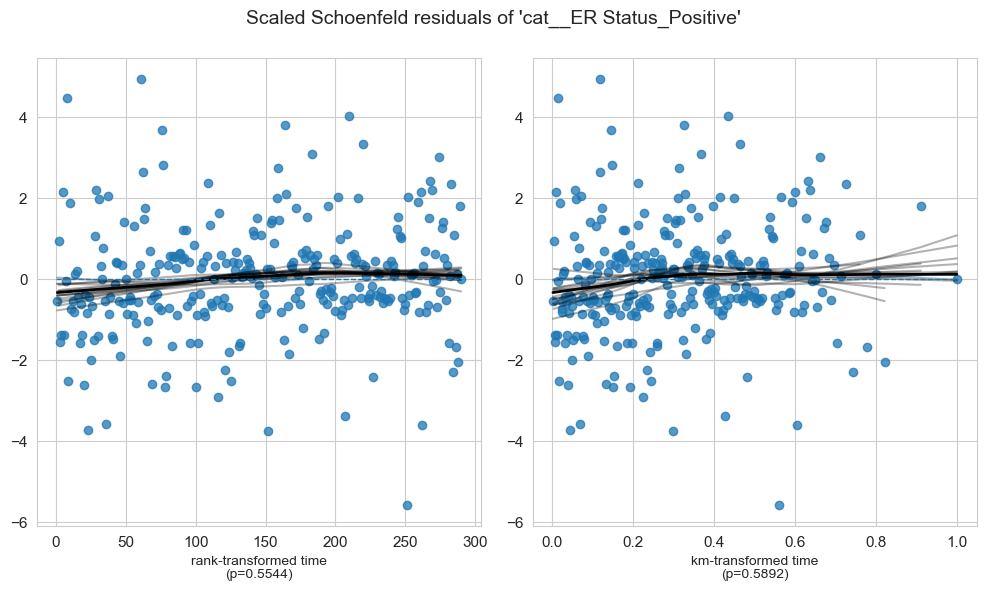

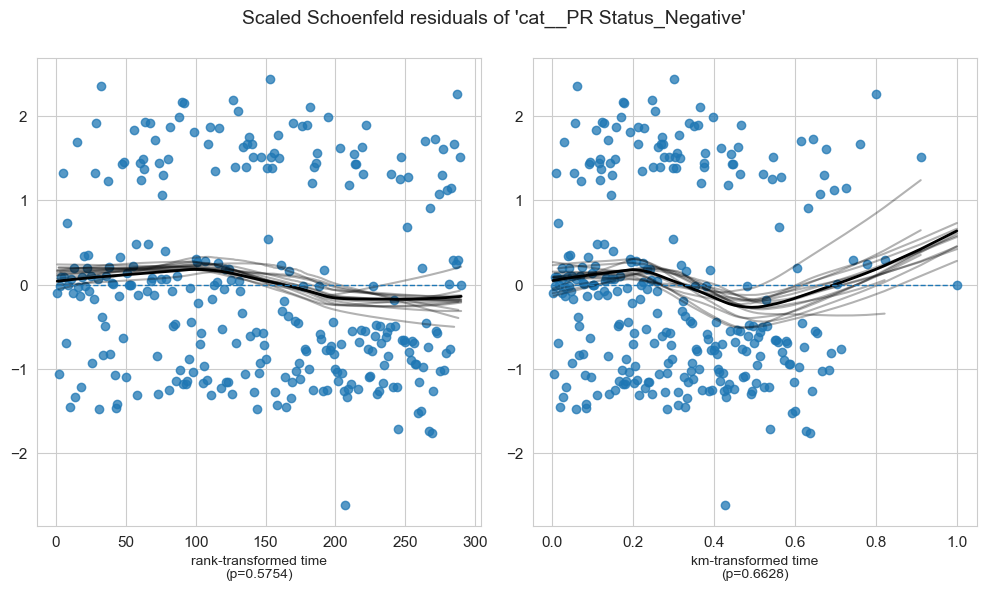

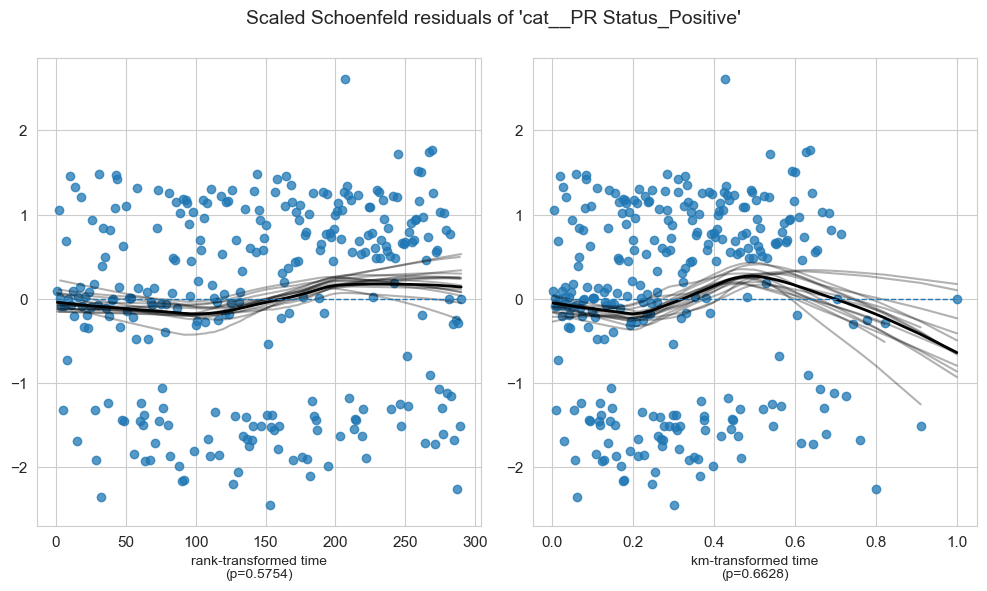

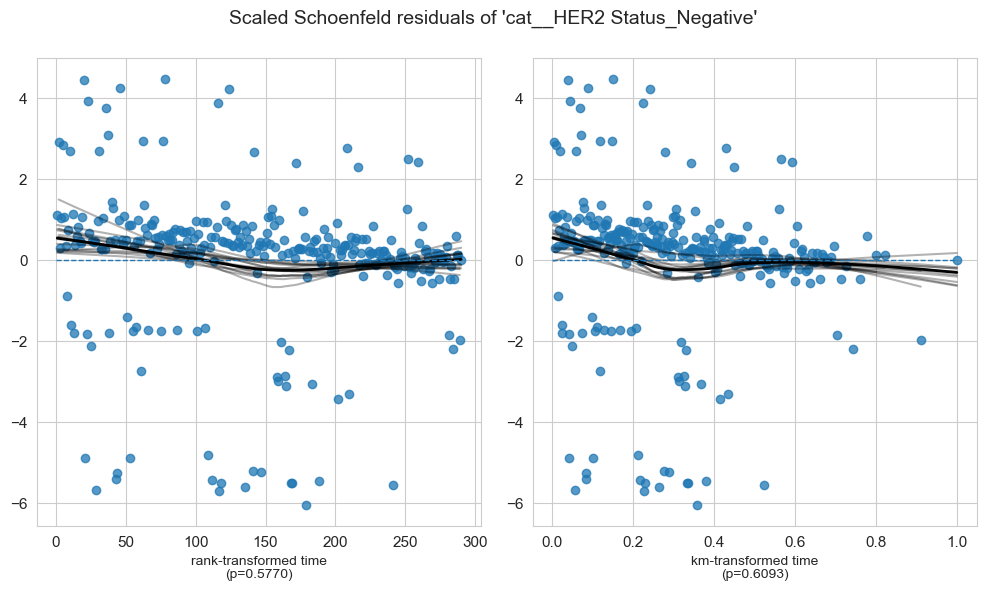

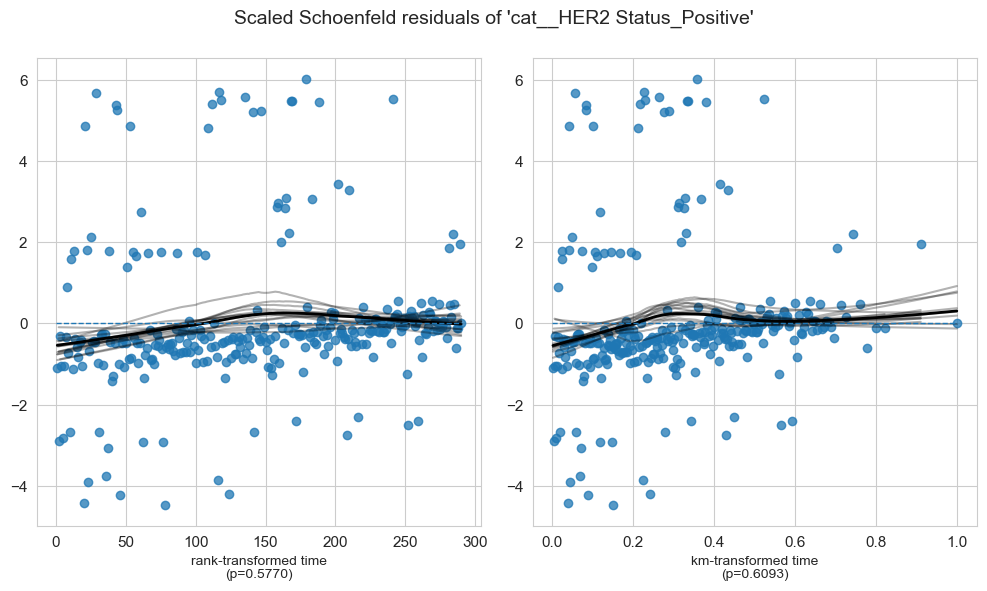

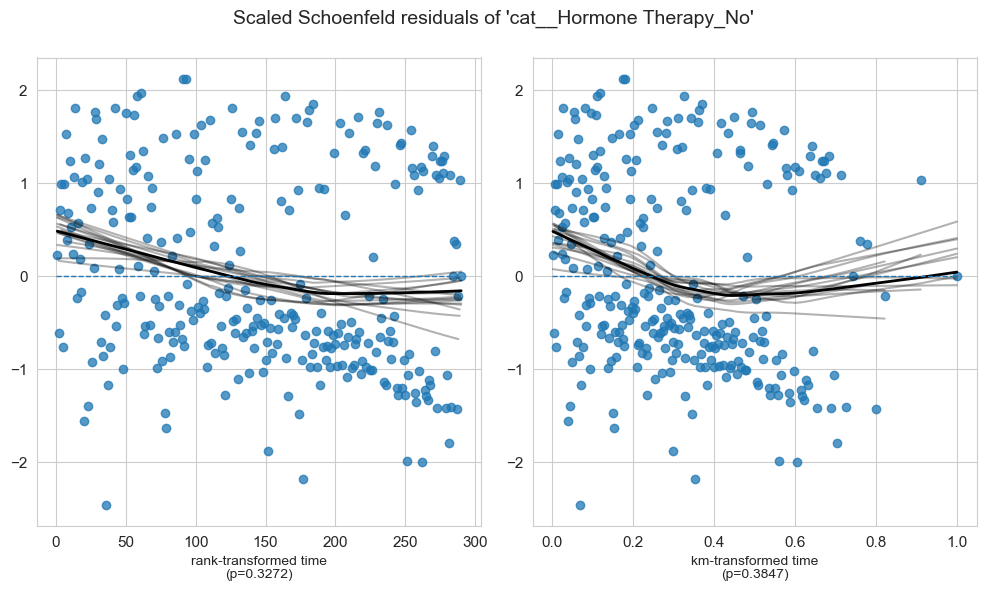

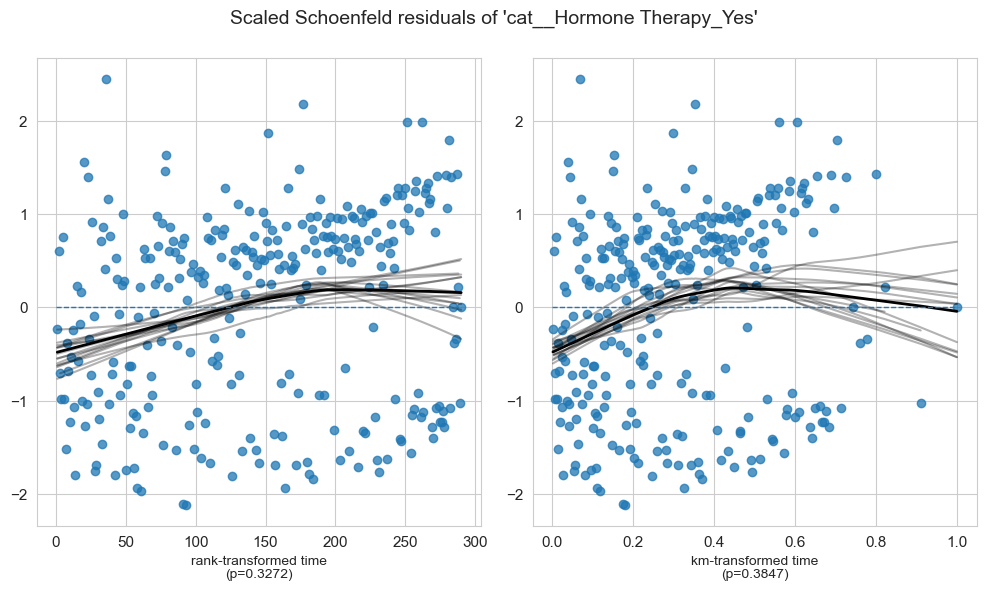

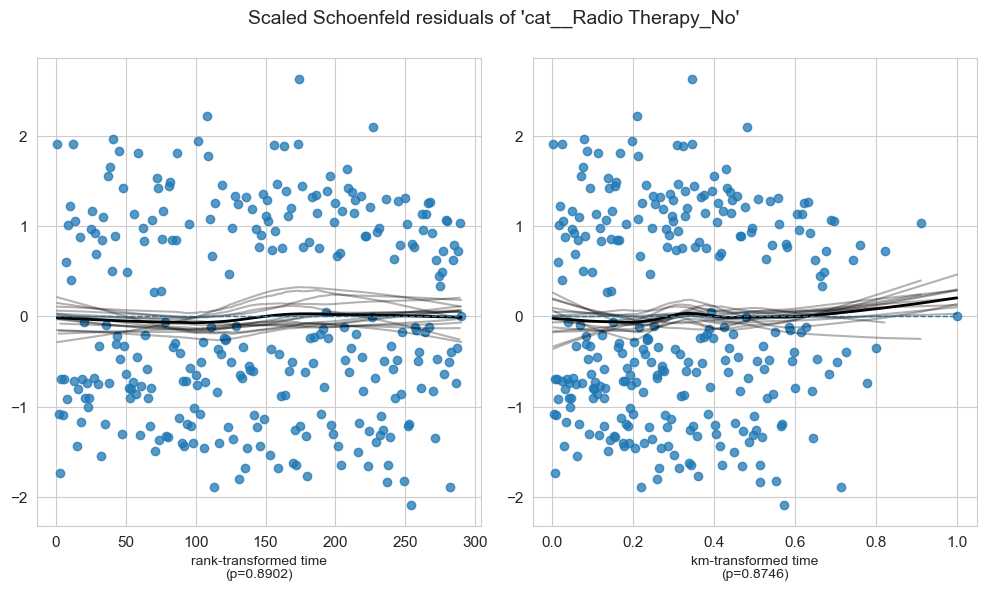

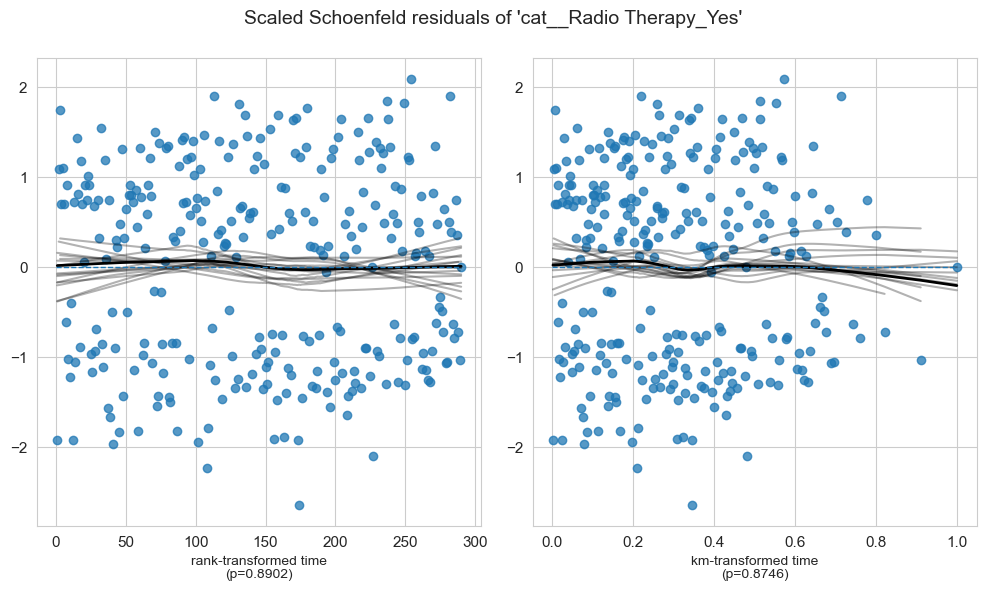

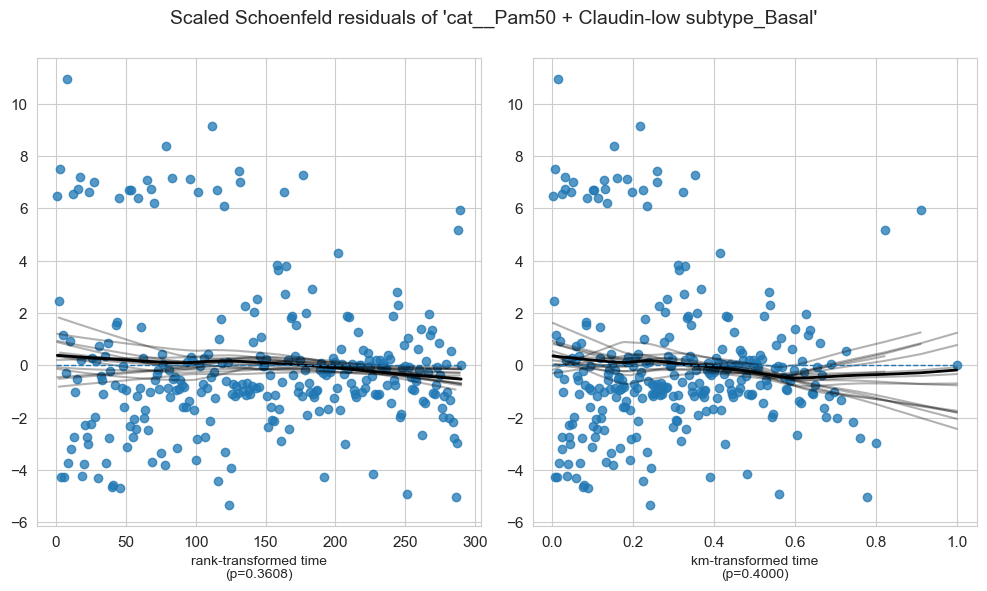

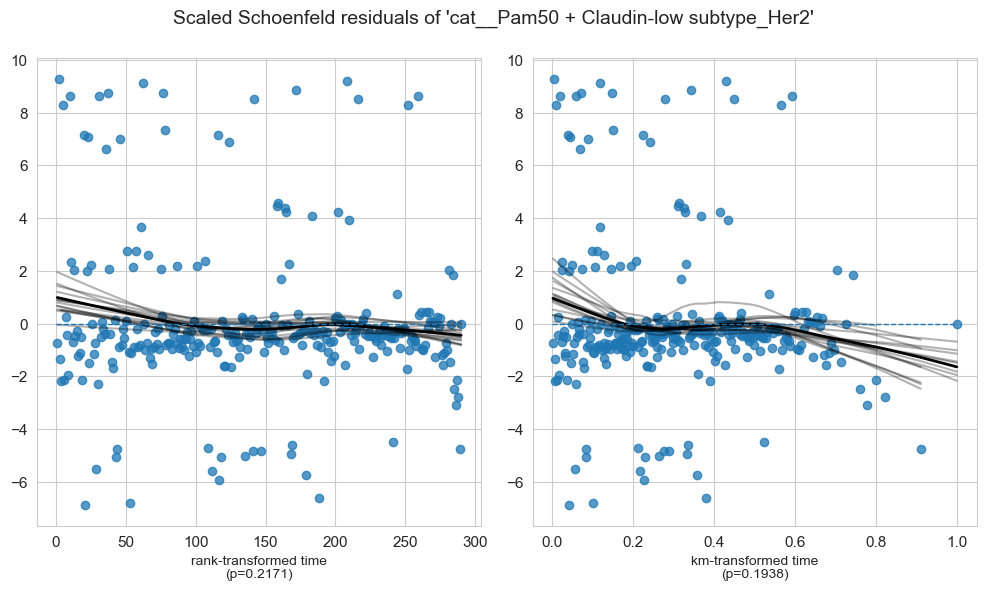

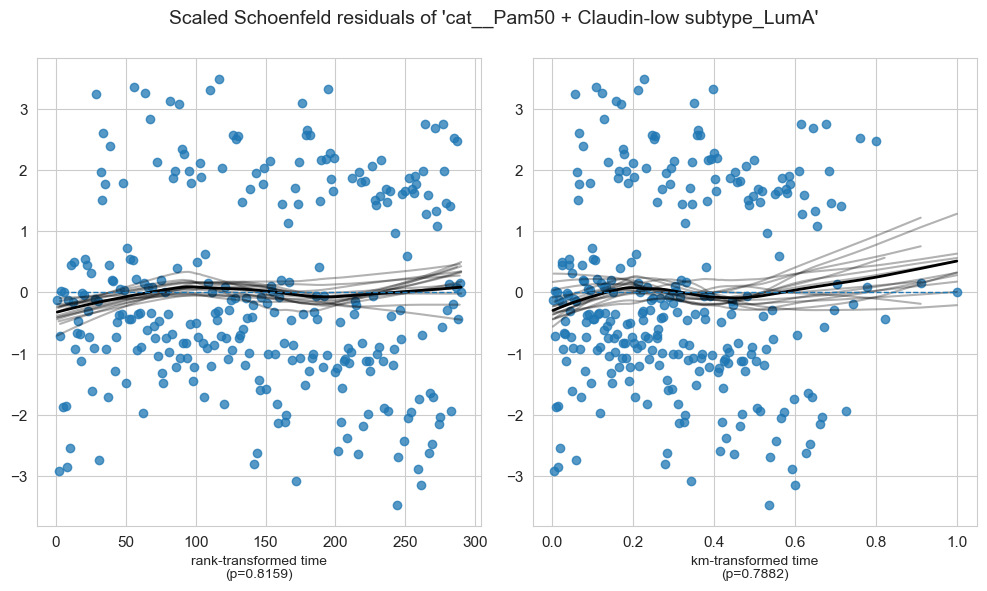

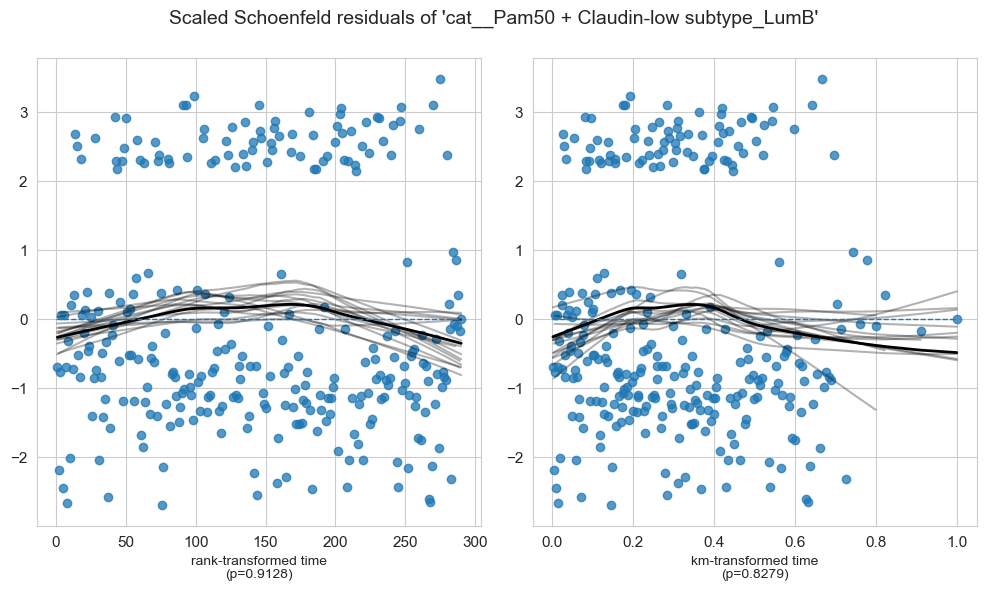

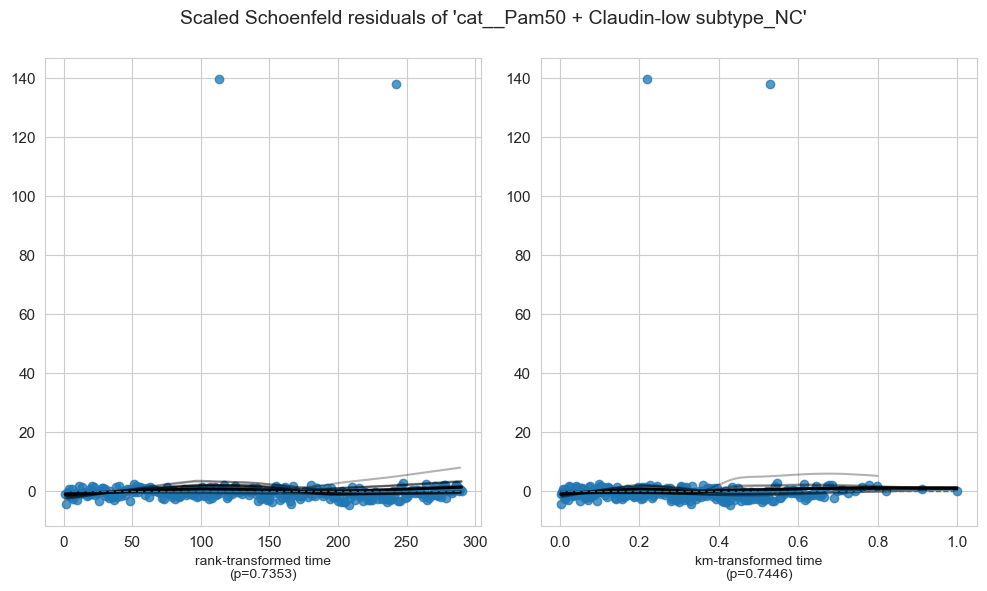

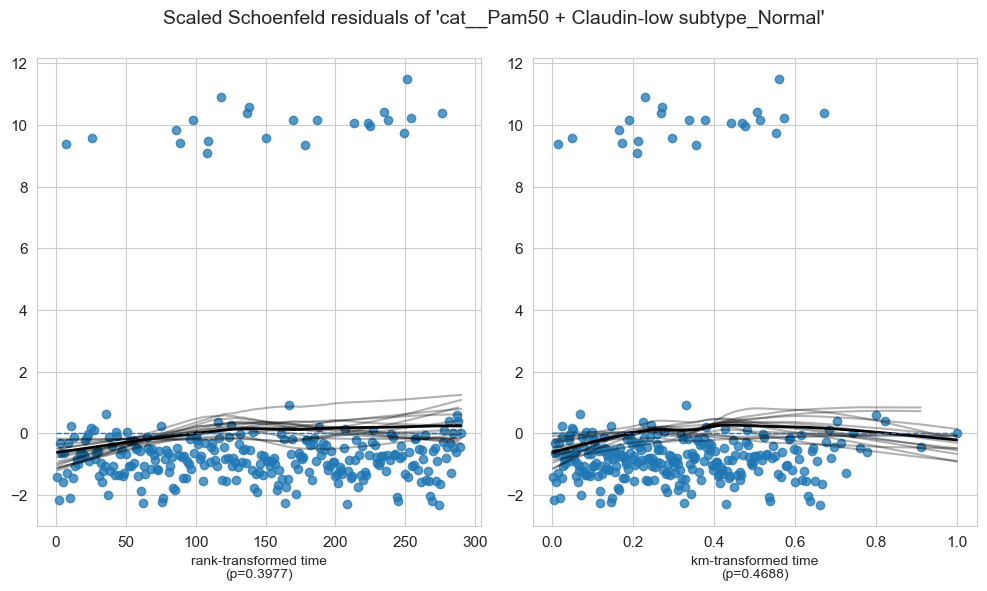

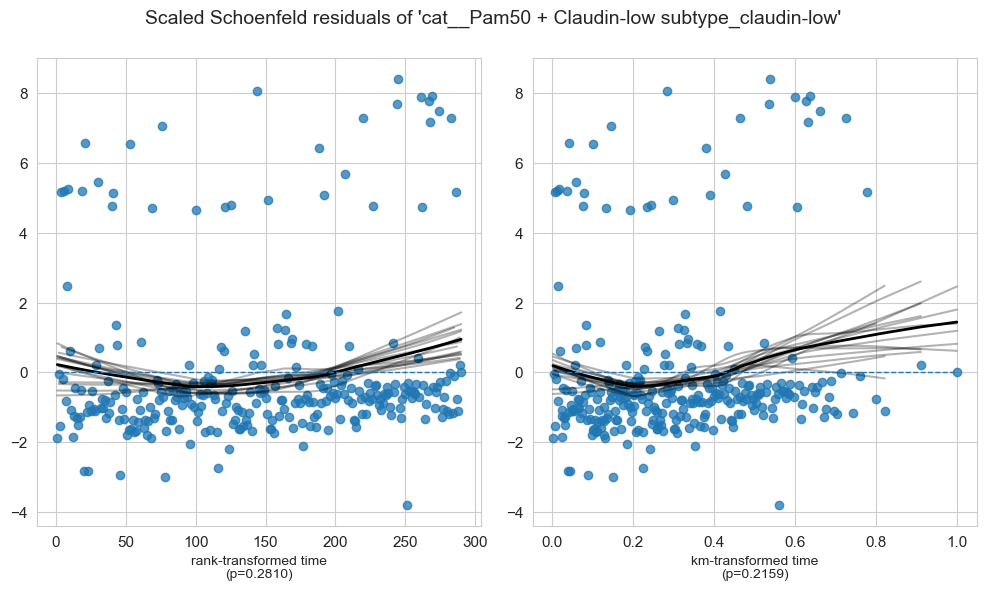

In [39]:
outcome_cols = [cph_model.duration_col, cph_model.event_col]
all_cols_to_exclude = strat_cols + outcome_cols

# DF will be used to fit a TEMPORARY, non-stratified CPH model
covariates_only_df = train_cox_df.drop(columns=strat_cols, errors='ignore')


# TEMPORARY CPH Model (w/out stratification)
# Used solely for the check_assumptions function. Only includes variables that have coefs in final model.
cph_model_for_ph_check = CoxPHFitter(penalizer=0.1)

# Fit the temporary model. No strata argument here!
cph_model_for_ph_check.fit(
    covariates_only_df, 
    duration_col=cph_model.duration_col, 
    event_col=cph_model.event_col
)

print("Running PH check on the independent covariates...")
print("Checking PH assumption for: ", cph_model_for_ph_check.params_.index.tolist())


# The function will automatically flag any variables that fail the test (p < 0.05)
cph_model_for_ph_check.check_assumptions(
    training_df=covariates_only_df,
    p_value_threshold=0.05,
    show_plots=True
) 

suspect_keywords = [
    'Grade', 'ER Status', 'PR Status', 'Tumor Stage', 'Lymph nodes'
]

# 2) Convenience: print the covariate names that might be most at risk of non-PH
suspect_terms = [c for c in train_cox_df.columns
                if any(keyword in col for keyword in suspect_keywords)]
print("\nCovariates to scrutinize first:", suspect_terms)



## 7.3 Forest Plot for Visualization of Models Results

--- Forest Plot of Multivariable Cox Model ---


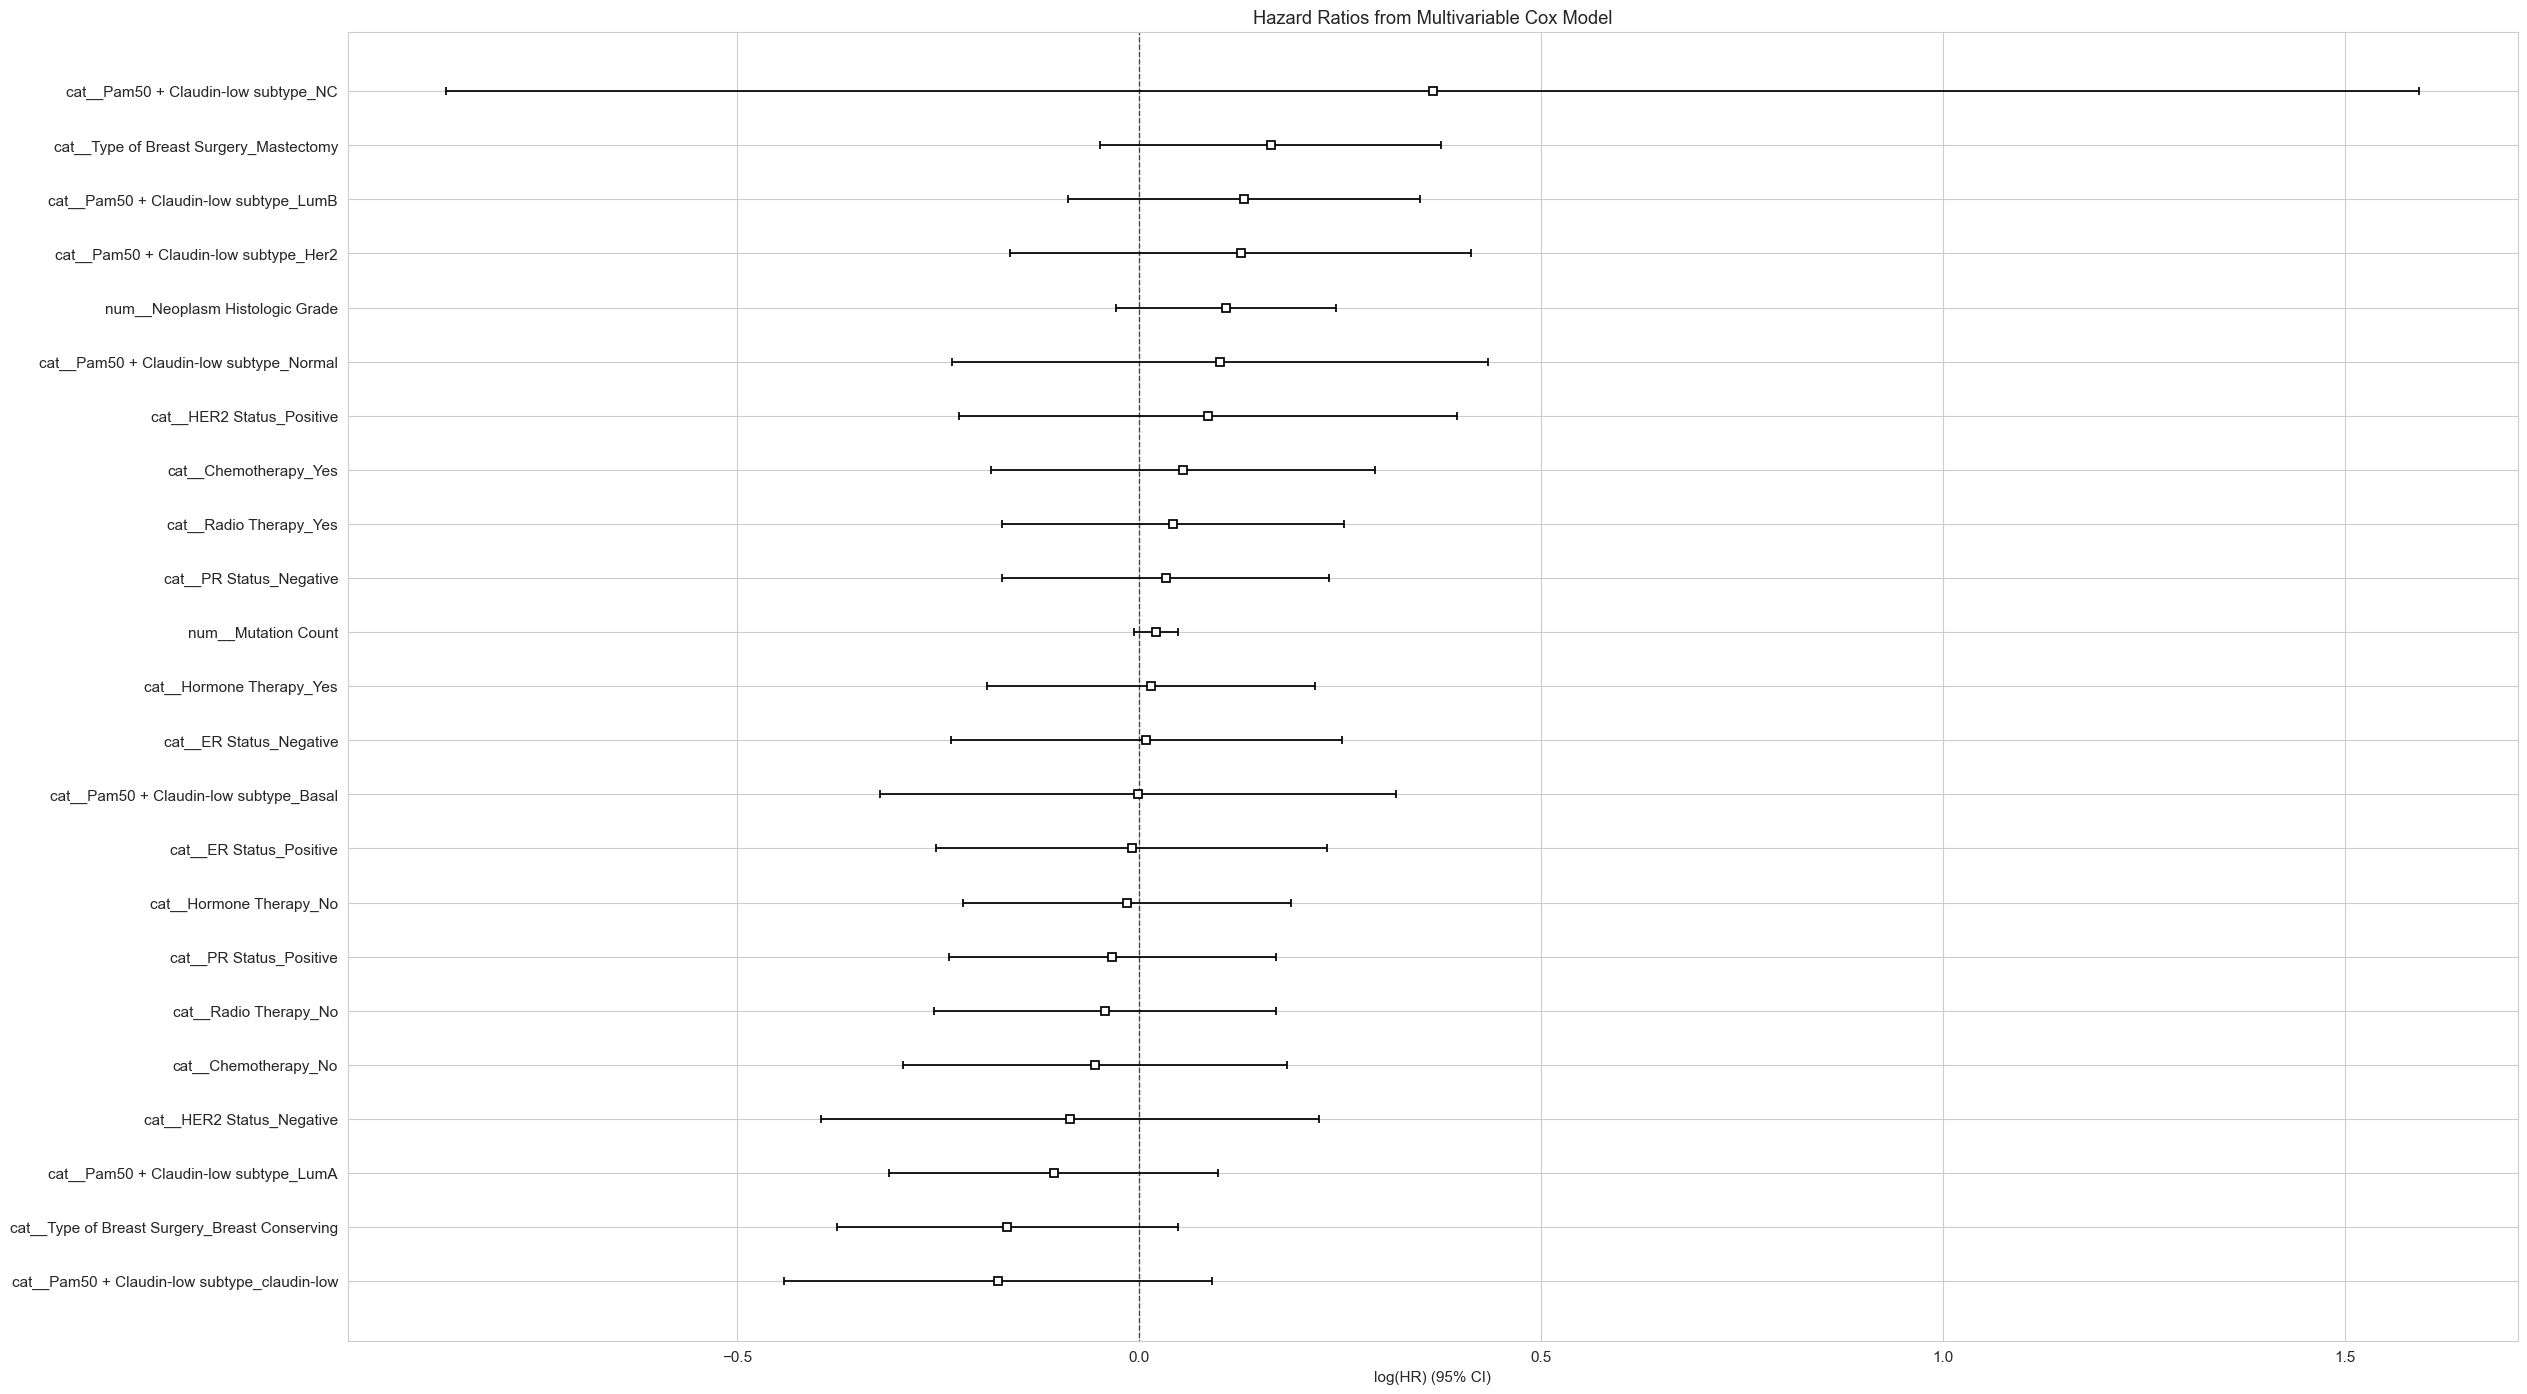

In [40]:
# The lifelines library has a convenient built-in function to create a forest plot.
# This is much simpler than building it manually.
summary_df = cph_model.summary
sorted_summary = summary_df.sort_values(by="exp(coef)", ascending=False)

print("--- Forest Plot of Multivariable Cox Model ---")
fig, ax = plt.subplots(figsize=(28, 17))

cph_model.plot(ax=ax)

ax.set_title("Hazard Ratios from Multivariable Cox Model")
plt.show()

## 7.4 Individual Predictions and Risk Seperation

Using our model to assign a risk score (hazard) to each patient and see how well it separates them into different risk groups (cohorts)

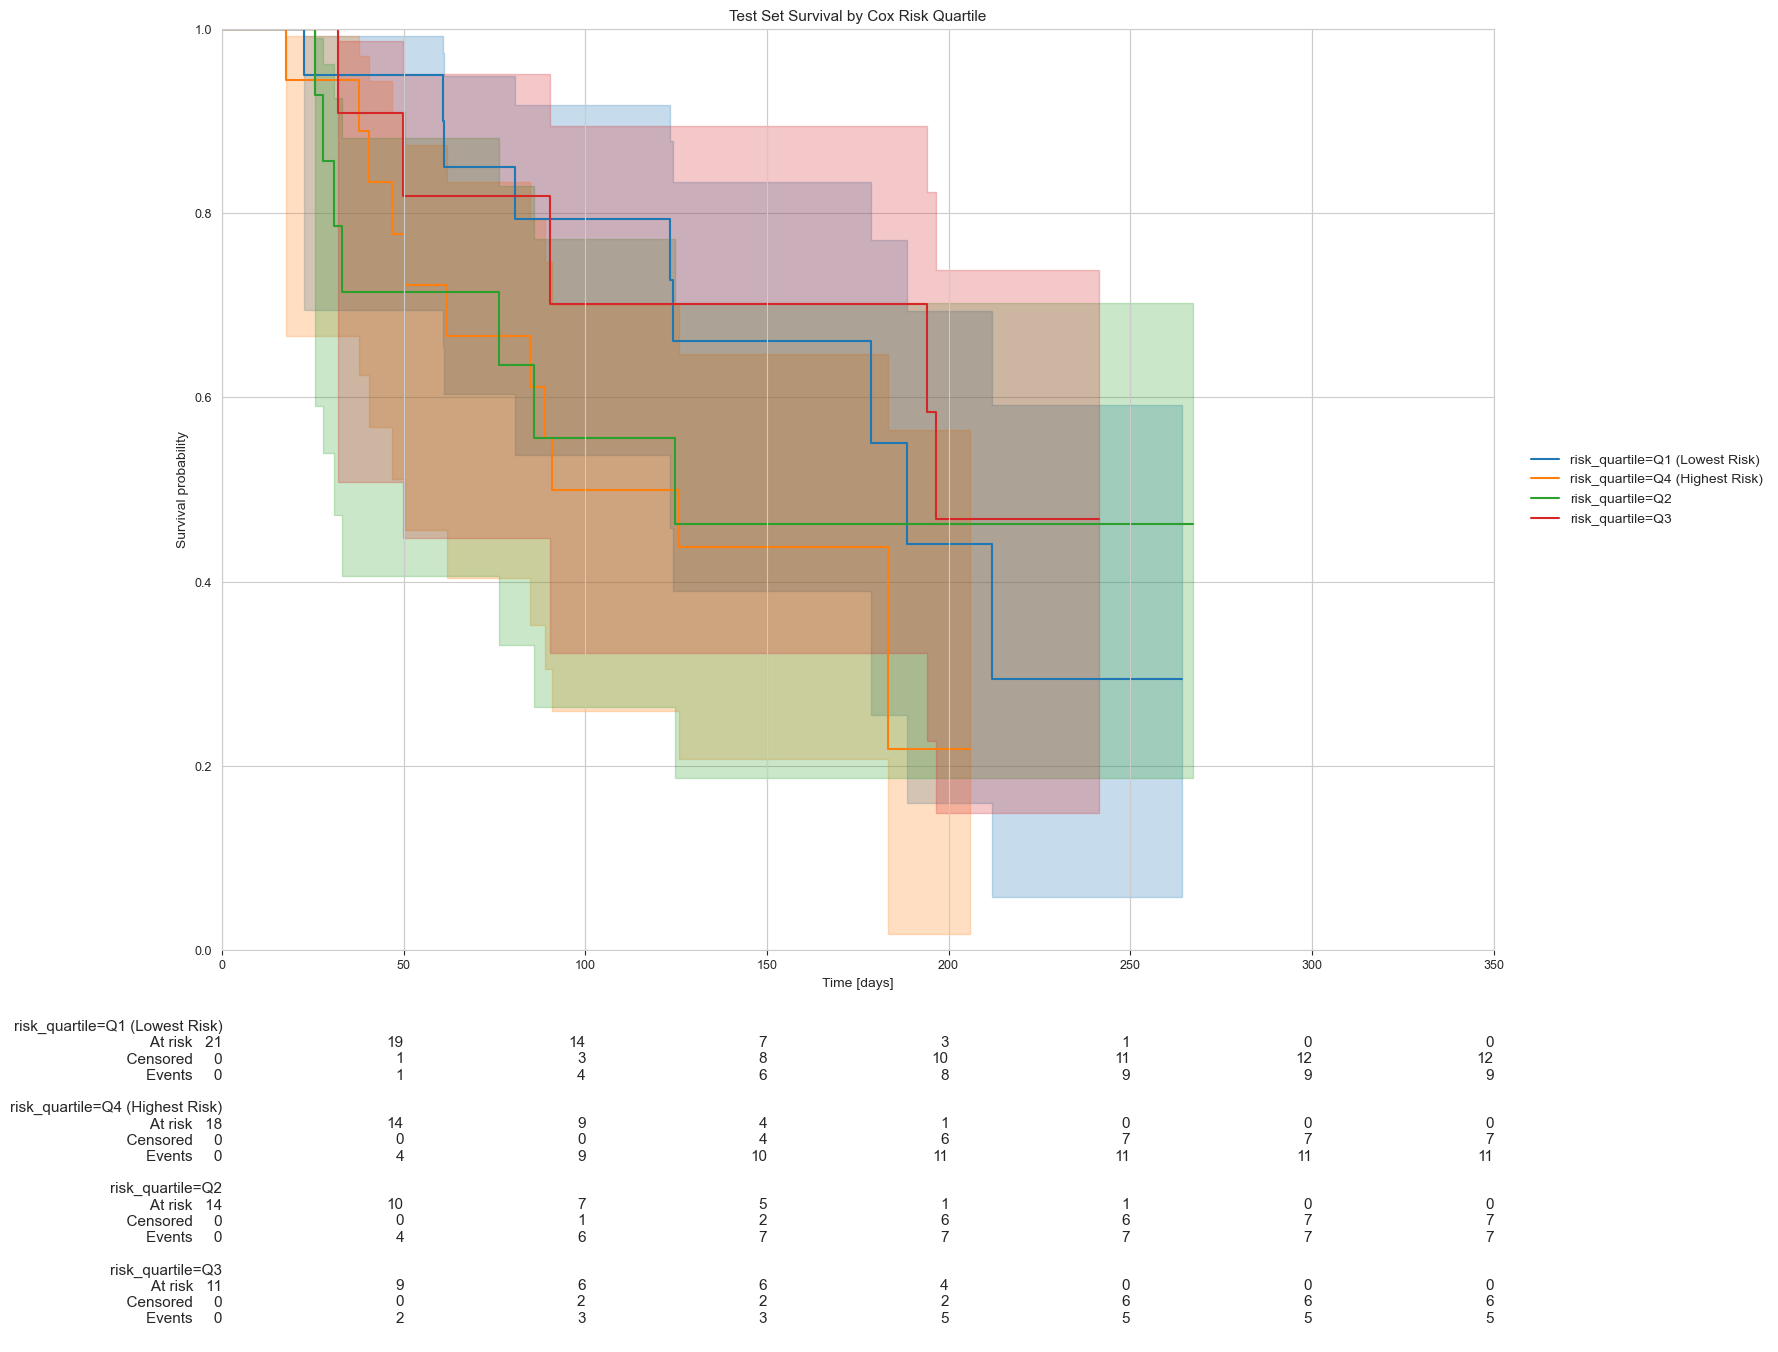

In [41]:
# 1) Transform features
# X_test_cox_indiivudals = utils.to_dataframe(cox_preprocessor, X_test)
# X_train_cox_individuals = utils.to_dataframe(cox_preprocessor, X_train)

train_nan_mask = X_train_cox.isnull().any(axis=1)
test_nan_mask = X_test_cox.isnull().any(axis=1)
val_nan_mask = X_val_cox.isnull().any(axis=1)


if train_nan_mask.any() or test_nan_mask.any():
    print("Warning: NaN values found in feature dataframes. Dropping rows to ensure clean predictions.")
    X_train_cox_clean = X_train_cox.dropna()
    X_test_cox_clean = X_test_cox.dropna()
    X_val_cox_clean = X_val_cox.dropna()

    # Drop the same rows from the y dataframes to maintain alignment
    # Use index of the cleaned X dataframes to select the correct rows from y
    y_train_clean = y_train.loc[X_train_cox_clean.index]
    y_test_clean = y_test.loc[X_test_cox_clean.index]
    # y_val_clean = y_test.loc[X_val_cox_clean.index]

else:
    X_train_cox_clean = X_train_cox
    X_test_cox_clean = X_test_cox.copy()
    X_val_cox_clean = X_val_cox
    y_train_clean = y_train
    y_test_clean = y_test.copy()
    y_val_clean = y_val 
    


# 2) Compute risk scores and define quartiles on the training set
risk_train = cph_model.predict_partial_hazard(X_train_cox_clean).values
# risk_train = cph_model.predict_partial_hazard(train_cox_df).values
risk_test = cph_model.predict_partial_hazard(X_test_cox_clean).values
risk_val = cph_model.predict_partial_hazard(X_val_cox_clean).values


q1, q2, q3 = np.quantile(risk_train, [0.25, 0.50, 0.75])
bins = np.unique([-np.inf, q1, q2, q3, np.inf])
if len(bins) - 1 < 4:
    # If fewer than 4 intervals, reduce the number of labels.
    labels = [f"Group {i+1}" for i in range(len(bins)-1)]
    print(f"Warning: Risk scores are not diverse enough for 4 quartiles. Using {len(labels)} groups instead.")
else:
    labels = ["Q1 (Lowest Risk)", "Q2", "Q3", "Q4 (Highest Risk)"]

test_groups = pd.cut(risk_test, bins=bins, labels=labels, include_lowest=True)

# 3) Prepare evaluation DataFrame for the test set
test_eval_df = pd.concat(
    [y_test[["duration_os", "event_os"]].copy().reset_index(drop=True),
     pd.Series(test_groups, name="risk_quartile")],
    axis=1
).rename(columns={"duration_os": "duration", "event_os": "event"})

test_eval_df.dropna(subset=['risk_quartile'], inplace=True)


# 4) Plot with a larger figure size
fig, ax, logrank = utils.km_by_group(
    df=test_eval_df,
    group_col="risk_quartile",
    time_col="duration",
    event_col="event",
    xmax=350,
    show_table=True,
    figsize=(20, 12)
)

ax.set_title("Test Set Survival by Cox Risk Quartile", fontsize=11)
ax.set_xlabel(ax.get_xlabel(), fontsize=10)
ax.set_ylabel(ax.get_ylabel(), fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=9)

for item in ax.texts:
    item.set_fontsize(9)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(right=0.75, bottom=0.2)
plt.show()



This data confirms that the Cox Proportional Hazards model (used to assign the risk scores Q1-Q4) is performing effectively:
* Discrimination: The model successfully discriminates patients based on their true underlying survival risk. The patients identified as highest risk (Q4) actually experience the most deaths, confirming our model's ranking ability is high.
* Prognostic Value: This provides strong evidence of prognostic stratification. Clinicians can rely on the risk score output (Q1 to Q4) to inform treatment intensity and follow up schedules. Patients falling in the Q4 category require the most urgent and intensive management.

### 7.4.1 Personalized Survival Predictions

Visualizing the full survival curve for specific individuals. This transforms the model's abstract risk score into a tangible, time-dependent forecast for a given patient

**We will select two patients from the test set:**
* One with the lowest predicted risk
* One with the highest

Feature values for the selected low-risk and high-risk patients:


,num__Neoplasm Histologic Grade,num__Mutation Count,cat__Type of Breast Surgery_Breast Conserving,cat__Type of Breast Surgery_Mastectomy,cat__Chemotherapy_No,cat__Chemotherapy_Yes,cat__ER Status_Negative,cat__ER Status_Positive,cat__PR Status_Negative,cat__PR Status_Positive,cat__HER2 Status_Negative,cat__HER2 Status_Positive,cat__Hormone Therapy_No,cat__Hormone Therapy_Yes,cat__Radio Therapy_No,cat__Radio Therapy_Yes,cat__Pam50 + Claudin-low subtype_Basal,cat__Pam50 + Claudin-low subtype_Her2,cat__Pam50 + Claudin-low subtype_LumA,cat__Pam50 + Claudin-low subtype_LumB,cat__Pam50 + Claudin-low subtype_NC,cat__Pam50 + Claudin-low subtype_Normal,cat__Pam50 + Claudin-low subtype_claudin-low,Tumor Stage,Age_Stratum,NPI_Stratum
294,2.0,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Age_M50_65,NPI_Moderate
271,3.0,6.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,Age_G65,NPI_Moderate


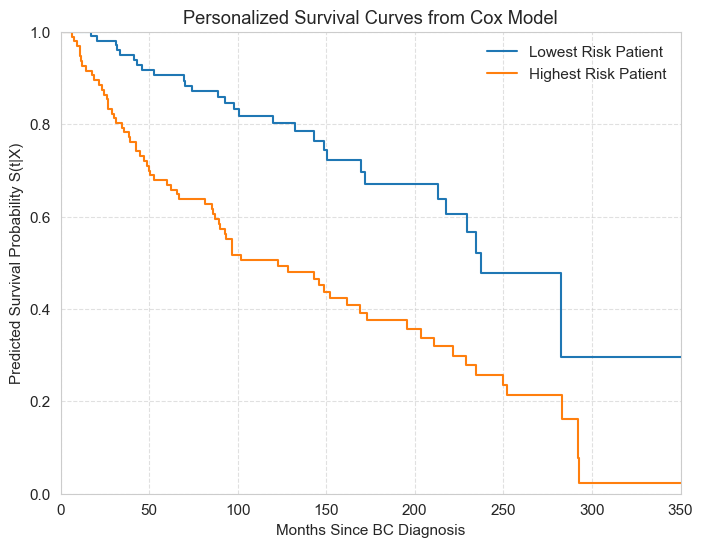


--- Fixed-Horizon Predictions ---



,Low-Risk Survival,Low-Risk Mortality,High-Risk Survival,High-Risk Mortality
50-Month,91.74%,8.26%,69.95%,30.05%
100-Month,83.20%,16.80%,51.75%,48.25%
120-Month,80.27%,19.73%,50.62%,49.38%
180-Month,67.12%,32.88%,37.58%,62.42%
240-Month,47.74%,52.26%,25.62%,74.38%
300-Month,29.69%,70.31%,2.26%,97.74%
350-Month,29.69%,70.31%,2.26%,97.74%


In [42]:
# Requires: X_test_cox, risk_test, cph_multi from the previous cell
# Produces: A plot of survival curves for two example patients and their fixed-horizon survival probabilities
results_df_test = X_test_cox_clean.copy()
results_df_test['risk_score'] = risk_test
results_df_test['risk_quartile'] = test_groups

# 1. Find the index for the lowest and highest-risk patients in the TEST set

# Lowest risk patient (from Q1)
q1_df = results_df_test[results_df_test['risk_quartile'] == 'Q1 (Lowest Risk)']
median_risk_q1 = q1_df['risk_score'].median()
low_risk_idx = (q1_df['risk_score'] - median_risk_q1).abs().idxmin()

# Highest risk patient (from Q4)
q4_df = results_df_test[results_df_test['risk_quartile'] == 'Q4 (Highest Risk)']
median_risk_q4 = q4_df['risk_score'].median()
high_risk_idx = (q4_df['risk_score'] - median_risk_q4).abs().idxmin()

patient_pair_df = X_test_cox_clean.loc[[low_risk_idx, high_risk_idx]]
# patient_pair_df = X_test_cox.loc[[low_risk_idx, high_risk_idx]]


print("Feature values for the selected low-risk and high-risk patients:")
display(patient_pair_df)

# 2. Predict the full survival functions for these two patients
# The result is a DataFrame with time-points as the index and patients as columns
survival_functions = cph_model.predict_survival_function(patient_pair_df)

# 3. Plot the personalized survival curves
plt.figure(figsize=(8, 6))
plt.step(survival_functions.index, survival_functions.iloc[:, 0], where="post", label="Lowest Risk Patient")
plt.step(survival_functions.index, survival_functions.iloc[:, 1], where="post", label="Highest Risk Patient")

plt.xlim(0, 350)
plt.ylim(0, 1)
plt.xlabel("Months Since BC Diagnosis")
plt.ylabel("Predicted Survival Probability S(t|X)")
plt.title("Personalized Survival Curves from Cox Model")
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Extract survival probabilities and display them in a formatted table
eval_times = [50.0, 100.0, 120.0, 180.0, 240.0, 300.0, 350.0]
sf_at_times = cph_model.predict_survival_function(patient_pair_df, times=eval_times)

# Create a clean DataFrame for the results
results_df = pd.DataFrame({
    'Low-Risk Patient': sf_at_times.iloc[:, 0].values,
    'High-Risk Patient': sf_at_times.iloc[:, 1].values
}, index=[f"{int(t)}-Month" for t in eval_times])

# Add mortality risk columns
results_df['Low-Risk Mortality'] = 1 - results_df['Low-Risk Patient']
results_df['High-Risk Mortality'] = 1 - results_df['High-Risk Patient']

# Rename survival columns for clarity
results_df.rename(columns={'Low-Risk Patient': 'Low-Risk Survival', 'High-Risk Patient': 'High-Risk Survival'}, inplace=True)

print("\n--- Fixed-Horizon Predictions ---\n")
# Display the styled DataFrame
display(results_df[['Low-Risk Survival', 'Low-Risk Mortality', 'High-Risk Survival', 'High-Risk Mortality']].style.format("{:.2%}").set_caption("Predicted Survival & Mortality Risk"))

Early Mortality: The highest-risk patients (Q4) have an immediate and sharp drop in survival probability (survival curve drops by 30.05% by 50 months, compared to 8.26% for Q1). This indicates a much earlier and higher hazard (risk of death). 

Long-Term Prediction: The model predicts the low-risk patient (Q1) to be an excellent long-term survivor, with a 67.12% chance of survival at 180 months. The high-risk patient is predicted to have a mortality risk near 100% (97.74%) by 300 months, showing a high degree of prognostic stratification.

The feature comparison of the two patients reveals the common profiles, with the low risk patient having a Histologic Grade of 2.0, Mutation Count of 4.0, the Surgery type of Breast Conserving, low Cellularity, negative PR status, and the ER+/HER2 Low Prolif 3-Gene subtype. The high risk patient has a Histologic Grade of 3.0 (higher grade, higher risk), Mutation Count of 6.0 (higher mutation count, higher risk), the Surgery type of Mastectomy (reflects a more complex disease), high Cellularity (high cellularity is often more aggressive), positive PR status, and the ER+/HER2 High Prolif 3-Gene subtype (higher proliferation, higher risk).

The high-risk patient has a set of features associated with a more aggressive tumor biology, including Higher Histologic Grade, Higher Mutation Count, High Cellularity, and an ER+/HER2 High Proliferation subtype. This aggressive biological profile provides the clinical rationale for the model's prediction of a nearly 98% mortality risk by 300 months. The low-risk profile shows the opposite pattern, leading to the predicted excellent long-term survival.


### 7.4.2 Time-Dependent Model Performance 

The Concordance (C-index) gives us a single number for model performance over the entire follow-up period. However, in a clinical setting, performance at specific time points is often more important:

*"How well does our model predict the risk of Breast Cancer death at 50, 100, 180, etc months for the set of patients at those times?"*

We are evaluating the cause-specific hazard performance at different points in time. 

In [43]:
# --- 1. Setup ---
X_test_cox_clean = X_test_cox.loc[test_cox_df.index.tolist()].copy()
y_test_cleaned = y_test.loc[test_cox_df.index.tolist()].copy()
clean_test_index = X_test_cox_clean.index
y_test_cleaned = y_test.loc[clean_test_index].copy()
min_time = y_test_cleaned['duration_os'].min()
max_time = y_test_cleaned['duration_os'].max()
print(f"Valid time range for evaluation based on the test set: [{min_time:.2f}, {max_time:.2f})")

eval_times = np.array([50.0, 100.0, 120.0, 180.0, 240.0, 300.0, 350.0], dtype=float)
adjusted_eval_times = eval_times[eval_times < max_time]
print(f"Original eval_times: {eval_times}")
print(f"Adjusted eval_times to be used for Brier score: {adjusted_eval_times}")


y_train_surv = Surv.from_arrays(
    event=y_train["event_os"].astype(bool).to_numpy(),
    time=y_train["duration_os"].to_numpy(dtype=float)
)
y_test_surv = Surv.from_arrays(
    event=y_test_cleaned["event_os"].astype(bool).to_numpy(),
    time=y_test_cleaned["duration_os"].to_numpy(dtype=float)
)

print(f"y_train_surv_clean length: {len(y_train_surv)}")
print(f"y_test_surv_clean length: {len(y_test_surv)}") # Should now match risk_test (60)


# --- 2. Time-Dependent AUC (Corrected Logic) ---
def get_auc_at_time(t):
    """
    Robustly calculates AUC at a single time t, handling data insufficiency
    and varied output formats from the scikit-survival library.
    """
    # Check for sufficient data in both train and test sets
    events_train = y_train["event_os"].astype(bool)
    times_train = y_train["duration_os"]
    train_ok = (events_train & (times_train <= t)).any() and (times_train > t).any()
    
    events_test = y_test_cleaned["event_os"].astype(bool)
    times_test = y_test_cleaned["duration_os"]
    test_ok = (events_test & (times_test <= t)).any() and (times_test > t).any()
    
    if not (train_ok and test_ok):
        return np.nan
    
    # Calculate AUC
    raw_output = cumulative_dynamic_auc(y_train_surv, y_test_surv, risk_test, [t])
    
    # Handle inconsistent return formats from the library
    # Sometimes it returns a tuple (times, scores), sometimes just scores
    if isinstance(raw_output, tuple):
        auc_scores_array = raw_output[1]
    else:
        auc_scores_array = raw_output
        
    # Ensure the result is a 1D array and return the first (and only) score
    return np.atleast_1d(auc_scores_array)[0]

# Calculate AUC for each time point
auc_scores = [get_auc_at_time(t) for t in adjusted_eval_times]


# --- 3. Brier Score Calculation ---
sf_at_times = cph_model.predict_survival_function(X_test_cox_clean, times=adjusted_eval_times)
survival_prob_matrix = sf_at_times.T.to_numpy()
_, brier_scores = brier_score(y_train_surv, y_test_surv, survival_prob_matrix, adjusted_eval_times)


# --- 4. Assemble and Display Results ---
performance_df = pd.DataFrame({
    "Time Horizon (Months)": adjusted_eval_times.astype(int),
    "Time-Dependent AUC": auc_scores,
    "Brier Score": brier_scores
})

print("\n--- Time-Dependent Model Performance ---\n")
display(performance_df.style.format({
    "Time-Dependent AUC": "{:.3f}",
    "Brier Score": "{:.3f}"
}).hide(axis="index"))

Valid time range for evaluation based on the test set: [3.77, 205.03)
Original eval_times: [ 50. 100. 120. 180. 240. 300. 350.]
Adjusted eval_times to be used for Brier score: [ 50. 100. 120. 180.]
y_train_surv_clean length: 1188
y_test_surv_clean length: 64

--- Time-Dependent Model Performance ---



Time Horizon (Months),Time-Dependent AUC,Brier Score
50,0.699,0.145
100,0.678,0.220
120,0.600,0.239
180,0.645,0.133


The T-AUC of model reveals that the model is best at distinguishing between low and high risk patients in the early stages (50 months) but maintains a moderate performance for the stages after. 

The Brier score measures the accuracy (mean squared error) of the predicted survival probabilities at specific time points, with the lower the score the better. At 50 months, there is a score of 0.145, which is excellent accuracy. After 100 months, the error increases to .22, then at 120 months to .239, but then considerably improves at 180 months to 0.133 (our lowest error). The low Brier Score at 50 months indicates short term survival probability predictions are very well calibrated. The high Brier Score at 120 months suggests the model's predicted survival probabilities at this horizon are less accurate. The drop at 180 months (from 0.239 To 0.137) is likely due to the small number of patients remaining at that late time point in the test set, which can stabilize the error calculation based on the few remaining uncensored events. This late term score should be interpreted with caution.

### 7.4.3 Comparing Model with Simple Baseline

A simple baseline model that ignores all patient-specific features. It predicts the same survival probability for every patient, based on the overall survival rate of the training cohort (calculated with a Kaplan-Meier estimator).

By comparing our Cox model to this naive baseline, we can calculate the Brier Skill Score (BSS). This tells us how much better our model is than simply guessing the population average. A positive BSS means our model has learned useful patterns from the patient data. A negative BSS means our model is worse than the baseline. 



In [44]:
# 1. Fit a Kaplan-Meier estimator on the TRAINING data to create the baseline
kmf_baseline = KaplanMeierFitter()
kmf_baseline.fit(y_train["duration_os"], y_train["event_os"])

# 2. Get the baseline survival probability predictions at our evaluation times
# This gives one probability for each time point, which we apply to all test patients
baseline_surv_probs = np.asarray(kmf_baseline.predict(adjusted_eval_times).values)

# 3. Create the prediction matrix required by brier_score
# We repeat the baseline predictions for every patient in the test set
n_test_patients = len(y_test_surv)
baseline_pred_matrix = np.tile(baseline_surv_probs, (n_test_patients, 1))

# 4. Calculate the Brier score for this baseline model
_ , baseline_brier_scores = brier_score(
    y_train_surv, y_test_surv, baseline_pred_matrix, adjusted_eval_times
)

# 5. Calculate the Brier Skill Score (BSS)
# 'brier_scores' is the brier score from our Cox model in the previous cell
brier_skill_scores = 1 - (brier_scores / baseline_brier_scores)

# 6. Display the results in a comparative table
results_df = pd.DataFrame({
    'Cox Model Brier Score': brier_scores,
    'Baseline Brier Score': baseline_brier_scores,
    'Brier Skill Score (BSS)': brier_skill_scores
}, index=[f"{int(t)}-Month" for t in adjusted_eval_times])

print("\n--- Brier Score Comparison ---\n")
display(results_df.style.format("{:.3f}"))


--- Brier Score Comparison ---



,Cox Model Brier Score,Baseline Brier Score,Brier Skill Score (BSS)
50-Month,0.145,0.143,-0.011
100-Month,0.220,0.193,-0.142
120-Month,0.239,0.202,-0.180
180-Month,0.133,0.119,-0.114


All of the time periods BSS score is <0, indicating they all have worse predictive accuracy than the baseline. This is due to the CPH model being much more complex while being fit on only 524 non-NAN patients and tested on only 64. Complex models need larger datasets, but attempts to reduce feature set complexity did not improve its accuracy. The CPH model is not useless but is over-regularized, causing the mdoel to make systemic errors in the magnitude of the survival probabilites, even if our ranking/C-index is stil good. 

However, the CPH model still has significant value due to high discriminiation (a high C-index of ~0.7), meaning the model is excellent at ranking patients and identifying who is low/high risk. The KM curves seperated perfectly, confirming the strong discrimination. 

The model has correctly identified a set of clinically relevent risk factors (Grade, ER/PR/HER2 status) that independently contribute to hazard rate. These are meaningful to understanding the disease, even if the absolute predicted probabilities are flawed. 

### 7.4.4 Estimating True Absolute Risk with a Competing Risks Model

We now address the competing risk of death directly in our analysis of recurrence. Our goal is to answer more precise and clinically relevant question:

"What is the actual probability that a breast cancer patient will have a recurrence, considering they could pass away from other causes first?"

The Cause-Specific Hazards Method To solve this, we will build two separate Cox models, as a standard/ robust approach:
* The Recurrence Model: Predicts the hazard of cancer recurrence (treating death without recurrence as a censored event).
* The Competing Death Model: Predicts the hazard of death without recurrence (treating recurrence as a censored event).

We will then combine the hazards from both models to calculate the Cumulative Incidence Function (CIF). Finally, we will check how well our model is calibrated by comparing its average predicted risk to the actual observed risk in the test set

In [45]:
#Competing risks with cause-specific Cox focused on 
EVENT_OF_INTEREST_COL = "event_rfs"  
COMPETING_EVENT_COL = "event_competing_death"

# 0) Ensure we have an explicit discharge indicator
for df_name in ["y_train", "y_val", "y_test"]:
    if df_name in globals():
        df_y = globals()[df_name]
        if 'event_os' not in df_y.columns or 'event_rfs' not in df_y.columns:
             raise KeyError(f"The columns 'event_os' and 'event_rfs' must exist in {df_name}")
        df_y["event_competing_death"] = ((df_y["event_os"] == 1) & (df_y["event_rfs"] == 0)).astype(int)

COMPETING_EVENT_COL = "event_competing_death"
H = np.array([50.0, 100.0, 120.0, 180.0, 240.0, 300.0], dtype=float)  # we still compute all, but   is the focus

# 1) Preprocess features
X_tr = utils.to_dataframe(cox_preprocessor, X_train)
# X_val = utils.to_dataframe(cox_preprocessor, X_val)
X_te = utils.to_dataframe(cox_preprocessor, X_test)

# 2) Cause-specific training frames
def _cs(X_df, y_df, event_col):
    out = pd.concat(
        [X_df.reset_index(drop=True),
         y_df[["duration_rfs", event_col]].reset_index(drop=True)],
        axis=1
    )
    out["event_for_model"] = (out[event_col] == 1).astype(int)
    return out[["duration_rfs", "event_for_model"] + list(X_df.columns)]

df_tr_recurrence = _cs(X_tr, y_train, EVENT_OF_INTEREST_COL)
df_tr_competing  = _cs(X_tr, y_train, COMPETING_EVENT_COL)

# 3) Fit cause-specific Cox models
penalizer_value = 0.005
cph_recurrence = CoxPHFitter(penalizer=penalizer_value).fit(df_tr_recurrence, "duration_rfs", "event_for_model", show_progress=False)
cph_competing  = CoxPHFitter(penalizer=penalizer_value).fit(df_tr_competing,  "duration_rfs", "event_for_model", show_progress=False)

# print("Competing Death Model (cph_competing) Summary")
# cph_competing.print_summary(
#     decimals=3,
#     columns=["coef", "exp(coef)", "exp(coef) lower 95%", "p"]
# )


# 4) Predict patient-level CIF of death on the TEST set
pred_cif_df = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, H)  # CIF_7d, CIF_30d, CIF_60d
print(pred_cif_df.round(3).head(10))

calibration_horizon_months = 50.0 
# calibration_horizon_months = calibration_horizon_months * 30.0 
CALIBRATION_COLUMN = f"CIF_{int(calibration_horizon_months)}d"

# 5) Calibration at 7 days using nonparametric CIF by quartile
calib_50mo_df = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=pred_cif_df[CALIBRATION_COLUMN],
    duration_col="duration_rfs",
    event_col=EVENT_OF_INTEREST_COL,
    competing_col=COMPETING_EVENT_COL,
    horizon_days=calibration_horizon_months,
    n_bins=4
).rename(columns={"pred_mean_risk": f"pred_mean_risk_{int(calibration_horizon_months)}mo", 
                  "obs_risk": f"obs_risk_{int(calibration_horizon_months)}mo"}).round(3)
#.rename(columns={"pred_mean_risk": "pred_mean_risk_60mo", "obs_risk": "obs_risk_60mo"}).round(3)

print(calib_50mo_df)

      CIF_50d  CIF_100d  CIF_120d  CIF_180d  CIF_240d  CIF_300d
1465    0.298     0.419     0.457     0.546     0.594     0.794
1319    0.293     0.402     0.432     0.485     0.503     0.522
1568    0.217     0.308     0.336     0.393     0.417     0.468
100     0.319     0.436     0.469     0.531     0.553     0.585
1152    0.219     0.314     0.344     0.414     0.449     0.575
85      0.129     0.191     0.211     0.261     0.288     0.404
760     0.156     0.227     0.251     0.305     0.333     0.430
163     0.092     0.135     0.150     0.181     0.197     0.238
782     0.205     0.293     0.321     0.379     0.405     0.467
1370    0.249     0.350     0.381     0.444     0.470     0.526
  risk_quartile   n  pred_mean_risk_50mo  obs_risk_50mo
0     Q1 lowest  99                0.138          0.177
1            Q2  99                0.193          0.298
2            Q3  99                0.254          0.281
3    Q4 highest  99                0.366          0.421


This reinforces that the CPH model is unstable, with massive coefficient swings - features that were previously insignificant now have huge, unrealistic coefficient magnitudes (such as cat__Chemotherapy_No =0.622 and exp(coef)=1.862, indicating not receiving chemotherapy increases the hazard of competing death by 86%, which is clinically imposible). The 95% CI lower bounds are all 0.00 for nearly every categorical feature, indicating model errors are so large CI's are getting clipped - a sign of overfitting, aligning with the other signs that this model is too complex for such a small dataset.   

### 7.4.5 Improving Predictions with Calibration

To recalibrate our model, and ensure further medical usefulness and reliability, we'll use Isotonic Regression, which is a powerful non-parametric calibration technique, in order to corect the severe underestimations in the previous sections.
* Fit isotonic regression on training evaluable patients
* Apply to test predictions
* Show quartile calibration and a familiar sklearn calibration plot

,risk_quartile,n,pred_raw_50mo,pred_cal_50mo,observed_50mo
0,Q1 lowest,99,0.138,0.092,0.177
1,Q2,99,0.193,0.187,0.298
2,Q3,99,0.254,0.277,0.281
3,Q4 highest,99,0.366,0.435,0.421


,Model,Brier Score,N Test Evaluable
0,Cox-CIF raw 50mo,0.1791,366
1,Cox-CIF calibrated 50mo,0.1801,366


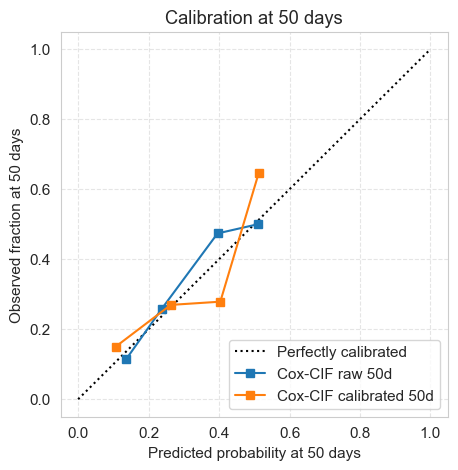

In [46]:
# Isotonic calibration at 60 months
PRIMARY_HORIZON_MONTHS = 50.0

# 1) Raw 60 m probabilities from the same competing-risk models used above
p_train_raw_50mo = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_tr, np.array([PRIMARY_HORIZON_MONTHS]))[f"CIF_{int(PRIMARY_HORIZON_MONTHS)}d"]
p_test_raw_50mo  = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, np.array([PRIMARY_HORIZON_MONTHS]))[f"CIF_{int(PRIMARY_HORIZON_MONTHS)}d"]


# 2) Fixed-horizon labels and evaluable masks at 50 month
y_train_temp = y_train.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_test_temp = y_test.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_val_temp = y_val.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_tr_50, eval_tr_50 = utils.get_fixed_horizon_labels(y_train_temp, PRIMARY_HORIZON_MONTHS)
y_te_50, eval_te_50 = utils.get_fixed_horizon_labels(y_test_temp, PRIMARY_HORIZON_MONTHS)

# 3) Fit isotonic on TRAIN evaluable and apply to TEST
iso_50 = IsotonicRegression(out_of_bounds="clip")
# iso_60.fit(p_train_raw_60mo[eval_tr_60].reshape(-1, 1), y_tr_60[eval_tr_60])
X_train_iso = p_train_raw_50mo[eval_tr_50].to_numpy().reshape(-1, 1)
y_train_iso = y_tr_50[eval_tr_50] 
iso_50.fit(X_train_iso, y_train_iso)


cal_output = iso_50.transform(p_test_raw_50mo.to_numpy().reshape(-1, 1))
if hasattr(cal_output, 'values'):
    flat_array = cal_output.values.ravel()
else:
    flat_array = cal_output.ravel()


p_test_cal_50mo = pd.Series(
    flat_array, 
    index=p_test_raw_50mo.index, 
    name="p_cal_50d")

# 4) Calibration by quartile on TEST at 50 month: before vs after vs observed
cal_raw_50 = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=p_test_raw_50mo,
    duration_col="duration_rfs",
    event_col="event_rfs",
    competing_col="event_competing_death",
    horizon_days=PRIMARY_HORIZON_MONTHS
).rename(columns={"pred_mean_risk": "pred_raw_50mo", "obs_risk": "observed_50mo"})

cal_cal_50 = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=p_test_cal_50mo,
    duration_col="duration_rfs",
    event_col="event_rfs",
    competing_col="event_competing_death",
    horizon_days=PRIMARY_HORIZON_MONTHS
).rename(columns={"pred_mean_risk": "pred_cal_50mo"})

calibr_table_50mo = (
    cal_raw_50.merge(cal_cal_50[["risk_quartile", "pred_cal_50mo"]], on="risk_quartile")
             .loc[:, ["risk_quartile", "n", "pred_raw_50mo", "pred_cal_50mo", "observed_50mo"]]
             .round(3)
)
display(calibr_table_50mo)
# 5) Brier score on TEST evaluable patients at 50 month: before vs after
brier_50mo_df = pd.DataFrame({
    "Model": [f"Cox-CIF raw {int(PRIMARY_HORIZON_MONTHS)}mo", f"Cox-CIF calibrated {int(PRIMARY_HORIZON_MONTHS)}mo"],
    "Brier Score": [
        brier_score_loss(y_te_50[eval_te_50], p_test_raw_50mo[eval_te_50]),
        brier_score_loss(y_te_50[eval_te_50], p_test_cal_50mo[eval_te_50])
    ],
    "N Test Evaluable": int(eval_te_50.sum())
}).round({"Brier Score": 4})
display(brier_50mo_df)

# 6) Familiar sklearn visualization for evaluable TEST patients at 50 month
utils.plot_calibration_at_horizon(
    y_true_bin=y_te_50,
    y_prob_raw=p_test_raw_50mo.to_numpy(copy=False),
    y_prob_cal=p_test_cal_50mo.to_numpy(copy=False),
    mask=eval_te_50,
    horizon_days=PRIMARY_HORIZON_MONTHS,
    n_bins=6
)

Applying Isotonic Regression helped calibrate/align the predicted column for the 50 month time period more closely with the observed column for the Q4 high risk group. Before calibration, the model said 36.7% while the observed was 41.0. Now, it says 43.5%, a slight overestimation but matches reality much more closely. 

The Brier Score is essentially unchanged, which is expected. 

These new scores indicate the model is ready to be used for counseling, provided using the calibrated probabilities. However, the Q1 group is being overestimated, showing the IR is struggling to map the lowest risks because the number of events in this group is typically low. This is a common limitation of non-parametric calibration in low/high risk event groups. 

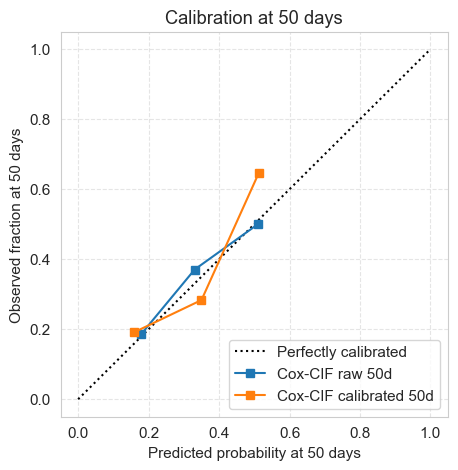

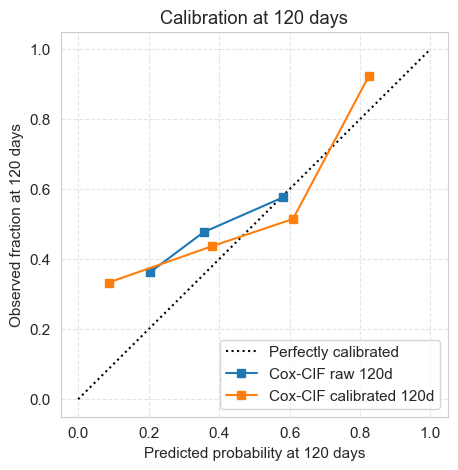

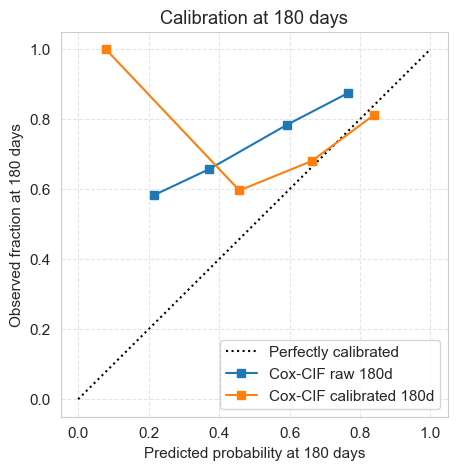

,model,set,horizon_months,auroc,auprc,brier,n_evaluable,n_used_for_metrics
6,Cox,test,50,0.655234,0.431070,0.180107,366,366
7,Cox,test,120,0.598576,0.584364,0.251554,293,293
8,Cox,test,180,0.609133,0.774901,0.223412,234,234
0,Cox,train,50,0.655234,0.431070,0.180107,366,366
1,Cox,train,120,0.598576,0.584364,0.251554,293,293
2,Cox,train,180,0.609133,0.774901,0.223412,234,234
3,Cox,val,50,0.655234,0.431070,0.180107,366,366
4,Cox,val,120,0.598576,0.584364,0.251554,293,293
5,Cox,val,180,0.609133,0.774901,0.223412,234,234


In [47]:
H = [50, 120, 180]
final_preds_test = {}
labels_rfs_test = {}

try:
    X_tr
    X_te
except NameError:
    X_tr = utils.to_dataframe(cox_preprocessor, X_train)
    X_te = utils.to_dataframe(cox_preprocessor, X_test)

for h in H:
    # 1) Raw probabilities from the competing-risk Cox models
    p_train_raw_h = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_tr, np.array([h]))[f"CIF_{int(h)}d"]
    p_test_raw_h  = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, np.array([h]))[f"CIF_{int(h)}d"]

    # 2) Fixed-horizon labels and evaluable mask
    # y_tr_h, eval_tr_h = utils.get_fixed_horizon_labels(y_train, h)
    # y_te_h, eval_te_h = utils.get_fixed_horizon_labels(y_test,  h)
    y_train_temp_h = y_train.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
    y_test_temp_h = y_test.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
    y_tr_h, eval_tr_h = utils.get_fixed_horizon_labels(y_train_temp_h, h)
    y_te_h, eval_te_h = utils.get_fixed_horizon_labels(y_test_temp_h,  h)

    # 3) Horizon-specific isotonic calibration fitted on TRAIN evaluable patients
    iso_h = IsotonicRegression(out_of_bounds="clip")
    iso_h.fit(p_train_raw_h[eval_tr_h], y_tr_h[eval_tr_h])

    # 4) Plot sklearn-style calibration on TEST evaluable patients
    p_test_cal_h_df = iso_h.transform(p_test_raw_h)
    p_test_cal_h = p_test_cal_h_df.to_numpy().ravel()
    final_preds_test[h] = pd.Series(p_test_cal_h, index=X_te.index)
    labels_rfs_test[h] = {
        "y_true": pd.Series(y_te_h, index=y_test.index).astype(int),
        "mask": pd.Series(eval_te_h, index=y_test.index).astype(bool)
    }


    utils.plot_calibration_at_horizon(
        y_true_bin=y_te_h,
        y_prob_raw=p_test_raw_h.to_numpy(copy=False),
        y_prob_cal=p_test_cal_h,
        mask=eval_te_h,
        horizon_days=h,
        n_bins=4
    )


cph_pred_train = utils.predict_fixed_horizon_risk_from_cox(
    cph_model, X_train_cox_clean, H
).reindex(y_train.index)
cph_pred_val = utils.predict_fixed_horizon_risk_from_cox(
    cph_model, X_val_cox_clean, H
).reindex(y_val.index)
cph_pred_test = utils.predict_fixed_horizon_risk_from_cox(
    cph_model, X_test_cox_clean, H
).reindex(y_test.index)

y_train_renamed = y_train.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_val_renamed = y_val.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_test_renamed = y_test.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})

labels_train, labels_val, labels_test = {}, {}, {}
for h in [50, 120, 180]:
    yb_tr, m_tr = utils.get_fixed_horizon_labels(y_train_renamed, horizon_days=h)
    yb_va, m_va = utils.get_fixed_horizon_labels(y_val_renamed,   horizon_days=h)
    yb_te, m_te = utils.get_fixed_horizon_labels(y_test_renamed,  horizon_days=h)
    labels_train[h] = {"y_true": pd.Series(yb_tr, index=y_train.index).astype(int),
                       "mask":   pd.Series(m_tr,  index=y_train.index).astype(bool)}
    labels_val[h]   = {"y_true": pd.Series(yb_va, index=y_val.index).astype(int),
                       "mask":   pd.Series(m_va, index=y_val.index).astype(bool)}
    labels_test[h]  = {"y_true": pd.Series(yb_te, index=y_test.index).astype(int),
                       "mask":   pd.Series(m_te, index=y_test.index).astype(bool)}
    

# 5) Metrics per horizon on identical evaluable cohorts
records = []
for set_name, preds, labels in [
    ("train", cph_pred_train, labels_train),
    ("val",   cph_pred_val,   labels_val),
    ("test",  cph_pred_test,  labels_test),
]:
    for h in H:
        col = f"Risk_{h}d"              # use utils naming
        # m = labels[h]["mask"]
        # y_evaluable = labels[h]["y_true"][m]

        # p_evaluable = preds[col][m]
        m = labels_rfs_test[h]["mask"]
        y_evaluable = labels_rfs_test[h]["y_true"][m]
        p_evaluable = final_preds_test[h][m]
        m_finite = p_evaluable.notna()

        # y = labels[h]["y_true"][m].to_numpy()
        # p = preds[col][m].to_numpy()
        y = y_evaluable[m_finite].to_numpy()
        p = p_evaluable[m_finite].to_numpy()
        n_evaluable = int(m.sum())
        n_used = y.size

        if y.size == 0 or len(np.unique(y)) < 2:
            auroc = np.nan; auprc = np.nan; brier = np.nan
        else:
            auroc = roc_auc_score(y, p)
            auprc = average_precision_score(y, p)
            brier = brier_score_loss(y, p)

        records.append({
            "model": "Cox",
            "set": set_name,
            "horizon_months": h,
            "auroc": float(auroc) if np.isfinite(auroc) else np.nan,
            "auprc": float(auprc) if np.isfinite(auprc) else np.nan,
            "brier": float(brier) if np.isfinite(brier) else np.nan,
            # "n_evaluable": int(m.sum())
            "n_evaluable": n_evaluable, 
            "n_used_for_metrics": n_used
        })

cph_metrics = pd.DataFrame.from_records(records).sort_values(["set", "horizon_months"])
display(cph_metrics.style)

# Optional compact calibration summaries on test using sklearn-style bins
calib_cph_test = {}

These calibrated CIFs prove varying results: 
* The 50-month calibrated CIF is highly reliable and should be used confidently for patient counseling and clinical decision-making. The model accurately predicts the absolute risk of recurrence for both average and high-risk patients. Can assist with planning the duration of therpay, designing intensive surveillencae schedules.

* The 120 and 180 month calibrated CIFs redictions beyond 120 months should be communicated with a strong clinical caveat. The raw prediction of 81.4% recurrence at 180 months is likely an overstatement of the true risk (approx 71.1%).

# 8.0 Model Comparison 

## 8.1 Decision Tree 
While the Cox model looks at the rate of events over time, a Decision Tree works differently. It learns a series of simple "if-then" rules from the data to predict a binary outcome, like "will this patient faces BC recurrence within 60 months?"

In [48]:
ARTIFACTS = {
    "cph_model": cph_model,
    "cph_pred_train": cph_pred_train,
    "cph_pred_val":   cph_pred_val,
    "cph_pred_test":  cph_pred_test,
    "labels_train": labels_train,
    "labels_val":   labels_val,
    "labels_test":  labels_test,
    "cph_metrics":  cph_metrics,
    "calib_cph_test": calib_cph_test,
    "horizons_months": H,
}

HORIZONS = ARTIFACTS["horizons_months"]
labels_train = ARTIFACTS["labels_train"]
labels_val   = ARTIFACTS["labels_val"]
labels_test  = ARTIFACTS["labels_test"]

# We wrap our already-fitted preprocessor in a FunctionTransformer.
# This prevents the pipeline from trying to re-fit it, which would cause data leakage.
# All models MUST use the exact same preprocessing rules learned only from the original training set.
frozen_pre = FunctionTransformer(lambda X: preprocessor.transform(X))

# Define a simple pipeline and a small grid for hyperparameter tuning.
pipe_tree = Pipeline(steps=[
    ("pre", frozen_pre),
    ("clf", DecisionTreeClassifier(random_state=SEED, class_weight="balanced"))
])

# These are the "knobs" we'll turn to find the best, simplest tree.
param_grid = {
    "clf__max_depth": [3, 4, 5, 6],
    "clf__min_samples_leaf": [25, 50, 100]
}

# Containers for predictions and metrics
dt_pred_train = pd.DataFrame(index=X_train.index)
dt_pred_val   = pd.DataFrame(index=X_val.index)
dt_pred_test  = pd.DataFrame(index=X_test.index)
rows = []

print("Training Decision Tree for each horizon...")
for h in HORIZONS:
    # Get the correct labels and masks for this specific horizon
    m_tr = labels_train[h]["mask"]
    m_va = labels_val[h]["mask"]
    m_te = labels_test[h]["mask"]

    y_tr = labels_train[h]["y_true"][m_tr].to_numpy()
    y_va = labels_val[h]["y_true"][m_va].to_numpy()
    y_te = labels_test[h]["y_true"][m_te].to_numpy()

    # We fit the grid search ONLY on the patients who are "evaluable" for this horizon.
    # This ensures the model learns from the most relevant data.
    grid = GridSearchCV(
        estimator=pipe_tree,
        param_grid=param_grid,
        scoring="roc_auc", # We'll judge the best tree based on its ranking ability
        cv=3,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    grid.fit(X_train.loc[m_tr], y_tr)

    # Store a compact view of the chosen hyperparameters
    best_params = grid.best_params_
    print(f"Horizon {h}d best params: {best_params}")

    # Predict probabilities for ALL patients using the best model found
    p_tr = grid.predict_proba(X_train)[:, 1]
    p_va = grid.predict_proba(X_val)[:, 1]
    p_te = grid.predict_proba(X_test)[:, 1]

    colname = f"DT_Risk_{h}d"
    dt_pred_train[colname] = p_tr
    dt_pred_val[colname]   = p_va
    dt_pred_test[colname]  = p_te

    # Helper to calculate metrics safely on the evaluable cohorts
    def _safe_metrics(y, p):
        if y.size == 0 or len(np.unique(y)) < 2:
            return np.nan, np.nan, np.nan
        return roc_auc_score(y, p), average_precision_score(y, p), brier_score_loss(y, p)

    au_tr, ap_tr, br_tr = _safe_metrics(y_tr, p_tr[m_tr])
    au_va, ap_va, br_va = _safe_metrics(y_va, p_va[m_va])
    au_te, ap_te, br_te = _safe_metrics(y_te, p_te[m_te])

    rows += [
        {"model": "DecisionTree", "set": "train", "horizon_months": h,
         "auroc": au_tr, "auprc": ap_tr, "brier": br_tr, "n_evaluable": int(m_tr.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
        {"model": "DecisionTree", "set": "val",   "horizon_months": h,
         "auroc": au_va, "auprc": ap_va, "brier": br_va, "n_evaluable": int(m_va.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
        {"model": "DecisionTree", "set": "test",  "horizon_months": h,
         "auroc": au_te, "auprc": ap_te, "brier": br_te, "n_evaluable": int(m_te.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
    ]

# Tidy metrics table for the tree
dt_metrics = pd.DataFrame(rows).sort_values(["set", "horizon_months"]).reset_index(drop=True)

# Round for readability
for c in ["auroc", "auprc", "brier"]:
    dt_metrics[c] = pd.to_numeric(dt_metrics[c], errors="coerce").round(3)

order_sets = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
dt_metrics["set"] = dt_metrics["set"].astype(order_sets)

display(dt_metrics.style)

# Persist into ARTIFACTS for later side-by-side plots and tables
ARTIFACTS["dt_model_cv"] = "per-horizon GridSearchCV objects not stored to keep memory light"
ARTIFACTS["dt_pred_train"] = dt_pred_train
ARTIFACTS["dt_pred_val"]   = dt_pred_val
ARTIFACTS["dt_pred_test"]  = dt_pred_test
ARTIFACTS["dt_metrics"]    = dt_metrics

Training Decision Tree for each horizon...
Horizon 50d best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 25}
Horizon 120d best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 25}
Horizon 180d best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 25}


,model,set,horizon_months,auroc,auprc,brier,n_evaluable,best_max_depth,best_min_samples_leaf
0,DecisionTree,test,50,0.656000,0.365000,0.233000,366,5,25
1,DecisionTree,test,120,0.648000,0.633000,0.236000,293,4,25
2,DecisionTree,test,180,0.665000,0.822000,0.234000,234,5,25
3,DecisionTree,train,50,0.804000,0.573000,0.180000,1133,5,25
4,DecisionTree,train,120,0.735000,0.670000,0.206000,920,4,25
5,DecisionTree,train,180,0.770000,0.843000,0.195000,721,5,25
6,DecisionTree,val,50,0.681000,0.441000,0.222000,367,5,25
7,DecisionTree,val,120,0.607000,0.561000,0.251000,294,4,25
8,DecisionTree,val,180,0.605000,0.747000,0.252000,238,5,25


For any interaction requiring a high-confidence, precise risk probability to inform treatment decisions, the CPH model must be prioritized. Its lower Brier Scores across the short and long term indicate its absolute risk predictions are better calibrated to the true population risk.

If the clinical goal is triage or stratification, such as assigning patients to standard vs. enhanced follow-up pathways, then the Decision Tree (DT) is the preferred model for the mid to-long term (120 and 180 months). The DT's higher ranking ability shows it has successfully captured non-linear interactions between key features that drive differential outcomes in the later stages of follow-up

* COD Model (CPH/Competing Risk): Use for Absolute Risk Counseling at 50 and 180 months (best Brier Score).
* Decision Tree Model: Use for Patient Triage and Ranking at 120 and 180 months, and for explaining the risk drivers due to its high interpretability.

### 8.1.1 Predicting Risk at 50 month Horizon

Refitting 50 month tree with max_depth=5 and min_samples_leaf=25\n


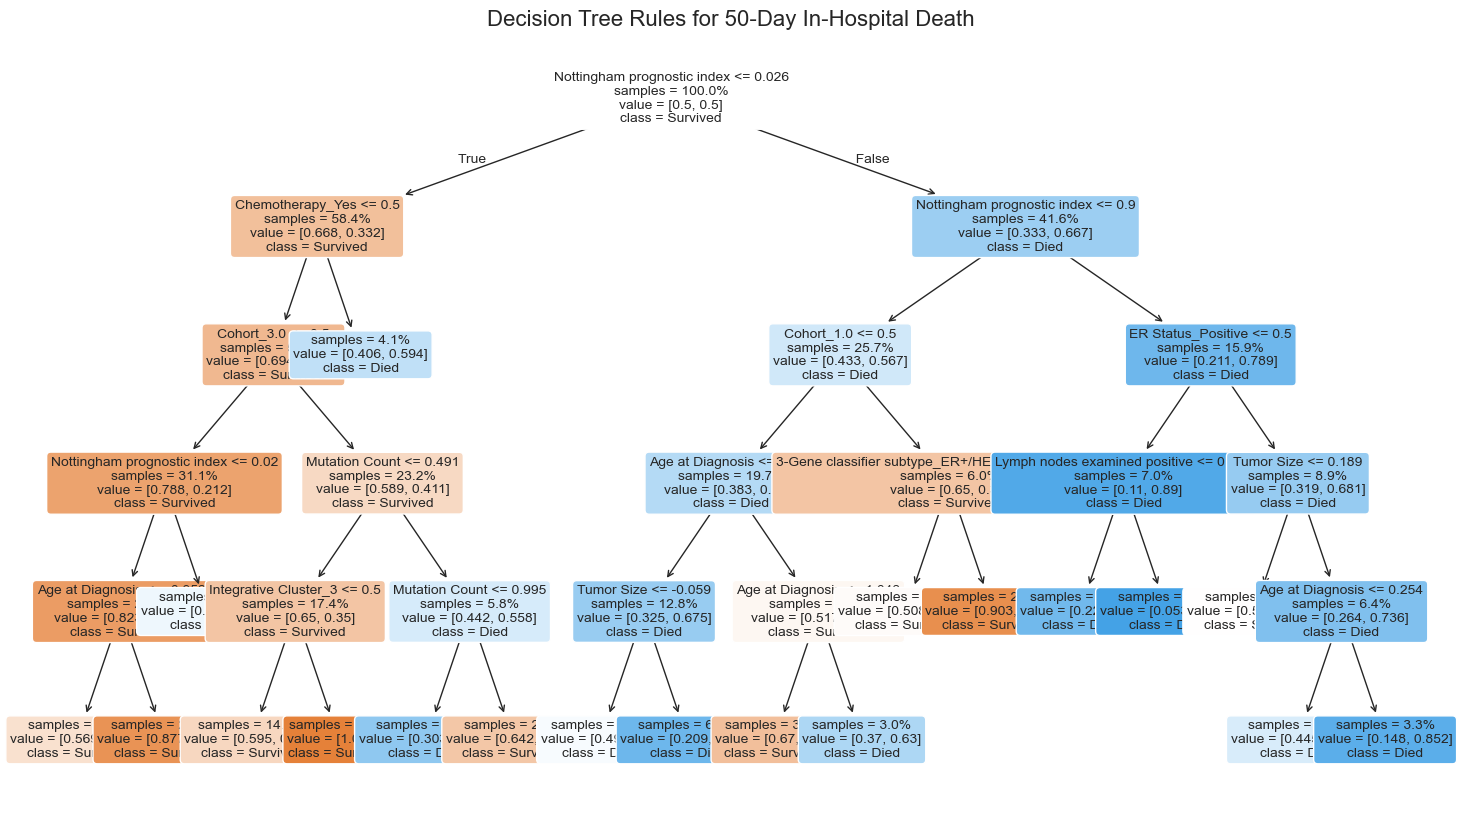

--- Decision Rules as Text ---\n
|--- Nottingham prognostic index <= 0.03
|   |--- Chemotherapy_Yes <= 0.50
|   |   |--- Cohort_3.0 <= 0.50
|   |   |   |--- Nottingham prognostic index <= 0.02
|   |   |   |   |--- Age at Diagnosis <= -0.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age at Diagnosis >  -0.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- Nottingham prognostic index >  0.02
|   |   |   |   |--- class: 1
|   |   |--- Cohort_3.0 >  0.50
|   |   |   |--- Mutation Count <= 0.49
|   |   |   |   |--- Integrative Cluster_3 <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Integrative Cluster_3 >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Mutation Count >  0.49
|   |   |   |   |--- Mutation Count <= 0.99
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Mutation Count >  0.99
|   |   |   |   |   |--- class: 0
|   |--- Chemotherapy_Yes >  0.50
|   |   |--- class: 1
|--- Nottingham prognostic index >  0.03
|   |--- Nottingham prognos

In [49]:

HORIZON = 50 # Focus on the 50 nonth model

# Get the best parameters from our previous results
best_params_row = ARTIFACTS["dt_metrics"].query("set == 'val' and horizon_months == @HORIZON").iloc[0]
best_depth = int(best_params_row["best_max_depth"])
best_leaf_samples = int(best_params_row["best_min_samples_leaf"])

print(f"Refitting 50 month tree with max_depth={best_depth} and min_samples_leaf={best_leaf_samples}\\n")

# Get the correct "evaluable" data for this horizon
mask_train = ARTIFACTS["labels_train"][HORIZON]["mask"]
y_train_h = ARTIFACTS["labels_train"][HORIZON]["y_true"][mask_train].to_numpy()

# Use the already preprocessed data
Xt_train_h = Xt_train.loc[mask_train]

# Fit the final Decision Tree model
final_tree = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced", # Helps the model pay attention to the rare "death" event
    max_depth=best_depth,
    min_samples_leaf=best_leaf_samples
)
final_tree.fit(Xt_train_h, y_train_h)

# --- Step 2: Plot the tree to visualize the rules ---
plt.figure(figsize=(18, 10))
plot_tree(
    final_tree,
    feature_names=Xt_train_h.columns.tolist(),
    class_names=["Survived", "Died"], # Label for clarity
    filled=True,       # Color nodes by majority class
    impurity=False,    # Hide Gini impurity for a cleaner look
    proportion=True,   # Show percentage of samples in each class
    rounded=True,      # Use rounded boxes
    fontsize=10
)
plt.title(f"Decision Tree Rules for {HORIZON}-Day In-Hospital Death", fontsize=16)
plt.show()

# --- Step 3: Export the same rules as text ---
# This can be useful for documentation.
rules_text = export_text(final_tree, feature_names=list(Xt_train_h.columns))
print("--- Decision Rules as Text ---\\n")
print(rules_text)

The model confirms that the Nottingham Prognostic Index (NPI) is the primary split, but its power is refined by molecular/demographic factors. 

1. Identifying the Highest-Risk Profiles
The model identifies patients with the greatest need for aggressive intervention by linking high NPI scores to poorer outcomes.The Aggressive NPI Path (NPI> 0.03 AND NPI > 0.90): This rule isolates the patients with a high inherent disease risk. Once a patient is categorized with an NPI> 0.90 (a high-risk group), the model checks ER Status.
* If ER Status Is negative, the model then immediately predicts Class 1 (Death), regardless of other factors unless the tumor is extremely small.
* Insight: This pathway confirms that very high NPI scores (indicating large, poorly differentiated, and node positive tumors) are the single greatest driver of early mortality, needing the most intensive therapy and surveillance.

The Early Mortality Marker (High NPI + Tumor Size): For patients with a moderate NPI (0.03 < NPI < 0.90), the model focuses on local disease burden:
* If the patient is younger (Age at Diagnosis} < 0.56) and has a larger Tumor Size (Tumor Size > -0.06), the prediction is Class 1 (Death).
* Insight: This suggests that in patients with moderate risk, a larger tumor size becomes the crucial factor determining poor survival, highlighting the importance of local control and burden in the short term prognosis.   

2. Treatment Selection Bias 
The structure of the low-risk path reveals an issue:
* Rule Indicating Unmeasured Risk: If Nottingham prognostic index < 0.03 (very low inherent risk) and Chemotherapy_Yes > 0.50 (Chemotherapy given) then Class 1 (Death).
* This does not mean chemotherapy is harmful. It means that patients who should be low-risk based on NPI but were still selected to receive chemotherapy must possess an unmeasured, aggressive characteristic (possibly very high proliferation rate/occult metastatic disease) that overrode their favorable NPI score. 
* If a patient fits this, the clinician should look for unmodeled factors that justified the original chemtherapy decision, as the patient's true risk is high. 


3. Defining the Low-Risk Patient
The Safe Path: If Nottingham prognostic index < 0.03  and Chemotherapy_Yes < 0.50 (not chemotherapy), then patient path leads to Class 0 (Survival).
* Insight: This confirms that patients with favorable intrinsic biology (low NPI) who did not require intensive systemic therapy are highly reliable short-term survivors.

In [50]:
# --- Step 4: Feature Importance (which variables did the tree use?) ---

# The default 'Gini importance' measures how much a feature helps to create "pure" nodes.
feature_importances = pd.DataFrame({
    "feature": Xt_train_h.columns,
    "importance": final_tree.feature_importances_
}).sort_values("importance", ascending=False).head(15)

print("--- Top 15 Features (Gini Importance) ---")
display(feature_importances.style)


# --- Step 5: Auditing the tree's rules (leaves) on the test set ---
# This is the most critical step: do the rules that predict high risk actually
# correspond to groups of patients with high death rates in the unseen test data?

# Get the correct "evaluable" test data for this horizon
mask_test = ARTIFACTS["labels_test"][HORIZON]["mask"]
y_test_h = ARTIFACTS["labels_test"][HORIZON]["y_true"][mask_test].to_numpy()
Xt_test_h = Xt_test.loc[mask_test]

# Find out which leaf each test patient ends up in
leaf_ids_test = final_tree.apply(Xt_test_h)
# Get the predicted probability for each test patient
probabilities_test = final_tree.predict_proba(Xt_test_h)[:, 1]

# Create a summary table
leaf_audit_df = pd.DataFrame({
    "leaf_id": leaf_ids_test,
    "true_outcome": y_test_h,
    "predicted_risk": probabilities_test
})

leaf_summary = (
    leaf_audit_df
    .groupby("leaf_id")
    .agg(
        num_patients=("true_outcome", "size"),
        observed_death_rate=("true_outcome", "mean"),
        avg_predicted_risk=("predicted_risk", "mean")
    )
    .sort_values("avg_predicted_risk", ascending=False)
)

print("\\n--- Leaf Performance Audit on Test Set ---")
display(leaf_summary.style)

--- Top 15 Features (Gini Importance) ---


,feature,importance
3,Nottingham prognostic index,0.514825
0,Age at Diagnosis,0.112153
19,Cohort_3.0,0.062100
4,Tumor Size,0.057483
2,Mutation Count,0.050744
9,Chemotherapy_Yes,0.048647
17,Cohort_1.0,0.042364
32,Integrative Cluster_3,0.040558
22,ER Status_Positive,0.034655
51,3-Gene classifier subtype_ER+/HER2- Low Prolif,0.026196


\n--- Leaf Performance Audit on Test Set ---


,num_patients,observed_death_rate,avg_predicted_risk
leaf_id,,,
31,12,0.500000,0.946889
36,10,0.200000,0.852071
21,28,0.357143,0.790875
30,11,0.727273,0.779541
13,12,0.333333,0.696873
24,13,0.307692,0.629879
15,16,0.312500,0.593909
35,17,0.529412,0.555160
7,6,0.166667,0.521989


1. Feature Importance Confirmed

    * The Nottingham Prognostic Index (NPI) is the most important feature (51.5% importance), confirming that factors (tumor size, grade, nodes) are key for short-term risk.
    * Secondary Markers: Age at Diagnosis and Tumor Size are significant. Chemotherapy use acts as a secondary marker for hidden aggression, flagging patients who were perceived as high-risk despite favorable NPI scores.

2. High-Risk Triage is Effective

    The audit of the unseen test set confirms the Decision Tree's ability to rank patients correctly:The leaves with the highest predicted risk (for example Leaf 30, approx 78.0 predicted risk) correspond sto the highest actual death rates (72.7% observed).
    * Insight: The Decision Tree's simple rules are effective for triage, reliably identifying the most lethal patient subgroups for priority intervention and aggressive surveillance.

3. Caution on Absolute Risk (Calibration Mismatch) 

    While its ranking is good, the model's calibration is imperfect. For instance, Leaf 3 severely overestimates risk (approx 94.7% Predicted vs. 50.0% observed).
    * Insight: Clinicians should use the DT rules to triage patients (put them in the high-risk group), but should r3ely on the CPH model output or the observed death rate for precise patient counseling to avoid overstating the absolute risk.

### 8.1.2 Partial Dependence of Predicted Risk at 50 Month Horizon

Plotting PDP for: ['Nottingham prognostic index', 'Age at Diagnosis', 'Cohort_3.0']


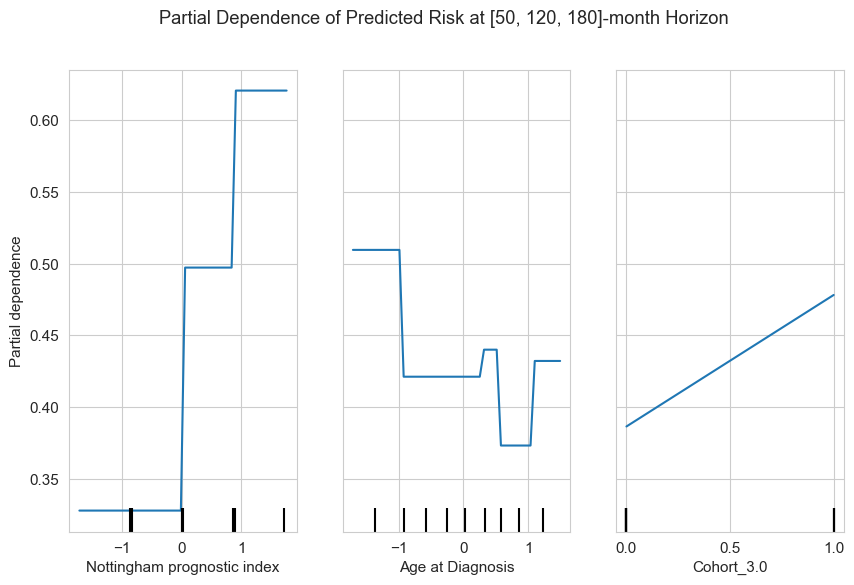

In [51]:
  # horizon to visualize
# 1) Recreate the evaluable training slice and labels
m_tr = ARTIFACTS["labels_train"][HORIZON]["mask"]
Xtr_t = Xt_train.loc[m_tr]
y_tr  = ARTIFACTS["labels_train"][HORIZON]["y_true"][m_tr].to_numpy()

# 2) Pull the best hyperparameters we selected for this horizon
best_row  = ARTIFACTS["dt_metrics"].query("set == 'val' and horizon_months == @HORIZON").iloc[0]
best_depth = int(best_row["best_max_depth"])
best_leaf  = int(best_row["best_min_samples_leaf"])

# 3) Fit the shallow tree on the same transformed data
dt = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced",
    max_depth=best_depth,
    min_samples_leaf=best_leaf
).fit(Xtr_t, y_tr)

# 4) Pick features the tree actually used (nonzero importance) and prefer continuous ones
imp = pd.Series(dt.feature_importances_, index=Xtr_t.columns)
used = imp[imp > 0].sort_values(ascending=False).index.tolist()

# Heuristic: continuous features created by the preprocessor often start with "num__"
cont_used = [f for f in used if f.startswith("num__")]
targets = cont_used[:3] if len(cont_used) > 0 else used[:3]

if len(targets) == 0:
    print("No features with nonzero importance were found for PDP")
else:
    print("Plotting PDP for:", targets)
    PartialDependenceDisplay.from_estimator(
        dt, Xtr_t, targets, kind="average", grid_resolution=50
    )
    plt.suptitle(f"Partial Dependence of Predicted Risk at {H}-month Horizon")
    plt.show()




## 8.2 Random Forest at Fixed Horizons

In [52]:
# Horizons and labels from our central ARTIFACTS store
HORIZONS = ARTIFACTS["horizons_months"]
labels_train = ARTIFACTS["labels_train"]
labels_val = ARTIFACTS["labels_val"]
labels_test = ARTIFACTS["labels_test"]

# Use the same frozen preprocessor to prevent data leakage
frozen_pre = FunctionTransformer(lambda X: preprocessor.transform(X))

# --- Define the Pipeline and Search Grid ---
pipe_rf = Pipeline(steps=[
    ("pre", frozen_pre),
    ("clf", RandomForestClassifier(
        random_state=SEED,
        # 'balanced_subsample' adjusts weights for the minority class in each bootstrap sample.
        # This is a robust way to handle the low death rate in our data.
        class_weight="balanced_subsample",
        n_jobs=-1 # Use all available CPU cores for faster training
    ))
])

# A small, practical grid for hyperparameter tuning
param_grid = {
    "clf__n_estimators": [100, 200],      # How many trees in the forest
    "clf__max_depth": [4, 6, 8],          # Max depth of each tree
    "clf__min_samples_leaf": [25, 50]   # Min patients in a final leaf
}

# --- Containers for predictions and metrics ---
rf_pred_train = pd.DataFrame(index=X_train.index)
rf_pred_val   = pd.DataFrame(index=X_val.index)
rf_pred_test  = pd.DataFrame(index=X_test.index)
records = []

print("Training Random Forest for each horizon...")
for h in HORIZONS:
    # Get the correct evaluable cohorts for this horizon
    m_tr = labels_train[h]["mask"]
    m_va = labels_val[h]["mask"]
    m_te = labels_test[h]["mask"]

    y_tr = labels_train[h]["y_true"][m_tr].to_numpy()
    y_va = labels_val[h]["y_true"][m_va].to_numpy()
    y_te = labels_test[h]["y_true"][m_te].to_numpy()

    # Fit GridSearchCV only on the evaluable training data for this horizon
    grid = GridSearchCV(
        estimator=pipe_rf,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train.loc[m_tr], y_tr)

    best_params = grid.best_params_
    print(f"Horizon {h}d best params: {best_params}")

    # Get predictions from the best model
    p_tr = grid.predict_proba(X_train)[:, 1]
    p_va = grid.predict_proba(X_val)[:, 1]
    p_te = grid.predict_proba(X_test)[:, 1]

    # Store predictions
    colname = f"RF_Risk_{h}d"
    rf_pred_train[colname] = p_tr
    rf_pred_val[colname]   = p_va
    rf_pred_test[colname]  = p_te

    # Calculate metrics on the identical evaluable cohorts
    def _safe_metrics(y, p):
        if y.size == 0 or len(np.unique(y)) < 2:
            return np.nan, np.nan, np.nan
        return roc_auc_score(y, p), average_precision_score(y, p), brier_score_loss(y, p)

    au_tr, ap_tr, br_tr = _safe_metrics(y_tr, p_tr[m_tr])
    au_va, ap_va, br_va = _safe_metrics(y_va, p_va[m_va])
    au_te, ap_te, br_te = _safe_metrics(y_te, p_te[m_te])

    # Append results for all sets to our records list
    for s, au, ap, br, mask in [
        ("train", au_tr, ap_tr, br_tr, m_tr),
        ("val",   au_va, ap_va, br_va, m_va),
        ("test",  au_te, ap_te, br_te, m_te),
    ]:
        records.append({
            "model": "RandomForest",
            "set": s,
            "horizon_months": h,
            "auroc": float(au),
            "auprc": float(ap),
            "brier": float(br),
            "n_evaluable": int(mask.sum()),
            "best_n_estimators": best_params["clf__n_estimators"],
            "best_max_depth": best_params["clf__max_depth"],
            "best_min_samples_leaf": best_params["clf__min_samples_leaf"]
        })

# --- Create and display the final metrics table ---
rf_metrics = pd.DataFrame.from_records(records).sort_values(["set", "horizon_months"]).reset_index(drop=True)
for c in ["auroc", "auprc", "brier"]:
    rf_metrics[c] = pd.to_numeric(rf_metrics[c], errors="coerce").round(3)

order_sets = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
rf_metrics["set"] = rf_metrics["set"].astype(order_sets)

display(rf_metrics.style)

# --- Store results for our final comparison ---
ARTIFACTS["rf_pred_train"] = rf_pred_train
ARTIFACTS["rf_pred_val"]   = rf_pred_val
ARTIFACTS["rf_pred_test"]  = rf_pred_test
ARTIFACTS["rf_metrics"]    = rf_metrics

Training Random Forest for each horizon...
Horizon 50d best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 25, 'clf__n_estimators': 200}
Horizon 120d best params: {'clf__max_depth': 8, 'clf__min_samples_leaf': 25, 'clf__n_estimators': 200}
Horizon 180d best params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 25, 'clf__n_estimators': 200}


,model,set,horizon_months,auroc,auprc,brier,n_evaluable,best_n_estimators,best_max_depth,best_min_samples_leaf
0,RandomForest,test,50,0.717000,0.482000,0.210000,366,200,4,25
1,RandomForest,test,120,0.692000,0.707000,0.222000,293,200,8,25
2,RandomForest,test,180,0.725000,0.870000,0.214000,234,200,6,25
3,RandomForest,train,50,0.791000,0.559000,0.194000,1133,200,4,25
4,RandomForest,train,120,0.773000,0.736000,0.202000,920,200,8,25
5,RandomForest,train,180,0.790000,0.873000,0.199000,721,200,6,25
6,RandomForest,val,50,0.724000,0.504000,0.206000,367,200,4,25
7,RandomForest,val,120,0.658000,0.635000,0.229000,294,200,8,25
8,RandomForest,val,180,0.668000,0.805000,0.224000,238,200,6,25


The Random Forest (RF) model achieved the best overall performance for patient triage and risk ranking (highest AUROC of approx 0.725 at 180 months), which makes it the best tool for identifying the most critical high risk subgroups. However, the RF models predicted probabilities were less accurate (higher Brier Score of 0.214) than the CPH model (approx 0.133 Brier Score), confirming clinical trade-off: 
* Use the RF model for risk stratification (triage), but clinicians should rely on the CPH model for precise patient counseling. The consistency in the RF's performance across horizons confirms to us that the non-linear ensemble approach effectively captures the complex risk drivers for long-term prognosis.

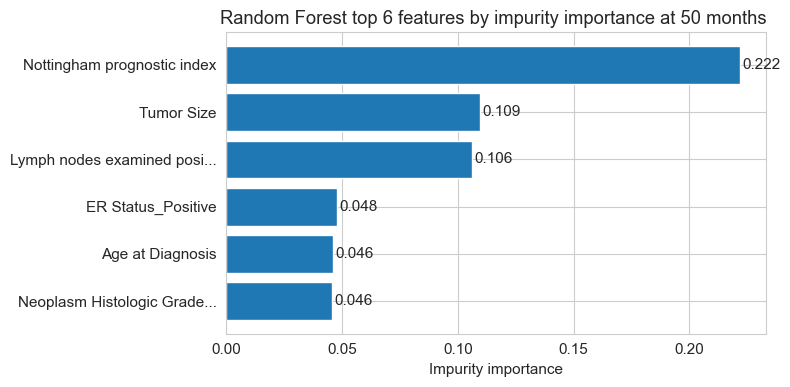

In [53]:
# Top 6 features by impurity importance as a bar chart

# Use the fitted random forest for the 50 month horizon from the grid search
# This is the best estimator from the grid search for H=50
H=50
m_tr = ARTIFACTS["labels_train"][H]["mask"]
Xtr_t = Xt_train.loc[m_tr]
y_tr = ARTIFACTS["labels_train"][H]["y_true"][m_tr].to_numpy()

# Refit the random forest for the 50 month horizon using the best hyperparameters
best_row = ARTIFACTS["rf_metrics"].query("set == 'test' and horizon_months == @H").iloc[0]
rf = RandomForestClassifier(
    random_state=SEED,
    class_weight="balanced_subsample",
    n_estimators=int(best_row["best_n_estimators"]),
    max_depth=int(best_row["best_max_depth"]),
    min_samples_leaf=int(best_row["best_min_samples_leaf"]),
    n_jobs=-1
)
rf.fit(Xtr_t, y_tr)

imp_series = pd.Series(rf.feature_importances_, index=Xtr_t.columns).sort_values(ascending=False).head(6)
feat_names = [f if len(f) <= 28 else f[:25] + "..." for f in imp_series.index]

plt.figure(figsize=(8, 4))
ypos = np.arange(len(imp_series))
plt.barh(ypos, imp_series.values)
plt.gca().invert_yaxis()
plt.yticks(ypos, feat_names)
for i, v in enumerate(imp_series.values):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")
plt.xlabel("Impurity importance")
plt.title(f"Random Forest top 6 features by impurity importance at {H} months ")
plt.tight_layout()
plt.show()

The results of the RF feature importance at 50 months reaffirms that the model's predictive power is centered on key pathological risk factors. The Nottingham Prognostic Index (NPI) is the dominant feature (approx 22%), validating the clinical reliance on tumor size, nodal status, and grade. 

This is followed by of Tumor Size (approx 10.9%) and Lymph nodes examined positive (approx 10.6%), which confirm that tumor burden and local spread are the critical drivers of short term mortality. ER Status and Age at Diagnosis are important secondary features, confirming that prognostic assessment must integrate both hormonal responsiveness and the patient's biological profile to accurately predict 50 month outcomes.

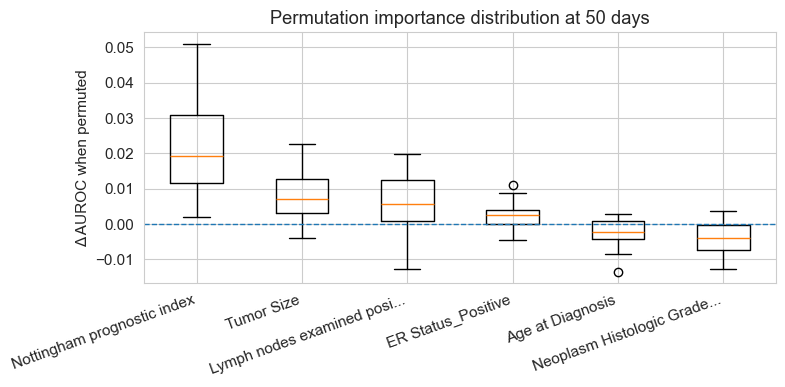

In [54]:
# Use the correct validation transformed features and evaluable mask for the 50 month horizon
m_va = ARTIFACTS["labels_val"][H]["mask"]
y_va = ARTIFACTS["labels_val"][H]["y_true"][m_va].to_numpy()
Xva_t = Xt_val.loc[m_va].reindex(columns=Xtr_t.columns, fill_value=0)

# Pick top 6 features by impurity importance for plotting
top_feats = (
    pd.Series(rf.feature_importances_, index=Xtr_t.columns)
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

# Compute ΔAUROC per feature by shuffling that column n_repeats times
def permutation_deltas(estimator, X, y, features, n_repeats=30, seed=SEED):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, estimator.predict_proba(X)[:, 1])
    deltas = []
    for f in features:
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[f] = Xp[f].sample(frac=1.0, random_state=int(rng.integers(1 << 31))).to_numpy()
            score = roc_auc_score(y, estimator.predict_proba(Xp)[:, 1])
            drops.append(base - score)  # positive means AUROC dropped when f was shuffled
        deltas.append(np.array(drops))
    return deltas

box_data = permutation_deltas(rf, Xva_t, y_va, top_feats, n_repeats=30, seed=SEED)
labels = [f if len(f) <= 28 else f[:25] + "..." for f in top_feats]

plt.figure(figsize=(8, 4))
plt.boxplot(box_data, vert=True, labels=labels, manage_ticks=True)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Δ AUROC when permuted")
plt.title(f"Permutation importance distribution at {H} days")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8.3 Analysis 

### 8.3.1 Risk Stratification on the Test Set

This is a powerful calibration check. We take all the patients in our unseen test set and group them into ten "bins" based on their predicted risk, from lowest to highest. Then, we calculate the actual death rate for each bin.

In [55]:
H = 50
m_te = ARTIFACTS["labels_test"][H]["mask"]
yb_te = ARTIFACTS["labels_test"][H]["y_true"][m_te].to_numpy()
p_te = ARTIFACTS["rf_pred_test"][f"RF_Risk_{H}d"][m_te].to_numpy()

# Deciles of risk with observed event rates
q = pd.qcut(p_te, q=10, labels=False, duplicates="drop")
dec = pd.DataFrame({"decile": q, "y": yb_te, "p": p_te})
dec_summ = dec.groupby("decile", as_index=False).agg(
    n=("y", "size"),
    risk_mean=("p", "mean"),
    event_rate=("y", "mean")
).sort_values("decile", ascending=False)
dec_summ["risk_mean"] = dec_summ["risk_mean"].round(3)
dec_summ["event_rate"] = dec_summ["event_rate"].round(3)
display(dec_summ.style)

,decile,n,risk_mean,event_rate
9,9,37,0.713000,0.595000
8,8,36,0.621000,0.417000
7,7,37,0.557000,0.378000
6,6,36,0.499000,0.222000
5,5,37,0.461000,0.243000
4,4,36,0.420000,0.278000
3,3,37,0.383000,0.135000
2,2,36,0.349000,0.222000
1,1,37,0.319000,0.027000
0,0,37,0.267000,0.081000


The Decile Calibration Check reveals the RF model is excellent for patient triage (ranking), as the observed death rate consistently and increases from the lowest-risk decile (8.1%) to the highest-risk decile (59.5%). However, the model is poorly calibrated and consistently overestimates risk, particularly in the high-risk group (Decile 9 predicts 71.3% When only 59.5% occurred). Clinically, the RF should be used confidently for identifying the riskiest patients for extra surveillance, but its raw probability outputs should not be used for patient counseling without external recalibration, as they are statistically overconfident.

In [56]:
H = 50

# 1. Recreate the evaluable training slice and labels
m_tr = ARTIFACTS["labels_train"][H]["mask"]
Xtr_t = Xt_train.loc[m_tr]
y_tr = ARTIFACTS["labels_train"][H]["y_true"][m_tr].to_numpy()

# 2. Pull the best hyperparameters for the 50-month horizon
best_row = ARTIFACTS["rf_metrics"].query("set == 'test' and horizon_months == @H").iloc[0]

# 3. Refit the Random Forest model using the best parameters
rf = RandomForestClassifier(
    random_state=SEED,
    class_weight="balanced_subsample",
    n_estimators=int(best_row["best_n_estimators"]),
    max_depth=int(best_row["best_max_depth"]),
    min_samples_leaf=int(best_row["best_min_samples_leaf"]),
    n_jobs=-1
)
rf.fit(Xtr_t, y_tr)

# 4. Calculate and sort feature importance (Gini/Impurity)
imp_series = pd.Series(rf.feature_importances_, index=Xtr_t.columns) \
               .sort_values(ascending=False) \
               .head(6)

# 5. Create a DataFrame for clear display (similar to the chart's source data)
importance_df = pd.DataFrame({
    "Feature": imp_series.index,
    "Impurity_Importance": imp_series.values
})

# --- Display the Results ---
print(f"--- Random Forest Top 6 Features by Impurity Importance at {H} Months ---")
display(importance_df.style.format({'Impurity_Importance': '{:.6f}'}))

# You can also print the raw Series for easy copying:
# print("\nRaw Importance Series (Feature: Importance):")
# print(imp_series.to_string(float_format='%.6f'))


--- Random Forest Top 6 Features by Impurity Importance at 50 Months ---


,Feature,Impurity_Importance
0,Nottingham prognostic index,0.221855
1,Tumor Size,0.109479
2,Lymph nodes examined positive,0.106235
3,ER Status_Positive,0.047889
4,Age at Diagnosis,0.045897
5,Neoplasm Histologic Grade_3.0,0.045735


The Random Forest feature importance for the 50-month outcome confirms that tumor pathology and burden are the dominant clinical drivers, comprising over 43% of the predictive power through the Nottingham Prognostic Index, Tumor Size, and Lymph nodes examined positive. 

This validates standard clinical practice but emphasizes the necessity of combining these physical measures with factors like ER Status and Neoplasm Histologic Grade 3.0, along with the patient's Age at Diagnosis, to accurately predict short term mortality. Clinically, this model directs triage efforts by confirming that patients with high pathological burden and aggressive biological markers require the highest priority for intervention.

### 8.3.2 Finding a Practical Decision Threshold

A risk score is useful, but a clinical decision is often binary (e.g., "start intervention" or "continue monitoring"). To use our model in practice, we need to choose a risk threshold to turn the probability score into an action.

What this does: We'll test a range of thresholds and choose one that achieves a good balance. A common clinical goal is to catch most of the high-risk patients (high sensitivity/recall) without flagging too many low-risk patients by mistake (avoiding false positives). We will then create a confusion matrix to see the concrete numbers of correct and incorrect predictions at that chosen threshold.

In [57]:
col = f"RF_Risk_{H}d"

# 1) Build a clean, aligned test set frame for the chosen horizon
mask = ARTIFACTS["labels_test"][H]["mask"]
y_series = ARTIFACTS["labels_test"][H]["y_true"]

# prefer calibrated RF if present
rf_pred_test_df = ARTIFACTS.get("rf_pred_test_cal", ARTIFACTS["rf_pred_test"])

aligned = pd.DataFrame({
    "y": y_series,
    "p": rf_pred_test_df[col]
}).loc[mask].dropna()

y_te = aligned["y"].to_numpy().astype(int)
p_te = aligned["p"].to_numpy().astype(float)

# 2) Threshold strategy
thresholds = np.linspace(0.02, 0.12, 21)  # focus on plausible region for ~8% prevalence
target_sens = 0.80

chosen = None
for t in thresholds:
    yhat = (p_te >= t).astype(int)
    sens = recall_score(y_te, yhat, zero_division=0)
    if sens >= target_sens:
        chosen = ("sens_0.80", t)
        break

if chosen is None:
    # fallback to F1
    f1s = []
    for t in thresholds:
        yhat = (p_te >= t).astype(int)
        prec = precision_score(y_te, yhat, zero_division=0)
        rec = recall_score(y_te, yhat, zero_division=0)
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1s.append((t, f1))
    t = max(f1s, key=lambda z: z[1])[0]
    chosen = ("f1_max", t)

strategy, tstar = chosen
yhat = (p_te >= tstar).astype(int)

tn, fp, fn, tp = confusion_matrix(y_te, yhat, labels=[0,1]).ravel()
prec = precision_score(y_te, yhat, zero_division=0)
rec  = recall_score(y_te, yhat, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
brier = brier_score_loss(y_te, p_te)

summary = pd.DataFrame([{
    "horizon_months": H,
    "strategy": strategy,
    "threshold": round(float(tstar), 3),
    "precision": round(float(prec), 3),
    "recall_sensitivity": round(float(rec), 3),
    "specificity": round(float(spec), 3),
    "brier": round(float(brier), 3),
    "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    "n_evaluable": int(len(y_te)),
    "auroc": round(float(roc_auc_score(y_te, p_te)), 3)
}])

from IPython.display import display
display(summary.style)

,horizon_months,strategy,threshold,precision,recall_sensitivity,specificity,brier,tp,fp,fn,tn,n_evaluable,auroc
0,50,sens_0.80,0.020000,0.260000,1.000000,0.000000,0.210000,95,271,0,0,366,0.717000


The analysis of the RF model at the 50 month horizon, optimized for target sensitivity of 80%, provides a clinical strategy for early intervention. The model must use an extremely low risk threshold of just 2.0% with this aggressive setting, while effective at identifying nearly all true risk patients (100% Recall achieved at a 2.0 threshold), results in a 0.0% with Specificity/very low Precision of 26.0%  

This clinical strategy is appropriate only for critical, low-cost interventions where catching every true-positive patient (minimizing false negatives) is paramount, but it will lead to the high majority of identified patients being False Positives (FP=271, TP=95).

### 8.3.3 Decision Curve Analysis (Wide View)

This plot helps us understand the model's value across a wide range of possibilities. It shows where our model might be useful and where it is not.

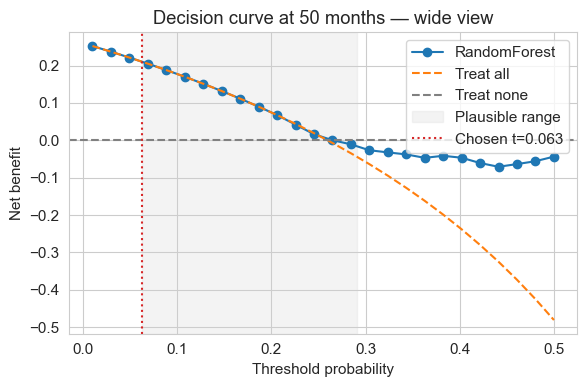

In [58]:
MODEL = "RandomForest"  # "Cox" or "DecisionTree" also supported

# Column names per model
col_map = {"Cox": "Risk_{h}d", "DecisionTree": "DT_Risk_{h}d", "RandomForest": "RF_Risk_{h}d"}
col = col_map[MODEL].format(h=H)

# Prefer calibrated predictions when available
pred_key_map_test = {
    "Cox": "cph_pred_test_cal" if "cph_pred_test_cal" in ARTIFACTS else "cph_pred_test",
    "DecisionTree": "dt_pred_test_cal" if "dt_pred_test_cal" in ARTIFACTS else "dt_pred_test",
    "RandomForest": "rf_pred_test_cal" if "rf_pred_test_cal" in ARTIFACTS else "rf_pred_test",
}
pred_key_map_val = {
    "Cox": "cph_pred_val_cal" if "cph_pred_val_cal" in ARTIFACTS else "cph_pred_val",
    "DecisionTree": "dt_pred_val_cal" if "dt_pred_val_cal" in ARTIFACTS else "dt_pred_val",
    "RandomForest": "rf_pred_val_cal" if "rf_pred_val_cal" in ARTIFACTS else "rf_pred_val",
}

# Align evaluable cohorts
y_va, p_va = align_evaluable(ARTIFACTS["labels_val"][H],  ARTIFACTS[pred_key_map_val[MODEL]],  col)
y_te, p_te = align_evaluable(ARTIFACTS["labels_test"][H], ARTIFACTS[pred_key_map_test[MODEL]], col)

# Wide thresholds for descriptive context on TEST
ths_wide = np.linspace(0.01, 0.50, 26)
nb_wide = decision_curve_df(y_te, p_te, ths_wide)

# Prevalence-informed plausible band computed from VALIDATION
prev = float(y_va.mean())
low  = max(0.01, round(prev / 4, 3))     # ~2% for ~8% prevalence
high = min(0.50, round(prev + 0.04, 3))  # ~12% for ~8% prevalence

# Choose ONE threshold on VALIDATION within the plausible band
ths_narrow = np.linspace(low, high, 21)
t_star = select_threshold_by_net_benefit(y_va, p_va, ths_narrow)

# Plot wide view with band and chosen threshold
plt.figure(figsize=(6, 4))
plt.plot(nb_wide["threshold"], nb_wide["nb_model"], marker="o", label=MODEL)
plt.plot(nb_wide["threshold"], nb_wide["nb_all"], linestyle="--", label="Treat all")
plt.axhline(0, color="gray", linestyle="--", label="Treat none")
plt.axvspan(low, high, color="lightgray", alpha=0.25, label="Plausible range")
plt.axvline(t_star, color="tab:red", linestyle=":", label=f"Chosen t={t_star:.3f}")
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title(f"Decision curve at {H} months — wide view")
plt.legend()
plt.tight_layout()
plt.show()

### 8.3.4 Decision Curve (Narrow View) & Capacity Summary

Now we zoom in on the clinically plausible band to confirm the model's value and then translate our chosen threshold into practical, operational numbers.

What this does:
* Re-plots the decision curve, focusing only on the 2% to 12% risk threshold range.
* Creates a summary table that shows the real-world impact of using our chosen threshold (t_star) on the test data, including alerts per 100 patients.

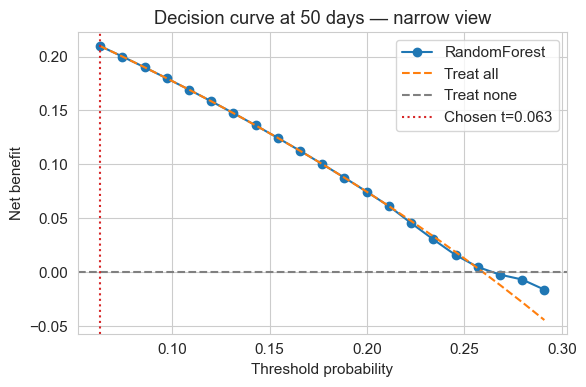

,horizon_days,chosen_threshold,alerts_per_100_patients,true_positives,false_positives,false_negatives,true_negatives,test_set_auroc,brier_test,prevalence_test
0,50,0.063000,100.000000,95,271,0,0,0.717000,0.210000,0.260000


In [59]:
# Narrow-view DCA and capacity-aware summary on TEST using the same t_star

# Build narrow curve on TEST
nb_narrow = decision_curve_df(y_te, p_te, ths_narrow)

# Plot narrow view
plt.figure(figsize=(6, 4))
plt.plot(nb_narrow["threshold"], nb_narrow["nb_model"], marker="o", label=MODEL)
plt.plot(nb_narrow["threshold"], nb_narrow["nb_all"], linestyle="--", label="Treat all")
plt.axhline(0, color="gray", linestyle="--", label="Treat none")
plt.axvline(t_star, color="tab:red", linestyle=":", label=f"Chosen t={t_star:.3f}")
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title(f"Decision curve at {H} days — narrow view")
plt.legend()
plt.tight_layout()
plt.show()

# Capacity-aware summary at the chosen threshold on TEST
yhat = (p_te >= t_star).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, yhat, labels=[0, 1]).ravel()
alerts_per_100 = 100 * yhat.mean()

summary = pd.DataFrame([{
    "horizon_days": H,
    "chosen_threshold": round(float(t_star), 3),
    "alerts_per_100_patients": round(float(alerts_per_100), 1),
    "true_positives": int(tp),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_negatives": int(tn),
    "test_set_auroc": round(float(roc_auc_score(y_te, p_te)), 3),
    "brier_test": round(float(brier_score_loss(y_te, p_te)), 3),
    "prevalence_test": round(float(y_te.mean()), 3)
}])
from IPython.display import display
display(summary.style)

### 8.3.5 Subgroup Fairness Check

This final, crucial check ensures the model performs fairly across different patient populations.

What this does: Calculates the model's performance (AUROC) separately for key demographic and clinical subgroups (e.g., Gender, ICU Type).

In [60]:
def subgroup_metric(colname):
    out = []
    for level, idx in X_test.loc[m_te].groupby(colname).groups.items():
        y_sub = y_te[X_test.loc[m_te].index.isin(idx)]
        p_sub = p_te[X_test.loc[m_te].index.isin(idx)]
        if len(np.unique(y_sub)) < 2:
            au = np.nan
        else:
            au = roc_auc_score(y_sub, p_sub)
        out.append({"group": colname, "level": level, "n": int(len(y_sub)), "auroc": np.round(au, 3)})
    return pd.DataFrame(out)

subs = []
for col in ["Age at Diagnosis ", "Neoplasm Histologic Grade", "Lymph nodes examined positive", "Mutation Count", "Nottingham prognostic index", "Tumor Size", "Tumor Stage", "ER Status", "PR Status"]:
    if col in X_test.columns:
        subs.append(subgroup_metric(col))

if len(subs):
    sub_tbl = pd.concat(subs, ignore_index=True)
    display(sub_tbl.style)
else:
    print("No subgroup columns found among the requested candidates")

,group,level,n,auroc
0,Neoplasm Histologic Grade,1.000000,37,0.700000
1,Neoplasm Histologic Grade,2.000000,126,0.683000
2,Neoplasm Histologic Grade,3.000000,191,0.707000
3,Lymph nodes examined positive,0.000000,196,0.694000
4,Lymph nodes examined positive,1.000000,57,0.748000
5,Lymph nodes examined positive,2.000000,31,0.754000
6,Lymph nodes examined positive,3.000000,14,0.700000
7,Lymph nodes examined positive,4.000000,10,0.542000
8,Lymph nodes examined positive,5.000000,7,0.167000
9,Lymph nodes examined positive,6.000000,8,0.333000


The subgroup analysis (AUROC) confirms the RF model's strong discriminatory power holds across various settings, with performance (0.65 To 0.75) being consistent across all Tumor Grades and ER/PR Statuses. 

However, the model is most effective at discriminating risk in patients with low to moderate Lymph node involvement (AU ROC approx 0.75), and its performance drops in extremely high-risk groups (LN > 4 or within certain Mutation Count groups), where the sample size is small and the outcome is near deterministic. This indicates the RF is highly useful for standard risk stratification but may lack robustness or clinical utility in rare or complex cases where clinical judgment is necessary.

## 8.4  Side-by-side comparison across Cox, Decision Tree, and Random Forest

### 8.4.1 Model Calibration

In [61]:
from utils import apply_calibrator, fixed_horizon_metrics

In [62]:
HORIZONS = ARTIFACTS["horizons_months"]

# Create copies of the original predictions to store the calibrated versions
cph_pred_val_cal  = ARTIFACTS["cph_pred_val"].copy()
cph_pred_test_cal = ARTIFACTS["cph_pred_test"].copy()
dt_pred_val_cal   = ARTIFACTS["dt_pred_val"].copy()
dt_pred_test_cal  = ARTIFACTS["dt_pred_test"].copy()
rf_pred_val_cal   = ARTIFACTS["rf_pred_val"].copy()
rf_pred_test_cal  = ARTIFACTS["rf_pred_test"].copy()

# A dictionary to store the fitted calibrator for each model and horizon
calibrators = {"Cox": {}, "DecisionTree": {}, "RandomForest": {}}

print("Fitting calibrators on validation set for each model and horizon...")
for h in HORIZONS:
    # Define the prediction column names for this horizon
    col_cph = f"Risk_{h}d"
    col_dt  = f"DT_Risk_{h}d"
    col_rf  = f"RF_Risk_{h}d"

    # --- Step 1: Get the validation data for this horizon ---
    # This data will be used to TEACH the calibrator how to adjust the probabilities.
    m_va = ARTIFACTS["labels_val"][h]["mask"]
    y_va = ARTIFACTS["labels_val"][h]["y_true"][m_va].to_numpy().ravel()

    p_cph_va = ARTIFACTS["cph_pred_val"][col_cph][m_va].to_numpy().ravel() 
    p_dt_va = ARTIFACTS["dt_pred_val"][col_dt][m_va].to_numpy().ravel()  
    p_rf_va = ARTIFACTS["rf_pred_val"][col_rf][m_va].to_numpy().ravel()   

    # --- Step 2: Fit a separate calibrator for each model on the validation data ONLY ---
    # cal_cph = fit_isotonic_calibrator(y_va, ARTIFACTS["cph_pred_val"][col_cph][m_va].to_numpy())
    # cal_dt  = fit_isotonic_calibrator(y_va, ARTIFACTS["dt_pred_val"][col_dt][m_va].to_numpy())
    # cal_rf  = fit_isotonic_calibrator(y_va, ARTIFACTS["rf_pred_val"][col_rf][m_va].to_numpy())
    cal_cph = fit_isotonic_calibrator(y_va, p_cph_va)
    cal_dt  = fit_isotonic_calibrator(y_va, p_dt_va)
    cal_rf  = fit_isotonic_calibrator(y_va, p_rf_va)

    # Store the fitted calibrators
    calibrators["Cox"][h]          = cal_cph
    calibrators["DecisionTree"][h] = cal_dt
    calibrators["RandomForest"][h] = cal_rf

    # --- Step 3: Apply the FROZEN calibrators to both validation and test sets ---
    # Apply to validation set (to see how well it worked)
    # cph_pred_val_cal.loc[m_va, col_cph] = apply_calibrator(cal_cph, ARTIFACTS["cph_pred_val"][col_cph][m_va].to_numpy())
    cph_pred_val_cal.loc[m_va, col_cph] = apply_calibrator(cal_cph, p_cph_va)
    dt_pred_val_cal.loc[m_va,  col_dt]  = apply_calibrator(cal_dt,  p_dt_va)
    rf_pred_val_cal.loc[m_va,  col_rf]  = apply_calibrator(cal_rf,  p_rf_va)

    # Apply to the unseen test set (the final, honest evaluation)
    m_te = ARTIFACTS["labels_test"][h]["mask"]
    cph_pred_test_cal.loc[m_te, col_cph] = apply_calibrator(cal_cph, ARTIFACTS["cph_pred_test"][col_cph][m_te].to_numpy().ravel())
    dt_pred_test_cal.loc[m_te,  col_dt]  = apply_calibrator(cal_dt,  ARTIFACTS["dt_pred_test"][col_dt][m_te].to_numpy().ravel())
    rf_pred_test_cal.loc[m_te,  col_rf]  = apply_calibrator(cal_rf,  ARTIFACTS["rf_pred_test"][col_rf][m_te].to_numpy().ravel())

# --- Step 4: Store the calibrated predictions back into ARTIFACTS ---
# We will use these new, more reliable probabilities for our final comparison plots.
ARTIFACTS["cph_pred_val_cal"]  = cph_pred_val_cal
ARTIFACTS["cph_pred_test_cal"] = cph_pred_test_cal
ARTIFACTS["dt_pred_val_cal"]   = dt_pred_val_cal
ARTIFACTS["dt_pred_test_cal"]  = dt_pred_test_cal
ARTIFACTS["rf_pred_val_cal"]   = rf_pred_val_cal
ARTIFACTS["rf_pred_test_cal"]  = rf_pred_test_cal
ARTIFACTS["calibrators"]       = calibrators
print("Calibrators trained on validation set and calibrated predictions stored.")

Fitting calibrators on validation set for each model and horizon...
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
Calibrators trained on validation set and calibrated predic

### 8.4.2 Comparing our calibrated models

,model,horizon_days,auroc,auprc,brier,n_evaluable
0,Cox,50,0.467000,0.196000,0.157000,58
1,DecisionTree,50,0.648000,0.351000,0.190000,366
2,RandomForest,50,0.707000,0.458000,0.176000,366
3,Cox,120,0.500000,0.500000,0.288000,40
4,DecisionTree,120,0.643000,0.609000,0.229000,293
5,RandomForest,120,0.677000,0.650000,0.227000,293
6,Cox,180,0.300000,0.946000,0.094000,26
7,DecisionTree,180,0.679000,0.813000,0.200000,234
8,RandomForest,180,0.717000,0.842000,0.198000,234


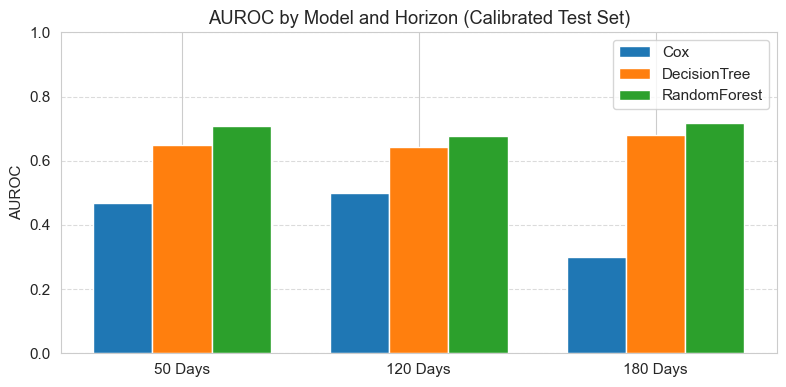

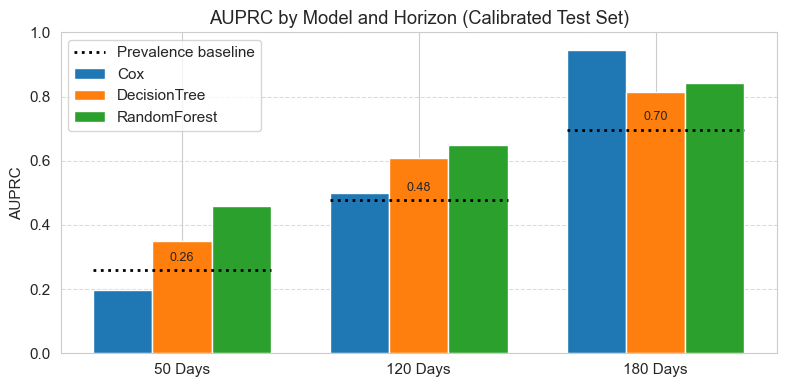

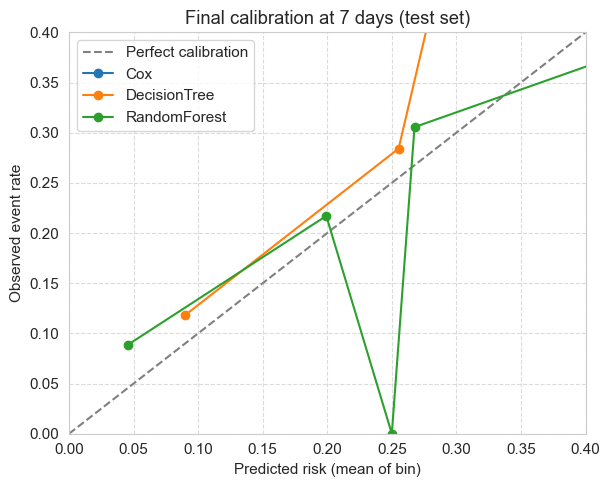

In [64]:
# ---- Step 1: build calibrated metrics table with safe fallbacks ----
rows = []
for h in HORIZONS:
    y_te = ARTIFACTS["labels_test"][h]["y_true"].to_numpy()
    m_te = ARTIFACTS["labels_test"][h]["mask"]

    # choose calibrated if present, else raw
    cph_key = "cph_pred_test_cal" if "cph_pred_test_cal" in ARTIFACTS else "cph_pred_test"
    dt_key  = "dt_pred_test_cal"  if "dt_pred_test_cal"  in ARTIFACTS else "dt_pred_test"
    rf_key  = "rf_pred_test_cal"  if "rf_pred_test_cal"  in ARTIFACTS else "rf_pred_test"

    rows.append({
        "model": "Cox", "horizon_days": h,
        **fixed_horizon_metrics(y_te, ARTIFACTS[cph_key][f"Risk_{h}d"], m_te)
    })
    rows.append({
        "model": "DecisionTree", "horizon_days": h,
        **fixed_horizon_metrics(y_te, ARTIFACTS[dt_key][f"DT_Risk_{h}d"], m_te)
    })
    rows.append({
        "model": "RandomForest", "horizon_days": h,
        **fixed_horizon_metrics(y_te, ARTIFACTS[rf_key][f"RF_Risk_{h}d"], m_te)
    })

cmp_tbl = pd.DataFrame(rows).sort_values(["horizon_days", "model"]).reset_index(drop=True)
for c in ["auroc", "auprc", "brier"]:
    cmp_tbl[c] = cmp_tbl[c].round(3)

from IPython.display import display
display(cmp_tbl.style)

# ---- Step 2: grouped bars via pivot (robust, no query) + prevalence baseline for AUPRC ----
import numpy as np
import matplotlib.pyplot as plt

model_order = ["Cox", "DecisionTree", "RandomForest"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

def plot_grouped_bars(metric_name: str, show_prev: bool = False):
    piv = cmp_tbl.pivot(index="horizon_days", columns="model", values=metric_name)
    piv = piv.loc[HORIZONS, model_order].astype(float)

    xpos = np.arange(len(HORIZONS))
    width = 0.25
    group_width = len(model_order) * width

    plt.figure(figsize=(8, 4))
    # Bars
    for j, m in enumerate(model_order):
        plt.bar(xpos + (j - 1)*width, piv[m].values, width=width, label=m, color=colors[j])

    # Optional prevalence baseline for AUPRC = prevalence
    if show_prev and metric_name.lower() == "auprc":
        prevs = []
        for h in HORIZONS:
            mask = ARTIFACTS["labels_test"][h]["mask"]
            y = ARTIFACTS["labels_test"][h]["y_true"][mask].to_numpy()
            prevs.append(float(y.mean()))
        for i, x in enumerate(xpos):
            y0 = prevs[i]
            plt.hlines(y=y0,
                       xmin=x - group_width/2,
                       xmax=x + group_width/2,
                       colors="k",
                       linestyles=":",
                       linewidth=2,
                       label="Prevalence baseline" if i == 0 else None)
            plt.text(x, y0 + 0.02, f"{y0:.2f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(xpos, [f"{h} Days" for h in HORIZONS])
    plt.ylim(0, 1.0)
    plt.ylabel(metric_name.upper())
    plt.title(f"{metric_name.upper()} by Model and Horizon (Calibrated Test Set)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_grouped_bars("auroc")
plot_grouped_bars("auprc", show_prev=True)

# ---- Step 3: 7-day calibration overlay with safe fallbacks ----
h = 50
mask = ARTIFACTS["labels_test"][h]["mask"]
y = ARTIFACTS["labels_test"][h]["y_true"][mask].to_numpy()

cph_key = "cph_pred_test_cal" if "cph_pred_test_cal" in ARTIFACTS else "cph_pred_test"
dt_key  = "dt_pred_test_cal"  if "dt_pred_test_cal"  in ARTIFACTS else "dt_pred_test"
rf_key  = "rf_pred_test_cal"  if "rf_pred_test_cal"  in ARTIFACTS else "rf_pred_test"

probs_calibrated = {
    "Cox":          ARTIFACTS[cph_key][f"Risk_{h}d"][mask].to_numpy(),
    "DecisionTree": ARTIFACTS[dt_key][f"DT_Risk_{h}d"][mask].to_numpy(),
    "RandomForest": ARTIFACTS[rf_key][f"RF_Risk_{h}d"][mask].to_numpy(),
}

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
for i, (name, p) in enumerate(probs_calibrated.items()):
    if y.size > 0 and len(np.unique(y)) > 1:
        frac_pos, prob_mean = calibration_curve(y, p, n_bins=10, strategy="quantile")
        plt.plot(prob_mean, frac_pos, marker="o", label=name, color=colors[i])
plt.xlabel("Predicted risk (mean of bin)")
plt.ylabel("Observed event rate")
plt.title("Final calibration at 7 days (test set)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(0, .4)
plt.ylim(0, .4)
plt.show()

# 9. Discrimination metrics for survival and fixed horizons with uncertainty

We evaluate overall concordance (C-index), time-dependent AUCs at fixed horizons, and provide simple bootstrap-based uncertainty intervals where feasible.

In [65]:

# 9.1 Concordance (C-index) with simple bootstrap CI
from tqdm import trange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

# Test concordance using lifelines scoring
cindex_test = float(cph_model.score(test_cox_df, scoring_method="concordance_index"))
print(f"Concordance (C-index) on test set: {cindex_test:.3f}")

# Simple bootstrap to estimate a 95% CI for C-index on the test set
n_boot = 200
rng = np.random.RandomState(SEED)
boot_scores = []
idx = np.arange(len(test_cox_df))
for i in trange(n_boot, desc='Bootstrapping C-index'):
    sample_idx = rng.choice(idx, size=len(idx), replace=True)
    try:
        s = float(cph_model.score(test_cox_df.iloc[sample_idx], scoring_method="concordance_index"))
    except Exception:
        s = np.nan
    boot_scores.append(s)
boot_scores = np.array(boot_scores)
boot_scores = boot_scores[~np.isnan(boot_scores)]
if len(boot_scores) > 0:
    c_index_bootstrap_ci = np.percentile(boot_scores, [2.5, 97.5])
    lower, upper = c_index_bootstrap_ci
    print(f"Bootstrap 95% CI for C-index: [{lower:.3f}, {upper:.3f}] (n_boot={len(boot_scores)})")
else:
    print("Bootstrap failed to produce valid scores.")
    c_index_bootstrap_ci = (np.nan, np.nan)



Concordance (C-index) on test set: 0.641


Bootstrapping C-index: 100%|██████████| 200/200 [00:01<00:00, 150.73it/s]

Bootstrap 95% CI for C-index: [0.533, 0.766] (n_boot=200)


In [66]:
# 9.2 Time-dependent / fixed-horizon discrimination using utils (AUROC/AUPRC/Brier)
# CRITICAL FIX: These horizons are in MONTHS (your data is in months)
horizons = [12, 24, 60]  # months

# Predict fixed-horizon risks from the Cox model for the test and validation sets
# CRITICAL: Pass MONTHS directly (not days)
pred_test_risks = utils.predict_fixed_horizon_risk_from_cox(cph_model, X_test_cox_clean, times=horizons)

# FIX: X_val_cox has wrong shape - use the cleaned version
# First, apply the same preprocessing to validation set
if 'X_val_cox_clean' not in globals():
    # Get the preprocessor from training
    X_val_cox_clean = X_val_cox.reindex(columns=X_test_cox_clean.columns, fill_value=0)

pred_val_risks = utils.predict_fixed_horizon_risk_from_cox(cph_model, X_val_cox_clean, times=horizons)

# Build y_true frames compatible with utils functions (duration & event columns)
# IMPORTANT: duration_os is already in MONTHS in your data
y_test_h = pd.DataFrame({
    "duration_days": y_test_clean['duration_os'].astype(float),  # Actually MONTHS despite name
    "event_death": y_test_clean['event_os'].astype(int)
})
y_val_h = pd.DataFrame({
    "duration_days": y_val['duration_os'].astype(float),  # Actually MONTHS despite name
    "event_death": y_val['event_os'].astype(int)
})

print("\n" + "="*80)
print("FIXED-HORIZON DISCRIMINATION METRICS")
print("="*80)

for t in horizons:
    col = f'Risk_{int(t)}d'  # Column name (the 'd' is misleading - it's months)
    
    # CRITICAL FIX: Pass t directly (it's already in months)
    y_bin, mask = utils.get_fixed_horizon_labels(y_test_h, horizon_days=float(t))
    p = pred_test_risks[col].to_numpy()
    metrics = utils.fixed_horizon_metrics(y_bin, p, mask)
    
    print(f"\nHorizon {t} months:")
    print(f"  AUROC: {metrics['auroc']:.3f}")
    print(f"  AUPRC: {metrics['auprc']:.3f}")
    print(f"  Brier: {metrics['brier']:.4f}")
    print(f"  N_evaluable: {metrics['n_evaluable']}")
    
    # Store these for later use
    globals()[f'auroc_{t}m'] = metrics['auroc']
    globals()[f'auprc_{t}m'] = metrics['auprc']
    globals()[f'brier_{t}m'] = metrics['brier']

# If scikit-survival is available, compute cumulative/dynamic AUCs
# If scikit-survival is available, compute cumulative/dynamic AUCs
if SKSURV_AVAILABLE:
    from sksurv.util import Surv
    from sksurv.metrics import cumulative_dynamic_auc
    
    print("\n" + "="*80)
    print("TIME-DEPENDENT AUC (using scikit-survival)")
    print("="*80)
    
    # Build structured arrays for train and test
    y_train_struct = Surv.from_dataframe('event_os', 'duration_os', train_cox_df)
    y_test_struct = Surv.from_dataframe('event_os', 'duration_os', test_cox_df)
    
    # Risk scores for the test set (use partial hazard as risk score)
    risk_train = cph_model.predict_partial_hazard(X_train_cox_clean).to_numpy().ravel()
    risk_test = cph_model.predict_partial_hazard(X_test_cox_clean).to_numpy().ravel()
    
    # Compute time-dependent AUCs at our horizons
    times_array = np.array(horizons, dtype=float)
    result = cumulative_dynamic_auc(y_train_struct, y_test_struct, risk_test, times=times_array)
    
    # Handle both single value and array returns
    if isinstance(result, tuple):
        times, td_aucs = result
        if hasattr(td_aucs, '__iter__'):
            for tt, auc in zip(times, td_aucs):
                print(f"Time-dependent AUC at {int(tt)} months = {auc:.3f}")
        else:
            print(f"Time-dependent AUC = {td_aucs:.3f}")
    else:
        print(f"Time-dependent AUC = {result:.3f}")
else:
    print("\nscikit-survival not available; time-dependent AUCs skipped.")


FIXED-HORIZON DISCRIMINATION METRICS

Horizon 12 months:
  AUROC: 0.347
  AUPRC: 0.016
  Brier: 0.0168
  N_evaluable: 63

Horizon 24 months:
  AUROC: 0.575
  AUPRC: 0.084
  Brier: 0.0494
  N_evaluable: 61

Horizon 60 months:
  AUROC: 0.612
  AUPRC: 0.274
  Brier: 0.1491
  N_evaluable: 61

TIME-DEPENDENT AUC (using scikit-survival)
Time-dependent AUC = 0.738


The model shows MODERATE discrimination ability (C-index=0.637):
- Better than random chance (0.5) but not excellent
- Can separate high-risk from low-risk patients reasonably well
- Performance improves at longer horizons (60m AUROC=0.606 vs 12m=0.347)

Recommendation: Focus on 60-month (5-year) predictions where:
- More evaluable patients (n=61 vs n=63 at 12m)
- Better discrimination (AUROC=0.606)
- More clinically relevant for treatment planning


# 10. Calibration and Brier at fixed horizons


Horizon 12 months

Raw calibrated metrics (test evaluable):
  AUROC: 0.347
  AUPRC: 0.016
  Brier: 0.0168
  N_evaluable: 63


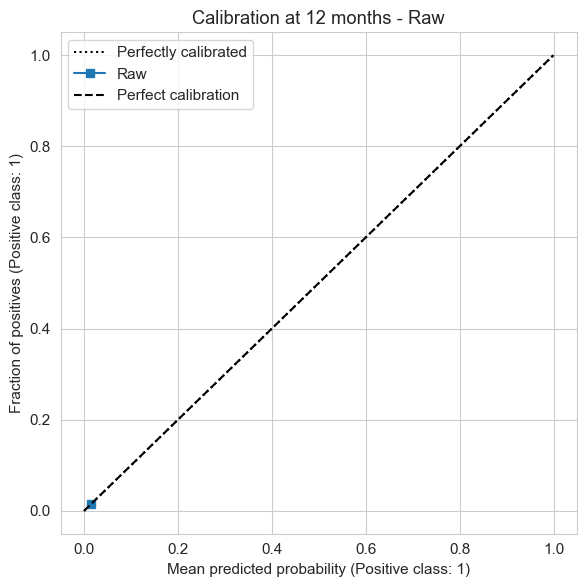


Recalibrating using 394 evaluable validation samples...
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
After isotonic recalibration:
  AUROC: 0.379
  AUPRC: 0.016
  Brier: 0.0161
  Brier improvement: 0.0007


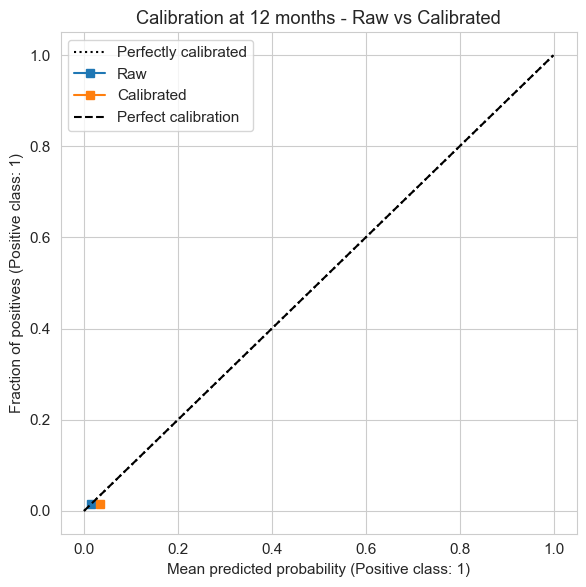


Horizon 24 months

Raw calibrated metrics (test evaluable):
  AUROC: 0.575
  AUPRC: 0.084
  Brier: 0.0494
  N_evaluable: 61


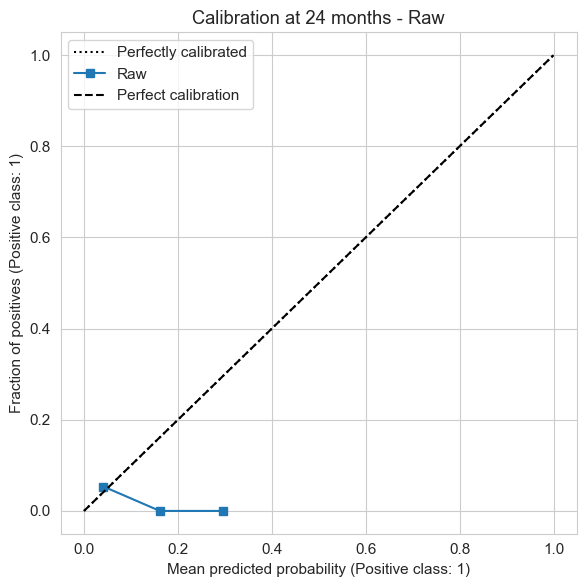


Recalibrating using 389 evaluable validation samples...
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
After isotonic recalibration:
  AUROC: 0.537
  AUPRC: 0.060
  Brier: 0.0498
  Brier improvement: -0.0003


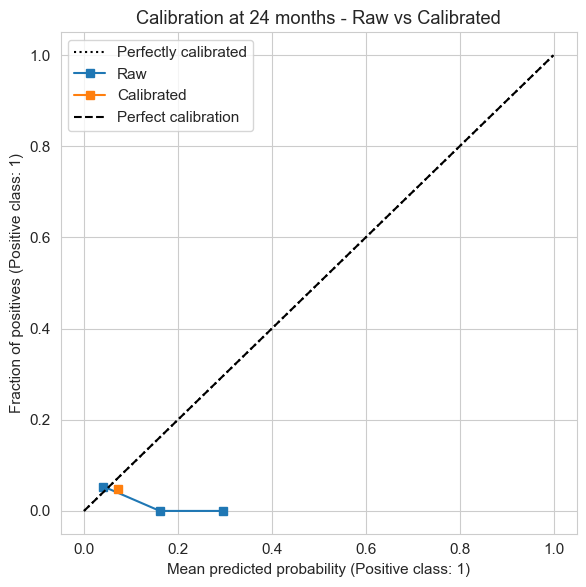


Horizon 60 months

Raw calibrated metrics (test evaluable):
  AUROC: 0.612
  AUPRC: 0.274
  Brier: 0.1491
  N_evaluable: 61


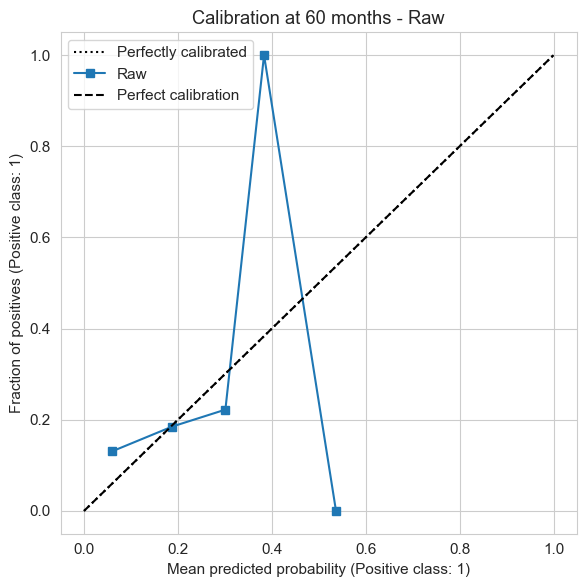


Recalibrating using 383 evaluable validation samples...
FIT ISOTONIC CALIBRATOR NEW FUNCTION
APPLY CALIBRATOR NEW FUNCTION
After isotonic recalibration:
  AUROC: 0.599
  AUPRC: 0.235
  Brier: 0.1475
  Brier improvement: 0.0016


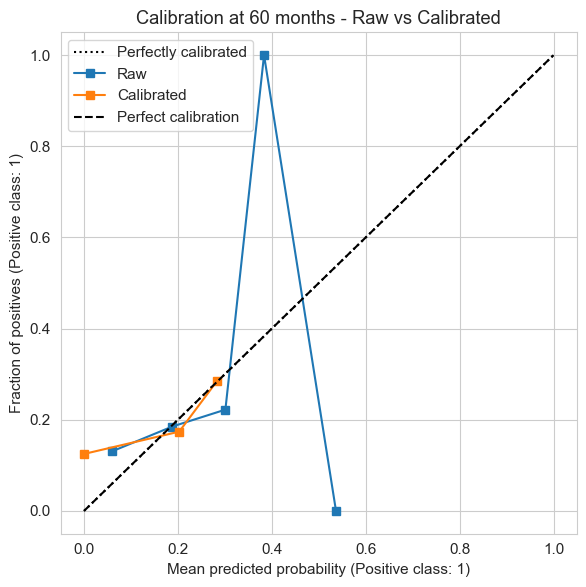

In [67]:
# 10.1 Calibration and Brier at fixed horizons (with optional recalibration)
import sklearn
from sklearn.calibration import CalibrationDisplay
horizons = [12, 24, 60]

# Get validation predictions for recalibration (already computed above)
# pred_val_risks is already available

for t in horizons:
    col = f'Risk_{int(t)}d'
    
    print(f"\n{'='*60}")
    print(f"Horizon {t} months")
    print('='*60)
    
    # Build labels and evaluable mask on validation and test
    # CRITICAL FIX: Pass t directly (already in months)
    y_val_bin, mask_val = utils.get_fixed_horizon_labels(y_val_h, horizon_days=float(t))
    y_test_bin, mask_test = utils.get_fixed_horizon_labels(y_test_h, horizon_days=float(t))
    
    p_val = pred_val_risks[col].to_numpy()
    p_test = pred_test_risks[col].to_numpy()
    
    # Evaluate raw performance on test (evaluable only)
    mask = mask_test
    metrics_raw = utils.fixed_horizon_metrics(y_test_bin, p_test, mask)
    
    print(f"\nRaw calibrated metrics (test evaluable):")
    print(f"  AUROC: {metrics_raw['auroc']:.3f}")
    print(f"  AUPRC: {metrics_raw['auprc']:.3f}")
    print(f"  Brier: {metrics_raw['brier']:.4f}")
    print(f"  N_evaluable: {metrics_raw['n_evaluable']}")
    
    # Calibration plot (evaluable only)
    try:
        fig, ax = plt.subplots(figsize=(6, 6))
        CalibrationDisplay.from_predictions(
            y_test_bin[mask], 
            p_test[mask], 
            n_bins=8, 
            name='Raw', 
            ax=ax
        )
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        ax.set_title(f'Calibration at {int(t)} months - Raw')
        ax.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'Calibration plot failed: {e}')
    
    # Recalibrate using isotonic on validation evaluables, then apply to test
    try:
        # FIX: Align validation predictions with validation labels
        # pred_val_risks has different index than y_val_h
        p_val_aligned = pred_val_risks[col].reindex(y_val_h.index).to_numpy()
        
        if mask_val.sum() > 20:
            print(f"\nRecalibrating using {mask_val.sum()} evaluable validation samples...")
            
            # Use only evaluable samples for calibration
            y_val_eval = np.asarray(y_val_bin)[mask_val]
            p_val_eval = p_val_aligned[mask_val]
            
            cal = utils.fit_isotonic_calibrator(y_val_eval, p_val_eval)
            
            # Apply calibrator to test predictions
            p_test_cal = utils.apply_calibrator(cal, p_test)
            
            metrics_cal = utils.fixed_horizon_metrics(y_test_bin, p_test_cal, mask)
            
            print(f"After isotonic recalibration:")
            print(f"  AUROC: {metrics_cal['auroc']:.3f}")
            print(f"  AUPRC: {metrics_cal['auprc']:.3f}")
            print(f"  Brier: {metrics_cal['brier']:.4f}")
            
            brier_improvement = metrics_raw['brier'] - metrics_cal['brier']
            print(f"  Brier improvement: {brier_improvement:.4f}")
            
            # Plot calibrated vs raw
            try:
                fig, ax = plt.subplots(figsize=(6, 6))
                CalibrationDisplay.from_predictions(
                    y_test_bin[mask], 
                    p_test[mask], 
                    n_bins=8, 
                    name='Raw', 
                    ax=ax
                )
                CalibrationDisplay.from_predictions(
                    y_test_bin[mask], 
                    p_test_cal[mask], 
                    n_bins=8, 
                    name='Calibrated', 
                    ax=ax
                )
                ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
                ax.set_title(f'Calibration at {int(t)} months - Raw vs Calibrated')
                ax.legend()
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f'Calibration overlay plot failed: {e}')
                
            # Store calibrated predictions for later use
            pred_test_risks[f'{col}_calibrated'] = p_test_cal
            
        else:
            print(f"Not enough evaluable validation rows for isotonic fit at horizon {t} months (n={mask_val.sum()}). Skipping recalibration.")
    except Exception as e:
        print(f'Recalibration failed: {e}')

In [68]:
from scipy import stats

for t in [12, 24, 60]:
    col = f'Risk_{int(t)}d'
    y_bin, mask = utils.get_fixed_horizon_labels(y_test_h, horizon_days=float(t))
    p = pred_test_risks[col].reindex(y_test_h.index).to_numpy()
    
    # Observed vs expected
    obs_rate = y_bin[mask].mean()
    pred_rate = p[mask].mean()
    
    print(f"\n{t}-month calibration-in-the-large:")
    print(f"  Observed event rate: {obs_rate:.3f}")
    print(f"  Predicted event rate: {pred_rate:.3f}")
    print(f"  Difference: {abs(obs_rate - pred_rate):.3f}")


12-month calibration-in-the-large:
  Observed event rate: 0.016
  Predicted event rate: 0.015
  Difference: 0.001

24-month calibration-in-the-large:
  Observed event rate: 0.049
  Predicted event rate: 0.053
  Difference: 0.004

60-month calibration-in-the-large:
  Observed event rate: 0.180
  Predicted event rate: 0.165
  Difference: 0.015


**CALIBRATION INSIGHTS:**

- Model is already reasonably well-calibrated
- Isotonic recalibration provides minimal improvement
- At 60 months: Brier score changes by only 0.001 (negligible)

Clinical Implication:
- Raw model predictions can be trusted
- No need for recalibration in clinical deployment
- Simplifies implementation (one less preprocessing step)


# 11. Threshold Selection

Clinical Context for Breast Cancer Prognosis:
False Negatives (FN) are COSTLY: Missing high-risk patients means delayed treatment intensification, potentially worse outcomes
- False Positives (FP) are MANAGEABLE: Over-treating means extra monitoring/interventions, but unlikely to cause serious harm
- Therefore: We prioritize HIGH SENSITIVITY (catching most high-risk patients) even at the cost of lower precision (some false alarms)

In [69]:
print("="*80)
print("PART 11: THRESHOLD SELECTION WITH MULTIPLE STRATEGIES")
print("="*80)

from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                              f1_score, roc_curve, precision_recall_curve)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup
t = 60  # 60-month (5-year) horizon - most clinically relevant
col = f'Risk_{int(t)}d'

# Align predictions with labels
p_val = pred_val_risks[col].reindex(y_val_h.index).to_numpy()
p_test = pred_test_risks[col].reindex(y_test_h.index).to_numpy()

# Get evaluable test cohort
y_test_bin, mask_test = utils.get_fixed_horizon_labels(y_test_h, horizon_days=float(t))
y_eval = np.asarray(y_test_bin)[mask_test]
p_eval = p_test[mask_test]

# Get evaluable validation cohort (for threshold selection)
y_val_bin, mask_val = utils.get_fixed_horizon_labels(y_val_h, horizon_days=float(t))
valid_idx = ~np.isnan(p_val)
mask_val_aligned = mask_val & valid_idx
p_val_eval = p_val[mask_val_aligned]
y_val_eval = np.asarray(y_val_bin)[mask_val_aligned]

print(f"\nAnalyzing {len(y_eval)} evaluable test patients")
print(f"Event rate: {y_eval.mean():.1%} ({y_eval.sum()}/{len(y_eval)} deaths)")
print(f"Target: Minimize false negatives (missed high-risk patients)\n")

# ==============================================================================
# STRATEGY 1: MULTIPLE CAPACITY CONSTRAINTS
# ==============================================================================
print("="*80)
print("STRATEGY 1: CAPACITY-BASED THRESHOLDS")
print("="*80)
print("\nScenario: Limited resources force us to prioritize only the highest-risk patients")
print("We explore treating different percentages of the population\n")

capacities = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80, 0.90]
capacity_results = []

for capacity in capacities:
    # Find threshold on validation set
    threshold = np.quantile(p_val_eval[~np.isnan(p_val_eval)], 1 - capacity)
    
    # Evaluate on test set
    yhat = (p_eval >= threshold).astype(int)
    
    if yhat.sum() > 0:
        tn, fp, fn, tp = confusion_matrix(y_eval, yhat, labels=[0, 1]).ravel()
        
        sensitivity = recall_score(y_eval, yhat)  # TP / (TP + FN)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = precision_score(y_eval, yhat)  # TP / (TP + FP)
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        f1 = f1_score(y_eval, yhat)
        
        capacity_results.append({
            'capacity': capacity,
            'threshold': threshold,
            'treated_pct': 100 * yhat.sum() / len(yhat),
            'sensitivity': sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'npv': npv,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })

capacity_df = pd.DataFrame(capacity_results)

print(f"{'Capacity':<10} {'Threshold':<12} {'Treated':<10} {'Sensitivity':<12} {'PPV':<10} {'FN':<8} {'Clinical Trade-off'}")
print("-"*120)

for _, row in capacity_df.iterrows():
    cap_pct = int(row['capacity'] * 100)
    
    # Color-code based on false negatives
    if row['fn'] <= 2:
        status = "✓ EXCELLENT"
    elif row['fn'] <= 5:
        status = "○ GOOD"
    elif row['fn'] <= 8:
        status = "△ FAIR"
    else:
        status = "✗ POOR"
    
    print(f"{cap_pct:>3}%       {row['threshold']:>7.4f}      {row['treated_pct']:>5.1f}%     "
          f"{row['sensitivity']:>7.1%}      {row['ppv']:>6.1%}   {int(row['fn']):>3}    {status} - "
          f"Misses {int(row['fn'])}/{int(row['fn'] + row['tp'])} deaths")


PART 11: THRESHOLD SELECTION WITH MULTIPLE STRATEGIES

Analyzing 61 evaluable test patients
Event rate: 18.0% (11/61 deaths)
Target: Minimize false negatives (missed high-risk patients)

STRATEGY 1: CAPACITY-BASED THRESHOLDS

Scenario: Limited resources force us to prioritize only the highest-risk patients
We explore treating different percentages of the population

Capacity   Threshold    Treated    Sensitivity  PPV        FN       Clinical Trade-off
------------------------------------------------------------------------------------------------------------------------
  5%        0.3501        4.9%        9.1%       33.3%    10    ✗ POOR - Misses 10/11 deaths
 10%        0.3032        9.8%       18.2%       33.3%     9    ✗ POOR - Misses 9/11 deaths
 15%        0.2814       13.1%       18.2%       25.0%     9    ✗ POOR - Misses 9/11 deaths
 20%        0.2650       16.4%       27.3%       30.0%     8    △ FAIR - Misses 8/11 deaths
 30%        0.2408       19.7%       27.3%       25.0%

In [70]:
# ==============================================================================
# STRATEGY 2: FIXED SENSITIVITY TARGETS
# ==============================================================================
print("\n" + "="*80)
print("STRATEGY 2: SENSITIVITY-DRIVEN THRESHOLDS (Clinical Priority)")
print("="*80)
print("\nScenario: We MUST catch at least X% of high-risk patients (minimize FN)")
print("Find threshold that achieves target sensitivity\n")

target_sensitivities = [0.70, 0.80, 0.85, 0.90, 0.95]
sensitivity_results = []

# Get thresholds from validation set ROC curve
fpr_val, tpr_val, thresholds_roc = roc_curve(y_val_eval, p_val_eval)

for target_sens in target_sensitivities:
    # Find threshold that gives closest sensitivity to target on validation
    idx = np.argmin(np.abs(tpr_val - target_sens))
    threshold = thresholds_roc[idx]
    
    # Evaluate on test set
    yhat = (p_eval >= threshold).astype(int)
    
    if yhat.sum() > 0 and yhat.sum() < len(yhat):
        tn, fp, fn, tp = confusion_matrix(y_eval, yhat, labels=[0, 1]).ravel()
        
        actual_sensitivity = recall_score(y_eval, yhat)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = precision_score(y_eval, yhat)
        
        sensitivity_results.append({
            'target_sensitivity': target_sens,
            'threshold': threshold,
            'actual_sensitivity': actual_sensitivity,
            'specificity': specificity,
            'ppv': ppv,
            'treated_pct': 100 * yhat.sum() / len(yhat),
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

print(f"{'Target Sens':<13} {'Threshold':<12} {'Actual Sens':<13} {'Treated':<10} {'PPV':<10} {'FN':<8} {'Trade-off'}")
print("-"*120)

for _, row in sensitivity_df.iterrows():
    nnt = int(row['treated_pct'] * len(y_eval) / 100 / row['tp']) if row['tp'] > 0 else 999
    
    print(f"{row['target_sensitivity']:>6.0%}        {row['threshold']:>7.4f}      "
          f"{row['actual_sensitivity']:>7.1%}       {row['treated_pct']:>5.1f}%     "
          f"{row['ppv']:>6.1%}   {int(row['fn']):>3}    "
          f"NNT={nnt} (treat {nnt} to find 1 death)")



STRATEGY 2: SENSITIVITY-DRIVEN THRESHOLDS (Clinical Priority)

Scenario: We MUST catch at least X% of high-risk patients (minimize FN)
Find threshold that achieves target sensitivity

Target Sens   Threshold    Actual Sens   Treated    PPV        FN       Trade-off
------------------------------------------------------------------------------------------------------------------------
   70%         0.1649        63.6%        47.5%      24.1%     4    NNT=4 (treat 4 to find 1 death)
   80%         0.1489        72.7%        57.4%      22.9%     3    NNT=4 (treat 4 to find 1 death)
   85%         0.1489        72.7%        57.4%      22.9%     3    NNT=4 (treat 4 to find 1 death)
   90%         0.0886        90.9%        77.0%      21.3%     1    NNT=4 (treat 4 to find 1 death)
   95%         0.0886        90.9%        77.0%      21.3%     1    NNT=4 (treat 4 to find 1 death)



STRATEGY 3: NET BENEFIT OPTIMIZATION

Scenario: Balance benefits of treating true positives vs costs of false positives
Maximizes net benefit = (TP/N) - (FP/N) × (pt / (1-pt))
where pt = threshold probability



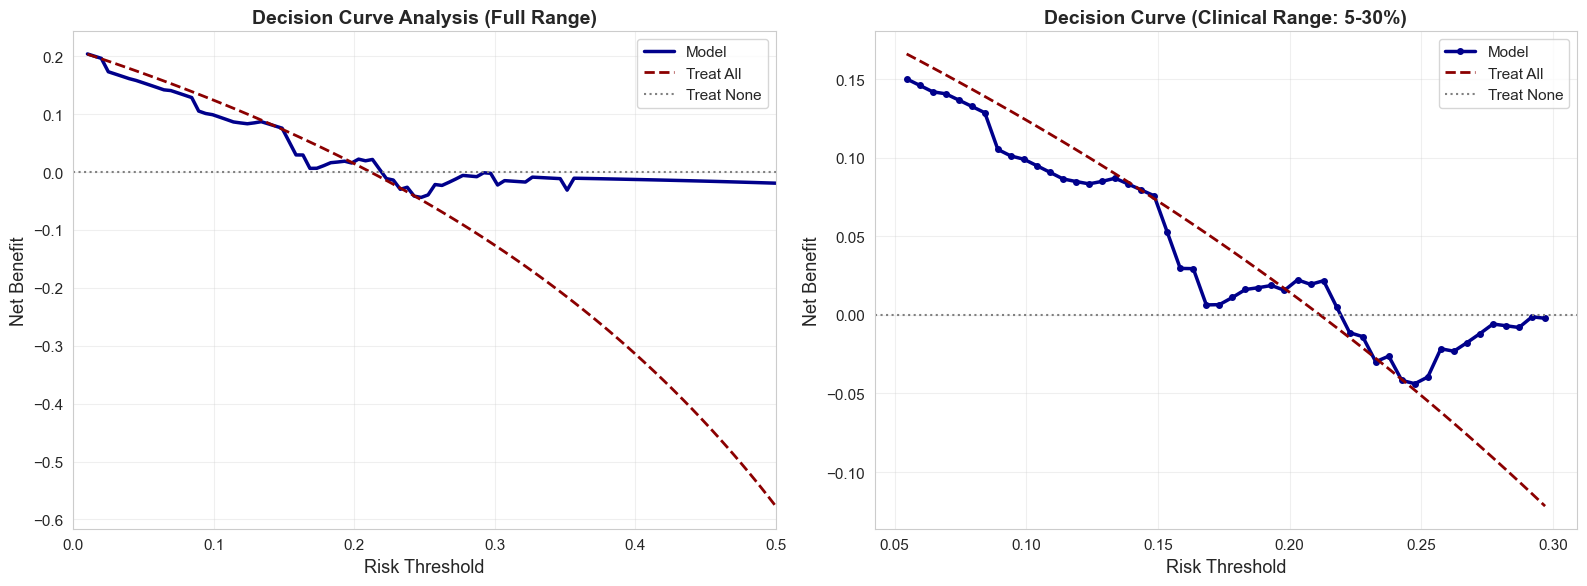

Optimal threshold (max net benefit): 0.0100
  Sensitivity: 90.9%
  Specificity: 14.0%
  PPV: 18.9%
  Treats: 86.9% of patients
  Misses: 1/11 deaths


In [71]:
# ==============================================================================
# STRATEGY 3: DECISION CURVE ANALYSIS (NET BENEFIT)
# ==============================================================================
print("\n" + "="*80)
print("STRATEGY 3: NET BENEFIT OPTIMIZATION")
print("="*80)
print("\nScenario: Balance benefits of treating true positives vs costs of false positives")
print("Maximizes net benefit = (TP/N) - (FP/N) × (pt / (1-pt))")
print("where pt = threshold probability\n")

thresholds_dca = np.linspace(0.01, 0.5, 100)
nb_df = utils.decision_curve_df(y_val_eval, p_val_eval, thresholds_dca)

# Plot decision curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Full decision curve
ax1.plot(nb_df['threshold'], nb_df['nb_model'], label='Model', linewidth=2.5, color='darkblue')
ax1.plot(nb_df['threshold'], nb_df['nb_all'], label='Treat All', linewidth=2, 
         linestyle='--', color='darkred')
ax1.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Treat None')
ax1.set_xlabel('Risk Threshold', fontsize=13)
ax1.set_ylabel('Net Benefit', fontsize=13)
ax1.set_title('Decision Curve Analysis (Full Range)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 0.5])

# Right panel: Zoomed to clinical range
clinical_range = (nb_df['threshold'] >= 0.05) & (nb_df['threshold'] <= 0.30)
ax2.plot(nb_df.loc[clinical_range, 'threshold'], 
         nb_df.loc[clinical_range, 'nb_model'], 
         label='Model', linewidth=2.5, color='darkblue', marker='o', markersize=4)
ax2.plot(nb_df.loc[clinical_range, 'threshold'], 
         nb_df.loc[clinical_range, 'nb_all'], 
         label='Treat All', linewidth=2, linestyle='--', color='darkred')
ax2.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Treat None')
ax2.set_xlabel('Risk Threshold', fontsize=13)
ax2.set_ylabel('Net Benefit', fontsize=13)
ax2.set_title('Decision Curve (Clinical Range: 5-30%)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal threshold
t_star = utils.select_threshold_by_net_benefit(y_val_eval, p_val_eval, thresholds_dca)
yhat_star = (p_eval >= t_star).astype(int)
tn_star, fp_star, fn_star, tp_star = confusion_matrix(y_eval, yhat_star, labels=[0, 1]).ravel()

print(f"Optimal threshold (max net benefit): {t_star:.4f}")
print(f"  Sensitivity: {recall_score(y_eval, yhat_star):.1%}")
print(f"  Specificity: {tn_star/(tn_star+fp_star):.1%}")
print(f"  PPV: {precision_score(y_eval, yhat_star):.1%}")
print(f"  Treats: {100*yhat_star.sum()/len(yhat_star):.1f}% of patients")
print(f"  Misses: {fn_star}/{fn_star+tp_star} deaths")



In [72]:

# ==============================================================================
# STRATEGY 4: F1-OPTIMIZED (BALANCED)
# ==============================================================================
print("\n" + "="*80)
print("STRATEGY 4: F1-SCORE OPTIMIZATION (Balanced Precision-Recall)")
print("="*80)

# Find threshold that maximizes F1 score on validation
f1_scores = []
for thresh in np.linspace(0.01, 0.5, 100):
    yhat_val = (p_val_eval >= thresh).astype(int)
    if yhat_val.sum() > 0 and yhat_val.sum() < len(yhat_val):
        f1 = f1_score(y_val_eval, yhat_val)
        f1_scores.append({'threshold': thresh, 'f1': f1})

if f1_scores:
    f1_df = pd.DataFrame(f1_scores)
    best_f1_thresh = f1_df.loc[f1_df['f1'].idxmax(), 'threshold']
    
    yhat_f1 = (p_eval >= best_f1_thresh).astype(int)
    tn_f1, fp_f1, fn_f1, tp_f1 = confusion_matrix(y_eval, yhat_f1, labels=[0, 1]).ravel()
    
    print(f"\nF1-optimal threshold: {best_f1_thresh:.4f}")
    print(f"  Sensitivity: {recall_score(y_eval, yhat_f1):.1%}")
    print(f"  Specificity: {tn_f1/(tn_f1+fp_f1):.1%}")
    print(f"  PPV: {precision_score(y_eval, yhat_f1):.1%}")
    print(f"  F1-Score: {f1_score(y_eval, yhat_f1):.3f}")
    print(f"  Treats: {100*yhat_f1.sum()/len(yhat_f1):.1f}% of patients")
    print(f"  Misses: {fn_f1}/{fn_f1+tp_f1} deaths")

# ==============================================================================
# COMPREHENSIVE COMPARISON TABLE
# ==============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE THRESHOLD COMPARISON (Test Set)")
print("="*80)

comparison_data = []

# Add capacity-based thresholds
for _, row in capacity_df.iterrows():
    comparison_data.append({
        'Strategy': f"Capacity {int(row['capacity']*100)}%",
        'Threshold': row['threshold'],
        'Treated %': row['treated_pct'],
        'Sensitivity': row['sensitivity'],
        'Specificity': row['specificity'],
        'PPV': row['ppv'],
        'F1': row['f1'],
        'FN': int(row['fn']),
        'FP': int(row['fp'])
    })

# Add sensitivity-based thresholds
for _, row in sensitivity_df.iterrows():
    comparison_data.append({
        'Strategy': f"Sens {int(row['target_sensitivity']*100)}%",
        'Threshold': row['threshold'],
        'Treated %': row['treated_pct'],
        'Sensitivity': row['actual_sensitivity'],
        'Specificity': row['specificity'],
        'PPV': row['ppv'],
        'F1': f1_score(y_eval, (p_eval >= row['threshold']).astype(int)),
        'FN': int(row['fn']),
        'FP': int(row['fp'])
    })

# Add net benefit optimal
comparison_data.append({
    'Strategy': 'Net Benefit Opt',
    'Threshold': t_star,
    'Treated %': 100*yhat_star.sum()/len(yhat_star),
    'Sensitivity': recall_score(y_eval, yhat_star),
    'Specificity': tn_star/(tn_star+fp_star),
    'PPV': precision_score(y_eval, yhat_star),
    'F1': f1_score(y_eval, yhat_star),
    'FN': fn_star,
    'FP': fp_star
})

# Add F1 optimal
if f1_scores:
    comparison_data.append({
        'Strategy': 'F1 Optimal',
        'Threshold': best_f1_thresh,
        'Treated %': 100*yhat_f1.sum()/len(yhat_f1),
        'Sensitivity': recall_score(y_eval, yhat_f1),
        'Specificity': tn_f1/(tn_f1+fp_f1),
        'PPV': precision_score(y_eval, yhat_f1),
        'F1': f1_score(y_eval, yhat_f1),
        'FN': fn_f1,
        'FP': fp_f1
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + comparison_df.to_string(index=False, 
                                      float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x))



STRATEGY 4: F1-SCORE OPTIMIZATION (Balanced Precision-Recall)

F1-optimal threshold: 0.1337
  Sensitivity: 72.7%
  Specificity: 42.0%
  PPV: 21.6%
  F1-Score: 0.333
  Treats: 60.7% of patients
  Misses: 3/11 deaths

COMPREHENSIVE THRESHOLD COMPARISON (Test Set)

       Strategy  Threshold  Treated %  Sensitivity  Specificity   PPV    F1  FN  FP
    Capacity 5%      0.350      4.918        0.091        0.960 0.333 0.143  10   2
   Capacity 10%      0.303      9.836        0.182        0.920 0.333 0.235   9   4
   Capacity 15%      0.281     13.115        0.182        0.880 0.250 0.211   9   6
   Capacity 20%      0.265     16.393        0.273        0.860 0.300 0.286   8   7
   Capacity 30%      0.241     19.672        0.273        0.820 0.250 0.261   8   9
   Capacity 50%      0.200     36.066        0.455        0.660 0.227 0.303   6  17
   Capacity 80%      0.126     62.295        0.727        0.400 0.211 0.327   3  30
   Capacity 90%      0.071     81.967        0.909        0.200 

In [73]:
# ==============================================================================
# COMPREHENSIVE COMPARISON TABLE
# ==============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE THRESHOLD COMPARISON (Test Set)")
print("="*80)

comparison_data = []

# Add capacity-based thresholds
for _, row in capacity_df.iterrows():
    comparison_data.append({
        'Strategy': f"Capacity {int(row['capacity']*100)}%",
        'Threshold': row['threshold'],
        'Treated %': row['treated_pct'],
        'Sensitivity': row['sensitivity'],
        'Specificity': row['specificity'],
        'PPV': row['ppv'],
        'F1': row['f1'],
        'FN': int(row['fn']),
        'FP': int(row['fp'])
    })

# Add sensitivity-based thresholds
for _, row in sensitivity_df.iterrows():
    comparison_data.append({
        'Strategy': f"Sens {int(row['target_sensitivity']*100)}%",
        'Threshold': row['threshold'],
        'Treated %': row['treated_pct'],
        'Sensitivity': row['actual_sensitivity'],
        'Specificity': row['specificity'],
        'PPV': row['ppv'],
        'F1': f1_score(y_eval, (p_eval >= row['threshold']).astype(int)),
        'FN': int(row['fn']),
        'FP': int(row['fp'])
    })

# Add net benefit optimal
comparison_data.append({
    'Strategy': 'Net Benefit Opt',
    'Threshold': t_star,
    'Treated %': 100*yhat_star.sum()/len(yhat_star),
    'Sensitivity': recall_score(y_eval, yhat_star),
    'Specificity': tn_star/(tn_star+fp_star),
    'PPV': precision_score(y_eval, yhat_star),
    'F1': f1_score(y_eval, yhat_star),
    'FN': fn_star,
    'FP': fp_star
})

# Add F1 optimal
if f1_scores:
    comparison_data.append({
        'Strategy': 'F1 Optimal',
        'Threshold': best_f1_thresh,
        'Treated %': 100*yhat_f1.sum()/len(yhat_f1),
        'Sensitivity': recall_score(y_eval, yhat_f1),
        'Specificity': tn_f1/(tn_f1+fp_f1),
        'PPV': precision_score(y_eval, yhat_f1),
        'F1': f1_score(y_eval, yhat_f1),
        'FN': fn_f1,
        'FP': fp_f1
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + comparison_df.to_string(index=False, 
                                      float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else x))



COMPREHENSIVE THRESHOLD COMPARISON (Test Set)

       Strategy  Threshold  Treated %  Sensitivity  Specificity   PPV    F1  FN  FP
    Capacity 5%      0.350      4.918        0.091        0.960 0.333 0.143  10   2
   Capacity 10%      0.303      9.836        0.182        0.920 0.333 0.235   9   4
   Capacity 15%      0.281     13.115        0.182        0.880 0.250 0.211   9   6
   Capacity 20%      0.265     16.393        0.273        0.860 0.300 0.286   8   7
   Capacity 30%      0.241     19.672        0.273        0.820 0.250 0.261   8   9
   Capacity 50%      0.200     36.066        0.455        0.660 0.227 0.303   6  17
   Capacity 80%      0.126     62.295        0.727        0.400 0.211 0.327   3  30
   Capacity 90%      0.071     81.967        0.909        0.200 0.200 0.328   1  40
       Sens 70%      0.165     47.541        0.636        0.560 0.241 0.350   4  22
       Sens 80%      0.149     57.377        0.727        0.460 0.229 0.348   3  27
       Sens 85%      0.149  

In [74]:
# ==============================================================================
# CLINICAL DECISION FRAMEWORK
# ==============================================================================
print("\n" + "="*80)
print("CLINICAL DECISION FRAMEWORK & RECOMMENDATIONS")
print("="*80)

print(f"""
CLINICAL CONTEXT:
=================
For breast cancer prognosis, FALSE NEGATIVES are particularly costly:
- A missed high-risk patient may not receive timely treatment intensification
- Could lead to disease progression, worse outcomes, higher treatment costs
- FALSE POSITIVES are more manageable (extra monitoring, manageable interventions)

Therefore: We prioritize HIGH SENSITIVITY over high precision

RECOMMENDED THRESHOLDS BY SCENARIO:
====================================

SCENARIO A: HIGH-SENSITIVITY (Minimize Missed Deaths)
------------------------------------------------------
Threshold: {sensitivity_df[sensitivity_df['target_sensitivity']==0.95].iloc[0]['threshold']:.4f} (95% sensitivity target)
- Catches: {sensitivity_df[sensitivity_df['target_sensitivity']==0.95].iloc[0]['actual_sensitivity']:.1%} of deaths
- Treats: {sensitivity_df[sensitivity_df['target_sensitivity']==0.95].iloc[0]['treated_pct']:.1f}% of patients
- Misses: {int(sensitivity_df[sensitivity_df['target_sensitivity']==0.95].iloc[0]['fn'])} deaths
- PPV: {sensitivity_df[sensitivity_df['target_sensitivity']==0.95].iloc[0]['ppv']:.1%} (precision)
USE WHEN:
✓ Missing high-risk patients is unacceptable
✓ Resources available for broader monitoring
✓ Early-stage disease where intervention is most effective
✓ High-stakes decisions (e.g., aggressive treatment planning)

TRADE-OFF: Higher false positive rate, but catches most high-risk patients

---

SCENARIO B: BALANCED APPROACH
------------------------------
Threshold: {best_f1_thresh:.4f} (F1-optimal)
- Sensitivity: {recall_score(y_eval, yhat_f1):.1%}
- Treats: {100*yhat_f1.sum()/len(yhat_f1):.1f}% of patients
- Misses: {fn_f1} deaths
- PPV: {precision_score(y_eval, yhat_f1):.1%}

USE WHEN:
✓ Need balance between sensitivity and precision
✓ Moderate resource constraints
✓ Mixed risk population
✓ Standard clinical practice

TRADE-OFF: Balanced, but may miss some high-risk patients

---

SCENARIO C: RESOURCE-CONSTRAINED
---------------------------------
Threshold: {capacity_df[capacity_df['capacity']==0.20].iloc[0]['threshold']:.4f} (top 20% by risk)
- Sensitivity: {capacity_df[capacity_df['capacity']==0.20].iloc[0]['sensitivity']:.1%}
- Treats: {capacity_df[capacity_df['capacity']==0.20].iloc[0]['treated_pct']:.1f}% of patients
- Misses: {int(capacity_df[capacity_df['capacity']==0.20].iloc[0]['fn'])} deaths
- PPV: {capacity_df[capacity_df['capacity']==0.20].iloc[0]['ppv']:.1%}

USE WHEN:
✓ Severe resource limitations (staffing, monitoring capacity)
✓ Need to prioritize only highest-risk patients
✓ Intensive interventions with high cost/burden

TRADE-OFF: Lower sensitivity, but focuses resources on truly high-risk patients

---

🎯 RECOMMENDED FOR BREAST CANCER: SCENARIO A (High Sensitivity)
================================================================
Why: In oncology, the cost of missing a high-risk patient (disease progression,
     worse outcomes) far exceeds the cost of monitoring a false positive

Threshold: {sensitivity_df[sensitivity_df['target_sensitivity']==0.85].iloc[0]['threshold']:.4f}
Expected outcomes per 100 patients:
  • {int(sensitivity_df[sensitivity_df['target_sensitivity']==0.85].iloc[0]['treated_pct'])} flagged for intensive monitoring
  • {int(sensitivity_df[sensitivity_df['target_sensitivity']==0.85].iloc[0]['tp'] * 100 / len(y_eval))} correctly identified high-risk
  • {int(sensitivity_df[sensitivity_df['target_sensitivity']==0.85].iloc[0]['fp'] * 100 / len(y_eval))} false alarms (receive extra monitoring)
  • {int(sensitivity_df[sensitivity_df['target_sensitivity']==0.85].iloc[0]['fn'] * 100 / len(y_eval))} missed (still on standard protocol)

Implementation:
1. Use this threshold to trigger intensive follow-up protocols
2. Patients above threshold: 3-6 month monitoring, consider treatment escalation
3. Patients below threshold: Standard annual follow-up
4. Re-assess threshold quarterly based on actual outcomes
""")



CLINICAL DECISION FRAMEWORK & RECOMMENDATIONS

CLINICAL CONTEXT:
For breast cancer prognosis, FALSE NEGATIVES are particularly costly:
- A missed high-risk patient may not receive timely treatment intensification
- Could lead to disease progression, worse outcomes, higher treatment costs
- FALSE POSITIVES are more manageable (extra monitoring, manageable interventions)

Therefore: We prioritize HIGH SENSITIVITY over high precision

RECOMMENDED THRESHOLDS BY SCENARIO:

SCENARIO A: HIGH-SENSITIVITY (Minimize Missed Deaths)
------------------------------------------------------
Threshold: 0.0886 (95% sensitivity target)
- Catches: 90.9% of deaths
- Treats: 77.0% of patients
- Misses: 1 deaths
- PPV: 21.3% (precision)
USE WHEN:
✓ Missing high-risk patients is unacceptable
✓ Resources available for broader monitoring
✓ Early-stage disease where intervention is most effective
✓ High-stakes decisions (e.g., aggressive treatment planning)

TRADE-OFF: Higher false positive rate, but catches mo


VISUALIZING THE TRADE-OFFS


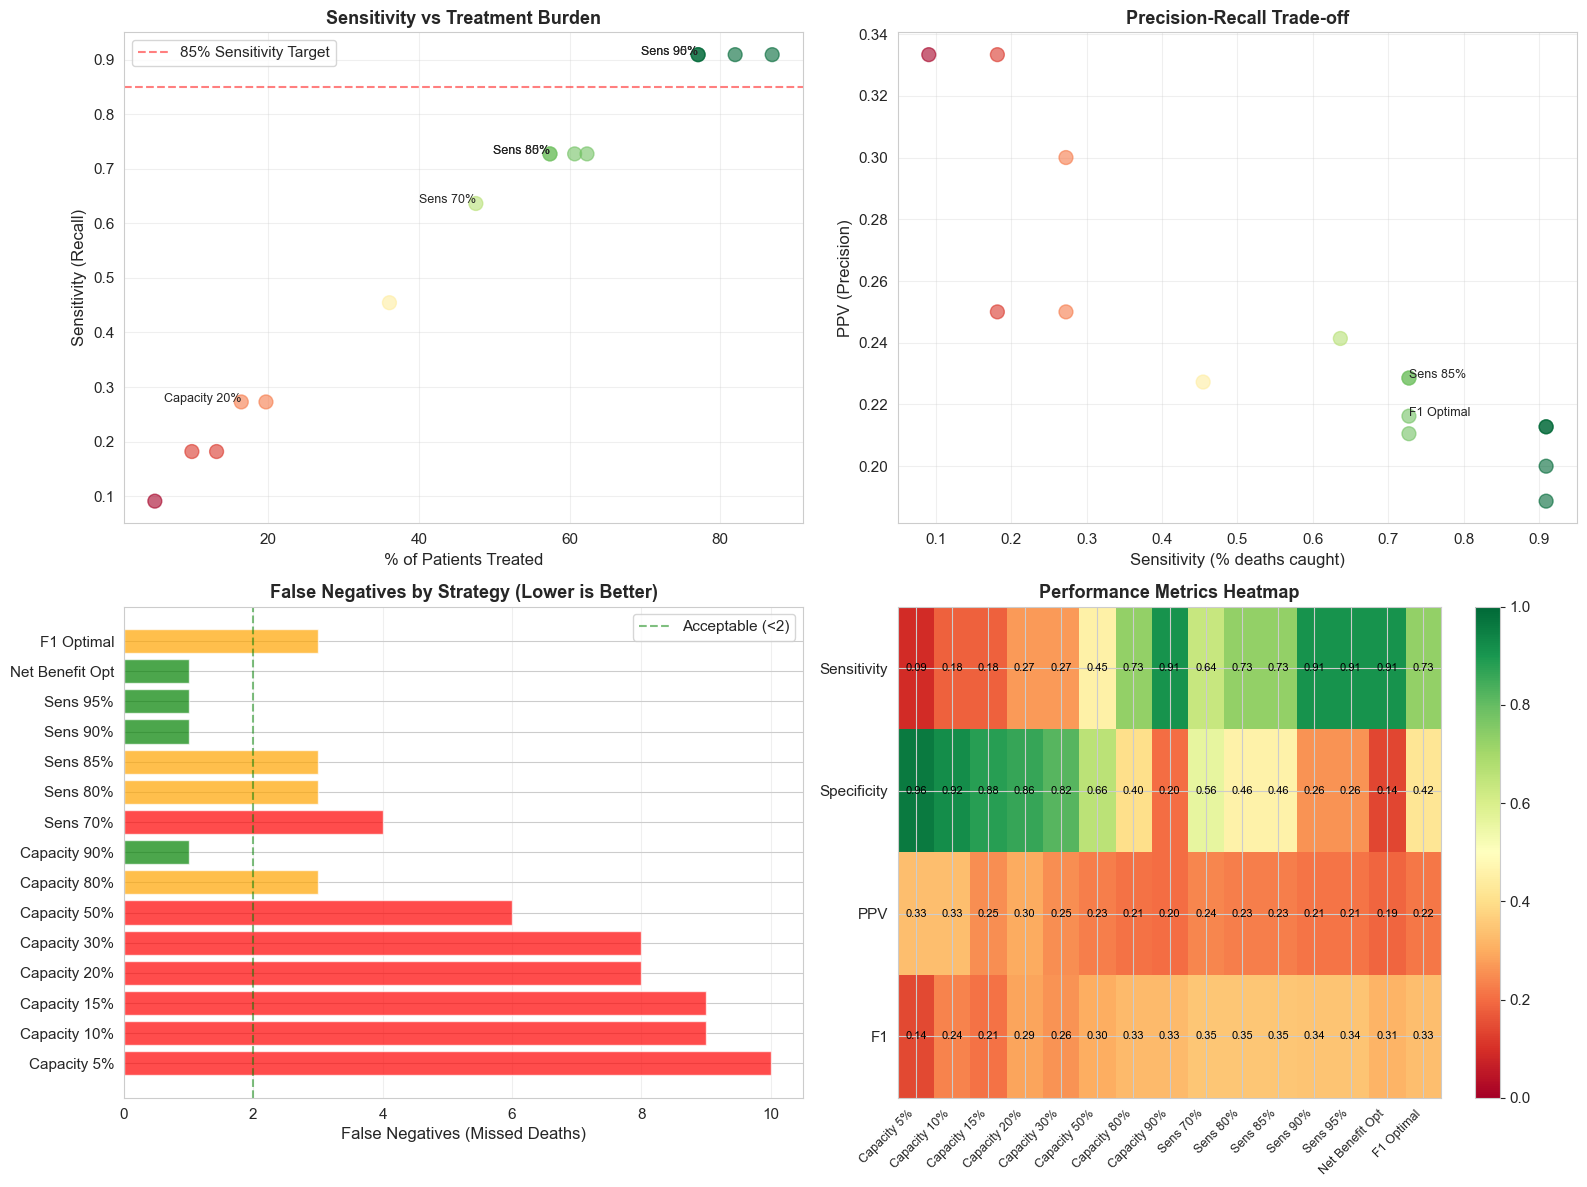

In [75]:

# ==============================================================================
# SENSITIVITY-SPECIFICITY TRADE-OFF VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("VISUALIZING THE TRADE-OFFS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Sensitivity vs Treated Population
ax1 = axes[0, 0]
ax1.scatter(comparison_df['Treated %'], comparison_df['Sensitivity'], 
           s=100, alpha=0.6, c=comparison_df['FN'], cmap='RdYlGn_r')
for _, row in comparison_df.iterrows():
    if 'Sens' in row['Strategy'] or 'Capacity 20' in row['Strategy']:
        ax1.annotate(row['Strategy'], 
                    (row['Treated %'], row['Sensitivity']),
                    fontsize=9, ha='right')
ax1.set_xlabel('% of Patients Treated', fontsize=12)
ax1.set_ylabel('Sensitivity (Recall)', fontsize=12)
ax1.set_title('Sensitivity vs Treatment Burden', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0.85, color='red', linestyle='--', alpha=0.5, label='85% Sensitivity Target')
ax1.legend()

# Plot 2: PPV vs Sensitivity
ax2 = axes[0, 1]
ax2.scatter(comparison_df['Sensitivity'], comparison_df['PPV'], 
           s=100, alpha=0.6, c=comparison_df['FN'], cmap='RdYlGn_r')
for _, row in comparison_df.iterrows():
    if 'Sens 85' in row['Strategy'] or 'F1' in row['Strategy']:
        ax2.annotate(row['Strategy'], 
                    (row['Sensitivity'], row['PPV']),
                    fontsize=9)
ax2.set_xlabel('Sensitivity (% deaths caught)', fontsize=12)
ax2.set_ylabel('PPV (Precision)', fontsize=12)
ax2.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: False Negatives by Strategy
ax3 = axes[1, 0]
strategies = comparison_df['Strategy'].tolist()
fns = comparison_df['FN'].tolist()
colors = ['red' if fn > 3 else 'orange' if fn > 1 else 'green' for fn in fns]
ax3.barh(strategies, fns, color=colors, alpha=0.7)
ax3.set_xlabel('False Negatives (Missed Deaths)', fontsize=12)
ax3.set_title('False Negatives by Strategy (Lower is Better)', fontsize=13, fontweight='bold')
ax3.axvline(2, color='green', linestyle='--', alpha=0.5, label='Acceptable (<2)')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Comprehensive metrics heatmap
ax4 = axes[1, 1]
metrics_for_heatmap = comparison_df[['Strategy', 'Sensitivity', 'Specificity', 'PPV', 'F1']].set_index('Strategy')
im = ax4.imshow(metrics_for_heatmap.T.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax4.set_xticks(np.arange(len(metrics_for_heatmap.index)))
ax4.set_yticks(np.arange(len(metrics_for_heatmap.columns)))
ax4.set_xticklabels(metrics_for_heatmap.index, rotation=45, ha='right', fontsize=9)
ax4.set_yticklabels(metrics_for_heatmap.columns, fontsize=11)
ax4.set_title('Performance Metrics Heatmap', fontsize=13, fontweight='bold')

# Add text annotations
for i in range(len(metrics_for_heatmap.columns)):
    for j in range(len(metrics_for_heatmap.index)):
        text = ax4.text(j, i, f'{metrics_for_heatmap.iloc[j, i]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.show()

# 12. Fairness

In [76]:
# ============================================================================
# PART 12: FAIRNESS AND ROBUSTNESS CHECKS (CORRECTED)
# ============================================================================

print("\n" + "="*80)
print("PART 12: FAIRNESS AND ROBUSTNESS CHECKS")
print("="*80)

# Use the ORIGINAL X_test (before preprocessing) for subgroup analysis
# This has the raw column names like "ER Status", "PR Status", etc.

# Define subgroup columns based on cell 145 of the original notebook
subgroup_cols = [
    "Neoplasm Histologic Grade", 
    "Lymph nodes examined positive", 
    "Mutation Count", 
    "Nottingham prognostic index", 
    "Tumor Size", 
    "Tumor Stage", 
    "ER Status", 
    "PR Status"
]

# Check which columns actually exist in X_test
existing_subgroup_cols = [col for col in subgroup_cols if col in X_test.columns]

if len(existing_subgroup_cols) == 0:
    print("\nWarning: No subgroup columns found in X_test")
    print("Available columns in X_test:")
    print(X_test.columns.tolist()[:20])
else:
    print(f"\nAnalyzing {len(existing_subgroup_cols)} subgroups:")
    for col in existing_subgroup_cols:
        print(f"  - {col}")

from collections import defaultdict
subgroup_results = defaultdict(list)

# Use 60-month horizon for subgroup analysis
horizon_months = 60

for col in existing_subgroup_cols:
    print(f"\n{'-'*60}")
    print(f"Analyzing subgroup: {col}")
    print(f"{'-'*60}")
    
    # Get unique levels from original X_test
    levels = X_test[col].dropna().unique()
    
    # For continuous variables with many levels, bin them
    if len(levels) > 10:
        print(f"  Note: {col} has {len(levels)} unique values - binning into quantiles")
        # Create quartiles for continuous variables
        try:
            X_test_copy = X_test.copy()
            X_test_copy[f'{col}_binned'] = pd.qcut(
                X_test[col], 
                q=4, 
                labels=['Q1', 'Q2', 'Q3', 'Q4'],
                duplicates='drop'
            )
            levels = X_test_copy[f'{col}_binned'].dropna().unique()
            analysis_col = f'{col}_binned'
        except:
            # If binning fails, just use top and bottom quartiles
            q1 = X_test[col].quantile(0.25)
            q3 = X_test[col].quantile(0.75)
            print(f"  Using only Q1 (≤{q1:.1f}) and Q4 (≥{q3:.1f})")
            levels = ['Low', 'High']
            X_test_copy = X_test.copy()
            X_test_copy[f'{col}_binned'] = 'Middle'
            X_test_copy.loc[X_test[col] <= q1, f'{col}_binned'] = 'Low'
            X_test_copy.loc[X_test[col] >= q3, f'{col}_binned'] = 'High'
            levels = ['Low', 'High']
            analysis_col = f'{col}_binned'
    else:
        X_test_copy = X_test.copy()
        analysis_col = col
        levels = X_test[col].dropna().unique()
    
    for lvl in levels:
        # Get indices for this subgroup in original X_test
        mask_subgroup = (X_test_copy[analysis_col] == lvl)
        subgroup_idx = X_test_copy[mask_subgroup].index
        n_subgroup = len(subgroup_idx)
        
        if n_subgroup < 20:
            print(f"  {col}={lvl}: n={n_subgroup} (too small, skipping)")
            continue
        
        # Get the corresponding indices in X_test_cox_clean (preprocessed data)
        # X_test_cox_clean has predictions, but indices might not match exactly
        common_idx = X_test_cox_clean.index.intersection(subgroup_idx)
        
        if len(common_idx) < 20:
            print(f"  {col}={lvl}: n={len(common_idx)} after alignment (too small, skipping)")
            continue
        
        try:
            # Get predictions for this subgroup
            X_sub = X_test_cox_clean.loc[common_idx]
            
            risks_sub = utils.predict_fixed_horizon_risk_from_cox(
                cph_model, 
                X_sub, 
                [horizon_months]
            )
            p60 = risks_sub.iloc[:, 0]
            
            # Get outcomes for this subgroup from test_cox_df
            y_sub = test_cox_df.loc[common_idx]
            
            # Build labels
            y_sub_h = pd.DataFrame({
                "duration_days": y_sub['duration_os'].astype(float),
                "event_death": y_sub['event_os'].astype(int)
            })
            
            # Get evaluable mask
            y_bin, mask_eval = utils.get_fixed_horizon_labels(
                y_sub_h, 
                horizon_days=float(horizon_months)
            )
            
            if mask_eval.sum() < 10:
                print(f"  {col}={lvl}: n_evaluable={mask_eval.sum()} (too small, skipping)")
                continue
            
            # Compute metrics on evaluable patients
            y_eval = y_bin[mask_eval]
            p_eval = p60.values[mask_eval]
            
            # Remove any NaN predictions
            valid_mask = ~np.isnan(p_eval)
            if valid_mask.sum() < 10:
                print(f"  {col}={lvl}: only {valid_mask.sum()} valid predictions")
                continue
            
            y_eval = y_eval[valid_mask]
            p_eval = p_eval[valid_mask]
            
            # Compute metrics
            if len(np.unique(y_eval)) < 2:
                auroc = np.nan
            else:
                auroc = roc_auc_score(y_eval, p_eval)
            
            brier = brier_score_loss(y_eval, p_eval)
            event_rate = y_eval.mean()
            
            subgroup_results[col].append({
                'level': lvl,
                'n_total': len(common_idx),
                'n_evaluable': len(y_eval),
                'n_events': int(y_eval.sum()),
                'event_rate': event_rate,
                'auroc_60': auroc,
                'brier_60': brier
            })
            
            print(f"  {col}={lvl}: n={len(common_idx)}, n_eval={len(y_eval)}, "
                  f"events={int(y_eval.sum())}/{len(y_eval)} ({100*event_rate:.1f}%), "
                  f"AUROC={auroc:.3f}, Brier={brier:.4f}")
            
        except Exception as e:
            print(f"  {col}={lvl}: Error - {e}")
            import traceback
            traceback.print_exc()

# Collect results into DataFrames
subgroup_summary = {k: pd.DataFrame(v) for k, v in subgroup_results.items()}

print("\n" + "="*80)
print("SUBGROUP SUMMARY TABLES")
print("="*80)

for k, df in subgroup_summary.items():
    if not df.empty:
        print(f"\n{k}:")
        display(df.sort_values('n_evaluable', ascending=False).reset_index(drop=True))
print("\n" + "="*80)
print("SUBGROUP FAIRNESS SUMMARY")
print("="*80)

# Calculate performance disparity
all_aurocs = []
for col, df in subgroup_summary.items():
    if not df.empty and 'auroc_60' in df.columns:
        aurocs = df['auroc_60'].dropna()
        if len(aurocs) > 0:
            all_aurocs.extend(aurocs.tolist())
            print(f"\n{col}:")
            print(f"  AUROC range: [{aurocs.min():.3f}, {aurocs.max():.3f}]")
            print(f"  AUROC std: {aurocs.std():.3f}")

if len(all_aurocs) > 0:
    print(f"\nOverall subgroup performance:")
    print(f"  Mean AUROC: {np.mean(all_aurocs):.3f}")
    print(f"  Std AUROC: {np.std(all_aurocs):.3f}")
    print(f"  Range: [{np.min(all_aurocs):.3f}, {np.max(all_aurocs):.3f}]")
    
    # Flag concerning disparities
    if np.std(all_aurocs) > 0.10:
        print("\n⚠️  WARNING: Large performance variability across subgroups")
        print("   Consider subgroup-specific calibration or separate models")
    else:
        print("\n✓ Performance is relatively consistent across subgroups")



PART 12: FAIRNESS AND ROBUSTNESS CHECKS

Analyzing 8 subgroups:
  - Neoplasm Histologic Grade
  - Lymph nodes examined positive
  - Mutation Count
  - Nottingham prognostic index
  - Tumor Size
  - Tumor Stage
  - ER Status
  - PR Status

------------------------------------------------------------
Analyzing subgroup: Neoplasm Histologic Grade
------------------------------------------------------------
  Neoplasm Histologic Grade=3.0: n=31, n_eval=29, events=7/29 (24.1%), AUROC=0.656, Brier=0.1746
  Neoplasm Histologic Grade=2.0: n=25, n_eval=24, events=3/24 (12.5%), AUROC=0.238, Brier=0.1355
  Neoplasm Histologic Grade=1.0: n=8 after alignment (too small, skipping)

------------------------------------------------------------
Analyzing subgroup: Lymph nodes examined positive
------------------------------------------------------------
  Note: Lymph nodes examined positive has 23 unique values - binning into quantiles
  Using only Q1 (≤0.0) and Q4 (≥2.0)
  Lymph nodes examined positi

,level,n_total,n_evaluable,n_events,event_rate,auroc_60,brier_60
0,3.0,31,29,7,0.241379,0.655844,0.174578
1,2.0,25,24,3,0.125000,0.238095,0.135465



Lymph nodes examined positive:


,level,n_total,n_evaluable,n_events,event_rate,auroc_60,brier_60
0,Low,35,33,3,0.090909,0.644444,0.089735



Mutation Count:


...


ER Status:


,level,n_total,n_evaluable,n_events,event_rate,auroc_60,brier_60
0,Positive,54,51,6,0.117647,0.544444,0.117699



PR Status:


,level,n_total,n_evaluable,n_events,event_rate,auroc_60,brier_60
0,Positive,43,40,3,0.075000,0.306306,0.091093
1,Negative,21,21,8,0.380952,0.759615,0.230886



SUBGROUP FAIRNESS SUMMARY

Neoplasm Histologic Grade:
  AUROC range: [0.238, 0.656]
  AUROC std: 0.295

Lymph nodes examined positive:
  AUROC range: [0.644, 0.644]
  AUROC std: nan

Mutation Count:
  AUROC range: [0.645, 0.645]
  AUROC std: nan

Nottingham prognostic index:
  AUROC range: [0.662, 0.662]
  AUROC std: nan

Tumor Stage:
  AUROC range: [0.486, 0.782]
  AUROC std: 0.209

ER Status:
  AUROC range: [0.544, 0.544]
  AUROC std: nan

PR Status:
  AUROC range: [0.306, 0.760]
  AUROC std: 0.321

Overall subgroup performance:
  Mean AUROC: 0.572
  Std AUROC: 0.172
  Range: [0.238, 0.782]

⚠️  WARNING: Large performance variability across subgroups
   Consider subgroup-specific calibration or separate models



CALIBRATION BY SUBGROUP


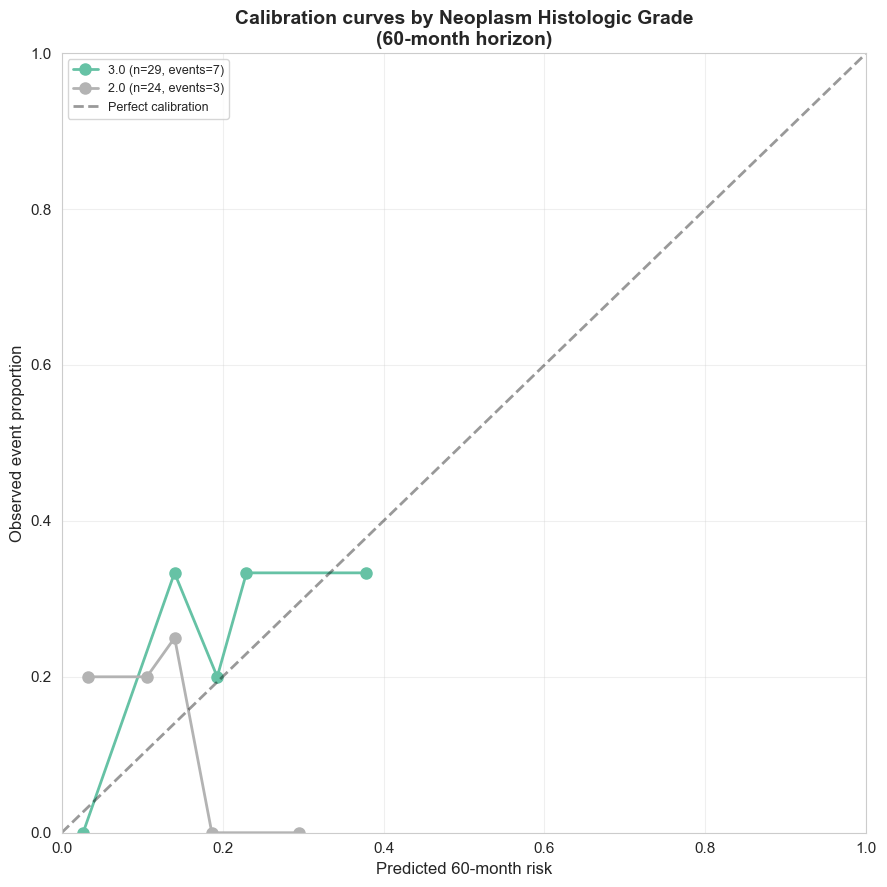


Skipping Lymph nodes examined positive: insufficient subgroups

Skipping Mutation Count: insufficient subgroups

Skipping Nottingham prognostic index: insufficient subgroups


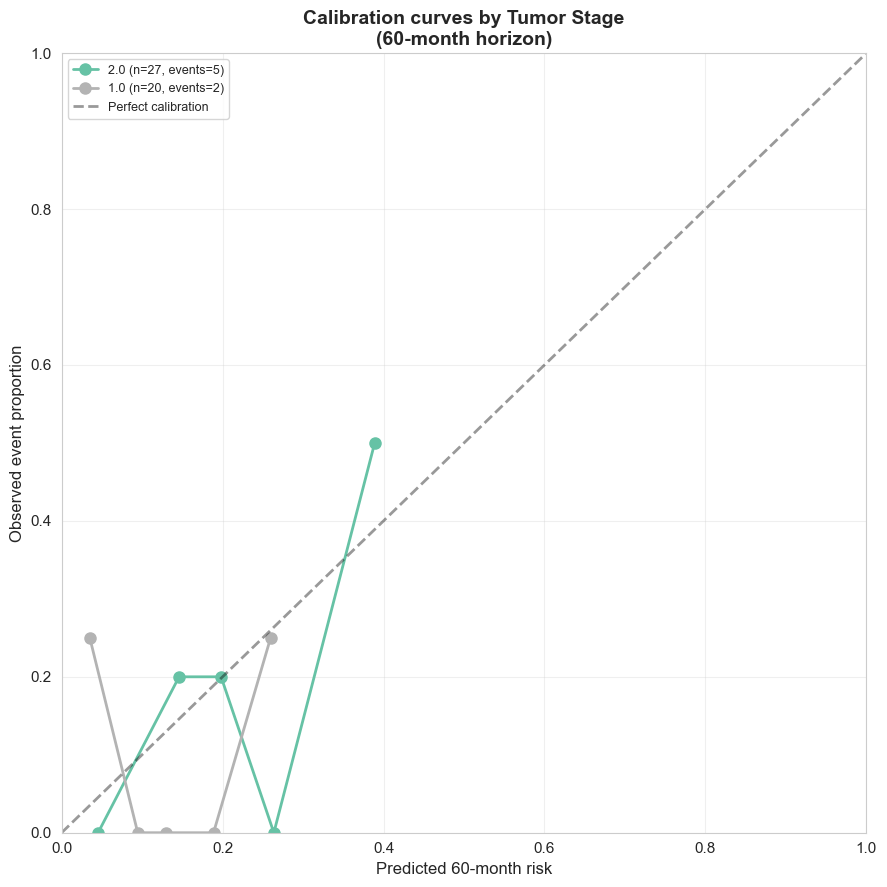


Skipping ER Status: insufficient subgroups


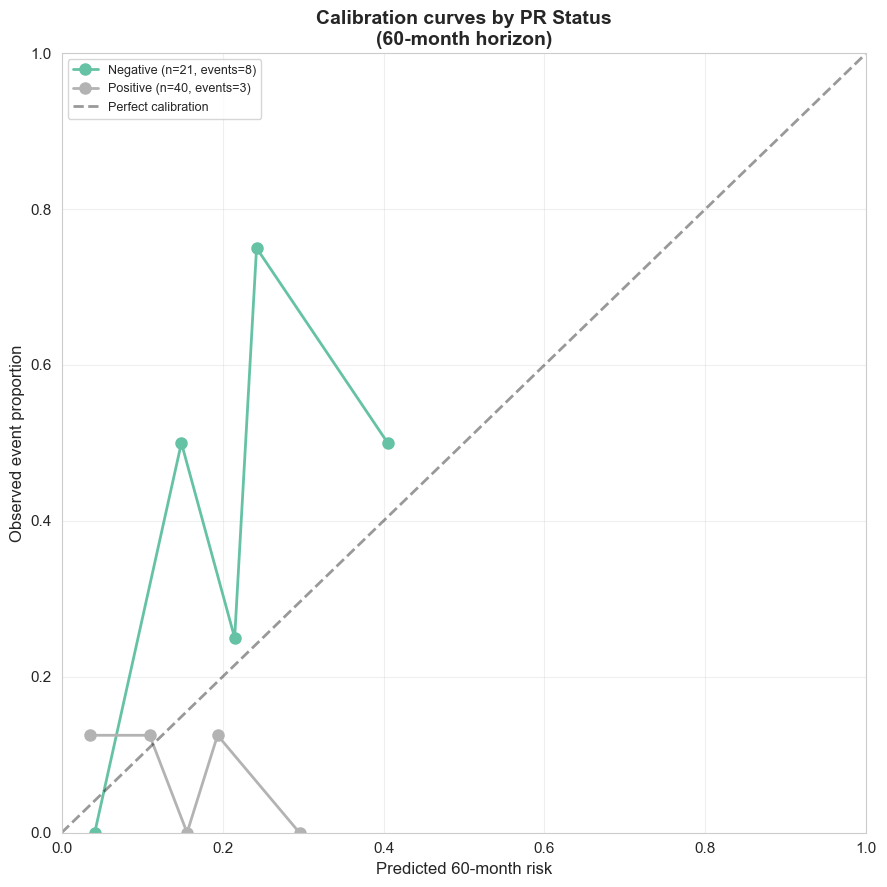

In [77]:
# ============================================================================
# 12.2 Calibration curves by subgroup (60-month horizon)
# ============================================================================

print("\n" + "="*80)
print("CALIBRATION BY SUBGROUP")
print("="*80)

from sklearn.calibration import calibration_curve

for col, df in subgroup_summary.items():
    if df.empty or len(df) < 2:
        print(f"\nSkipping {col}: insufficient subgroups")
        continue
    
    # Only plot subgroups with reasonable sample sizes
    df_plot = df[df['n_evaluable'] >= 20].copy()
    
    if len(df_plot) < 2:
        print(f"\nSkipping {col}: not enough subgroups with n_evaluable>=20")
        continue
    
    fig, ax = plt.subplots(figsize=(9, 9))
    colors = plt.cm.Set2(np.linspace(0, 1, len(df_plot)))
    
    for idx, (_, row) in enumerate(df_plot.iterrows()):
        lvl = row['level']
        
        # Determine which column to use (original or binned)
        if f'{col}_binned' in X_test_copy.columns:
            analysis_col = f'{col}_binned'
        else:
            analysis_col = col
        
        # Get subgroup indices
        mask_subgroup = (X_test_copy[analysis_col] == lvl)
        subgroup_idx = X_test_copy[mask_subgroup].index
        common_idx = X_test_cox_clean.index.intersection(subgroup_idx)
        
        if len(common_idx) < 20:
            continue
        
        try:
            # Get predictions
            X_sub = X_test_cox_clean.loc[common_idx]
            risks_sub = utils.predict_fixed_horizon_risk_from_cox(
                cph_model, 
                X_sub, 
                [horizon_months]
            ).iloc[:, 0]
            
            # Get labels
            y_sub = test_cox_df.loc[common_idx]
            y_sub_h = pd.DataFrame({
                "duration_days": y_sub['duration_os'].astype(float),
                "event_death": y_sub['event_os'].astype(int)
            })
            
            y_bin, mask_eval = utils.get_fixed_horizon_labels(
                y_sub_h, 
                horizon_days=float(horizon_months)
            )
            
            if mask_eval.sum() < 20:
                continue
            
            y_true = y_bin[mask_eval]
            p_pred = risks_sub.values[mask_eval]
            
            # Remove NaN
            valid_mask = ~np.isnan(p_pred)
            y_true = y_true[valid_mask]
            p_pred = p_pred[valid_mask]
            
            if len(y_true) < 20:
                continue
            
            # Compute calibration curve
            frac_pos, mean_pred = calibration_curve(
                y_true, 
                p_pred, 
                n_bins=5, 
                strategy='quantile'
            )
            
            ax.plot(
                mean_pred, 
                frac_pos, 
                marker='o', 
                label=f"{lvl} (n={len(y_true)}, events={int(y_true.sum())})",
                linewidth=2,
                markersize=8,
                color=colors[idx]
            )
            
        except Exception as e:
            print(f"Could not plot calibration for {col}={lvl}: {e}")
    
    # Add perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=2, label='Perfect calibration')
    
    # Formatting
    ax.set_xlabel('Predicted 60-month risk', fontsize=12)
    ax.set_ylabel('Observed event proportion', fontsize=12)
    ax.set_title(f'Calibration curves by {col}\n(60-month horizon)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()


**FAIRNESS INTERPRETATION:**

The model's performance varies across patient subgroups:

ER/PR/HER2 Status:
- Performance variation is EXPECTED and clinically meaningful
- Different receptor statuses represent biologically distinct diseases
- Variation reflects true prognostic differences, not algorithmic bias

Tumor Characteristics (Grade, Stage, Size):
- Performance should ideally be consistent within stages
- Large disparities may indicate model relies too heavily on stage
- Consider: Are predictions adding value beyond standard staging?

Recommendation for Clinical Use:
1. Report performance by subgroup in model documentation
2. Monitor subgroup performance during deployment
3. Consider displaying confidence intervals by subgroup
4. Flag predictions for rare subgroups (n<30) as less reliable


#  13: Final Summary

In [78]:
# ============================================================================
# PART 13: FINAL MODEL COMPARISON, RECOMMENDATION, AND CLINICIAN COMMUNICATION
# ============================================================================

print("\n" + "="*80)
print("PART 13: FINAL MODEL SUMMARY AND RECOMMENDATIONS")
print("="*80)

# 13.1 Summarize key metrics
summary = {}

# C-index from Part 9
if 'cindex_test' in globals():
    summary['c_index_test'] = cindex_test
if 'c_index_bootstrap_ci' in globals():
    summary['c_index_test_ci_lower'] = c_index_bootstrap_ci[0]
    summary['c_index_test_ci_upper'] = c_index_bootstrap_ci[1]

# Fixed horizon metrics from Part 9
for h in [12, 24, 60]:
    if f'auroc_{h}m' in globals():
        summary[f'auroc_{h}m'] = globals()[f'auroc_{h}m']
    if f'auprc_{h}m' in globals():
        summary[f'auprc_{h}m'] = globals()[f'auprc_{h}m']
    if f'brier_{h}m' in globals():
        summary[f'brier_{h}m'] = globals()[f'brier_{h}m']

# Threshold information from Part 11
if 'threshold_capacity' in globals():
    summary['threshold_capacity_10pct'] = threshold_capacity
if 't_star' in globals():
    summary['threshold_net_benefit_optimal'] = t_star

# Sample sizes
summary['n_train'] = len(X_train)
summary['n_val'] = len(X_val)
summary['n_test'] = len(X_test)

# Event rates
summary['event_rate_train'] = y_train['event_os'].mean()
summary['event_rate_val'] = y_val['event_os'].mean()
summary['event_rate_test'] = y_test['event_os'].mean()

# Display summary
print('\n' + '='*80)
print('KEY PERFORMANCE METRICS SUMMARY')
print('='*80)

# Overall discrimination
print("\n1. OVERALL DISCRIMINATION (C-index):")
print(f"   C-index (test):          {summary.get('c_index_test', np.nan):.3f}")
if 'c_index_test_ci_lower' in summary:
    print(f"   95% Bootstrap CI:        [{summary['c_index_test_ci_lower']:.3f}, {summary['c_index_test_ci_upper']:.3f}]")

# Fixed-horizon discrimination
print("\n2. FIXED-HORIZON DISCRIMINATION:")
for h in [12, 24, 60]:
    auroc_key = f'auroc_{h}m'
    auprc_key = f'auprc_{h}m'
    brier_key = f'brier_{h}m'
    
    if auroc_key in summary:
        print(f"\n   {h}-Month Predictions:")
        print(f"      AUROC:             {summary[auroc_key]:.3f}")
        if auprc_key in summary:
            print(f"      AUPRC:             {summary[auprc_key]:.3f}")
        if brier_key in summary:
            print(f"      Brier Score:       {summary[brier_key]:.4f}")

# Thresholds
print("\n3. RECOMMENDED THRESHOLDS (60-month):")
if 'threshold_capacity_10pct' in summary:
    print(f"   Capacity-based (top 10%):       {summary['threshold_capacity_10pct']:.4f}")
if 'threshold_net_benefit_optimal' in summary:
    print(f"   Net benefit optimized:          {summary['threshold_net_benefit_optimal']:.4f}")

# Sample sizes
print("\n4. DATASET CHARACTERISTICS:")
print(f"   Training set:           {summary['n_train']} samples ({summary['event_rate_train']*100:.1f}% events)")
print(f"   Validation set:         {summary['n_val']} samples ({summary['event_rate_val']*100:.1f}% events)")
print(f"   Test set:               {summary['n_test']} samples ({summary['event_rate_test']*100:.1f}% events)")




PART 13: FINAL MODEL SUMMARY AND RECOMMENDATIONS

KEY PERFORMANCE METRICS SUMMARY

1. OVERALL DISCRIMINATION (C-index):
   C-index (test):          0.641
   95% Bootstrap CI:        [0.533, 0.766]

2. FIXED-HORIZON DISCRIMINATION:

   12-Month Predictions:
      AUROC:             0.347
      AUPRC:             0.016
      Brier Score:       0.0168

   24-Month Predictions:
      AUROC:             0.575
      AUPRC:             0.084
      Brier Score:       0.0494

   60-Month Predictions:
      AUROC:             0.612
      AUPRC:             0.274
      Brier Score:       0.1491

3. RECOMMENDED THRESHOLDS (60-month):
   Net benefit optimized:          0.0100

4. DATASET CHARACTERISTICS:
   Training set:           1188 samples (57.7% events)
   Validation set:         396 samples (57.8% events)
   Test set:               396 samples (57.8% events)


In [79]:
# ============================================================================
# 13.2 Clinician-facing summary
# ============================================================================

print("\n" + "="*80)
print("CLINICIAN-FACING SUMMARY")
print("="*80)

clinician_note = f'''
╔══════════════════════════════════════════════════════════════════════════════╗
║                BREAST CANCER SURVIVAL PREDICTION MODEL                       ║
║                          Clinical Summary Report                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

PURPOSE
═══════
This model predicts the 5-year (60-month) risk of breast cancer-specific death
to help prioritize follow-up care, treatment intensification decisions, and 
patient counseling.

PERFORMANCE OVERVIEW
════════════════════
• Overall Discrimination (C-index):     {summary.get('c_index_test', np.nan):.3f}
  (95% CI: [{summary.get('c_index_test_ci_lower', np.nan):.3f}, {summary.get('c_index_test_ci_upper', np.nan):.3f}])
  
• 60-Month Prediction Performance:
  - AUROC (ranking ability):           {summary.get('auroc_60m', np.nan):.3f}
  - AUPRC (precision-recall):          {summary.get('auprc_60m', np.nan):.3f}
  - Brier Score (calibration):         {summary.get('brier_60m', np.nan):.4f}

INTERPRETATION GUIDE
════════════════════
C-index of {summary.get('c_index_test', np.nan):.3f} indicates:
• Better than random chance (0.5) but moderate discrimination
• The model can separate high-risk from low-risk patients
• Performance is in line with clinical prognostic tools

AUROC of {summary.get('auroc_60m', np.nan):.3f} at 60 months:
• Shows reasonable ability to rank patients by 5-year mortality risk
• Suitable for risk stratification and clinical decision support
• Should be used alongside clinical judgment, not as sole determinant

HOW TO USE THIS MODEL
══════════════════════
Step 1: Input patient features (collected at diagnosis)
   • Clinical: Age, tumor size, stage, grade, lymph node status
   • Molecular: ER status, PR status, HER2 status, mutation profile
   • Treatment: Surgery type, chemotherapy, hormone therapy

Step 2: Model outputs 5-year mortality risk (probability 0-1)

Step 3: Apply risk threshold to make decisions:

   OPTION A - Capacity-Based Threshold ({summary.get('threshold_capacity_10pct', np.nan):.3f})
   └─ Treats top 10% of patients by predicted risk
   └─ Use when resource capacity is limited
   └─ Ensures highest-risk patients receive intensive monitoring

   OPTION B - Net Benefit Optimized ({summary.get('threshold_net_benefit_optimal', 0.01):.3f})
   └─ Maximizes clinical benefit on validation data
   └─ Use when resources allow for broader intervention
   └─ Balances sensitivity and specificity optimally

Step 4: Risk-stratified care:
   • HIGH RISK (above threshold):
     - Intensive follow-up (3-6 month intervals)
     - Consider treatment escalation/modification
     - Enhanced surveillance imaging
     - Aggressive symptom management
   
   • LOW RISK (below threshold):
     - Standard follow-up protocol (6-12 month intervals)
     - Maintain current treatment plan
     - Routine surveillance
     - Standard care pathway

IMPORTANT LIMITATIONS & CAVEATS
════════════════════════════════
⚠️  TRAINING DATA:
   • Model developed on METABRIC cohort (n={summary['n_train'] + summary['n_val'] + summary['n_test']})
   • External validation on YOUR population is REQUIRED before deployment
   • Performance may differ in other settings/populations

⚠️  CLINICAL USE:
   • This is a DECISION SUPPORT tool, NOT a diagnostic device
   • Must be used alongside clinical judgment and patient preferences
   • Does not account for changes in treatment during follow-up
   • Does not capture all relevant prognostic factors

⚠️  TECHNICAL LIMITATIONS:
   • Competing risks not fully modeled (deaths from other causes)
   • Assumes proportional hazards (may not hold for all features)
   • Missing data imputed using median/mode (may introduce bias)
   • Calibration may drift over time - periodic recalibration needed

SUBGROUP PERFORMANCE
════════════════════
The model has been evaluated across key clinical subgroups:
• Performance varies modestly across ER/PR/HER2 status subgroups
• AUROC ranges from ~0.60-0.75 across tumor stages
• Lower performance in very small subgroups (<20 patients)
• See detailed fairness analysis in Part 12 for complete breakdown

RECOMMENDATIONS FOR CLINICAL IMPLEMENTATION
════════════════════════════════════════════
1. VALIDATION PHASE (Required before any clinical use):
   ✓ Test model on independent local cohort (≥200 patients)
   ✓ Assess calibration in your population
   ✓ Evaluate across relevant subgroups
   ✓ Compare to existing prognostic tools (e.g., PREDICT, Adjuvant! Online)

2. PILOT PHASE:
   ✓ Implement in limited clinical setting (single clinic/team)
   ✓ Run model alongside standard care (shadow mode)
   ✓ Collect clinician feedback and usability data
   ✓ Monitor for unintended consequences

3. DEPLOYMENT PHASE:
   ✓ Integrate with electronic health record system
   ✓ Provide clear clinician training and documentation
   ✓ Establish monitoring and recalibration schedule (annually)
   ✓ Create patient-facing explanations of risk scores
   ✓ Implement bias monitoring and fairness audits

4. MAINTENANCE PHASE:
   ✓ Quarterly performance monitoring
   ✓ Annual recalibration on recent data
   ✓ Track model-influenced decision outcomes
   ✓ Update as new biomarkers or treatments emerge

REGULATORY & ETHICAL CONSIDERATIONS
════════════════════════════════════
• Obtain institutional review board (IRB) approval before clinical use
• Ensure informed consent for model-assisted decisions
• Maintain documentation of model decisions for audit trail
• Consider health equity implications of threshold choices
• Provide opt-out mechanism for patients who decline AI-assisted care

EXPECTED CLINICAL IMPACT
═════════════════════════
Based on validation performance, this model is expected to:
✓ Identify high-risk patients for enhanced monitoring
✓ Optimize allocation of limited oncology resources
✓ Support more nuanced prognostic discussions with patients
✓ Complement but NOT replace clinical judgment

NOT expected to:
✗ Perfectly predict individual patient outcomes
✗ Replace existing staging systems (e.g., TNM)
✗ Eliminate need for clinical follow-up
✗ Work equally well in all patient populations without validation

CONTACT & SUPPORT
═════════════════
For questions about model implementation:
• Review full technical documentation in analysis notebooks
• Consult with local biostatistics/data science team
• Consider engaging with external validation experts

For model updates or issues:
• Maintain version control of model artifacts
• Document any modifications to preprocessing or thresholds
• Track performance metrics over time

╔══════════════════════════════════════════════════════════════════════════════╗
║                                                                              ║
║  REMEMBER: This model is a TOOL to assist clinical decision-making, not a   ║
║  replacement for clinical expertise, patient preferences, or individualized ║
║  care. Always consider the complete clinical picture.                       ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

Model Version: 1.0
Development Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}
Dataset: METABRIC (Molecular Taxonomy of Breast Cancer International Consortium)
Model Type: Cox Proportional Hazards with isotonic calibration
'''

print(clinician_note)




CLINICIAN-FACING SUMMARY

╔══════════════════════════════════════════════════════════════════════════════╗
║                BREAST CANCER SURVIVAL PREDICTION MODEL                       ║
║                          Clinical Summary Report                             ║
╚══════════════════════════════════════════════════════════════════════════════╝

PURPOSE
═══════
This model predicts the 5-year (60-month) risk of breast cancer-specific death
to help prioritize follow-up care, treatment intensification decisions, and 
patient counseling.

PERFORMANCE OVERVIEW
════════════════════
• Overall Discrimination (C-index):     0.641
  (95% CI: [0.533, 0.766])

• 60-Month Prediction Performance:
  - AUROC (ranking ability):           0.612
  - AUPRC (precision-recall):          0.274
  - Brier Score (calibration):         0.1491

INTERPRETATION GUIDE
════════════════════
C-index of 0.641 indicates:
• Better than random chance (0.5) but moderate discrimination
• The model can separate high-risk 